# Association Rule Based Classification

**<수정할 사항>**
- train/test의 random성 없음 
- baseline 모델로 XGboost 필요 > Jake님이 조언해주신 사항 
- 수치 및 임계값에 대한 통계적 검증 필요함 

## **Block0 : 라이브러리**

In [0]:
# 필요한 라이브러리 가져오기 
%pip install openpyxl
%pip install koreanize-matplotlib
%pip install -q -U google-genai

import openpyxl
from tqdm.auto import tqdm
import os
import ast

from google.genai import types
import json
import math
import warnings
import re
import getpass
import time
import requests
from datetime import datetime
import itertools
from google import genai
import hashlib

print("import OK")
import ast
import numpy as np
import pandas as pd

from itertools import combinations
from collections import Counter, defaultdict

from google import genai
from sklearn.metrics.pairwise import cosine_distances



from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import numpy as np
import pandas as pd

# Train/Test split 및 평가 지표 > 분류 모델 + 평가 지표 
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib


warnings.filterwarnings("ignore")

# Databricks / Notebook display 대응
try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

# pandas 출력 옵션
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 200)

print("[OK] Block 0. Libraries loaded")

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
import OK
[OK] Block 0. Libraries loaded


## **Block1: Config/Path**
- 경로 설정 및 기본 설정

In [0]:
# Block 1. 기본 설정 

# 경로
DATA_PATH = "/Workspace/Users/somin.oh@ob.co.kr/Poc Uplift/# 6. 메뉴별 조합 분석/dining_food_signal_by_restaurant.csv"
OUTPUT_DIR = "cmar_rule_mining_outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# 컬럼
ID_COL_CANDIDATES = ["restaurant_id"]

POC_COL_CANDIDATES = ["poc_seg_level03_name"]

# 중복 메뉴 리스트: Duplicate-count CMAR
OCCURRENCE_COL_CANDIDATES = ["final_generic_name_list"]

# 중복 제거 메뉴 리스트: BASE CMAR
UNIQUE_COL_CANDIDATES = ["final_generic_name_unique_list"]


# split
RANDOM_STATE = 42

# 기본 test 비율
DEFAULT_TEST_RATIO = 0.20

# 소형 POC: test를 너무 많이 빼면 train rule이 약해짐
SMALL_POC_THRESHOLD = 100

# 소형 POC test 비율
SMALL_POC_TEST_RATIO = 0.10 

# 소형 POC도 최소 test 표본 확보
SMALL_POC_MIN_TEST_N = 10

# 소형 POC test 과다 분리 방지
SMALL_POC_MAX_TEST_N = 15

# 이보다 test 표본이 작으면 성능 확정 대신 small sample로 태깅
MIN_TEST_N_FOR_STRONG_JUDGMENT = 30

# POC 상태
BASE_KEEP_STATUS = "BASE_KEEP"
WEAK_POC_STATUS = "WEAK_POC"
SMALL_SAMPLE_STATUS = "SMALL_SAMPLE_REVIEW"
NO_RULE_STATUS = "NO_RULE_POC"

# 추가적으로 해석에 주의할 CMAR 대상: weak + small sample
DUPLICATE_TARGET_STATUSES = [
    WEAK_POC_STATUS,
    SMALL_SAMPLE_STATUS,
]

# pattern
MAX_PATTERN_LEN = 3

# 희귀 메뉴 pre-filter 사용
USE_ITEM_PREFILTER = True


print("[OK] Block 1 loaded")
print("DATA_PATH:", DATA_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("MAX_PATTERN_LEN:", MAX_PATTERN_LEN)
print("DUPLICATE_TARGET_STATUSES:", DUPLICATE_TARGET_STATUSES)

[OK] Block 1 loaded
DATA_PATH: /Workspace/Users/somin.oh@ob.co.kr/Poc Uplift/# 6. 메뉴별 조합 분석/dining_food_signal_by_restaurant.csv
OUTPUT_DIR: cmar_rule_mining_outputs
MAX_PATTERN_LEN: 3
DUPLICATE_TARGET_STATUSES: ['WEAK_POC', 'SMALL_SAMPLE_REVIEW']


## **Block2 : Data Load**
- 데이터로드 및 CMAR 입력 검증 

In [0]:
# Block 2. 데이터 로드 & CMAR 입력 검증
def read_csv_safely(path):
    encodings = ["utf-8-sig", "utf-8", "cp949", "euc-kr"]
    last_err = None
    
    for enc in encodings:
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f"[OK] csv loaded: {enc}")
            return df
        except Exception as e:
            last_err = e
    
    raise last_err


def pick_col(df, candidates, required=True, label=""):
    for c in candidates:
        if c in df.columns:
            return c
    
    if required:
        raise ValueError(f"컬럼을 찾지 못함: {label or candidates}")
    
    return None

def parse_list_cell(x):
    if x is None or pd.isna(x):
        return []
    
    if isinstance(x, list):
        raw = x
    else:
        s = str(x).strip()
        
        if s == "" or s.lower() in {"nan", "none", "<na>"}:
            return []
        
        try:
            raw = ast.literal_eval(s)
        except Exception:
            s2 = s.replace("[", "").replace("]", "").replace("'", "").replace('"', "")
            raw = [v.strip() for v in s2.split(",")]
    
    out = []
    
    for v in raw:
        item = str(v).strip()
        if item and item.lower() not in {"nan", "none", "<na>"}:
            out.append(item)
    
    return out

def ordered_unique(values):
    seen = set()
    out = []
    
    for v in values:
        if v not in seen:
            seen.add(v)
            out.append(v)
    
    return out


# 데이터 로드
df = read_csv_safely(DATA_PATH)

print("raw shape:", df.shape)
print("columns:")
print(df.columns.tolist())


# 컬럼 선택
ID_COL = pick_col(df, ID_COL_CANDIDATES, required=False, label="ID")
POC_COL = pick_col(df, POC_COL_CANDIDATES, required=True, label="POC")
OCC_COL = pick_col(df, OCCURRENCE_COL_CANDIDATES, required=True, label="occurrence menu list")
UNIQUE_COL = pick_col(df, UNIQUE_COL_CANDIDATES, required=False, label="unique menu list")

if ID_COL is None:
    ID_COL = "restaurant_id"
    df[ID_COL] = np.arange(len(df))

print()
print("ID_COL:", ID_COL)
print("POC_COL:", POC_COL)
print("OCC_COL:", OCC_COL)
print("UNIQUE_COL:", UNIQUE_COL)


# CMAR 입력 데이터 생성
work = df.copy()

work["items_occurrence"] = work[OCC_COL].apply(parse_list_cell)

if UNIQUE_COL is not None:
    work["items_unique"] = work[UNIQUE_COL].apply(lambda x: ordered_unique(parse_list_cell(x)))
else:
    work["items_unique"] = work["items_occurrence"].apply(ordered_unique)


# 제외 전 row 수
n_raw = len(work)

# POC 결측 제외
missing_poc_flag = work[POC_COL].isna()

excluded_missing_poc = work[missing_poc_flag].copy()
work = work[~missing_poc_flag].copy()


# final_generic_name이 비어 있으면 CMAR 입력에서 제외 > 회수하지 못한 메뉴 데이터 존재 
empty_final_flag = work["items_unique"].apply(len) == 0

excluded_empty_final = work[empty_final_flag].copy()
excluded_empty_final["exclude_reason"] = "empty_final_generic_name"

work = work[~empty_final_flag].copy()
work = work.reset_index(drop=True)

# 메뉴 수 계산
work["n_unique_items"] = work["items_unique"].apply(len)
work["n_occurrence_items"] = work["items_occurrence"].apply(len)
work["duplicate_item_count"] = work["n_occurrence_items"] - work["n_unique_items"]

# 제외 요약
print()
print("raw rows:", n_raw)
print("missing POC rows:", len(excluded_missing_poc))
print("empty final_generic_name rows:", len(excluded_empty_final))
print("CMAR usable rows:", len(work))


# 샘플 확인
display_cols = [
    ID_COL,
    POC_COL,
    "items_unique",
    "items_occurrence",
    "n_unique_items",
    "n_occurrence_items",
    "duplicate_item_count",
]

display(work[display_cols].head(5))


# 제외 샘플 확인
if len(excluded_empty_final) > 0:
    print()
    print("empty final_generic_name sample")
    
    excluded_display_cols = [
        ID_COL,
        POC_COL,
        OCC_COL,
        UNIQUE_COL,
        "items_occurrence",
        "items_unique",
        "exclude_reason",
    ]
    
    excluded_display_cols = [c for c in excluded_display_cols if c in excluded_empty_final.columns]
    display(excluded_empty_final[excluded_display_cols].head(10))


# POC별 식당 수
poc_count = (
    work[POC_COL]
    .value_counts()
    .reset_index()
)

poc_count.columns = ["poc", "restaurant_count"]

display(poc_count)


# 메뉴 수 분포
menu_length_summary = work[
    ["n_unique_items", "n_occurrence_items", "duplicate_item_count"]
].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

display(menu_length_summary)


# POC별 메뉴 수 요약
poc_menu_summary = (
    work
    .groupby(POC_COL)
    .agg(
        restaurant_count=(POC_COL, "size"),
        avg_unique_items=("n_unique_items", "mean"),
        median_unique_items=("n_unique_items", "median"),
        p90_unique_items=("n_unique_items", lambda x: x.quantile(0.9)),
        avg_occurrence_items=("n_occurrence_items", "mean"),
        avg_duplicate_item_count=("duplicate_item_count", "mean"),
    )
    .reset_index()
    .sort_values("restaurant_count", ascending=False)
)

display(poc_menu_summary)

print("[OK] Block 2 completed")

[OK] csv loaded: utf-8-sig
raw shape: (17875, 30)
columns:
['restaurant_id', 'poc_new_code', 'search_word', 'store_name', 'category', 'menu', 'poc_seg_level01_name', 'poc_seg_level02_name', 'poc_seg_level03_name', 'hashtags', 'si_do_name', 'si_gun_gu_name', 'refined_bracket', 'road_addr', 'addr', 'price', 'menu_split', 'menu_split_raw_list', 'clean_menu_openrefine_list', 'refine_menu_id_list', 'coarse_category_list', 'raw_generic_name_list', 'assigned_block_list', 'family_group_list', 'attribute_list', 'cuisine_signal_list', 'final_generic_name_list', 'final_generic_name_unique_list', 'signal_menu_occurrence_count', 'signal_final_generic_name_unique_count']

ID_COL: restaurant_id
POC_COL: poc_seg_level03_name
OCC_COL: final_generic_name_list
UNIQUE_COL: final_generic_name_unique_list

raw rows: 17875
missing POC rows: 0
empty final_generic_name rows: 647
CMAR usable rows: 17228


,restaurant_id,poc_seg_level03_name,items_unique,items_occurrence,n_unique_items,n_occurrence_items,duplicate_item_count
0,0,BBQ,"[계란찜, 김치찌개, 껍데기, 냉면, 돼지일반부위구이, 돼지특수부위구이, 된장찌개, 라면, 보쌈, 볶음밥, 소일반부위구이, 육회, 제육볶음]","[계란찜, 된장찌개, 볶음밥, 돼지특수부위구이, 소일반부위구이, 육회, 돼지일반부위구이, 제육볶음, 보쌈, 냉면, 냉면, 라면, 김치찌개, 껍데기, 라면]",13,15,2
1,1,BBQ,"[갈비탕, 김치찌개, 냉면, 덮밥, 된장찌개, 비빔밥, 육개장, 육사시미, 육회, 제육볶음]","[김치찌개, 덮밥, 갈비탕, 제육볶음, 제육볶음, 제육볶음, 비빔밥, 된장찌개, 육사시미, 육회, 냉면, 냉면, 냉면, 냉면, 육개장]",10,15,5
2,2,BBQ,[돼지일반부위구이],"[돼지일반부위구이, 돼지일반부위구이]",1,2,1
3,3,BBQ,"[돼지일반부위구이, 돼지특수부위구이, 막창, 소일반부위구이, 주먹고기]","[돼지일반부위구이, 돼지일반부위구이, 주먹고기, 돼지특수부위구이, 돼지특수부위구이, 돼지일반부위구이, 막창, 소일반부위구이]",5,8,3
4,4,EASYMEAL,"[국밥, 해장국]","[국밥, 해장국]",2,2,0



empty final_generic_name sample


,restaurant_id,poc_seg_level03_name,final_generic_name_list,final_generic_name_unique_list,items_occurrence,items_unique,exclude_reason
93,93,BBQ,[],[],[],[],empty_final_generic_name
143,143,EASYMEAL,[],[],[],[],empty_final_generic_name
200,200,BBQ,[],[],[],[],empty_final_generic_name
209,209,RAWFISH_SEAFOOD,[],[],[],[],empty_final_generic_name
218,218,STEAM_SOUP,[],[],[],[],empty_final_generic_name
225,225,STEAM_SOUP,[],[],[],[],empty_final_generic_name
232,232,RAWFISH_SEAFOOD,[],[],[],[],empty_final_generic_name
293,293,BBQ,[],[],[],[],empty_final_generic_name
347,347,RAWFISH_SEAFOOD,[],[],[],[],empty_final_generic_name
351,351,NONBBQ,[],[],[],[],empty_final_generic_name


,poc,restaurant_count
0,BBQ,7986
1,RAWFISH_SEAFOOD,2158
2,EASYMEAL,1405
3,EUROPEAN,1311
4,STEAM_SOUP,1131
5,NONBBQ,979
6,LAMBSKEWERS,638
7,CHINESE,442
8,AMERICAN &Fast Food,382
9,SUSHI_KAISEKI,307


,n_unique_items,n_occurrence_items,duplicate_item_count
count,17228.000000,17228.000000,17228.000000
mean,7.517065,12.833933,5.316868
std,5.291810,10.588236,7.000498
min,1.000000,1.000000,0.000000
50%,7.000000,10.000000,3.000000
75%,10.000000,16.000000,7.000000
90%,14.000000,24.000000,12.000000
95%,17.000000,32.000000,17.000000
99%,26.000000,53.000000,35.000000
max,85.000000,188.000000,133.000000


,poc_seg_level03_name,restaurant_count,avg_unique_items,median_unique_items,p90_unique_items,avg_occurrence_items,avg_duplicate_item_count
1,BBQ,7986,7.189957,7.0,12.0,10.933383,3.743426
9,RAWFISH_SEAFOOD,2158,7.637164,6.0,15.0,14.173772,6.536608
3,EASYMEAL,1405,7.451957,6.0,14.0,11.933096,4.481139
4,EUROPEAN,1311,6.958047,6.0,12.0,16.425629,9.467582
11,STEAM_SOUP,1131,6.702918,6.0,12.0,11.547303,4.844385
8,NONBBQ,979,7.090909,6.0,13.0,14.116445,7.025536
6,LAMBSKEWERS,638,12.285266,9.0,27.0,18.442006,6.156740
2,CHINESE,442,12.739819,11.0,25.0,20.733032,7.993213
0,AMERICAN &Fast Food,382,5.227749,5.0,9.9,13.104712,7.876963
12,SUSHI_KAISEKI,307,8.384365,7.0,16.4,18.188925,9.804560


[OK] Block 2 completed


## **Block3 : Train/Test Split**
- Train 데이터로 rule 조합 보고 Test 데이터로 해당 rule 조합을 검증하기 
- k-hold로 여러개를 test 데이터셋으로 했을 때 랜덤성을 확보하는지 볼 필요가 있음 

In [0]:
# Block 3. POC별 Train/Test Split

# POC 규모에 따라 test 개수 조절
def get_test_n(class_count):
    if class_count <= 1:
        return 0
    
    if class_count < SMALL_POC_THRESHOLD:
        test_n = int(round(class_count * SMALL_POC_TEST_RATIO))
        test_n = max(SMALL_POC_MIN_TEST_N, test_n)
        test_n = min(SMALL_POC_MAX_TEST_N, test_n)
        test_n = min(test_n, class_count - 1)
        return max(test_n, 1)
    
    test_n = int(round(class_count * DEFAULT_TEST_RATIO))
    test_n = min(test_n, class_count - 1)
    return max(test_n, 1)


train_parts = []
test_parts = []
split_rows = []

for poc, g in work.groupby(POC_COL):
    class_count = len(g)
    test_n = get_test_n(class_count)
    
    if test_n == 0:
        train_g = g.copy()
        test_g = g.iloc[0:0].copy()
    else:
        test_g = g.sample(n=test_n, random_state=RANDOM_STATE)
        train_g = g.drop(test_g.index)
    
    train_parts.append(train_g)
    test_parts.append(test_g)
    
    split_rows.append({
        "poc": poc,
        "class_count": class_count,
        "train_n": len(train_g),
        "test_n": len(test_g),
        "test_ratio": len(test_g) / class_count if class_count else 0,
        "small_poc_flag": class_count < SMALL_POC_THRESHOLD,
        "strong_judgment_flag": len(test_g) >= MIN_TEST_N_FOR_STRONG_JUDGMENT,
    })


train_df = pd.concat(train_parts).reset_index(drop=True)
test_df = pd.concat(test_parts).reset_index(drop=True)

split_summary = (
    pd.DataFrame(split_rows)
    .sort_values(["small_poc_flag", "class_count"], ascending=[False, True])
    .reset_index(drop=True)
)

print("train rows:", len(train_df))
print("test rows:", len(test_df))
print("total rows:", len(train_df) + len(test_df))
print("original work rows:", len(work))

display(split_summary)

train rows: 13793
test rows: 3435
total rows: 17228
original work rows: 17228


,poc,class_count,train_n,test_n,test_ratio,small_poc_flag,strong_judgment_flag
0,SEASIANFOOD,99,89,10,0.101010,True,False
1,MEXICAN,171,137,34,0.198830,False,True
2,JAPANESEHOMECOOK,219,175,44,0.200913,False,True
3,SUSHI_KAISEKI,307,246,61,0.198697,False,True
4,AMERICAN &Fast Food,382,306,76,0.198953,False,True
5,CHINESE,442,354,88,0.199095,False,True
6,LAMBSKEWERS,638,510,128,0.200627,False,True
7,NONBBQ,979,783,196,0.200204,False,True
8,STEAM_SOUP,1131,905,226,0.199823,False,True
9,EUROPEAN,1311,1049,262,0.199847,False,True


## **Block4 : CMAR Item Filtering**
- rule 집한 생성 
- base_selected_rules

In [0]:
# Block 4. CMAR item filtering

## train/test에 모두 적용 
# BASE CMAR 후보 메뉴 기준
BASE_ITEM_MIN_TX_COUNT = 5

# Duplicate-count CMAR 후보 메뉴 기준
DUP_ITEM_MIN_TX_COUNT = 3


# train 기준 메뉴 support 계산
item_tx_count = Counter()

for items in train_df["items_unique"]:
    for item in set(items):
        item_tx_count[item] += 1


item_support_train = (
    pd.DataFrame(
        [{"item": item, "train_tx_count": cnt} for item, cnt in item_tx_count.items()]
    )
    .sort_values("train_tx_count", ascending=False)
    .reset_index(drop=True)
)

# BASE는 안정 rule 중심
base_valid_items = {
    item for item, cnt in item_tx_count.items()
    if cnt >= BASE_ITEM_MIN_TX_COUNT
}

# Duplicate는 weak POC 보강용이라 더 낮게 허용
dup_valid_items = {
    item for item, cnt in item_tx_count.items()
    if cnt >= DUP_ITEM_MIN_TX_COUNT
}


print("all train unique items:", len(item_tx_count))
print("base valid items:", len(base_valid_items))
print("duplicate valid items:", len(dup_valid_items))

display(item_support_train.head(5))


# train에서 만든 valid item 기준을 train/test에 동일 적용 (📍 특정 횟수 이상 등장)
## strong poc: 5 / weak poc: 3
if USE_ITEM_PREFILTER:
    train_df["items_unique_base"] = train_df["items_unique"].apply(
        lambda xs: [x for x in xs if x in base_valid_items]
    )
    test_df["items_unique_base"] = test_df["items_unique"].apply(
        lambda xs: [x for x in xs if x in base_valid_items]
    )
    
    train_df["items_unique_duplicate"] = train_df["items_unique"].apply(
        lambda xs: [x for x in xs if x in dup_valid_items]
    )
    test_df["items_unique_duplicate"] = test_df["items_unique"].apply(
        lambda xs: [x for x in xs if x in dup_valid_items]
    )
else:
    train_df["items_unique_base"] = train_df["items_unique"]
    test_df["items_unique_base"] = test_df["items_unique"]
    
    train_df["items_unique_duplicate"] = train_df["items_unique"]
    test_df["items_unique_duplicate"] = test_df["items_unique"]


# filtering 후 메뉴 수
train_df["n_base_items"] = train_df["items_unique_base"].apply(len)
test_df["n_base_items"] = test_df["items_unique_base"].apply(len)

train_df["n_duplicate_items"] = train_df["items_unique_duplicate"].apply(len)
test_df["n_duplicate_items"] = test_df["items_unique_duplicate"].apply(len)


# train 기준 filtering 변화
train_filter_summary = train_df[
    ["n_unique_items", "n_base_items", "n_duplicate_items"]
].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

display(train_filter_summary)


# POC별 filtering 후 메뉴 수
poc_filter_summary = (
    train_df
    .groupby(POC_COL)
    .agg(
        train_n=(POC_COL, "size"),
        avg_original_items=("n_unique_items", "mean"),
        avg_base_items=("n_base_items", "mean"),
        avg_duplicate_items=("n_duplicate_items", "mean"),
        empty_base_item_rows=("n_base_items", lambda x: (x == 0).sum()),
        empty_duplicate_item_rows=("n_duplicate_items", lambda x: (x == 0).sum()),
    )
    .reset_index()
    .sort_values("train_n", ascending=False)
)

poc_filter_summary["empty_base_item_rate"] = (
    poc_filter_summary["empty_base_item_rows"] / poc_filter_summary["train_n"]
)

poc_filter_summary["empty_duplicate_item_rate"] = (
    poc_filter_summary["empty_duplicate_item_rows"] / poc_filter_summary["train_n"]
)

display(poc_filter_summary)

print("[OK] Block 4 completed")

all train unique items: 2453
base valid items: 606
duplicate valid items: 826


,item,train_tx_count
0,돼지일반부위구이,4447
1,소일반부위구이,3905
2,된장찌개,2576
3,냉면,2482
4,볶음밥,2348


,n_unique_items,n_base_items,n_duplicate_items
count,13793.000000,13793.000000,13793.000000
mean,7.505184,7.302835,7.356703
std,5.252236,5.040196,5.102296
min,1.000000,0.000000,0.000000
50%,7.000000,6.000000,6.000000
75%,10.000000,10.000000,10.000000
90%,14.000000,13.000000,13.000000
95%,17.000000,16.000000,16.000000
99%,26.000000,25.000000,25.000000
max,85.000000,66.000000,68.000000


,poc_seg_level03_name,train_n,avg_original_items,avg_base_items,avg_duplicate_items,empty_base_item_rows,empty_duplicate_item_rows,empty_base_item_rate,empty_duplicate_item_rate
1,BBQ,6389,7.202223,7.049773,7.095633,1,0,0.000157,0.000000
9,RAWFISH_SEAFOOD,1726,7.592121,7.469873,7.492468,1,1,0.000579,0.000579
3,EASYMEAL,1124,7.390569,7.177936,7.235765,4,3,0.003559,0.002669
4,EUROPEAN,1049,7.013346,6.653003,6.737846,2,2,0.001907,0.001907
11,STEAM_SOUP,905,6.650829,6.490608,6.513812,0,0,0.000000,0.000000
8,NONBBQ,783,7.130268,6.983397,7.035760,1,1,0.001277,0.001277
6,LAMBSKEWERS,510,12.049020,11.684314,11.807843,0,0,0.000000,0.000000
2,CHINESE,354,12.734463,12.104520,12.262712,1,1,0.002825,0.002825
0,AMERICAN &Fast Food,306,5.284314,5.058824,5.107843,1,1,0.003268,0.003268
12,SUSHI_KAISEKI,246,8.130081,7.808943,7.898374,1,1,0.004065,0.004065


[OK] Block 4 completed


## **Block5: Pruning 전 rule에 대한 지표 계산 [INPUT값]**

CMAR pruning 기준:
support + confidence + positive_corr + chi-square + coverage

**충분히 자주 나오고, 그 POC일 확률이 높고, 우연히 아닌 관계이며, 중복 Rule이 많지 않은 rule만 남긴다**

| 지표              | 한 줄 요약                          | 쉽게 말하면                 |
| --------------- | ------------------------------- | ---------------------- |
| `support`       | 이 조합이 target POC에서 최소 몇 번은 나왔는가 | 표본 1~2개짜리 우연 rule 제거   |
| `confidence`    | 이 조합이 나오면 target POC일 확률이 충분한가  | “이 메뉴 나오면 진짜 그 업종 맞아?” |
| `positive_corr` | 이 조합이 target POC에서 기대보다 많이 나왔는가 | 평균보다 그 POC 쪽에 더 몰려 있나  |
| `chi-square`    | 조합과 POC의 관계가 우연치고는 강한가          | 통계적으로 관계가 좀 있나         |
| `coverage`      | 비슷한 rule이 너무 많이 남지 않게 줄이는가      | 같은 식당만 설명하는 중복 rule 제거 |


POC 불균형 보조 해석:
lift + target_support + other_support + growth_rate

| 지표               | 한 줄 요약                              | 쉽게 말하면                      |
| ---------------- | ----------------------------------- | --------------------------- |
| `lift`           | POC 기본 비율보다 이 조합이 얼마나 더 강한가         | 원래 드문 POC인데 이 메뉴 나오면 확 올라가나 |
| `target_support` | target POC 내부에서 이 조합이 얼마나 흔한가       | 그 업종 안에서 대표 메뉴인가            |
| `other_support`  | 다른 POC에서도 이 조합이 얼마나 흔한가             | 다른 업종에도 흔해서 헷갈리는 메뉴인가       |
| `growth_rate`    | target POC에서 다른 POC보다 몇 배 더 자주 나오는가 | 이 업종에 얼마나 집중된 조합인가          |

**큰 POC이라서 유리한건지, 진짜 그 POC에 특화된 메뉴인지 확인한다.**

- support, confidence, chi-square, positive correlation 존재 
- lift, growth_rate,chi normalization, class prior 미존재 
- 판단 지표 검증 

In [0]:
# Block 5. Pruning 전 지표 계산
## 넓게 후보 풀 살리기  

# POC 규모 반영 support 기준
## Rule 후보를 너무 많이 만들지 않기 위한 1차 필터
BASE_SUPPORT_FLOOR = 5 # 📍 최소 5개의 식당에는 나와야 rule 후보로 인정 
BASE_SUPPORT_RATIO = 0.015 # 📍 해당 poc의 train에 n%는 나와야 rule 후보로 인정
BASE_SUPPORT_CAP = 30 # 📍 아무리 큰 POC이더라도 min_support를 30 이상으로 올리지 않음 

# BASE candidate 최소 confidence
BASE_MIN_CONFIDENCE = 0.30 # 📍 메뉴 조합이 나왔을때 target POC일 확률이 최소 50%는 되어야 rule 후로보 인정 


def safe_div(a, b):
    return a / b if b else 0.0


def get_poc_min_support(class_count, floor, ratio, cap):
    support_by_ratio = math.ceil(class_count * ratio)
    return min(cap, max(floor, support_by_ratio))

def generate_patterns(items, max_len=3):
    items = sorted(set(items))
    upper = min(max_len, len(items))
    
    for k in range(1, upper + 1):
        for comb in combinations(items, k):
            yield tuple(comb)

def chi_square_2x2(a, b, c, d):
    n = a + b + c + d
    denom = (a + b) * (c + d) * (a + c) * (b + d)
    
    if denom <= 0:
        return 0.0
    
    return n * ((a * d - b * c) ** 2) / denom

def max_chi_square_for_rule(pattern_count, class_count, n):
    denominators = [
        pattern_count * class_count,
        pattern_count * (n - class_count),
        (n - pattern_count) * class_count,
        (n - pattern_count) * (n - class_count),
    ]
    
    e = 0.0
    
    for den in denominators:
        if den > 0:
            e += 1 / den
    
    if e == 0:
        return 0.0
    
    expected = pattern_count * class_count / n
    max_possible = min(pattern_count, class_count)
    
    return ((max_possible - expected) ** 2) * n * e

def is_positive_correlation(a, b, c, d):
    n = a + b + c + d
    
    if n <= 0:
        return False
    
    pattern_count = a + b
    class_count = a + c
    expected_a = pattern_count * class_count / n
    
    return a > expected_a


# POC별 train 규모
class_counts = train_df[POC_COL].value_counts().to_dict()
n_train = len(train_df)

poc_support_threshold = []

for poc, class_count in class_counts.items():
    poc_support_threshold.append({
        "poc": poc,
        "train_n": class_count,
        "base_min_support": get_poc_min_support(
            class_count,
            BASE_SUPPORT_FLOOR,
            BASE_SUPPORT_RATIO,
            BASE_SUPPORT_CAP
        )
    })

poc_support_threshold = (
    pd.DataFrame(poc_support_threshold)
    .sort_values("train_n", ascending=False)
    .reset_index(drop=True)
)

display(poc_support_threshold)

# pattern count
pattern_total_count = Counter()
pattern_class_count = Counter()

# coverage pruning에서 사용할 train row 위치
pattern_tids = defaultdict(list)

for tid, row in train_df.iterrows():
    poc = row[POC_COL]
    items = row["items_unique_base"]
    
    for pattern in generate_patterns(items, max_len=MAX_PATTERN_LEN):
        pattern_total_count[pattern] += 1
        pattern_class_count[(pattern, poc)] += 1
        pattern_tids[pattern].append(tid)
    
    if (tid + 1) % 2000 == 0:
        print("processed rows:", tid + 1)

# rule metric 계산
base_rule_rows = []

for (pattern, poc), support_count in pattern_class_count.items():
    class_count = class_counts[poc]
    pattern_count = pattern_total_count[pattern]
    
    min_support = get_poc_min_support(
        class_count,
        BASE_SUPPORT_FLOOR,
        BASE_SUPPORT_RATIO,
        BASE_SUPPORT_CAP
    )
    
    # 최소 표본 수 부족 rule 제외
    if support_count < min_support:
        continue
    
    confidence = safe_div(support_count, pattern_count)
    
    # target POC 확률이 너무 낮은 rule 제외
    if confidence < BASE_MIN_CONFIDENCE:
        continue
    
    a = support_count
    b = pattern_count - support_count
    c = class_count - support_count
    d = n_train - a - b - c
    
    class_prior = safe_div(class_count, n_train)
    lift = safe_div(confidence, class_prior)
    
    target_support = safe_div(support_count, class_count)
    other_support = safe_div(b, n_train - class_count)
    growth_rate = safe_div(target_support + 1e-9, other_support + 1e-9)
    
    chi2 = chi_square_2x2(a, b, c, d)
    max_chi2 = max_chi_square_for_rule(pattern_count, class_count, n_train)
    chi_component = safe_div(chi2, max_chi2)
    
    positive_corr = is_positive_correlation(a, b, c, d)
    
    base_rule_rows.append({
        "antecedent": pattern,
        "antecedent_str": " + ".join(pattern),
        "pattern_len": len(pattern),
        "class_label": poc,
        "support_count": support_count,
        "pattern_count": pattern_count,
        "class_count": class_count,
        "min_support": min_support,
        "confidence": confidence,
        "class_prior": class_prior,
        "lift": lift,
        "target_support": target_support,
        "other_support": other_support,
        "growth_rate": growth_rate,
        "chi2": chi2,
        "max_chi2": max_chi2,
        "chi_component": chi_component,
        "positive_corr": positive_corr,
        "a": a,
        "b": b,
        "c": c,
        "d": d,
    })


base_rule_metrics = pd.DataFrame(base_rule_rows)

if len(base_rule_metrics) > 0:
    base_rule_metrics = (
        base_rule_metrics
        .sort_values(
            ["class_label", "confidence", "support_count", "lift"],
            ascending=[True, False, False, False]
        )
        .reset_index(drop=True)
    )

print("base rule metric count:", len(base_rule_metrics))

display(
    base_rule_metrics[
        [
            "antecedent_str",
            "class_label",
            "pattern_len",
            "support_count",
            "pattern_count",
            "class_count",
            "min_support",
            "confidence",
            "lift",
            "target_support",
            "other_support",
            "growth_rate",
            "chi2",
            "chi_component",
            "positive_corr",
        ]
    ]
)


# POC별 rule metric 요약
if len(base_rule_metrics) > 0:
    base_rule_metric_summary = (
        base_rule_metrics
        .groupby("class_label")
        .agg(
            rule_count=("antecedent_str", "size"),
            avg_support=("support_count", "mean"),
            median_support=("support_count", "median"),
            avg_confidence=("confidence", "mean"),
            avg_lift=("lift", "mean"),
            avg_target_support=("target_support", "mean"),
            avg_other_support=("other_support", "mean"),
            avg_growth_rate=("growth_rate", "mean"),
            avg_chi2=("chi2", "mean"),
            positive_corr_rate=("positive_corr", "mean"),
        )
        .reset_index()
        .sort_values("rule_count", ascending=False)
    )
    
    display(base_rule_metric_summary)


print("[OK] Block 5 completed")

,poc,train_n,base_min_support
0,BBQ,6389,30
1,RAWFISH_SEAFOOD,1726,26
2,EASYMEAL,1124,17
3,EUROPEAN,1049,16
4,STEAM_SOUP,905,14
5,NONBBQ,783,12
6,LAMBSKEWERS,510,8
7,CHINESE,354,6
8,AMERICAN &Fast Food,306,5
9,SUSHI_KAISEKI,246,5


processed rows: 2000
processed rows: 4000
processed rows: 6000
processed rows: 8000
processed rows: 10000
processed rows: 12000
base rule metric count: 32745


,antecedent_str,class_label,pattern_len,support_count,pattern_count,class_count,min_support,confidence,lift,target_support,other_support,growth_rate,chi2,chi_component,positive_corr
0,버거 + 윙봉 + 치킨,AMERICAN &Fast Food,3,21,21,306,5,1.0,45.075163,0.068627,0.000000,6.862745e+07,926.989784,1.000000,True
1,버거 + 일반튀김 + 치킨,AMERICAN &Fast Food,3,20,20,306,5,1.0,45.075163,0.065359,0.000000,6.535948e+07,882.783313,1.000000,True
2,버거 + 새우튀김 + 치킨,AMERICAN &Fast Food,3,19,19,306,5,1.0,45.075163,0.062092,0.000000,6.209150e+07,838.583262,1.000000,True
3,버거 + 치킨 + 치킨텐더,AMERICAN &Fast Food,3,19,19,306,5,1.0,45.075163,0.062092,0.000000,6.209150e+07,838.583262,1.000000,True
4,버거 + 치킨 + 프라이즈,AMERICAN &Fast Food,3,19,19,306,5,1.0,45.075163,0.062092,0.000000,6.209150e+07,838.583262,1.000000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32740,생선구이 + 스테이크 + 파스타,SUSHI_KAISEKI,3,6,20,246,5,0.3,16.820732,0.024390,0.001033,2.360102e+01,91.034349,0.082535,True
32741,가라아게 + 오코노미야끼,SUSHI_KAISEKI,2,6,20,246,5,0.3,16.820732,0.024390,0.001033,2.360102e+01,91.034349,0.082535,True
32742,새우튀김 + 짬뽕,SUSHI_KAISEKI,2,6,20,246,5,0.3,16.820732,0.024390,0.001033,2.360102e+01,91.034349,0.082535,True
32743,생선구이 + 파스타 + 해산물단품,SUSHI_KAISEKI,3,6,20,246,5,0.3,16.820732,0.024390,0.001033,2.360102e+01,91.034349,0.082535,True


,class_label,rule_count,avg_support,median_support,avg_confidence,avg_lift,avg_target_support,avg_other_support,avg_growth_rate,avg_chi2,positive_corr_rate
6,LAMBSKEWERS,15318,18.112221,12.0,0.804844,21.767095,0.035514,0.000396,2.359266e+06,373.758141,1.000000
2,CHINESE,7366,16.238664,11.0,0.819376,31.925579,0.045872,0.000367,7.092249e+06,502.823500,1.000000
1,BBQ,2998,112.497332,55.0,0.879817,1.899407,0.017608,0.002179,6.213947e+05,101.505602,0.976651
12,SUSHI_KAISEKI,1731,9.333911,7.0,0.630879,35.372799,0.037943,0.000540,2.839300e+06,314.047463,1.000000
9,RAWFISH_SEAFOOD,1688,55.803318,41.0,0.849296,6.786984,0.032331,0.001173,1.709725e+06,313.932879,1.000000
4,EUROPEAN,751,56.149134,31.0,0.879084,11.558826,0.053526,0.000709,5.361909e+06,601.973490,1.000000
7,MEXICAN,736,13.809783,13.0,0.942509,94.890657,0.100801,0.000084,6.655646e+07,1301.273435,1.000000
8,NONBBQ,685,22.884672,14.0,0.785485,13.836783,0.029227,0.000753,4.336746e+06,284.736975,1.000000
0,AMERICAN &Fast Food,398,11.163317,7.0,0.741901,33.441307,0.036481,0.000511,7.069769e+06,343.362784,1.000000
5,JAPANESEHOMECOOK,354,9.248588,7.0,0.617829,48.695552,0.052849,0.000615,3.115570e+06,416.525244,1.000000


[OK] Block 5 completed


## **Block6 : Base CMAR Logic**

[Block 5]
- Pruning 전 rule metric 계산
- confidence / positive_corr / chi-square 1차 필터
- general pruning : 짧은 rule이 긴 rule을 대체하면 긴 rule 제거
- coverage pruning: 같은 train 식당만 반복 설명하는 rule을 줄임
- 최종 base_selected_rules 선정됨 

    - 6-2는 약한 rule을 1차 제거,
    - 6-3은 짧은 rule로 대체 가능한 긴 rule을 예측용에서 제거,
    - 6-4는 같은 식당을 반복 설명하는 rule을 줄여 예측용 selected rule 생성,
    - 6-5는 예측용에서 빠진 긴 조합 중 설명 가치 있는 rule을 context 후보로 보관,
    - 6-6은 POC별로 rule이 얼마나 살아남았는지 확인

In [0]:
# Block 6-1. Pruning threshold 설정

# BASE CMAR selected rule 기준
BASE_SELECTED_MIN_CONFIDENCE = 0.50

# 2x2 chi-square df=1, alpha=0.05 기준
CHI2_THRESHOLD = 3.841 # 95% 커트라인 

# 한 train row가 selected rule에 몇 번까지 덮일 수 있는지
COVERAGE_DELTA = 3

# POC별 coverage pruning 이후 최소 확인용 rule 수
MIN_SELECTED_RULES_CHECK = 5


# Context rule 후보 기준
CONTEXT_MIN_CONFIDENCE = 0.35
CONTEXT_MIN_LIFT = 1.05
CONTEXT_MIN_PATTERN_LEN = 2
CONTEXT_MAX_PATTERN_LEN = 3


print("[OK] Block 6-1 loaded")
print("BASE_SELECTED_MIN_CONFIDENCE:", BASE_SELECTED_MIN_CONFIDENCE)
print("CHI2_THRESHOLD:", CHI2_THRESHOLD)
print("COVERAGE_DELTA:", COVERAGE_DELTA)

[OK] Block 6-1 loaded
BASE_SELECTED_MIN_CONFIDENCE: 0.5
CHI2_THRESHOLD: 3.841
COVERAGE_DELTA: 3


In [0]:
# Block 6-2. 1차 CMAR filter

base_filter_rules = base_rule_metrics.copy()

n_before_filter = len(base_filter_rules)

# confidence 기준
base_filter_rules = base_filter_rules[
    base_filter_rules["confidence"] >= BASE_SELECTED_MIN_CONFIDENCE
].copy()

n_after_confidence = len(base_filter_rules)

# positive correlation 기준
base_filter_rules = base_filter_rules[
    base_filter_rules["positive_corr"] == True
].copy()

n_after_positive_corr = len(base_filter_rules)

# chi-square 기준
base_filter_rules = base_filter_rules[
    base_filter_rules["chi2"] >= CHI2_THRESHOLD
].copy()

n_after_chi2 = len(base_filter_rules)

filter_step_summary = pd.DataFrame([
    {"step": "before_filter", "rule_count": n_before_filter},
    {"step": "confidence_filter", "rule_count": n_after_confidence},
    {"step": "positive_corr_filter", "rule_count": n_after_positive_corr},
    {"step": "chi2_filter", "rule_count": n_after_chi2},
])

display(filter_step_summary)


# POC별 1차 filter 결과
filter_poc_summary = (
    base_filter_rules
    .groupby("class_label")
    .agg(
        rule_count=("antecedent_str", "size"),
        avg_confidence=("confidence", "mean"),
        avg_chi2=("chi2", "mean"),
        avg_lift=("lift", "mean"),
        avg_support=("support_count", "mean"),
        median_support=("support_count", "median"),
    )
    .reset_index()
    .sort_values("rule_count", ascending=False)
)

display(filter_poc_summary)

print("[OK] Block 6-2 completed")

,step,rule_count
0,before_filter,32745
1,confidence_filter,30220
2,positive_corr_filter,30220
3,chi2_filter,30165


,class_label,rule_count,avg_confidence,avg_chi2,avg_lift,avg_support,median_support
6,LAMBSKEWERS,14703,0.821575,383.340242,22.219566,18.229069,13.0
2,CHINESE,6630,0.866764,540.183495,33.771983,16.699095,11.0
1,BBQ,2856,0.900841,106.353013,1.944795,115.283964,56.0
9,RAWFISH_SEAFOOD,1603,0.872240,323.867721,6.970337,55.351216,41.0
12,SUSHI_KAISEKI,1212,0.730730,367.291714,40.971402,9.413366,7.0
4,EUROPEAN,723,0.897066,620.468326,11.795267,57.124481,31.0
7,MEXICAN,721,0.953988,1321.799247,96.046353,13.925104,13.0
8,NONBBQ,593,0.847968,310.990804,14.937442,23.075885,14.0
0,AMERICAN &Fast Food,320,0.830499,375.910414,37.434859,10.600000,7.0
10,SEASIANFOOD,290,0.953358,1340.249010,147.749011,9.237931,8.0


[OK] Block 6-2 completed


In [0]:
# Block 6-3. General pruning
def rule_rank_tuple(rule):
    return (
        rule["confidence"],
        rule["support_count"],
        rule["chi2"],
        -rule["pattern_len"]
    )


def is_better_or_equal_subset_rule(short_rule, long_rule):
    short_rank = rule_rank_tuple(short_rule)
    long_rank = rule_rank_tuple(long_rule)
    
    return short_rank >= long_rank


# 빠른 조회용
rule_lookup = {}

for _, r in base_filter_rules.iterrows():
    key = (tuple(r["antecedent"]), r["class_label"])
    rule_lookup[key] = r.to_dict()


general_keep_flags = []
general_prune_reasons = []

for _, r in base_filter_rules.iterrows():
    antecedent = tuple(r["antecedent"])
    class_label = r["class_label"]
    
    prune = False
    prune_by = None
    
    if len(antecedent) >= 2:
        for k in range(1, len(antecedent)):
            for subset in combinations(antecedent, k):
                subset_key = (tuple(sorted(subset)), class_label)
                subset_rule = rule_lookup.get(subset_key)
                
                if subset_rule is not None:
                    if is_better_or_equal_subset_rule(subset_rule, r.to_dict()):
                        prune = True
                        prune_by = " + ".join(subset)
                        break
            
            if prune:
                break
    
    general_keep_flags.append(not prune)
    general_prune_reasons.append(prune_by)


base_filter_rules["general_keep"] = general_keep_flags
base_filter_rules["general_pruned_by"] = general_prune_reasons

base_general_rules = base_filter_rules[
    base_filter_rules["general_keep"] == True
].copy()

base_general_pruned_out = base_filter_rules[
    base_filter_rules["general_keep"] == False
].copy()


print("before general pruning:", len(base_filter_rules))
print("after general pruning:", len(base_general_rules))
print("general pruned out:", len(base_general_pruned_out))


# POC별 general pruning 결과
general_poc_summary = (
    base_general_rules
    .groupby("class_label")
    .agg(
        rule_count=("antecedent_str", "size"),
        avg_confidence=("confidence", "mean"),
        avg_support=("support_count", "mean"),
        avg_chi2=("chi2", "mean"),
        avg_lift=("lift", "mean"),
    )
    .reset_index()
    .sort_values("rule_count", ascending=False)
)

display(general_poc_summary)


# 잘린 긴 rule 샘플
display(
    base_general_pruned_out[
        [
            "antecedent_str",
            "class_label",
            "pattern_len",
            "support_count",
            "confidence",
            "chi2",
            "general_pruned_by",
        ]
    ]
    .sort_values(["class_label", "pattern_len", "confidence"], ascending=[True, False, False])
)

print("[OK] Block 6-3 completed")

before general pruning: 30165
after general pruning: 14004
general pruned out: 16161


,class_label,rule_count,avg_confidence,avg_support,avg_chi2,avg_lift
6,LAMBSKEWERS,6571,0.849889,20.058439,432.678953,22.985324
2,CHINESE,2479,0.891096,20.449375,677.563216,34.720009
1,BBQ,1517,0.938404,150.444298,146.922793,2.025889
9,RAWFISH_SEAFOOD,1051,0.878721,60.085633,351.921227,7.022135
12,SUSHI_KAISEKI,849,0.746192,10.048292,396.767572,41.838294
8,NONBBQ,399,0.850809,24.804511,335.969284,14.987486
4,EUROPEAN,304,0.923331,84.187500,924.805424,12.140617
5,JAPANESEHOMECOOK,196,0.734402,8.790816,484.390970,57.883490
0,AMERICAN &Fast Food,193,0.823648,12.409326,436.345780,37.126074
7,MEXICAN,149,0.900437,16.818792,1504.871187,90.654903


,antecedent_str,class_label,pattern_len,support_count,confidence,chi2,general_pruned_by
9,버거 + 프라이즈 + 핫도그,AMERICAN &Fast Food,3,11,1.000000,485.213758,버거 + 핫도그
13,버거 + 치즈볼 + 치킨,AMERICAN &Fast Food,3,10,1.000000,441.071413,버거 + 치즈볼
16,버거 + 일반튀김 + 치즈볼,AMERICAN &Fast Food,3,9,1.000000,396.935473,버거 + 치즈볼
18,버거 + 치즈볼 + 치킨텐더,AMERICAN &Fast Food,3,9,1.000000,396.935473,버거 + 치즈볼
24,버거 + 중식튀김 + 프라이즈,AMERICAN &Fast Food,3,8,1.000000,352.805936,버거 + 중식튀김
...,...,...,...,...,...,...,...
32062,덴푸라 + 마끼,SUSHI_KAISEKI,2,7,0.538462,201.346686,마끼
32089,마끼 + 생선구이,SUSHI_KAISEKI,2,22,0.523810,615.701271,마끼
32106,가라아게 + 마끼,SUSHI_KAISEKI,2,21,0.512195,573.723435,마끼
32117,마끼 + 모듬회,SUSHI_KAISEKI,2,10,0.500000,265.821768,마끼


[OK] Block 6-3 completed


In [0]:
# Block 6-4. Coverage pruning
## 심플한 규칙의 설명도가 더 높을시 결정 
candidate_rules = (
    base_general_rules
    .sort_values(
        ["confidence", "chi2", "support_count", "pattern_len"],
        ascending=[False, False, False, True]
    )
    .reset_index(drop=True)
)

train_true_poc = train_df[POC_COL].tolist()
cover_counts = np.zeros(len(train_df), dtype=np.int32)

selected_rule_indices = []

for ridx, r in candidate_rules.iterrows():
    pattern = tuple(r["antecedent"])
    class_label = r["class_label"]
    
    tids = pattern_tids.get(pattern, [])
    
    # 아직 충분히 덮이지 않은 row
    active_tids = [
        tid for tid in tids
        if cover_counts[tid] < COVERAGE_DELTA
    ]
    
    if not active_tids:
        continue
    
    # 해당 rule이 정답 class를 맞게 덮는 row
    correct_active_tids = [
        tid for tid in active_tids
        if train_true_poc[tid] == class_label
    ]
    
    if len(correct_active_tids) == 0:
        continue
    
    selected_rule_indices.append(ridx)
    
    # correct coverage만 카운트
    for tid in correct_active_tids:
        cover_counts[tid] += 1


base_selected_rules = candidate_rules.loc[selected_rule_indices].copy()
base_selected_rules = base_selected_rules.reset_index(drop=True)

base_selected_rules["rule_id"] = [
    f"BASE_R{i:06d}" for i in range(len(base_selected_rules))
]


print("before coverage pruning:", len(candidate_rules))
print("after coverage pruning:", len(base_selected_rules))


# POC별 selected rule 결과
selected_poc_summary = (
    base_selected_rules
    .groupby("class_label")
    .agg(
        selected_rule_count=("antecedent_str", "size"),
        avg_confidence=("confidence", "mean"),
        avg_support=("support_count", "mean"),
        median_support=("support_count", "median"),
        avg_chi2=("chi2", "mean"),
        avg_lift=("lift", "mean"),
        avg_pattern_len=("pattern_len", "mean"),
    )
    .reset_index()
    .sort_values("selected_rule_count", ascending=False)
)

selected_poc_summary["low_selected_rule_flag"] = (
    selected_poc_summary["selected_rule_count"] < MIN_SELECTED_RULES_CHECK
)

display(selected_poc_summary)


# selected rule 샘플
display(
    base_selected_rules[
        [
            "rule_id",
            "antecedent_str",
            "class_label",
            "pattern_len",
            "support_count",
            "pattern_count",
            "confidence",
            "lift",
            "target_support",
            "other_support",
            "chi2",
            "chi_component",
        ]
    ].head(20)
)

print("[OK] Block 6-4 completed")

before coverage pruning: 14004
after coverage pruning: 3777


,class_label,selected_rule_count,avg_confidence,avg_support,median_support,avg_chi2,avg_lift,avg_pattern_len,low_selected_rule_flag
1,BBQ,1216,0.943572,171.677632,71.0,168.576108,2.037046,2.578125,False
9,RAWFISH_SEAFOOD,755,0.878985,66.678146,47.0,388.922235,7.024241,2.537748,False
6,LAMBSKEWERS,401,0.942898,38.418953,20.0,889.582633,25.500763,2.745636,False
2,CHINESE,326,0.917810,27.800613,19.0,929.826099,35.760866,2.585890,False
4,EUROPEAN,236,0.928315,97.483051,46.0,1072.731170,12.206145,2.322034,False
12,SUSHI_KAISEKI,209,0.803731,13.220096,9.0,538.944926,45.064506,2.760766,False
8,NONBBQ,139,0.846629,42.841727,22.0,576.636653,14.913854,2.669065,False
3,EASYMEAL,135,0.696799,28.837037,24.0,205.653454,8.550665,2.400000,False
0,AMERICAN &Fast Food,98,0.826381,16.367347,11.0,576.325012,37.249247,2.540816,False
5,JAPANESEHOMECOOK,98,0.767434,9.755102,8.0,552.593142,60.486958,2.622449,False


,rule_id,antecedent_str,class_label,pattern_len,support_count,pattern_count,confidence,lift,target_support,other_support,chi2,chi_component
0,BASE_R000000,동남아식볶음,SEASIANFOOD,1,22,22,1.0,154.977528,0.247191,0.0,3392.917362,1.0
1,BASE_R000001,모닝글로리볶음 + 팟타이,SEASIANFOOD,2,17,17,1.0,154.977528,0.191011,0.0,2620.848197,1.0
2,BASE_R000002,텃만꿍,SEASIANFOOD,1,16,16,1.0,154.977528,0.179775,0.0,2466.501613,1.0
3,BASE_R000003,똠양꿍 + 모닝글로리볶음,SEASIANFOOD,2,15,15,1.0,154.977528,0.168539,0.0,2312.177433,1.0
4,BASE_R000004,똠양꿍 + 팟퐁커리,SEASIANFOOD,2,14,14,1.0,154.977528,0.157303,0.0,2157.875653,1.0
5,BASE_R000005,동남아밥 + 팟타이,SEASIANFOOD,2,13,13,1.0,154.977528,0.146067,0.0,2003.596269,1.0
6,BASE_R000006,공심채볶음 + 쌀국수,SEASIANFOOD,2,13,13,1.0,154.977528,0.146067,0.0,2003.596269,1.0
7,BASE_R000007,나시고랭 + 팟타이,SEASIANFOOD,2,12,12,1.0,154.977528,0.134831,0.0,1849.339274,1.0
8,BASE_R000008,감자튀김 + 브리또,MEXICAN,2,17,17,1.0,100.678832,0.124088,0.0,1696.631260,1.0
9,BASE_R000009,감자튀김 + 퀘사디아 + 타코,MEXICAN,3,17,17,1.0,100.678832,0.124088,0.0,1696.631260,1.0


[OK] Block 6-4 completed


In [0]:
# # Block 6-5. Context rule 후보 분리
# ## general pruning해서 자린 context 따로 보관  

# selected_keys = set(
#     base_selected_rules["class_label"] + "||" + base_selected_rules["antecedent_str"]
# )

# base_context_candidates = base_filter_rules[
#     (base_filter_rules["pattern_len"].between(CONTEXT_MIN_PATTERN_LEN, CONTEXT_MAX_PATTERN_LEN))
#     & (base_filter_rules["confidence"] >= CONTEXT_MIN_CONFIDENCE)
#     & (base_filter_rules["lift"] >= CONTEXT_MIN_LIFT)
#     & (base_filter_rules["positive_corr"] == True)
#     & (base_filter_rules["chi2"] >= CHI2_THRESHOLD)
# ].copy()

# base_context_candidates["rule_key"] = (
#     base_context_candidates["class_label"] + "||" + base_context_candidates["antecedent_str"]
# )

# base_context_candidates["also_selected_rule"] = (
#     base_context_candidates["rule_key"].isin(selected_keys)
# )

# base_context_candidates["context_score"] = (
#     np.log1p(base_context_candidates["support_count"])
#     * base_context_candidates["confidence"]
#     * base_context_candidates["lift"].clip(upper=50)
# )

# base_context_candidates = (
#     base_context_candidates
#     .sort_values(
#         ["class_label", "also_selected_rule", "context_score", "support_count"],
#         ascending=[True, False, False, False]
#     )
#     .reset_index(drop=True)
# )


# print("context candidate count:", len(base_context_candidates))


# context_poc_summary = (
#     base_context_candidates
#     .groupby("class_label")
#     .agg(
#         context_rule_count=("antecedent_str", "size"),
#         selected_overlap_count=("also_selected_rule", "sum"),
#         avg_confidence=("confidence", "mean"),
#         avg_support=("support_count", "mean"),
#         avg_lift=("lift", "mean"),
#         avg_pattern_len=("pattern_len", "mean"),
#     )
#     .reset_index()
#     .sort_values("context_rule_count", ascending=False)
# )

# display(context_poc_summary)


# # POC별 context 상위 rule
# display(
#     base_context_candidates[
#         [
#             "antecedent_str",
#             "class_label",
#             "pattern_len",
#             "support_count",
#             "confidence",
#             "lift",
#             "target_support",
#             "other_support",
#             "growth_rate",
#             "chi2",
#             "also_selected_rule",
#             "context_score",
#         ]
#     ]
#     .groupby("class_label")
#     .head(10)
# )

# print("[OK] Block 6-5 completed")

In [0]:
# Block 6-6. POC별 pruning 전체 요약
raw_count_by_poc = (
    base_rule_metrics
    .groupby("class_label")
    .size()
    .rename("raw_metric_rule_count")
)

filter_count_by_poc = (
    base_filter_rules
    .groupby("class_label")
    .size()
    .rename("after_filter_rule_count")
)

general_count_by_poc = (
    base_general_rules
    .groupby("class_label")
    .size()
    .rename("after_general_rule_count")
)

selected_count_by_poc = (
    base_selected_rules
    .groupby("class_label")
    .size()
    .rename("selected_rule_count")
)


block6_poc_summary = (
    pd.concat(
        [
            raw_count_by_poc,
            filter_count_by_poc,
            general_count_by_poc,
            selected_count_by_poc,
        ],
        axis=1
    )
    .fillna(0)
    .reset_index()
    .rename(columns={"class_label": "poc"})
)

count_cols = [
    "raw_metric_rule_count",
    "after_filter_rule_count",
    "after_general_rule_count",
    "selected_rule_count",
]

for col in count_cols:
    block6_poc_summary[col] = block6_poc_summary[col].astype(int)

block6_poc_summary["selected_from_raw_rate"] = (
    block6_poc_summary["selected_rule_count"]
    / block6_poc_summary["raw_metric_rule_count"].replace(0, np.nan)
)

block6_poc_summary["selected_warning"] = np.where(
    block6_poc_summary["selected_rule_count"] < MIN_SELECTED_RULES_CHECK,
    "LOW_SELECTED_RULE",
    "OK"
)

block6_poc_summary = block6_poc_summary.sort_values(
    "selected_rule_count",
    ascending=False
)

display(block6_poc_summary)


print("[OK] Block 6 completed")

,poc,raw_metric_rule_count,after_filter_rule_count,after_general_rule_count,selected_rule_count,selected_from_raw_rate,selected_warning
1,BBQ,2998,2856,1517,1216,0.405604,OK
9,RAWFISH_SEAFOOD,1688,1603,1051,755,0.447275,OK
6,LAMBSKEWERS,15318,14703,6571,401,0.026178,OK
2,CHINESE,7366,6630,2479,326,0.044257,OK
4,EUROPEAN,751,723,304,236,0.314248,OK
12,SUSHI_KAISEKI,1731,1212,849,209,0.120739,OK
8,NONBBQ,685,593,399,139,0.202920,OK
3,EASYMEAL,275,169,145,135,0.490909,OK
0,AMERICAN &Fast Food,398,320,193,98,0.246231,OK
5,JAPANESEHOMECOOK,354,237,196,98,0.276836,OK


[OK] Block 6 completed


📍 핵심 포인트 > Rule들이 얼마나 줄었는가? 
- Selected Rules로 최종 선정된 Naming 
- 지표 선정 이후 -> 1~3차까지의 pruning 진행

## **Block7 : BASE CMAR Scoring**
- 판단시 weighted 카이제곱 사용 
    - 📍 자잘하게 약한 규칙이 여러번 나오는거 방지
- 해당 식당에서 반복해서 나온 식당 메뉴인 경우 더 강하게 rule 올려주기 (변형 > Voting 강화)
- 이 메뉴 조합이 있고, 그 메뉴들이 메뉴판에서 반복적으로 많이 나오냐?
- 두 메뉴가 모두 반복되고 전체 메뉴판에서도 큰 비중을 차지해 JAPANESEHOMECOOK 판단을 강화

| 요소                  | 남길 이유                                                     |
| ------------------- | --------------------------------------------------------- |
| `pair_repeat_bonus` | rule 안의 메뉴들이 **둘 다 반복**될 때만 강화. 즉 조합 자체가 강하게 나타남          |
| `dominance_bonus`   | 그 rule 메뉴들이 전체 메뉴판에서 **큰 비중**을 차지할 때만 강화. 즉 식당의 중심 구성으로 봄 |


In [0]:
# Block 7. BASE CMAR Scoring
# 1. base_selected_rules를 test_df 식당 메뉴에 매칭
# 2. 매칭된 rule의 weighted score를 POC별로 합산
# 3. 최종 pred_poc 생성
# 4. Block 8에서 쓸 base_test_predictions 생성
# 5. 이후 TP rule 추출에서 쓸 base_test_rule_trace_all 생성

# 0. 안전 설정 (앞에서 나온 결과값이 전부 다 있는지 확인)

if "base_selected_rules" not in globals():
    raise NameError("base_selected_rules가 없습니다. Block 6-4까지 먼저 실행해야 합니다.")

if "test_df" not in globals():
    raise NameError("test_df가 없습니다. Block 3 Train/Test Split을 먼저 실행해야 합니다.")

if "ID_COL" not in globals():
    raise NameError("ID_COL이 없습니다. Block 2를 먼저 실행해야 합니다.")

if "POC_COL" not in globals():
    raise NameError("POC_COL이 없습니다. Block 2를 먼저 실행해야 합니다.")

if "safe_div" not in globals():
    def safe_div(a, b):
        return a / b if b else 0.0


# 반복 메뉴 보너스
PAIR_REPEAT_ALPHA = globals().get("PAIR_REPEAT_ALPHA", 0.15)
PAIR_REPEAT_BONUS_CAP = globals().get("PAIR_REPEAT_BONUS_CAP", 2.0)

# 메뉴판 내 점유율 보너스
DOMINANCE_ALPHA = globals().get("DOMINANCE_ALPHA", 1.0)
DOMINANCE_BONUS_CAP = globals().get("DOMINANCE_BONUS_CAP", 2.0)

BASE_SCORE_EPS = 1e-9

# 1. rule antecedent 정규화 함수
def normalize_rule_items(x):
    """
    rule의 antecedent를 tuple 형태로 통일한다.
    예:
    ('초밥', '우동')
    ['초밥', '우동']
    "초밥 + 우동"
    모두 ('우동', '초밥') 식으로 정렬된 tuple로 변환
    """
    if isinstance(x, tuple):
        return tuple(sorted(str(v).strip() for v in x if str(v).strip()))

    if isinstance(x, list) or isinstance(x, set):
        return tuple(sorted(str(v).strip() for v in x if str(v).strip()))

    if x is None:
        return tuple()

    try:
        if pd.isna(x):
            return tuple()
    except Exception:
        pass

    s = str(x).strip()

    if s == "" or s.lower() in {"nan", "none", "<na>"}:
        return tuple()

    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, (list, tuple, set)):
            return tuple(sorted(str(v).strip() for v in parsed if str(v).strip()))
    except Exception:
        pass

    if " + " in s:
        return tuple(sorted(v.strip() for v in s.split(" + ") if v.strip()))

    return tuple([s])


def normalize_item_list(x):
    """
    test_df의 메뉴 리스트 컬럼을 list로 안전하게 변환한다.
    """
    if isinstance(x, list):
        return [str(v).strip() for v in x if str(v).strip()]

    if isinstance(x, tuple) or isinstance(x, set):
        return [str(v).strip() for v in x if str(v).strip()]

    if x is None:
        return []

    try:
        if pd.isna(x):
            return []
    except Exception:
        pass

    if "parse_list_cell" in globals():
        return parse_list_cell(x)

    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none", "<na>"}:
        return []

    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, (list, tuple, set)):
            return [str(v).strip() for v in parsed if str(v).strip()]
    except Exception:
        pass

    return [v.strip() for v in s.split(",") if v.strip()]


# 2. 반복/점유율 기반 rule match strength 계산

def calc_rule_match_features(rule_items, occurrence_items):
    """
    rule_items: rule antecedent tuple
    occurrence_items: 해당 식당의 중복 포함 메뉴 리스트

    pair_repeat_bonus:
    - rule 안의 메뉴들이 둘 다 반복해서 등장하면 강화
    - 예: 초밥, 우동이 둘 다 여러 번 나오면 조합 신호가 강하다고 봄

    dominance_bonus:
    - rule 메뉴들이 전체 메뉴판에서 차지하는 비중이 크면 강화
    """
    occurrence_items = normalize_item_list(occurrence_items)

    occ_counter = Counter(occurrence_items)
    total_occurrence_n = len(occurrence_items)

    item_counts = [occ_counter.get(item, 0) for item in rule_items]

    if len(item_counts) == 0:
        min_item_count = 0
        max_item_count = 0
        rule_item_occurrence_sum = 0
    else:
        min_item_count = min(item_counts)
        max_item_count = max(item_counts)
        rule_item_occurrence_sum = sum(item_counts)

    rule_item_share_in_menu = safe_div(rule_item_occurrence_sum, total_occurrence_n)

    # pair rule 이상에서만 반복 보너스 적용
    if len(rule_items) >= 2 and min_item_count >= 2:
        pair_repeat_bonus = 1 + PAIR_REPEAT_ALPHA * (min_item_count - 1)
    else:
        pair_repeat_bonus = 1.0

    pair_repeat_bonus = min(pair_repeat_bonus, PAIR_REPEAT_BONUS_CAP)

    # 메뉴판 내 점유율 보너스
    dominance_bonus = 1 + DOMINANCE_ALPHA * rule_item_share_in_menu
    dominance_bonus = min(dominance_bonus, DOMINANCE_BONUS_CAP)

    match_strength = pair_repeat_bonus * dominance_bonus

    return {
        "match_strength": match_strength,
        "pair_repeat_bonus": pair_repeat_bonus,
        "dominance_bonus": dominance_bonus,
        "rule_item_share_in_menu": rule_item_share_in_menu,
        "min_item_count_in_rule": min_item_count,
        "max_item_count_in_rule": max_item_count,
        "rule_item_occurrence_sum": rule_item_occurrence_sum,
        "total_occurrence_n": total_occurrence_n,
    }

# 3. scoring용 rule table 준비
base_rules_for_scoring = base_selected_rules.copy()

if "antecedent" in base_rules_for_scoring.columns:
    base_rules_for_scoring["antecedent_tuple"] = (
        base_rules_for_scoring["antecedent"].apply(normalize_rule_items)
    )
elif "antecedent_str" in base_rules_for_scoring.columns:
    base_rules_for_scoring["antecedent_tuple"] = (
        base_rules_for_scoring["antecedent_str"].apply(normalize_rule_items)
    )
else:
    raise ValueError("base_selected_rules에 antecedent 또는 antecedent_str 컬럼이 없습니다.")

base_rules_for_scoring = base_rules_for_scoring[
    base_rules_for_scoring["antecedent_tuple"].apply(len) > 0
].copy()

if "rule_id" not in base_rules_for_scoring.columns:
    base_rules_for_scoring["rule_id"] = [
        f"BASE_R{i:06d}" for i in range(len(base_rules_for_scoring))
    ]

if "antecedent_str" not in base_rules_for_scoring.columns:
    base_rules_for_scoring["antecedent_str"] = (
        base_rules_for_scoring["antecedent_tuple"].apply(lambda x: " + ".join(x))
    )

if "pattern_len" not in base_rules_for_scoring.columns:
    base_rules_for_scoring["pattern_len"] = (
        base_rules_for_scoring["antecedent_tuple"].apply(len)
    )

rule_records = base_rules_for_scoring.to_dict("records")

# rule 탐색 가속용: item -> rule index
rules_by_item = defaultdict(list)

for idx, r in enumerate(rule_records):
    rule_items = tuple(r["antecedent_tuple"])
    r["_antecedent_tuple"] = rule_items
    r["_antecedent_set"] = set(rule_items)

    for item in rule_items:
        rules_by_item[item].append(idx)

print("scoring rule count:", len(rule_records))


# 4. test_df에 BASE CMAR scoring 적용

prediction_rows = []
trace_rows = []

for n, (row_idx, row) in enumerate(test_df.iterrows(), start=1):
    store_id = row[ID_COL]
    true_poc = row[POC_COL]

    # BASE CMAR는 중복 제거된 메뉴 기준으로 rule match
    if "items_unique_base" in test_df.columns:
        items = normalize_item_list(row["items_unique_base"])
    elif "items_unique" in test_df.columns:
        items = normalize_item_list(row["items_unique"])
    else:
        raise ValueError("test_df에 items_unique_base 또는 items_unique 컬럼이 없습니다.")

    items_set = set(items)

    # 반복/점유율 보너스는 중복 포함 메뉴 기준
    if "items_occurrence" in test_df.columns:
        occurrence_items = normalize_item_list(row["items_occurrence"])
    else:
        occurrence_items = items

    # 후보 rule 찾기
    candidate_rule_indices = set()
    for item in items_set:
        candidate_rule_indices.update(rules_by_item.get(item, []))

    class_scores = defaultdict(float)
    matched_rule_ids = []
    row_trace_rows = []

    for rule_idx in candidate_rule_indices:
        r = rule_records[rule_idx]

        rule_items = r["_antecedent_tuple"]
        rule_item_set = r["_antecedent_set"]

        # rule antecedent가 식당 메뉴에 모두 있어야 매칭
        if not rule_item_set.issubset(items_set):
            continue

        match_features = calc_rule_match_features(rule_items, occurrence_items)

        # 기본 rule score: chi_component 우선, 없으면 chi2
        raw_rule_score = r.get("chi_component", np.nan)

        if pd.isna(raw_rule_score) or raw_rule_score <= 0:
            raw_rule_score = r.get("chi2", 0)

        if pd.isna(raw_rule_score):
            raw_rule_score = 0.0

        raw_rule_score = float(raw_rule_score)

        weighted_chi_component = raw_rule_score * match_features["match_strength"]

        class_label = r["class_label"]
        class_scores[class_label] += weighted_chi_component
        matched_rule_ids.append(r.get("rule_id", None))

        trace_row = {
            ID_COL: store_id,
            "true_poc": true_poc,
            "rule_id": r.get("rule_id", None),
            "antecedent": r.get("antecedent", rule_items),
            "antecedent_str": r.get("antecedent_str", " + ".join(rule_items)),
            "pattern_len": r.get("pattern_len", len(rule_items)),
            "class_label": class_label,

            # rule 원 지표
            "support_count": r.get("support_count", np.nan),
            "pattern_count": r.get("pattern_count", np.nan),
            "class_count": r.get("class_count", np.nan),
            "confidence": r.get("confidence", np.nan),
            "class_prior": r.get("class_prior", np.nan),
            "lift": r.get("lift", np.nan),
            "target_support": r.get("target_support", np.nan),
            "other_support": r.get("other_support", np.nan),
            "growth_rate": r.get("growth_rate", np.nan),
            "chi2": r.get("chi2", np.nan),
            "chi_component": r.get("chi_component", np.nan),

            # test row에서 실제 사용된 점수
            "raw_rule_score": raw_rule_score,
            "weighted_chi_component": weighted_chi_component,

            # 반복/점유율 보정 정보
            **match_features,
        }

        row_trace_rows.append(trace_row)

    # 예측 POC 결정
    if len(class_scores) == 0:
        pred_poc = None
        signal_status = "NO_SIGNAL"
        top_score = 0.0
        second_score = 0.0
        margin = 0.0
        margin_ratio = 0.0
        score_gain_ratio = np.nan
    else:
        sorted_scores = sorted(
            class_scores.items(),
            key=lambda x: (-x[1], str(x[0]))
        )

        pred_poc, top_score = sorted_scores[0]
        second_score = sorted_scores[1][1] if len(sorted_scores) >= 2 else 0.0

        margin = top_score - second_score
        margin_ratio = safe_div(margin, top_score)

        if second_score > 0:
            score_gain_ratio = safe_div(top_score, second_score)
        else:
            score_gain_ratio = np.nan

        signal_status = "MATCHED"

    matched_rule_count = len(row_trace_rows)

    prediction_rows.append({
        ID_COL: store_id,
        "true_poc": true_poc,
        "pred_poc": pred_poc,
        "signal_status": signal_status,
        "matched_rule_count": matched_rule_count,
        "matched_rule_ids": ", ".join([str(x) for x in matched_rule_ids if pd.notna(x)]),
        "top_score": top_score,
        "second_score": second_score,
        "margin": margin,
        "margin_ratio": margin_ratio,
        "score_gain_ratio": score_gain_ratio,
    })

    # trace에도 최종 예측 결과 붙이기
    for tr in row_trace_rows:
        tr["pred_poc"] = pred_poc
        tr["signal_status"] = signal_status
        tr["top_score"] = top_score
        tr["second_score"] = second_score
        tr["margin"] = margin
        tr["margin_ratio"] = margin_ratio
        tr["score_gain_ratio"] = score_gain_ratio

    trace_rows.extend(row_trace_rows)

    if n % 1000 == 0:
        print("scored test rows:", n)


# 5. 결과 DataFrame 생성

base_test_predictions = pd.DataFrame(prediction_rows)
base_test_rule_trace_all = pd.DataFrame(trace_rows)

# 실제 최종 예측 POC에 기여한 rule만 별도 보관
if len(base_test_rule_trace_all) > 0:
    base_test_rule_trace = base_test_rule_trace_all[
        base_test_rule_trace_all["class_label"] == base_test_rule_trace_all["pred_poc"]
    ].copy()
else:
    base_test_rule_trace = pd.DataFrame()



print("base_test_predictions rows:", len(base_test_predictions))
print("base_test_rule_trace_all rows:", len(base_test_rule_trace_all))
print("base_test_rule_trace rows:", len(base_test_rule_trace))

display(
    base_test_predictions["signal_status"]
    .value_counts(dropna=False)
    .reset_index()
    .rename(columns={"index": "signal_status", "signal_status": "count"})
)

display(base_test_predictions.head(10))

scoring rule count: 3777
scored test rows: 1000
scored test rows: 2000
scored test rows: 3000
base_test_predictions rows: 3435
base_test_rule_trace_all rows: 92995
base_test_rule_trace rows: 87569


,count,count
0,MATCHED,3309
1,NO_SIGNAL,126


,restaurant_id,true_poc,pred_poc,signal_status,matched_rule_count,matched_rule_ids,top_score,second_score,margin,margin_ratio,score_gain_ratio
0,17116,AMERICAN &Fast Food,AMERICAN &Fast Food,MATCHED,15,"BASE_R002582, BASE_R003610, BASE_R002594, BASE_R003182, BASE_R003211, BASE_R003759, BASE_R003275, BASE_R002779, BASE_R003304, BASE_R003311, BASE_R002812, BASE_R002347, BASE_R002358, BASE_R003432, ...",9.499546,2.998483,6.501063,0.684355,3.168118
1,16989,AMERICAN &Fast Food,AMERICAN &Fast Food,MATCHED,23,"BASE_R003074, BASE_R002582, BASE_R003610, BASE_R002594, BASE_R002659, BASE_R003708, BASE_R003211, BASE_R003759, BASE_R003275, BASE_R002780, BASE_R003304, BASE_R002812, BASE_R002346, BASE_R002347, ...",19.815615,0.476821,19.338794,0.975937,41.557760
2,16861,AMERICAN &Fast Food,AMERICAN &Fast Food,MATCHED,10,"BASE_R000157, BASE_R002345, BASE_R002582, BASE_R002712, BASE_R002812, BASE_R002931, BASE_R003278, BASE_R003304, BASE_R003308, BASE_R003759",8.913295,0.538595,8.374700,0.939574,16.549153
3,17402,AMERICAN &Fast Food,EUROPEAN,MATCHED,7,"BASE_R002749, BASE_R002751, BASE_R003278, BASE_R003311, BASE_R002811, BASE_R003393, BASE_R002492",7.899963,0.000000,7.899963,1.000000,NaN
4,16129,AMERICAN &Fast Food,EUROPEAN,MATCHED,12,"BASE_R002065, BASE_R002077, BASE_R002154, BASE_R003182, BASE_R002743, BASE_R002749, BASE_R001738, BASE_R002779, BASE_R003311, BASE_R001856, BASE_R003393, BASE_R003397",12.615700,0.000000,12.615700,1.000000,NaN
5,17754,AMERICAN &Fast Food,AMERICAN &Fast Food,MATCHED,5,"BASE_R003182, BASE_R003759, BASE_R003760, BASE_R003005, BASE_R003541",2.344738,0.766570,1.578168,0.673068,3.058741
6,16033,AMERICAN &Fast Food,EUROPEAN,MATCHED,5,"BASE_R003083, BASE_R003389, BASE_R003393, BASE_R003422, BASE_R003513",2.814610,0.842595,1.972015,0.700635,3.340405
7,16450,AMERICAN &Fast Food,MEXICAN,MATCHED,3,"BASE_R003182, BASE_R003203, BASE_R003759",0.964661,0.780507,0.184153,0.190900,1.235941
8,17774,AMERICAN &Fast Food,AMERICAN &Fast Food,MATCHED,1,BASE_R003304,1.027842,0.000000,1.027842,1.000000,NaN
9,16939,AMERICAN &Fast Food,EUROPEAN,MATCHED,8,"BASE_R003083, BASE_R002072, BASE_R001596, BASE_R001642, BASE_R002749, BASE_R003311, BASE_R003393, BASE_R002389",11.506529,0.000000,11.506529,1.000000,NaN


## **Block8 : POC별 성능 진단 & Weak Poc 선정**
- Yes or No

In [0]:

# Block 8. BASE CMAR 성능 진단 & Weak POC 선정
# Pair-repeat + Dominance weighted 결과 기준
# POC 상태 라벨
BASE_KEEP_STATUS = globals().get("BASE_KEEP_STATUS", "BASE_KEEP")
WEAK_POC_STATUS = globals().get("WEAK_POC_STATUS", "WEAK_POC")
SMALL_SAMPLE_STATUS = globals().get("SMALL_SAMPLE_STATUS", "SMALL_SAMPLE_REVIEW")
NO_RULE_STATUS = globals().get("NO_RULE_STATUS", "NO_RULE_POC")
BORDERLINE_STATUS = "BORDERLINE"

# Weak 판정 기준
WEAK_RECALL_THRESHOLD = 0.60
WEAK_F1_THRESHOLD = 0.60
WEAK_NO_SIGNAL_THRESHOLD = 0.20

# Borderline 기준
BORDERLINE_RECALL_THRESHOLD = 0.70
BORDERLINE_F1_THRESHOLD = 0.65
BORDERLINE_PRECISION_THRESHOLD = 0.65
BORDERLINE_NO_SIGNAL_THRESHOLD = 0.10

# 전체 성능
base_overall_accuracy = (
    base_test_predictions["pred_poc"] == base_test_predictions["true_poc"]
).mean()

base_covered_accuracy = (
    base_test_predictions.loc[
        base_test_predictions["signal_status"] == "MATCHED",
        "pred_poc"
    ]
    ==
    base_test_predictions.loc[
        base_test_predictions["signal_status"] == "MATCHED",
        "true_poc"
    ]
).mean()

block8_overall = pd.DataFrame([{
    "test_n": len(base_test_predictions),
    "correct_n": (base_test_predictions["pred_poc"] == base_test_predictions["true_poc"]).sum(),
    "accuracy": base_overall_accuracy,
    "covered_accuracy": base_covered_accuracy,
    "coverage": (base_test_predictions["signal_status"] == "MATCHED").mean(),
    "no_signal_rate": (base_test_predictions["signal_status"] == "NO_SIGNAL").mean(),
    "avg_margin_ratio": base_test_predictions.loc[
        base_test_predictions["signal_status"] == "MATCHED",
        "margin_ratio"
    ].mean(),
    "avg_score_gain_ratio": base_test_predictions.loc[
        base_test_predictions["signal_status"] == "MATCHED",
        "score_gain_ratio"
    ].mean() if "score_gain_ratio" in base_test_predictions.columns else np.nan,
}])

display(block8_overall)


# POC별 성능 계산
poc_labels = sorted(base_test_predictions["true_poc"].unique())

poc_rows = []

for poc in poc_labels:
    true_mask = base_test_predictions["true_poc"] == poc
    pred_mask = base_test_predictions["pred_poc"] == poc
    matched_mask = base_test_predictions["signal_status"] == "MATCHED"

    test_n = true_mask.sum()
    pred_n = pred_mask.sum()

    tp = (true_mask & pred_mask).sum()
    fp = (~true_mask & pred_mask).sum()
    fn = (true_mask & ~pred_mask).sum()

    matched_n = (true_mask & matched_mask).sum()
    no_signal_n = (true_mask & (base_test_predictions["signal_status"] == "NO_SIGNAL")).sum()

    precision = safe_div(tp, tp + fp)
    recall = safe_div(tp, tp + fn)
    f1 = safe_div(2 * precision * recall, precision + recall)

    coverage = safe_div(matched_n, test_n)
    no_signal_rate = safe_div(no_signal_n, test_n)

    avg_matched_rule_count = base_test_predictions.loc[
        true_mask,
        "matched_rule_count"
    ].mean()

    median_matched_rule_count = base_test_predictions.loc[
        true_mask,
        "matched_rule_count"
    ].median()

    avg_margin_ratio = base_test_predictions.loc[
        true_mask & matched_mask,
        "margin_ratio"
    ].mean()

    pred_to_true_ratio = safe_div(pred_n, test_n)

    avg_score_gain_ratio = (
        base_test_predictions.loc[
            true_mask & matched_mask,
            "score_gain_ratio"
        ].mean()
        if "score_gain_ratio" in base_test_predictions.columns
        else np.nan
    )

    poc_rows.append({
        "poc": poc,
        "test_n": test_n,
        "pred_n": pred_n,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "coverage": coverage,
        "no_signal_rate": no_signal_rate,
        "avg_matched_rule_count": avg_matched_rule_count,
        "median_matched_rule_count": median_matched_rule_count,
        "avg_margin_ratio": avg_margin_ratio,
        "pred_to_true_ratio": pred_to_true_ratio,
        "avg_score_gain_ratio": avg_score_gain_ratio,
    })

base_poc_diagnostic = pd.DataFrame(poc_rows)


# POC 상태 판정
def decide_poc_status(row):
    if row["test_n"] < MIN_TEST_N_FOR_STRONG_JUDGMENT:
        return SMALL_SAMPLE_STATUS

    if row["coverage"] < 0.50 or row["pred_n"] == 0:
        return NO_RULE_STATUS

    if (
        row["recall"] < WEAK_RECALL_THRESHOLD
        or row["f1"] < WEAK_F1_THRESHOLD
        or row["no_signal_rate"] > WEAK_NO_SIGNAL_THRESHOLD
    ):
        return WEAK_POC_STATUS

    if (
        row["recall"] < BORDERLINE_RECALL_THRESHOLD
        or row["f1"] < BORDERLINE_F1_THRESHOLD
        or row["precision"] < BORDERLINE_PRECISION_THRESHOLD
        or row["no_signal_rate"] > BORDERLINE_NO_SIGNAL_THRESHOLD
    ):
        return BORDERLINE_STATUS

    return BASE_KEEP_STATUS


def make_status_reason(row):
    reasons = []

    if row["test_n"] < MIN_TEST_N_FOR_STRONG_JUDGMENT:
        reasons.append("small_test_n")

    if row["coverage"] < 0.50:
        reasons.append("low_coverage")

    if row["pred_n"] == 0:
        reasons.append("no_predicted_cases")

    if row["recall"] < WEAK_RECALL_THRESHOLD:
        reasons.append("low_recall")

    if row["f1"] < WEAK_F1_THRESHOLD:
        reasons.append("low_f1")

    if row["no_signal_rate"] > WEAK_NO_SIGNAL_THRESHOLD:
        reasons.append("high_no_signal")

    if not reasons:
        if row["recall"] < BORDERLINE_RECALL_THRESHOLD:
            reasons.append("borderline_recall")
        if row["f1"] < BORDERLINE_F1_THRESHOLD:
            reasons.append("borderline_f1")
        if row["precision"] < BORDERLINE_PRECISION_THRESHOLD:
            reasons.append("borderline_precision")
        if row["no_signal_rate"] > BORDERLINE_NO_SIGNAL_THRESHOLD:
            reasons.append("borderline_no_signal")

    if not reasons:
        reasons.append("stable_base")

    return ", ".join(reasons)


base_poc_diagnostic["poc_status"] = base_poc_diagnostic.apply(decide_poc_status, axis=1)
base_poc_diagnostic["status_reason"] = base_poc_diagnostic.apply(make_status_reason, axis=1)

base_poc_diagnostic["duplicate_target_flag"] = base_poc_diagnostic["poc_status"].isin(
    DUPLICATE_TARGET_STATUSES
)

base_poc_diagnostic = base_poc_diagnostic.sort_values(
    ["poc_status", "f1", "recall"],
    ascending=[True, True, True]
).reset_index(drop=True)

display(base_poc_diagnostic)


# 상태별 요약
poc_status_summary = (
    base_poc_diagnostic
    .groupby("poc_status")
    .agg(
        poc_count=("poc", "size"),
        total_test_n=("test_n", "sum"),
        avg_precision=("precision", "mean"),
        avg_recall=("recall", "mean"),
        avg_f1=("f1", "mean"),
        avg_coverage=("coverage", "mean"),
        avg_no_signal_rate=("no_signal_rate", "mean"),
        avg_score_gain_ratio=("avg_score_gain_ratio", "mean"),
    )
    .reset_index()
)

display(poc_status_summary)


# duplicate 대상으로 보낼 POC
weak_poc_list = (
    base_poc_diagnostic[
        base_poc_diagnostic["duplicate_target_flag"] == True
    ]["poc"]
    .tolist()
)

print("duplicate target POCs:", weak_poc_list)


,test_n,correct_n,accuracy,covered_accuracy,coverage,no_signal_rate,avg_margin_ratio,avg_score_gain_ratio
0,3435,2609,0.759534,0.788456,0.963319,0.036681,0.910234,69.580215


,poc,test_n,pred_n,tp,fp,fn,precision,recall,f1,coverage,no_signal_rate,avg_matched_rule_count,median_matched_rule_count,avg_margin_ratio,pred_to_true_ratio,avg_score_gain_ratio,poc_status,status_reason,duplicate_target_flag
0,RAWFISH_SEAFOOD,432,476,332,144,100,0.697479,0.768519,0.731278,0.969907,0.030093,30.694444,11.0,0.889081,1.101852,132.014952,BASE_KEEP,stable_base,False
1,LAMBSKEWERS,128,173,122,51,6,0.705202,0.953125,0.810631,0.992188,0.007812,37.179688,20.0,0.883199,1.351562,55.414785,BASE_KEEP,stable_base,False
2,EUROPEAN,262,326,253,73,9,0.776074,0.965649,0.860544,0.988550,0.011450,22.721374,20.0,0.971371,1.244275,137.912934,BASE_KEEP,stable_base,False
3,BBQ,1597,1806,1491,315,106,0.825581,0.933626,0.876286,0.985598,0.014402,34.207890,18.0,0.961940,1.130870,59.345117,BASE_KEEP,stable_base,False
4,MEXICAN,34,35,32,3,2,0.914286,0.941176,0.927536,1.000000,0.000000,8.176471,7.0,0.915536,1.029412,19.840432,BASE_KEEP,stable_base,False
5,NONBBQ,196,147,122,25,74,0.829932,0.622449,0.711370,0.964286,0.035714,14.668367,10.0,0.866053,0.750000,99.252502,BORDERLINE,borderline_recall,False
6,CHINESE,88,71,61,10,27,0.859155,0.693182,0.767296,0.920455,0.079545,31.897727,14.0,0.877549,0.806818,103.938846,BORDERLINE,borderline_recall,False
7,SEASIANFOOD,10,7,5,2,5,0.714286,0.500000,0.588235,1.000000,0.000000,11.900000,12.0,0.899516,0.700000,18.670707,SMALL_SAMPLE_REVIEW,"small_test_n, low_recall, low_f1",True
8,STEAM_SOUP,226,49,35,14,191,0.714286,0.154867,0.254545,0.849558,0.150442,8.575221,4.0,0.828485,0.216814,13.883376,WEAK_POC,"low_recall, low_f1",True
9,EASYMEAL,281,97,64,33,217,0.659794,0.227758,0.338624,0.896797,0.103203,12.270463,6.0,0.777200,0.345196,15.317093,WEAK_POC,"low_recall, low_f1",True


,poc_status,poc_count,total_test_n,avg_precision,avg_recall,avg_f1,avg_coverage,avg_no_signal_rate,avg_score_gain_ratio
0,BASE_KEEP,5,2453,0.783724,0.912419,0.841255,0.987249,0.012751,80.905644
1,BORDERLINE,2,284,0.844543,0.657815,0.739333,0.942370,0.057630,101.595674
2,SMALL_SAMPLE_REVIEW,1,10,0.714286,0.500000,0.588235,1.000000,0.000000,18.670707
3,WEAK_POC,5,688,0.725083,0.381388,0.480759,0.917876,0.082124,16.164399


duplicate target POCs: ['SEASIANFOOD', 'STEAM_SOUP', 'EASYMEAL', 'SUSHI_KAISEKI', 'JAPANESEHOMECOOK', 'AMERICAN &Fast Food']


- test-set을 바꿔서 실행했을 때 성능이 바뀌는지 확인할 필요 있음 
- precision: 예측을 햇는데 잘 잡아놧는가
- recall: 놓치지 않고 잘 잡아냈는가? 


### Weak POC 선정 결과 요약

BASE CMAR 결과에서 해석 시 주의해야할 보강 대상으로 볼 POC는 총 6개이다. 다만 모든 POC가 같은 이유로 약한 것은 아니며, 크게 **표본 부족형**, **recall 부족형**, **유사 POC 혼동형**, **coverage 부족형**으로 나눌 수 있다.

| POC                 |                                   주요 성능 | Status              | 해석                                                                                  |
| ------------------- | --------------------------------------: | ------------------- | ----------------------------------------------------------------------------------- |
| SEASIANFOOD         |       test_n=10, recall=0.500, f1=0.588 | SMALL_SAMPLE_REVIEW | 표본이 너무 작아 성능을 확정하기 어렵다. 다만 안정성이 낮으므로 duplicate 실험 및 추가 검토 후보로 둔다.                   |
| STEAM_SOUP          |                  recall=0.150, f1=0.247 | WEAK_POC            | 가장 명확한 weak POC이다. 실제 STEAM_SOUP의 대부분을 잡지 못하고 있어 rule coverage 자체가 부족하다.            |
| EASYMEAL            |                  recall=0.281, f1=0.390 | WEAK_POC            | 확실한 weak POC이다. EASYMEAL 신호가 약하거나 BBQ/RAWFISH 등 다른 POC로 흡수되는 구조로 보인다.               |
| SUSHI_KAISEKI       |                  recall=0.393, f1=0.471 | WEAK_POC            | RAWFISH_SEAFOOD와의 구분력이 약하다. 초밥/카이세키 계열의 반복 등장이나 조합 rule을 보강할 필요가 있다.                |
| JAPANESEHOMECOOK    |                  recall=0.523, f1=0.597 | WEAK_POC            | f1이 0.60에 근접하지만 기준상 weak로 분류된다. 일식 가정식 신호가 일부 잡히지만 안정적으로 분리되지는 않는다.                 |
| AMERICAN &Fast Food | precision=0.933, recall=0.553, f1=0.694 | WEAK_POC            | 예측했을 때는 매우 정확하지만, 실제 AMERICAN을 많이 놓치는 케이스이다. 즉 오분류 문제가 아니라 rule coverage 부족 문제가 크다. |

### 핵심 해석

이번 weak POC들은 단순히 “성능이 낮다”로 묶기보다 원인을 나눠서 봐야 한다.
이후 사후 해석이 필요하다.

* **STEAM_SOUP, EASYMEAL**은 recall과 f1이 모두 낮아 실제 weak POC로 판단된다.
* **SUSHI_KAISEKI, JAPANESEHOMECOOK**은 유사 POC와의 경계가 약한 케이스로, duplicate-count나 세부 조합 rule 보강이 필요하다.
* **AMERICAN &Fast Food**는 precision이 매우 높기 때문에 잘못 찍는 문제는 크지 않다. 다만 recall이 낮아 실제 AMERICAN 케이스를 충분히 회수하지 못하고 있으므로, 기존 rule의 신뢰도는 유지하되 rule coverage를 넓히는 방향이 적절하다.
* **SEASIANFOOD**는 test 표본이 10개뿐이라 강한 결론을 내리기 어렵고, small sample review 대상으로 남기는 것이 안전하다.


## **Block9 : Rule 추출**
- 정확히 어떤 조합이 쓰엿는지 알 수 잇는지
- 여러 rule들을 보고 class를 판단하는 구조 (Voting)
- 어떤 rule을 확신하고 쓸 수 있을까?

**<방향성>**

- 1. TF-IDF/빈도 기반 분석을 통해 각 POC 안에서 어떤 메뉴 계열이 특징적으로 많이 나타나는지 확인한다.
  - 예: BBQ에서는 돼지/소 구이류뿐 아니라 닭갈비, 닭발, 냉면, 된장찌개, 계란찜 등 다양한 확장·사이드 메뉴가 함께 관찰될 수 있다.

- 2. 이후 CMAR rule 기반 예측 결과를 통해 실제로 해당 POC를 판단할 때 강하게 활용된 rule이 무엇인지 확인한다.
  - 실제로 BBQ를 판단하는 rule로 확인되었고 + 예측에도 BBQ를 예측하는데 쓰였다면 confidnece up! 
  - side와 core,context,companion 구분 >> BBQ에 닭갈비가 등장하더라도, 실제 BBQ 판단에 강하게 사용된 core rule은 돼지일반부위구이, 소일반부위구이, 돼지특수부위구이 및 이들의 조합일 수 있다.

- 최종적으로 각 POC의 메뉴 신호를 다음과 같이 구분해 해석한다.
  - **Core rule**: 해당 POC 판단의 중심이 되는 rule
  - **Companion**: core 메뉴 주변에서 판단을 보조하는 rule
  - **Context**: 해당 POC 내부의 하위 업태나 확장 메뉴 신호
  - **Longtail**: 크게 기여하지 않은 rule

- 따라서 최종 해석은  
  “이 POC에는 이런 메뉴 계열들이 특징적으로 존재한다” >> (TF-IDF)와  
  “그중 실제 rule 기반 예측에서 강하게 사용된 판단 근거는 이것이다”를 분리해서 제시한다. (CMAR)

In [0]:
display(base_test_rule_trace)

,restaurant_id,true_poc,rule_id,antecedent,antecedent_str,pattern_len,class_label,support_count,pattern_count,class_count,confidence,class_prior,lift,target_support,other_support,growth_rate,chi2,chi_component,raw_rule_score,weighted_chi_component,match_strength,pair_repeat_bonus,dominance_bonus,rule_item_share_in_menu,min_item_count_in_rule,max_item_count_in_rule,rule_item_occurrence_sum,total_occurrence_n,pred_poc,signal_status,top_score,second_score,margin,margin_ratio,score_gain_ratio
0,17116,AMERICAN &Fast Food,BASE_R002582,"(버거, 윙봉, 프라이즈)",버거 + 윙봉 + 프라이즈,3,AMERICAN &Fast Food,25,28,306,0.892857,0.022185,40.245682,0.081699,0.000222,367.291382,980.461112,0.792859,0.792859,1.090181,1.375000,1.0,1.375000,0.375000,1,3,6,16,AMERICAN &Fast Food,MATCHED,9.499546,2.998483,6.501063,0.684355,3.168118
1,17116,AMERICAN &Fast Food,BASE_R003610,"(치킨텐더,)",치킨텐더,1,AMERICAN &Fast Food,54,92,306,0.586957,0.022185,26.457161,0.176471,0.002818,62.633105,1361.821884,0.333605,0.333605,0.354455,1.062500,1.0,1.062500,0.062500,1,1,1,16,AMERICAN &Fast Food,MATCHED,9.499546,2.998483,6.501063,0.684355,3.168118
2,17116,AMERICAN &Fast Food,BASE_R002594,"(버거, 치킨텐더)",버거 + 치킨텐더,2,AMERICAN &Fast Food,41,46,306,0.891304,0.022185,40.175689,0.133987,0.000371,361.415368,1607.118844,0.790033,0.790033,0.987542,1.250000,1.0,1.250000,0.250000,1,3,4,16,AMERICAN &Fast Food,MATCHED,9.499546,2.998483,6.501063,0.684355,3.168118
4,17116,AMERICAN &Fast Food,BASE_R003211,"(윙봉, 치킨텐더, 프라이즈)",윙봉 + 치킨텐더 + 프라이즈,3,AMERICAN &Fast Food,18,24,306,0.750000,0.022185,33.806373,0.058824,0.000445,132.225195,587.070249,0.554024,0.554024,0.692530,1.250000,1.0,1.250000,0.250000,1,2,4,16,AMERICAN &Fast Food,MATCHED,9.499546,2.998483,6.501063,0.684355,3.168118
5,17116,AMERICAN &Fast Food,BASE_R003759,"(윙봉, 프라이즈)",윙봉 + 프라이즈,2,AMERICAN &Fast Food,48,96,306,0.500000,0.022185,22.537582,0.156863,0.003559,44.075151,1017.429811,0.238784,0.238784,0.283557,1.187500,1.0,1.187500,0.187500,1,2,3,16,AMERICAN &Fast Food,MATCHED,9.499546,2.998483,6.501063,0.684355,3.168118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92989,10676,SUSHI_KAISEKI,BASE_R001648,"(물회, 생선구이, 회덮밥)",물회 + 생선구이 + 회덮밥,3,RAWFISH_SEAFOOD,97,101,1726,0.960396,0.125136,7.674822,0.056199,0.000331,169.538744,648.386645,0.911512,0.911512,1.077241,1.181818,1.0,1.181818,0.181818,1,2,4,22,RAWFISH_SEAFOOD,MATCHED,25.540959,3.133412,22.407548,0.877318,8.151166
92991,10676,SUSHI_KAISEKI,BASE_R001719,"(모듬회, 물회, 회덮밥)",모듬회 + 물회 + 회덮밥,3,RAWFISH_SEAFOOD,112,117,1726,0.957265,0.125136,7.649800,0.064890,0.000414,156.604955,746.352873,0.904691,0.904691,1.151425,1.272727,1.0,1.272727,0.272727,1,4,6,22,RAWFISH_SEAFOOD,MATCHED,25.540959,3.133412,22.407548,0.877318,8.151166
92992,10676,SUSHI_KAISEKI,BASE_R001721,"(모듬회, 물회)",모듬회 + 물회,2,RAWFISH_SEAFOOD,201,210,1726,0.957143,0.125136,7.648825,0.116454,0.000746,156.139035,1348.383949,0.904425,0.904425,1.109977,1.227273,1.0,1.227273,0.227273,1,4,5,22,RAWFISH_SEAFOOD,MATCHED,25.540959,3.133412,22.407548,0.877318,8.151166
92993,10676,SUSHI_KAISEKI,BASE_R002043,"(모듬회, 생선구이, 회덮밥)",모듬회 + 생선구이 + 회덮밥,3,RAWFISH_SEAFOOD,63,67,1726,0.940299,0.125136,7.514216,0.036501,0.000331,110.112794,408.653640,0.868175,0.868175,1.144413,1.318182,1.0,1.318182,0.318182,1,4,7,22,RAWFISH_SEAFOOD,MATCHED,25.540959,3.133412,22.407548,0.877318,8.151166


In [0]:
# 실제 test 예측에 쓰였고, TP Rules에 쓰인 rule들을 대상으로 Rule 신뢰도 분석 시작 
# tp-rule: rule 자체가 BBQ를 예측하는 rule & 최종 예측도 BBQ & 실제 정답도 BBQ인 경우 > 해석할 가치가 높다고 판단됨 

# Block 9. TP-used rules by POC

required_objects = [
    "base_selected_rules",
    "base_test_predictions",
    "base_test_rule_trace_all",
    "ID_COL",
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(f"{obj}가 없습니다. Block 7, Block 8까지 먼저 실행하세요.")

trace = base_test_rule_trace_all.copy()

trace["is_pred_used_rule"] = trace["class_label"] == trace["pred_poc"]
trace["is_tp_prediction"] = trace["true_poc"] == trace["pred_poc"]

tp_rule_trace = trace[
    trace["is_pred_used_rule"] &
    trace["is_tp_prediction"]
].copy()

tp_rule_usage = (
    tp_rule_trace
    .groupby(["class_label", "rule_id"], as_index=False)
    .agg(
        tp_store_count=(ID_COL, "nunique"),
        tp_rule_used_count=(ID_COL, "size"),
        avg_weighted_score=("weighted_chi_component", "mean"),
        sum_weighted_score=("weighted_chi_component", "sum"),
        avg_match_strength=("match_strength", "mean"),
        avg_pair_repeat_bonus=("pair_repeat_bonus", "mean"),
        avg_dominance_bonus=("dominance_bonus", "mean"),
        avg_margin_ratio=("margin_ratio", "mean"),
    )
    .rename(columns={"class_label": "poc"})
)

rule_meta = base_selected_rules.copy()

if "class_label" in rule_meta.columns:
    rule_meta = rule_meta.rename(columns={"class_label": "poc"})

keep_cols = [
    "poc",
    "rule_id",
    "antecedent",
    "antecedent_str",
    "pattern_len",
    "support_count",
    "pattern_count",
    "class_count",
    "confidence",
    "class_prior",
    "lift",
    "target_support",
    "other_support",
    "growth_rate",
    "chi2",
    "chi_component",
]

keep_cols = [c for c in keep_cols if c in rule_meta.columns]

tp_rules_by_poc = tp_rule_usage.merge(
    rule_meta[keep_cols],
    on=["poc", "rule_id"],
    how="left"
)

def make_antecedent_str(x):
    if isinstance(x, (list, tuple, set, frozenset)):
        return " + ".join(map(str, sorted(x)))

    if pd.isna(x):
        return ""

    s = str(x).strip()

    if s.startswith("frozenset(") and s.endswith(")"):
        s_inner = s[len("frozenset("):-1]
        try:
            parsed = ast.literal_eval(s_inner)
            if isinstance(parsed, (list, tuple, set, frozenset)):
                return " + ".join(map(str, sorted(parsed)))
        except Exception:
            pass

    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, (list, tuple, set, frozenset)):
            return " + ".join(map(str, sorted(parsed)))
    except Exception:
        pass

    return s

if "antecedent_str" not in tp_rules_by_poc.columns:
    tp_rules_by_poc["antecedent_str"] = tp_rules_by_poc["antecedent"].apply(make_antecedent_str)
else:
    empty_mask = (
        tp_rules_by_poc["antecedent_str"].isna() |
        (tp_rules_by_poc["antecedent_str"].astype(str).str.strip() == "")
    )

    if "antecedent" in tp_rules_by_poc.columns:
        tp_rules_by_poc.loc[empty_mask, "antecedent_str"] = (
            tp_rules_by_poc.loc[empty_mask, "antecedent"].apply(make_antecedent_str)
        )

poc_tp_size = (
    base_test_predictions[
        base_test_predictions["true_poc"] == base_test_predictions["pred_poc"]
    ]
    .groupby("true_poc", as_index=False)
    .agg(poc_tp_store_count=(ID_COL, "nunique"))
    .rename(columns={"true_poc": "poc"})
)

tp_rules_by_poc = tp_rules_by_poc.merge(
    poc_tp_size,
    on="poc",
    how="left"
)

tp_rules_by_poc["tp_rule_share_in_poc"] = (
    tp_rules_by_poc["tp_store_count"]
    / tp_rules_by_poc["poc_tp_store_count"].replace(0, np.nan)
).fillna(0)

tp_rules_by_poc = (
    tp_rules_by_poc
    .sort_values(
        ["poc", "tp_store_count", "tp_rule_share_in_poc", "sum_weighted_score"],
        ascending=[True, False, False, False]
    )
    .reset_index(drop=True)
)

tp_rules_poc_summary = (
    tp_rules_by_poc
    .groupby("poc", as_index=False)
    .agg(
        tp_rule_n=("rule_id", "nunique"),
        poc_tp_store_count=("poc_tp_store_count", "max"),
        total_tp_rule_used_count=("tp_rule_used_count", "sum"),
        max_tp_store_count=("tp_store_count", "max"),
        max_tp_rule_share=("tp_rule_share_in_poc", "max"),
    )
    .sort_values("tp_rule_n", ascending=False)
    .reset_index(drop=True)
)

print("[OK] Block 9 completed")
print("TP-used rule trace rows:", len(tp_rule_trace))
print("TP-used unique rules:", tp_rules_by_poc["rule_id"].nunique())

display(tp_rules_poc_summary)

display(
    tp_rules_by_poc[
        [
            "poc",
            "rule_id",
            "antecedent_str",
            "tp_store_count",
            "tp_rule_used_count",
            "tp_rule_share_in_poc",
            "sum_weighted_score",
            "confidence",
            "lift",
            "chi_component",
        ]
    ].head(20)
)

[OK] Block 9 completed
TP-used rule trace rows: 80075
TP-used unique rules: 3630


,poc,tp_rule_n,poc_tp_store_count,total_tp_rule_used_count,max_tp_store_count,max_tp_rule_share
0,BBQ,1216,1491,52374,982,0.658618
1,RAWFISH_SEAFOOD,754,332,11743,179,0.539157
2,LAMBSKEWERS,388,122,3952,100,0.819672
3,CHINESE,305,61,2258,44,0.721311
4,EUROPEAN,235,253,5725,222,0.877470
5,SUSHI_KAISEKI,164,26,608,17,0.653846
6,EASYMEAL,132,64,669,15,0.234375
7,NONBBQ,132,122,1413,106,0.868852
8,AMERICAN &Fast Food,85,42,504,35,0.833333
9,JAPANESEHOMECOOK,70,24,125,9,0.375000


,poc,rule_id,antecedent_str,tp_store_count,tp_rule_used_count,tp_rule_share_in_poc,sum_weighted_score,confidence,lift,chi_component
0,AMERICAN &Fast Food,BASE_R003304,버거,35,35,0.833333,27.874361,0.723164,32.596728,0.513921
1,AMERICAN &Fast Food,BASE_R001652,버거 + 치킨,18,18,0.428571,31.042071,0.960000,43.272157,0.919858
2,AMERICAN &Fast Food,BASE_R002812,버거 + 프라이즈,17,17,0.404762,24.743561,0.857143,38.635854,0.729148
3,AMERICAN &Fast Food,BASE_R003610,치킨텐더,16,16,0.380952,5.849050,0.586957,26.457161,0.333605
4,AMERICAN &Fast Food,BASE_R003759,윙봉 + 프라이즈,16,16,0.380952,4.692100,0.500000,22.537582,0.238784
5,AMERICAN &Fast Food,BASE_R002931,버거 + 윙봉,15,15,0.357143,16.500306,0.833333,37.562636,0.688156
6,AMERICAN &Fast Food,BASE_R002594,버거 + 치킨텐더,13,13,0.309524,16.149800,0.891304,40.175689,0.790033
7,AMERICAN &Fast Food,BASE_R002582,버거 + 윙봉 + 프라이즈,12,12,0.285714,15.856352,0.892857,40.245682,0.792859
8,AMERICAN &Fast Food,BASE_R003541,치킨 + 프라이즈,12,12,0.285714,5.943264,0.627907,28.303010,0.383737
9,AMERICAN &Fast Food,BASE_R003275,윙봉 + 치킨텐더,11,11,0.261905,6.533544,0.730769,32.939542,0.525133



**<현재까지 나온 테이블>**
| 테이블                        | row 1개 의미             | 쉽게 말하면                         |
| -------------------------- | --------------------- | ------------------------------ |
| `base_selected_rules`      | rule 1개               | 모델이 사용할 수 있는 **최종 rule 후보 사전** |
| `base_test_predictions`    | test 식당 1개            | test 식당마다 **최종 POC 예측 결과**     |
| `base_test_rule_trace_all` | 식당-rule 매칭 1개         | test 식당에서 **매칭된 모든 rule 로그**   |
| `base_test_rule_trace`     | 최종 예측 POC와 같은 rule 1개 | 실제 최종 예측 점수에 들어간 rule          |
| `tp_rule_trace`            | TP 예측에 쓰인 rule 1개     | 정답 맞춘 예측에서 사용된 rule 로그         |
| `tp_rules_by_poc`          | POC-rule 1개           | POC별 TP-used rule 집계표          |


## **BLOCK 10: TP rules 네트워크 입력값 구성**
- TP rule을 가지고 해석 가능한 rule 만들기 
- TP rule만 쓰는 이유는 JAPANESEHOMECOOK을 맞춘 케이스에서 통했던 안전한 신호만 본다 (Weak Hypoethesis)
- 즉, 모델이 JAPANESEHOMECOOK에서 맞출 수 있었던 조건 

In [0]:
# Block 10-1. POC별 TP rules 규모 확인
if "tp_rules_by_poc" not in globals():
    raise NameError("tp_rules_by_poc이 없습니다. Block 9를 먼저 실행하세요.")

tp_rules_poc_check = (
    tp_rules_by_poc
    .groupby("poc", as_index=False)
    .agg(
        tp_rule_n=("rule_id", "nunique"),
        poc_tp_store_count=("poc_tp_store_count", "max"),
        total_tp_store_count=("tp_store_count", "sum"),
        max_tp_store_count=("tp_store_count", "max"),
        avg_tp_store_count=("tp_store_count", "mean"),
        max_tp_rule_share=("tp_rule_share_in_poc", "max"),
    )
    .sort_values("tp_rule_n", ascending=False)
    .reset_index(drop=True)
)

display(tp_rules_poc_check)

,poc,tp_rule_n,poc_tp_store_count,total_tp_store_count,max_tp_store_count,avg_tp_store_count,max_tp_rule_share
0,BBQ,1216,1491,52374,982,43.070724,0.658618
1,RAWFISH_SEAFOOD,754,332,11743,179,15.574271,0.539157
2,LAMBSKEWERS,388,122,3952,100,10.185567,0.819672
3,CHINESE,305,61,2258,44,7.403279,0.721311
4,EUROPEAN,235,253,5725,222,24.361702,0.877470
5,SUSHI_KAISEKI,164,26,608,17,3.707317,0.653846
6,EASYMEAL,132,64,669,15,5.068182,0.234375
7,NONBBQ,132,122,1413,106,10.704545,0.868852
8,AMERICAN &Fast Food,85,42,504,35,5.929412,0.833333
9,JAPANESEHOMECOOK,70,24,125,9,1.785714,0.375000


In [0]:
# Block 10-2 TP rules를 POC별 edge table로 변환
## tp_store_count를 weighted로 사용하기 > 예측에 많이 쓰인 조건들 

if "tp_rules_by_poc" not in globals():
    raise NameError("tp_rules_by_poc이 없습니다. Block 9를 먼저 실행하세요.")

def parse_rule_items(x):
    if isinstance(x, (list, tuple, set, frozenset)):
        return sorted([str(v).strip() for v in x if str(v).strip()])

    if pd.isna(x):
        return []

    s = str(x).strip()

    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, (list, tuple, set, frozenset)):
            return sorted([str(v).strip() for v in parsed if str(v).strip()])
    except Exception:
        pass

    if " + " in s:
        return sorted([v.strip() for v in s.split(" + ") if v.strip()])

    return [s] if s else []

edge_rows = []

for _, row in tp_rules_by_poc.iterrows():
    items = parse_rule_items(row["antecedent_str"])
    items = sorted(set(items))

    if len(items) < 2:
        continue

    for source, target in combinations(items, 2):
        edge_rows.append({
            "poc": row["poc"],
            "source": source,
            "target": target,
            "rule_id": row["rule_id"],
            "antecedent_str": row["antecedent_str"],
            "edge_weight": row["tp_store_count"],
            "tp_store_count": row["tp_store_count"],
            "tp_rule_share_in_poc": row["tp_rule_share_in_poc"], # 📍 전체 tp rule에서 해당 rule이 차지하는 비중
            "sum_weighted_score": row["sum_weighted_score"], # 📍 TP 예측에서 받은 rule 
            "avg_weighted_score": row["avg_weighted_score"], # 📍 TP 예측때 받은 평균 강도(여러번 쓰였을테니까)
            "pattern_len": row.get("pattern_len", len(items)),
        })

tp_rule_edges = pd.DataFrame(edge_rows)

tp_edge_summary_by_poc = (
    tp_rule_edges
    .groupby(["poc", "source", "target"], as_index=False)
    .agg(
        edge_weight=("edge_weight", "sum"),
        edge_rule_n=("rule_id", "nunique"),
        total_tp_store_count=("tp_store_count", "sum"),
        avg_tp_rule_share=("tp_rule_share_in_poc", "mean"),
        sum_weighted_score=("sum_weighted_score", "sum"),
        avg_weighted_score=("avg_weighted_score", "mean"),
    )
    .sort_values(["poc", "edge_weight"], ascending=[True, False])
    .reset_index(drop=True)
)

print("raw edge rows:", len(tp_rule_edges))
print("summary edge rows:", len(tp_edge_summary_by_poc))

display(tp_edge_summary_by_poc.head(30)) 

raw edge rows: 7859
summary edge rows: 2511


,poc,source,target,edge_weight,edge_rule_n,total_tp_store_count,avg_tp_rule_share,sum_weighted_score,avg_weighted_score
0,AMERICAN &Fast Food,버거,치킨,65,11,65,0.140693,113.561017,1.752085
1,AMERICAN &Fast Food,버거,프라이즈,65,7,65,0.221088,101.130546,1.595665
2,AMERICAN &Fast Food,윙봉,프라이즈,63,7,63,0.214286,49.924081,0.839525
3,AMERICAN &Fast Food,버거,치킨텐더,45,7,45,0.153061,63.323408,1.413110
4,AMERICAN &Fast Food,새우튀김,프라이즈,45,7,45,0.153061,44.979189,0.984943
5,AMERICAN &Fast Food,치킨텐더,프라이즈,45,7,45,0.153061,39.224011,0.875990
6,AMERICAN &Fast Food,치킨,프라이즈,41,5,41,0.195238,39.958485,0.987269
7,AMERICAN &Fast Food,버거,윙봉,40,4,40,0.238095,52.338479,1.367087
8,AMERICAN &Fast Food,윙봉,치킨,39,5,39,0.185714,29.044364,0.778513
9,AMERICAN &Fast Food,윙봉,치킨텐더,33,5,33,0.157143,21.749341,0.675313


In [0]:
# Block 10-3. tp_rules를 node table로도 변환 
if "tp_rules_by_poc" not in globals():
    raise NameError("tp_rules_by_poc이 없습니다. Block 9를 먼저 실행하세요.")

def parse_rule_items(x):
    if isinstance(x, (list, tuple, set, frozenset)):
        return sorted([str(v).strip() for v in x if str(v).strip()])

    if pd.isna(x):
        return []

    s = str(x).strip()

    if " + " in s:
        return sorted([v.strip() for v in s.split(" + ") if v.strip()])

    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, (list, tuple, set, frozenset)):
            return sorted([str(v).strip() for v in parsed if str(v).strip()])
    except Exception:
        pass

    return [s] if s else []


node_rows = []

for _, row in tp_rules_by_poc.iterrows():
    items = parse_rule_items(row["antecedent_str"])
    items = sorted(set(items))

    for item in items:
        node_rows.append({
            "poc": row["poc"],
            "menu": item,
            "rule_id": row["rule_id"],
            "antecedent_str": row["antecedent_str"],
            "node_weight": row["tp_store_count"],
            "tp_store_count": row["tp_store_count"],
            "tp_rule_share_in_poc": row["tp_rule_share_in_poc"],
            "sum_weighted_score": row["sum_weighted_score"],
            "pattern_len": row.get("pattern_len", len(items)),
        })

tp_rule_nodes = pd.DataFrame(node_rows)

tp_node_summary_by_poc = (
    tp_rule_nodes
    .groupby(["poc", "menu"], as_index=False)
    .agg(
        node_weight=("node_weight", "sum"),
        node_rule_n=("rule_id", "nunique"),
        total_tp_store_count=("tp_store_count", "sum"),
        avg_tp_rule_share=("tp_rule_share_in_poc", "mean"),
        sum_weighted_score=("sum_weighted_score", "sum"),
        avg_pattern_len=("pattern_len", "mean"),
    )
    .sort_values(["poc", "node_weight"], ascending=[True, False])
    .reset_index(drop=True)
)

print("tp_rule_nodes rows:", len(tp_rule_nodes))
print("tp_node_summary_by_poc rows:", len(tp_node_summary_by_poc))

display(tp_node_summary_by_poc.head(30))
display(tp_rule_nodes.head(20))

tp_rule_nodes rows: 9283
tp_node_summary_by_poc rows: 522


,poc,menu,node_weight,node_rule_n,total_tp_store_count,avg_tp_rule_share,sum_weighted_score,avg_pattern_len
0,AMERICAN &Fast Food,버거,253,35,253,0.172109,363.013576,2.600000
1,AMERICAN &Fast Food,프라이즈,205,30,205,0.162698,201.012887,2.666667
2,AMERICAN &Fast Food,윙봉,150,23,150,0.155280,120.291701,2.782609
3,AMERICAN &Fast Food,치킨텐더,140,22,140,0.151515,126.077808,2.636364
4,AMERICAN &Fast Food,치킨,129,21,129,0.146259,152.568582,2.809524
5,AMERICAN &Fast Food,새우튀김,89,16,89,0.132440,91.845825,2.750000
6,AMERICAN &Fast Food,일반튀김,69,17,69,0.096639,72.324884,2.882353
7,AMERICAN &Fast Food,치즈스틱,51,12,51,0.101190,65.711563,2.833333
8,AMERICAN &Fast Food,떡볶이,18,6,18,0.071429,19.245857,2.833333
9,AMERICAN &Fast Food,감자튀김,12,4,12,0.071429,15.329939,3.000000


,poc,menu,rule_id,antecedent_str,node_weight,tp_store_count,tp_rule_share_in_poc,sum_weighted_score,pattern_len
0,AMERICAN &Fast Food,버거,BASE_R003304,버거,35,35,0.833333,27.874361,1
1,AMERICAN &Fast Food,버거,BASE_R001652,버거 + 치킨,18,18,0.428571,31.042071,2
2,AMERICAN &Fast Food,치킨,BASE_R001652,버거 + 치킨,18,18,0.428571,31.042071,2
3,AMERICAN &Fast Food,버거,BASE_R002812,버거 + 프라이즈,17,17,0.404762,24.743561,2
4,AMERICAN &Fast Food,프라이즈,BASE_R002812,버거 + 프라이즈,17,17,0.404762,24.743561,2
5,AMERICAN &Fast Food,치킨텐더,BASE_R003610,치킨텐더,16,16,0.380952,5.849050,1
6,AMERICAN &Fast Food,윙봉,BASE_R003759,윙봉 + 프라이즈,16,16,0.380952,4.692100,2
7,AMERICAN &Fast Food,프라이즈,BASE_R003759,윙봉 + 프라이즈,16,16,0.380952,4.692100,2
8,AMERICAN &Fast Food,버거,BASE_R002931,버거 + 윙봉,15,15,0.357143,16.500306,2
9,AMERICAN &Fast Food,윙봉,BASE_R002931,버거 + 윙봉,15,15,0.357143,16.500306,2


- **Gephi 테이블에서 Poc별로 작업 필요**

## **Block11 : TP Rules 내부에서 네트워크 분석**

- 📍 rule precision table : test에 이 데이터가 쓰였고 얼마나 자주 맞았는가?

**TP rule + Precision까지 봐야지 사용 가능**
- **실제로 정답을 맞출 때 써봤다**
- **그 rule이 쓰일 때 대체로 맞다**
1. used_precision 높음
2. tp_used_store_count 충분함
3. fp_used_store_count 낮음
4. pred_used_store_count 충분함

-  ➡️ TP만 보면 위험한 이유 > FP에도 쓰였을 수도 있음 > 아닌데 맞다고 한 조합
-  ➡️ 그래서 precision을 볼 필요가 있음 
- ➡️ weight 자체를 2가질 나누기 > edge_weiht + precision_weight으로 신뢰도 보정 weight로 수정 

In [0]:
# Block 11-0. rule별 실제 예측 precision + recall 계산
# 입력: base_test_rule_trace_all
# 출력: rule_precision_table

trace = base_test_rule_trace_all.copy()
id_col = ID_COL if "ID_COL" in globals() else "restaurant_id"

trace["is_pred_used_rule"] = trace["class_label"] == trace["pred_poc"]
trace["is_tp_used_rule"] = (
    trace["is_pred_used_rule"] &
    (trace["true_poc"] == trace["pred_poc"])
)
trace["is_fp_used_rule"] = (
    trace["is_pred_used_rule"] &
    (trace["true_poc"] != trace["pred_poc"])
)

# rule별 중복 방지
pred_used_trace = trace[trace["is_pred_used_rule"]].copy()
pred_used_trace = pred_used_trace.drop_duplicates(
    subset=[id_col, "class_label", "rule_id"]
)

# 실제 POC별 test 식당 수
# base_test_predictions가 있으면 그걸 우선 사용
if "base_test_predictions" in globals():
    actual_base = base_test_predictions[[id_col, "true_poc"]].drop_duplicates()
else:
    actual_base = trace[[id_col, "true_poc"]].drop_duplicates()

actual_poc_store_count = (
    actual_base
    .groupby("true_poc", as_index=False)
    .agg(actual_poc_store_count=(id_col, "nunique"))
    .rename(columns={"true_poc": "poc"})
)

rule_precision_table = (
    pred_used_trace
    .groupby(["class_label", "rule_id"], as_index=False)
    .agg(
        pred_used_store_count=(id_col, "nunique"),
        tp_used_store_count=("is_tp_used_rule", "sum"),
        fp_used_store_count=("is_fp_used_rule", "sum"),
        antecedent_str=("antecedent_str", "first"),
        confidence=("confidence", "first"),
        lift=("lift", "first"),
        chi_component=("chi_component", "first"),
    )
    .rename(columns={"class_label": "poc"})
)

rule_precision_table = rule_precision_table.merge(
    actual_poc_store_count,
    on="poc",
    how="left"
)

rule_precision_table["used_precision"] = (
    rule_precision_table["tp_used_store_count"]
    / rule_precision_table["pred_used_store_count"].replace(0, np.nan)
).fillna(0)

rule_precision_table["fp_leakage_rate"] = (
    rule_precision_table["fp_used_store_count"]
    / rule_precision_table["pred_used_store_count"].replace(0, np.nan)
).fillna(0)

rule_precision_table["rule_recall"] = (
    rule_precision_table["tp_used_store_count"]
    / rule_precision_table["actual_poc_store_count"].replace(0, np.nan)
).fillna(0)

rule_precision_table["rule_f1"] = (
    2
    * rule_precision_table["used_precision"]
    * rule_precision_table["rule_recall"]
    / (
        rule_precision_table["used_precision"]
        + rule_precision_table["rule_recall"]
    ).replace(0, np.nan)
).fillna(0)

display(
    rule_precision_table[
        [
            "poc",
            "rule_id",
            "antecedent_str",
            "pred_used_store_count",
            "tp_used_store_count",
            "fp_used_store_count",
            "actual_poc_store_count",
            "used_precision",
            "rule_recall",
            "rule_f1",
            "fp_leakage_rate",
            "confidence",
            "lift",
            "chi_component",
        ]
    ].head(30)
)

# Block 11-0b. TP rule에 precision / recall 붙이기
# 입력: tp_rules_by_poc, rule_precision_table
# 출력: tp_rules_with_precision

if "tp_rules_by_poc" not in globals():
    raise NameError("tp_rules_by_poc이 없습니다. Block 9를 먼저 실행하세요.")

if "rule_precision_table" not in globals():
    raise NameError("rule_precision_table이 없습니다. Block 11-0을 먼저 실행하세요.")

precision_cols = [
    "poc",
    "rule_id",
    "pred_used_store_count",
    "tp_used_store_count",
    "fp_used_store_count",
    "actual_poc_store_count",
    "used_precision",
    "rule_recall",
    "rule_f1",
    "fp_leakage_rate",
]

tp_rules_with_precision = (
    tp_rules_by_poc
    .merge(
        rule_precision_table[precision_cols],
        on=["poc", "rule_id"],
        how="left"
    )
)

fill_cols = [
    "pred_used_store_count",
    "tp_used_store_count",
    "fp_used_store_count",
    "actual_poc_store_count",
    "used_precision",
    "rule_recall",
    "rule_f1",
    "fp_leakage_rate",
]

for col in fill_cols:
    tp_rules_with_precision[col] = tp_rules_with_precision[col].fillna(0)

# 기존 weight는 그대로 유지
tp_rules_with_precision["raw_tp_weight"] = tp_rules_with_precision["tp_store_count"]

# precision 보정 weight
# 의미: TP에서 많이 쓰였고, 실제 사용 precision도 높은 rule일수록 크게 반영
tp_rules_with_precision["precision_adjusted_weight"] = (
    tp_rules_with_precision["tp_store_count"]
    * tp_rules_with_precision["used_precision"]
)

# 참고용: FP leakage를 직접 벌점으로 반영한 weight
tp_rules_with_precision["fp_penalized_weight"] = (
    tp_rules_with_precision["tp_store_count"]
    * (1 - tp_rules_with_precision["fp_leakage_rate"])
).clip(lower=0)

display(
    tp_rules_with_precision[
        [
            "poc",
            "rule_id",
            "antecedent_str",
            "tp_store_count",
            "pred_used_store_count",
            "tp_used_store_count",
            "fp_used_store_count",
            "used_precision",
            "rule_recall",
            "rule_f1",
            "fp_leakage_rate",
            "raw_tp_weight",
            "precision_adjusted_weight",
            "fp_penalized_weight",
        ]
    ].head(30)
)

,poc,rule_id,antecedent_str,pred_used_store_count,tp_used_store_count,fp_used_store_count,actual_poc_store_count,used_precision,rule_recall,rule_f1,fp_leakage_rate,confidence,lift,chi_component
0,AMERICAN &Fast Food,BASE_R000058,버거 + 윙봉 + 치킨,7,7,0,76,1.0,0.092105,0.168675,0.0,1.000000,45.075163,1.000000
1,AMERICAN &Fast Food,BASE_R000069,버거 + 일반튀김 + 치킨,4,4,0,76,1.0,0.052632,0.100000,0.0,1.000000,45.075163,1.000000
2,AMERICAN &Fast Food,BASE_R000074,버거 + 새우튀김 + 치킨,6,6,0,76,1.0,0.078947,0.146341,0.0,1.000000,45.075163,1.000000
3,AMERICAN &Fast Food,BASE_R000075,버거 + 치킨 + 치킨텐더,7,7,0,76,1.0,0.092105,0.168675,0.0,1.000000,45.075163,1.000000
4,AMERICAN &Fast Food,BASE_R000076,버거 + 치킨 + 프라이즈,9,9,0,76,1.0,0.118421,0.211765,0.0,1.000000,45.075163,1.000000
5,AMERICAN &Fast Food,BASE_R000156,버거 + 핫도그,3,3,0,76,1.0,0.039474,0.075949,0.0,1.000000,45.075163,1.000000
6,AMERICAN &Fast Food,BASE_R000157,버거 + 새우튀김 + 프라이즈,8,8,0,76,1.0,0.105263,0.190476,0.0,1.000000,45.075163,1.000000
7,AMERICAN &Fast Food,BASE_R000186,너겟 + 버거,4,4,0,76,1.0,0.052632,0.100000,0.0,1.000000,45.075163,1.000000
8,AMERICAN &Fast Food,BASE_R000187,버거 + 치즈스틱 + 치킨,6,6,0,76,1.0,0.078947,0.146341,0.0,1.000000,45.075163,1.000000
9,AMERICAN &Fast Food,BASE_R000218,버거 + 치즈볼,5,5,0,76,1.0,0.065789,0.123457,0.0,1.000000,45.075163,1.000000


,poc,rule_id,antecedent_str,tp_store_count,pred_used_store_count,tp_used_store_count,fp_used_store_count,used_precision,rule_recall,rule_f1,fp_leakage_rate,raw_tp_weight,precision_adjusted_weight,fp_penalized_weight
0,AMERICAN &Fast Food,BASE_R003304,버거,35,36,35,1,0.972222,0.460526,0.625000,0.027778,35,34.027778,34.027778
1,AMERICAN &Fast Food,BASE_R001652,버거 + 치킨,18,18,18,0,1.000000,0.236842,0.382979,0.000000,18,18.000000,18.000000
2,AMERICAN &Fast Food,BASE_R002812,버거 + 프라이즈,17,17,17,0,1.000000,0.223684,0.365591,0.000000,17,17.000000,17.000000
3,AMERICAN &Fast Food,BASE_R003610,치킨텐더,16,16,16,0,1.000000,0.210526,0.347826,0.000000,16,16.000000,16.000000
4,AMERICAN &Fast Food,BASE_R003759,윙봉 + 프라이즈,16,16,16,0,1.000000,0.210526,0.347826,0.000000,16,16.000000,16.000000
5,AMERICAN &Fast Food,BASE_R002931,버거 + 윙봉,15,15,15,0,1.000000,0.197368,0.329670,0.000000,15,15.000000,15.000000
6,AMERICAN &Fast Food,BASE_R002594,버거 + 치킨텐더,13,13,13,0,1.000000,0.171053,0.292135,0.000000,13,13.000000,13.000000
7,AMERICAN &Fast Food,BASE_R002582,버거 + 윙봉 + 프라이즈,12,12,12,0,1.000000,0.157895,0.272727,0.000000,12,12.000000,12.000000
8,AMERICAN &Fast Food,BASE_R003541,치킨 + 프라이즈,12,12,12,0,1.000000,0.157895,0.272727,0.000000,12,12.000000,12.000000
9,AMERICAN &Fast Food,BASE_R003275,윙봉 + 치킨텐더,11,11,11,0,1.000000,0.144737,0.252874,0.000000,11,11.000000,11.000000


In [0]:
# Block 11-1. TP rules를 POC별 edge table로 변환
# edge_weight는 기존 TP 성공 사용량 그대로 유지
# precision_adjusted_edge_weight를 추가

def parse_rule_items(x):
    if isinstance(x, (list, tuple, set, frozenset)):
        return sorted([str(v).strip() for v in x if str(v).strip()])

    if pd.isna(x):
        return []

    s = str(x).strip()

    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, (list, tuple, set, frozenset)):
            return sorted([str(v).strip() for v in parsed if str(v).strip()])
    except Exception:
        pass

    if " + " in s:
        return sorted([v.strip() for v in s.split(" + ") if v.strip()])

    return [s] if s else []

if "tp_rules_with_precision" not in globals():
    raise NameError("tp_rules_with_precision이 없습니다. Block 11-0b를 먼저 실행하세요.")

edge_rows = []

for _, row in tp_rules_with_precision.iterrows():
    items = parse_rule_items(row["antecedent_str"])
    items = sorted(set(items))

    if len(items) < 2:
        continue

    for source, target in combinations(items, 2):
        edge_rows.append({
            "poc": row["poc"],
            "source": source,
            "target": target,
            "rule_id": row["rule_id"],
            "antecedent_str": row["antecedent_str"],

            # 기존 weight
            "edge_weight": row["tp_store_count"],
            "raw_tp_weight": row["raw_tp_weight"],

            # 보정 weight
            "precision_adjusted_edge_weight": row["precision_adjusted_weight"],
            "fp_penalized_edge_weight": row["fp_penalized_weight"],

            # rule-level 성능
            "used_precision": row["used_precision"],
            "rule_recall": row["rule_recall"],
            "rule_f1": row["rule_f1"],
            "fp_leakage_rate": row["fp_leakage_rate"],

            # 기존 보조 정보
            "tp_store_count": row["tp_store_count"],
            "pred_used_store_count": row["pred_used_store_count"],
            "tp_used_store_count": row["tp_used_store_count"],
            "fp_used_store_count": row["fp_used_store_count"],
            "tp_rule_share_in_poc": row.get("tp_rule_share_in_poc", 0),
            "sum_weighted_score": row.get("sum_weighted_score", 0),
            "avg_weighted_score": row.get("avg_weighted_score", 0),
            "pattern_len": row.get("pattern_len", len(items)),
        })

tp_rule_edges = pd.DataFrame(edge_rows)

tp_edge_summary_by_poc = (
    tp_rule_edges
    .groupby(["poc", "source", "target"], as_index=False)
    .agg(
        # 기존 TP weight
        edge_weight=("edge_weight", "sum"),

        # precision 보정 weight
        precision_adjusted_edge_weight=("precision_adjusted_edge_weight", "sum"),
        fp_penalized_edge_weight=("fp_penalized_edge_weight", "sum"),

        # 반복성
        edge_rule_n=("rule_id", "nunique"),
        total_tp_store_count=("tp_store_count", "sum"),
        total_pred_used_store_count=("pred_used_store_count", "sum"),
        total_fp_used_store_count=("fp_used_store_count", "sum"),

        # rule 신뢰도
        avg_used_precision=("used_precision", "mean"),
        min_used_precision=("used_precision", "min"),
        max_used_precision=("used_precision", "max"),
        avg_rule_recall=("rule_recall", "mean"),
        max_rule_recall=("rule_recall", "max"),
        avg_rule_f1=("rule_f1", "mean"),
        avg_fp_leakage_rate=("fp_leakage_rate", "mean"),

        # 기존 점수
        avg_tp_rule_share=("tp_rule_share_in_poc", "mean"),
        sum_weighted_score=("sum_weighted_score", "sum"),
        avg_weighted_score=("avg_weighted_score", "mean"),
    )
    .reset_index(drop=True)
)

tp_edge_summary_by_poc["precision_adjusted_ratio"] = (
    tp_edge_summary_by_poc["precision_adjusted_edge_weight"]
    / tp_edge_summary_by_poc["edge_weight"].replace(0, np.nan)
).fillna(0)

tp_edge_summary_by_poc = (
    tp_edge_summary_by_poc
    .sort_values(
        ["poc", "edge_weight", "precision_adjusted_edge_weight"],
        ascending=[True, False, False]
    )
    .reset_index(drop=True)
)

print("raw edge rows:", len(tp_rule_edges))
print("summary edge rows:", len(tp_edge_summary_by_poc))

display(tp_edge_summary_by_poc)

raw edge rows: 7859
summary edge rows: 2511


,poc,source,target,edge_weight,precision_adjusted_edge_weight,fp_penalized_edge_weight,edge_rule_n,total_tp_store_count,total_pred_used_store_count,total_fp_used_store_count,avg_used_precision,min_used_precision,max_used_precision,avg_rule_recall,max_rule_recall,avg_rule_f1,avg_fp_leakage_rate,avg_tp_rule_share,sum_weighted_score,avg_weighted_score,precision_adjusted_ratio
0,AMERICAN &Fast Food,버거,치킨,65,65.000000,65.000000,11,65,65,0,1.000000,1.000000,1.000000,0.077751,0.236842,0.139024,0.000000,0.140693,113.561017,1.752085,1.000000
1,AMERICAN &Fast Food,버거,프라이즈,65,65.000000,65.000000,7,65,65,0,1.000000,1.000000,1.000000,0.122180,0.223684,0.214177,0.000000,0.221088,101.130546,1.595665,1.000000
2,AMERICAN &Fast Food,윙봉,프라이즈,63,63.000000,63.000000,7,63,63,0,1.000000,1.000000,1.000000,0.118421,0.210526,0.208121,0.000000,0.214286,49.924081,0.839525,1.000000
3,AMERICAN &Fast Food,버거,치킨텐더,45,45.000000,45.000000,7,45,45,0,1.000000,1.000000,1.000000,0.084586,0.171053,0.152973,0.000000,0.153061,63.323408,1.413110,1.000000
4,AMERICAN &Fast Food,새우튀김,프라이즈,45,45.000000,45.000000,7,45,45,0,1.000000,1.000000,1.000000,0.084586,0.131579,0.154592,0.000000,0.153061,44.979189,0.984943,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2506,SUSHI_KAISEKI,나베,참치회,1,0.333333,0.333333,1,1,3,2,0.333333,0.333333,0.333333,0.016393,0.016393,0.031250,0.666667,0.038462,0.865486,0.865486,0.333333
2507,SUSHI_KAISEKI,마끼,타코와사비,1,0.333333,0.333333,1,1,3,2,0.333333,0.333333,0.333333,0.016393,0.016393,0.031250,0.666667,0.038462,0.973298,0.973298,0.333333
2508,SUSHI_KAISEKI,소바,일반튀김,1,0.333333,0.333333,1,1,3,2,0.333333,0.333333,0.333333,0.016393,0.016393,0.031250,0.666667,0.038462,0.861296,0.861296,0.333333
2509,SUSHI_KAISEKI,솥밥,스시,1,0.333333,0.333333,1,1,3,2,0.333333,0.333333,0.333333,0.016393,0.016393,0.031250,0.666667,0.038462,0.382927,0.382927,0.333333


In [0]:
# Block 11-2. TP rules를 POC별 node table로 변환
# node_weight는 기존 TP 성공 사용량
# precision_adjusted_node_weight 추가 : 기존 TP 성공 사용량 * precision 보정 

node_rows = []

for _, row in tp_rules_with_precision.iterrows():
    items = parse_rule_items(row["antecedent_str"])
    items = sorted(set(items))

    if len(items) == 0:
        continue

    for menu in items:
        node_rows.append({
            "poc": row["poc"],
            "menu": menu,
            "rule_id": row["rule_id"],
            "antecedent_str": row["antecedent_str"],

            # 기존 weight
            "node_weight": row["tp_store_count"],
            "raw_tp_weight": row["raw_tp_weight"],

            # 보정 weight
            "precision_adjusted_node_weight": row["precision_adjusted_weight"],
            "fp_penalized_node_weight": row["fp_penalized_weight"],

            # rule-level 성능
            "used_precision": row["used_precision"],
            "rule_recall": row["rule_recall"],
            "rule_f1": row["rule_f1"],
            "fp_leakage_rate": row["fp_leakage_rate"],

            # 기존 보조 정보
            "tp_store_count": row["tp_store_count"],
            "pred_used_store_count": row["pred_used_store_count"],
            "tp_used_store_count": row["tp_used_store_count"],
            "fp_used_store_count": row["fp_used_store_count"],
            "tp_rule_share_in_poc": row.get("tp_rule_share_in_poc", 0),
            "sum_weighted_score": row.get("sum_weighted_score", 0),
            "avg_weighted_score": row.get("avg_weighted_score", 0),
            "pattern_len": row.get("pattern_len", len(items)),
        })

tp_rule_nodes = pd.DataFrame(node_rows)

tp_node_summary_by_poc = (
    tp_rule_nodes
    .groupby(["poc", "menu"], as_index=False)
    .agg(
        # 기존 TP weight
        node_weight=("node_weight", "sum"),

        # precision 보정 weight
        precision_adjusted_node_weight=("precision_adjusted_node_weight", "sum"),
        fp_penalized_node_weight=("fp_penalized_node_weight", "sum"),

        # 반복성
        node_rule_n=("rule_id", "nunique"),
        total_tp_store_count=("tp_store_count", "sum"),
        total_pred_used_store_count=("pred_used_store_count", "sum"),
        total_fp_used_store_count=("fp_used_store_count", "sum"),

        # rule 신뢰도
        avg_used_precision=("used_precision", "mean"),
        min_used_precision=("used_precision", "min"),
        avg_rule_recall=("rule_recall", "mean"),
        max_rule_recall=("rule_recall", "max"),
        avg_rule_f1=("rule_f1", "mean"),
        avg_fp_leakage_rate=("fp_leakage_rate", "mean"),

        # 기존 점수
        avg_tp_rule_share=("tp_rule_share_in_poc", "mean"),
        sum_weighted_score=("sum_weighted_score", "sum"),
        avg_weighted_score=("avg_weighted_score", "mean"),
    )
    .reset_index(drop=True)
)

tp_node_summary_by_poc["precision_adjusted_ratio"] = (
    tp_node_summary_by_poc["precision_adjusted_node_weight"]
    / tp_node_summary_by_poc["node_weight"].replace(0, np.nan)
).fillna(0)

tp_node_summary_by_poc = (
    tp_node_summary_by_poc
    .sort_values(
        ["poc", "node_weight", "precision_adjusted_node_weight"],
        ascending=[True, False, False]
    )
    .reset_index(drop=True)
)

print("raw node rows:", len(tp_rule_nodes))
print("summary node rows:", len(tp_node_summary_by_poc))

display(tp_node_summary_by_poc)

raw node rows: 9283
summary node rows: 522


,poc,menu,node_weight,precision_adjusted_node_weight,fp_penalized_node_weight,node_rule_n,total_tp_store_count,total_pred_used_store_count,total_fp_used_store_count,avg_used_precision,min_used_precision,avg_rule_recall,max_rule_recall,avg_rule_f1,avg_fp_leakage_rate,avg_tp_rule_share,sum_weighted_score,avg_weighted_score,precision_adjusted_ratio
0,AMERICAN &Fast Food,버거,253,252.027778,252.027778,35,253,254,1,0.999206,0.972222,0.095113,0.460526,0.164458,0.000794,0.172109,363.013576,1.567981,0.996157
1,AMERICAN &Fast Food,프라이즈,205,205.000000,205.000000,30,205,205,0,1.000000,1.000000,0.089912,0.223684,0.161293,0.000000,0.162698,201.012887,0.985865,1.000000
2,AMERICAN &Fast Food,윙봉,150,148.226190,148.226190,23,150,152,2,0.990166,0.857143,0.085812,0.210526,0.153160,0.009834,0.155280,120.291701,0.780008,0.988175
3,AMERICAN &Fast Food,치킨텐더,140,140.000000,140.000000,22,140,140,0,1.000000,1.000000,0.083732,0.210526,0.151162,0.000000,0.151515,126.077808,0.978521,1.000000
4,AMERICAN &Fast Food,치킨,129,127.226190,127.226190,21,129,131,2,0.989229,0.857143,0.080827,0.236842,0.145005,0.010771,0.146259,152.568582,1.244892,0.986250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517,SUSHI_KAISEKI,육류조림,2,1.333333,1.333333,2,2,4,2,0.666667,0.333333,0.016393,0.016393,0.031754,0.333333,0.038462,0.733080,0.366540,0.666667
518,SUSHI_KAISEKI,생선조림,1,1.000000,1.000000,1,1,1,0,1.000000,1.000000,0.016393,0.016393,0.032258,0.000000,0.038462,1.166667,1.166667,1.000000
519,SUSHI_KAISEKI,타코야끼,1,1.000000,1.000000,1,1,1,0,1.000000,1.000000,0.016393,0.016393,0.032258,0.000000,0.038462,1.121951,1.121951,1.000000
520,SUSHI_KAISEKI,회,1,0.500000,0.500000,1,1,2,1,0.500000,0.500000,0.016393,0.016393,0.031746,0.500000,0.038462,0.917364,0.917364,0.500000


In [0]:
# Block 11-3. POC별 네트워크 규모 확인
# 기존 edge_weight와 precision_adjusted_edge_weight를 함께 요약

node_base = tp_node_summary_by_poc.copy()
edge_base = tp_edge_summary_by_poc.copy()

source_degree = (
    edge_base
    .groupby(["poc", "source"], as_index=False)
    .agg(edge_degree_from_source=("target", "nunique"))
    .rename(columns={"source": "menu"})
)

target_degree = (
    edge_base
    .groupby(["poc", "target"], as_index=False)
    .agg(edge_degree_from_target=("source", "nunique"))
    .rename(columns={"target": "menu"})
)

node_degree = (
    pd.concat(
        [
            source_degree.rename(columns={"edge_degree_from_source": "degree"}),
            target_degree.rename(columns={"edge_degree_from_target": "degree"}),
        ],
        ignore_index=True
    )
    .groupby(["poc", "menu"], as_index=False)
    .agg(degree=("degree", "sum"))
)

node_with_degree = node_base.merge(
    node_degree,
    on=["poc", "menu"],
    how="left"
)

node_with_degree["degree"] = node_with_degree["degree"].fillna(0)

node_size = (
    node_with_degree
    .groupby("poc", as_index=False)
    .agg(
        node_n=("menu", "nunique"),
        singleton_node_n=("degree", lambda x: (x == 0).sum()),
        connected_node_n=("degree", lambda x: (x > 0).sum()),

        total_node_weight=("node_weight", "sum"),
        max_node_weight=("node_weight", "max"),
        avg_node_weight=("node_weight", "mean"),

        total_precision_adjusted_node_weight=("precision_adjusted_node_weight", "sum"),
        max_precision_adjusted_node_weight=("precision_adjusted_node_weight", "max"),
        avg_precision_adjusted_node_weight=("precision_adjusted_node_weight", "mean"),

        avg_node_used_precision=("avg_used_precision", "mean"),
        avg_node_rule_recall=("avg_rule_recall", "mean"),
        avg_node_fp_leakage_rate=("avg_fp_leakage_rate", "mean"),
    )
)

edge_size = (
    edge_base
    .groupby("poc", as_index=False)
    .agg(
        edge_n=("source", "size"),

        total_edge_weight=("edge_weight", "sum"),
        max_edge_weight=("edge_weight", "max"),
        avg_edge_weight=("edge_weight", "mean"),

        total_precision_adjusted_edge_weight=("precision_adjusted_edge_weight", "sum"),
        max_precision_adjusted_edge_weight=("precision_adjusted_edge_weight", "max"),
        avg_precision_adjusted_edge_weight=("precision_adjusted_edge_weight", "mean"),

        total_fp_penalized_edge_weight=("fp_penalized_edge_weight", "sum"),

        avg_edge_used_precision=("avg_used_precision", "mean"),
        avg_edge_rule_recall=("avg_rule_recall", "mean"),
        avg_edge_fp_leakage_rate=("avg_fp_leakage_rate", "mean"),
    )
)

poc_network_size_summary = node_size.merge(
    edge_size,
    on="poc",
    how="left"
)

fill_cols = [
    "edge_n",
    "total_edge_weight",
    "max_edge_weight",
    "avg_edge_weight",
    "total_precision_adjusted_edge_weight",
    "max_precision_adjusted_edge_weight",
    "avg_precision_adjusted_edge_weight",
    "total_fp_penalized_edge_weight",
    "avg_edge_used_precision",
    "avg_edge_rule_recall",
    "avg_edge_fp_leakage_rate",
]

for col in fill_cols:
    poc_network_size_summary[col] = poc_network_size_summary[col].fillna(0)

poc_network_size_summary["singleton_node_rate"] = (
    poc_network_size_summary["singleton_node_n"]
    / poc_network_size_summary["node_n"].replace(0, np.nan)
).fillna(0)

poc_network_size_summary["edge_per_node"] = (
    poc_network_size_summary["edge_n"]
    / poc_network_size_summary["node_n"].replace(0, np.nan)
).fillna(0)

poc_network_size_summary["precision_adjusted_edge_ratio"] = (
    poc_network_size_summary["total_precision_adjusted_edge_weight"]
    / poc_network_size_summary["total_edge_weight"].replace(0, np.nan)
).fillna(0)

poc_network_size_summary["precision_adjusted_node_ratio"] = (
    poc_network_size_summary["total_precision_adjusted_node_weight"]
    / poc_network_size_summary["total_node_weight"].replace(0, np.nan)
).fillna(0)

poc_network_size_summary = (
    poc_network_size_summary
    .sort_values(["edge_n", "node_n"], ascending=[False, False])
    .reset_index(drop=True)
)

display(poc_network_size_summary)

,poc,node_n,singleton_node_n,connected_node_n,total_node_weight,max_node_weight,avg_node_weight,total_precision_adjusted_node_weight,max_precision_adjusted_node_weight,avg_precision_adjusted_node_weight,avg_node_used_precision,avg_node_rule_recall,avg_node_fp_leakage_rate,edge_n,total_edge_weight,max_edge_weight,avg_edge_weight,total_precision_adjusted_edge_weight,max_precision_adjusted_edge_weight,avg_precision_adjusted_edge_weight,total_fp_penalized_edge_weight,avg_edge_used_precision,avg_edge_rule_recall,avg_edge_fp_leakage_rate,singleton_node_rate,edge_per_node,precision_adjusted_edge_ratio,precision_adjusted_node_ratio
0,BBQ,95,11,84,119980,14787,1262.947368,113906.193991,14025.433835,1199.012568,0.920803,0.012164,0.079197,573,91431,2926,159.565445,87486.216251,2812.589745,152.681006,87486.216251,0.941486,0.012431,0.058514,0.115789,6.031579,0.956855,0.949377
1,LAMBSKEWERS,81,2,79,9778,2109,120.716049,9085.615623,1953.332575,112.168094,0.941784,0.041259,0.058216,454,8149,518,17.949339,7642.803367,472.354049,16.834369,7642.803367,0.957500,0.045847,0.042500,0.024691,5.604938,0.937882,0.929190
2,RAWFISH_SEAFOOD,50,1,49,27234,3355,544.680000,23259.372927,2856.973268,465.187459,0.790378,0.025143,0.209622,372,20610,621,55.403226,17722.808202,541.484927,47.641958,17722.808202,0.818208,0.023377,0.181792,0.020000,7.440000,0.859913,0.854056
3,CHINESE,64,4,60,5595,826,87.421875,5450.303857,792.052239,85.160998,0.975826,0.053009,0.024174,323,4634,162,14.346749,4543.854132,151.324889,14.067660,4543.854132,0.982901,0.064939,0.017099,0.062500,5.046875,0.980547,0.974138
4,SUSHI_KAISEKI,35,0,35,1622,334,46.342857,1343.767934,269.389288,38.393370,0.798930,0.041410,0.201070,177,1439,76,8.129944,1207.733075,63.837302,6.823351,1207.733075,0.823969,0.044192,0.176031,0.000000,5.057143,0.839286,0.828464
5,EUROPEAN,41,3,38,12015,1973,293.048780,11332.614438,1859.075140,276.405230,0.923977,0.041091,0.076023,154,8093,608,52.551948,7719.670995,568.287259,50.127734,7719.670995,0.950972,0.046377,0.049028,0.073171,3.756098,0.953870,0.943206
6,NONBBQ,24,1,23,3177,701,132.375000,2840.444080,635.049551,118.351837,0.937756,0.031507,0.062244,103,2321,250,22.533981,2085.150268,228.839594,20.244177,2085.150268,0.918915,0.027418,0.081085,0.041667,4.291667,0.898384,0.894065
7,EASYMEAL,31,1,30,1511,259,48.741935,1080.741561,187.712377,34.862631,0.722582,0.013700,0.277418,94,1054,57,11.212766,750.291931,39.639860,7.981829,750.291931,0.718399,0.013505,0.281601,0.032258,3.032258,0.711852,0.715249
8,JAPANESEHOMECOOK,23,1,22,291,39,12.652174,216.473626,29.054762,9.411897,0.738632,0.034555,0.261368,76,225,18,2.960526,168.646429,12.288095,2.219032,168.646429,0.725246,0.032571,0.274754,0.043478,3.304348,0.749540,0.743896
9,AMERICAN &Fast Food,21,0,21,1178,253,56.095238,1172.623016,252.027778,55.839191,0.998556,0.048952,0.001444,70,902,65,12.885714,898.511905,65.000000,12.835884,898.511905,0.998163,0.047932,0.001837,0.000000,3.333333,0.996133,0.995435


- 📍 TP rules로 뽑아낸 값들의 네트워크 통계값 

- 📍 강한 가정: BBQ, LAMBSKEWERS, RAWFISH_SEAFOOD, CHINESE, SUSHI_KAISEKI, EUROPEAN은 네트워크 분석 가능

- 📍 약한 가정: NONBBQ, EASYMEAL, AMERICAN, STEAM_SOUP, MEXICAN은 제한적 해석 가능
JAPANESEHOMECOOK, SEASIANFOOD는 강한 구조 해석보다 후보 조합 확인용으로 보는 게 안전.

    **해당 조합은 정답 케이스에서 관찰된 후보지만 반복 근거가 충분하지 않아 강한 대표 구조로 일반화되기는 어렵다**

1. 메뉴가 신호가 잘 잡히지 않는다. (광범위하게 퍼져있어서 일반화 어려움)

2. 표본이 부족하여 판단이 부족한 경우       
**사후 분석이 필요한 경우**

In [0]:
# Block 11-4. node feature table 생성
# 역할 부여는 하지 않음
# 목적: node별 raw weight, adjusted weight, raw/adjusted edge strength 저장

if "tp_node_summary_by_poc" not in globals():
    raise NameError("tp_node_summary_by_poc이 없습니다.")

if "tp_edge_summary_by_poc" not in globals():
    raise NameError("tp_edge_summary_by_poc이 없습니다.")

if "poc_network_size_summary" not in globals():
    raise NameError("poc_network_size_summary가 없습니다.")

node_base = tp_node_summary_by_poc.copy()
edge_base = tp_edge_summary_by_poc.copy()
network_summary = poc_network_size_summary.copy()

# edge adjusted weight alias 생성
if "adj_edge_weight" not in edge_base.columns:
    if "precision_adjusted_edge_weight" in edge_base.columns:
        edge_base["adj_edge_weight"] = edge_base["precision_adjusted_edge_weight"]
    else:
        raise ValueError("edge_base에 precision_adjusted_edge_weight 또는 adj_edge_weight 컬럼이 없습니다.")

# node adjusted weight alias 생성
if "adj_node_weight" not in node_base.columns:
    if "precision_adjusted_node_weight" in node_base.columns:
        node_base["adj_node_weight"] = node_base["precision_adjusted_node_weight"]
    else:
        raise ValueError("node_base에 precision_adjusted_node_weight 또는 adj_node_weight 컬럼이 없습니다.")

# source 기준 연결 feature
source_edge_feature = (
    edge_base
    .groupby(["poc", "source"], as_index=False)
    .agg(
        connected_edge_n_source=("target", "nunique"),
        edge_strength_source=("edge_weight", "sum"),
        adj_edge_strength_source=("adj_edge_weight", "sum"),
    )
    .rename(columns={"source": "menu"})
)

# target 기준 연결 feature
target_edge_feature = (
    edge_base
    .groupby(["poc", "target"], as_index=False)
    .agg(
        connected_edge_n_target=("source", "nunique"),
        edge_strength_target=("edge_weight", "sum"),
        adj_edge_strength_target=("adj_edge_weight", "sum"),
    )
    .rename(columns={"target": "menu"})
)

# node feature table 생성
node_feature_by_poc = (
    node_base
    .merge(source_edge_feature, on=["poc", "menu"], how="left")
    .merge(target_edge_feature, on=["poc", "menu"], how="left")
)

fill_zero_cols = [
    "connected_edge_n_source",
    "edge_strength_source",
    "adj_edge_strength_source",
    "connected_edge_n_target",
    "edge_strength_target",
    "adj_edge_strength_target",
]

for col in fill_zero_cols:
    node_feature_by_poc[col] = node_feature_by_poc[col].fillna(0)

# source + target 합산
node_feature_by_poc["connected_edge_n"] = (
    node_feature_by_poc["connected_edge_n_source"]
    + node_feature_by_poc["connected_edge_n_target"]
)

node_feature_by_poc["edge_strength"] = (
    node_feature_by_poc["edge_strength_source"]
    + node_feature_by_poc["edge_strength_target"]
)

node_feature_by_poc["adj_edge_strength"] = (
    node_feature_by_poc["adj_edge_strength_source"]
    + node_feature_by_poc["adj_edge_strength_target"]
)

# POC 내부 raw / adjusted share
node_feature_by_poc["node_weight_share_in_poc"] = (
    node_feature_by_poc["node_weight"]
    / node_feature_by_poc.groupby("poc")["node_weight"].transform("sum").replace(0, np.nan)
).fillna(0)

node_feature_by_poc["adj_node_weight_share_in_poc"] = (
    node_feature_by_poc["adj_node_weight"]
    / node_feature_by_poc.groupby("poc")["adj_node_weight"].transform("sum").replace(0, np.nan)
).fillna(0)

node_feature_by_poc["edge_strength_share_in_poc"] = (
    node_feature_by_poc["edge_strength"]
    / node_feature_by_poc.groupby("poc")["edge_strength"].transform("sum").replace(0, np.nan)
).fillna(0)

node_feature_by_poc["adj_edge_strength_share_in_poc"] = (
    node_feature_by_poc["adj_edge_strength"]
    / node_feature_by_poc.groupby("poc")["adj_edge_strength"].transform("sum").replace(0, np.nan)
).fillna(0)

# POC 내부 percentile rank
node_rank_cols = [
    "node_weight",
    "adj_node_weight",
    "connected_edge_n",
    "edge_strength",
    "adj_edge_strength",
    "node_weight_share_in_poc",
    "adj_node_weight_share_in_poc",
    "edge_strength_share_in_poc",
    "adj_edge_strength_share_in_poc",
]

for col in node_rank_cols:
    node_feature_by_poc[f"{col}_pct_rank"] = (
        node_feature_by_poc
        .groupby("poc")[col]
        .rank(pct=True, method="average")
    )

# network summary의 node_n 붙이기
node_feature_by_poc = node_feature_by_poc.merge(
    network_summary[["poc", "node_n"]],
    on="poc",
    how="left"
)

node_feature_by_poc["node_connection_rate"] = (
    node_feature_by_poc["connected_edge_n"]
    / (node_feature_by_poc["node_n"] - 1).replace(0, np.nan)
).fillna(0)

# 사용할 feature만 최종 선택
node_feature_cols = [
    "poc",
    "menu",

    "node_weight",
    "adj_node_weight",
    "connected_edge_n",
    "edge_strength",
    "adj_edge_strength",

    "node_weight_share_in_poc",
    "adj_node_weight_share_in_poc",
    "edge_strength_share_in_poc",
    "adj_edge_strength_share_in_poc",

    "node_weight_pct_rank",
    "adj_node_weight_pct_rank",
    "connected_edge_n_pct_rank",
    "edge_strength_pct_rank",
    "adj_edge_strength_pct_rank",
    "node_weight_share_in_poc_pct_rank",
    "adj_node_weight_share_in_poc_pct_rank",
    "edge_strength_share_in_poc_pct_rank",
    "adj_edge_strength_share_in_poc_pct_rank",

    "node_n",
    "node_connection_rate",
]

node_feature_by_poc = (
    node_feature_by_poc[node_feature_cols]
    .sort_values(
        ["poc", "node_weight", "adj_node_weight", "edge_strength"],
        ascending=[True, False, False, False]
    )
    .reset_index(drop=True)
)

display(node_feature_by_poc.head(10))

,poc,menu,node_weight,adj_node_weight,connected_edge_n,edge_strength,adj_edge_strength,node_weight_share_in_poc,adj_node_weight_share_in_poc,edge_strength_share_in_poc,adj_edge_strength_share_in_poc,node_weight_pct_rank,adj_node_weight_pct_rank,connected_edge_n_pct_rank,edge_strength_pct_rank,adj_edge_strength_pct_rank,node_weight_share_in_poc_pct_rank,adj_node_weight_share_in_poc_pct_rank,edge_strength_share_in_poc_pct_rank,adj_edge_strength_share_in_poc_pct_rank,node_n,node_connection_rate
0,AMERICAN &Fast Food,버거,253,252.027778,16.0,332.0,332.000000,0.214771,0.214927,0.184035,0.184750,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21,0.80
1,AMERICAN &Fast Food,프라이즈,205,205.000000,11.0,325.0,325.000000,0.174024,0.174822,0.180155,0.180855,0.952381,0.952381,0.809524,0.952381,0.952381,0.952381,0.952381,0.952381,0.952381,21,0.55
2,AMERICAN &Fast Food,윙봉,150,148.226190,13.0,246.0,243.369048,0.127334,0.126406,0.136364,0.135429,0.904762,0.904762,0.928571,0.904762,0.904762,0.904762,0.904762,0.904762,0.904762,21,0.65
3,AMERICAN &Fast Food,치킨텐더,140,140.000000,11.0,198.0,198.000000,0.118846,0.119390,0.109756,0.110182,0.857143,0.857143,0.809524,0.809524,0.809524,0.857143,0.857143,0.809524,0.809524,21,0.55
4,AMERICAN &Fast Food,치킨,129,127.226190,13.0,210.0,207.369048,0.109508,0.108497,0.116408,0.115396,0.809524,0.809524,0.928571,0.857143,0.857143,0.809524,0.809524,0.857143,0.857143,21,0.65
5,AMERICAN &Fast Food,새우튀김,89,88.142857,10.0,149.0,147.285714,0.075552,0.075167,0.082594,0.081961,0.761905,0.761905,0.714286,0.761905,0.761905,0.761905,0.761905,0.761905,0.761905,21,0.50
6,AMERICAN &Fast Food,일반튀김,69,69.000000,11.0,126.0,126.000000,0.058574,0.058842,0.069845,0.070116,0.714286,0.714286,0.809524,0.714286,0.714286,0.714286,0.714286,0.714286,0.714286,21,0.55
7,AMERICAN &Fast Food,치즈스틱,51,51.000000,8.0,89.0,89.000000,0.043294,0.043492,0.049335,0.049526,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,21,0.40
8,AMERICAN &Fast Food,떡볶이,18,18.000000,7.0,33.0,33.000000,0.015280,0.015350,0.018293,0.018364,0.619048,0.619048,0.619048,0.619048,0.619048,0.619048,0.619048,0.619048,0.619048,21,0.35
9,AMERICAN &Fast Food,감자튀김,12,12.000000,6.0,24.0,24.000000,0.010187,0.010233,0.013304,0.013355,0.571429,0.571429,0.523810,0.571429,0.571429,0.571429,0.571429,0.571429,0.571429,21,0.30


| Feature                          | 의미                                       | 후속 role 판단에서의 용도      |
| -------------------------------- | ---------------------------------------- | --------------------- |
| `node_weight`                    | TP 정답 예측에서 해당 메뉴가 사용된 raw node weight    | 메뉴 자체의 기본 반복 근거       |
| `adj_node_weight`                | precision을 반영한 adjusted node weight      | 신뢰도 반영 메뉴 중요도         |
| `connected_edge_n`               | 해당 메뉴와 연결된 고유 edge 수                     | 메뉴의 연결성               |
| `edge_strength`                  | 해당 메뉴와 연결된 raw edge weight 합             | 주변 조합 구조의 강도          |
| `adj_edge_strength`              | 해당 메뉴와 연결된 adjusted edge weight 합        | 신뢰도 반영 주변 조합 강도       |
| `node_weight_share_in_poc`       | POC 내부 전체 node weight 중 해당 메뉴 비중         | POC 내 상대적 메뉴 중요도      |
| `adj_node_weight_share_in_poc`   | POC 내부 adjusted node weight 중 해당 메뉴 비중   | 보정 후 POC 내 상대적 메뉴 중요도 |
| `edge_strength_share_in_poc`     | POC 내부 전체 edge strength 중 해당 메뉴 비중       | POC 내 조합 구조 기여도       |
| `adj_edge_strength_share_in_poc` | POC 내부 adjusted edge strength 중 해당 메뉴 비중 | 보정 후 조합 구조 기여도        |
| `node_weight_pct_rank`           | POC 내부 raw node weight 상대 순위             | 상위 메뉴 판별              |
| `adj_node_weight_pct_rank`       | POC 내부 adjusted node weight 상대 순위        | 신뢰도 반영 상위 메뉴 판별       |
| `connected_edge_n_pct_rank`      | POC 내부 연결 수 상대 순위                        | 연결 중심 메뉴 판별           |
| `edge_strength_pct_rank`         | POC 내부 raw edge strength 상대 순위           | 주변 조합이 강한 메뉴 판별       |
| `adj_edge_strength_pct_rank`     | POC 내부 adjusted edge strength 상대 순위      | 신뢰도 반영 주변 조합 강도       |
| `node_connection_rate`           | 가능한 node 연결 중 실제 연결 비율                   | 메뉴의 네트워크 연결 밀도        |


In [0]:
# Block 11-5. edge feature table 생성
# 역할 부여는 하지 않음
# 목적: edge별 raw/adjusted weight와 source/target node feature 저장
# naming 원칙: raw는 원래 이름, adjusted는 adj_ prefix

if "edge_base" not in globals():
    raise NameError("edge_base가 없습니다. Block 11-4에서 edge_base를 먼저 생성하세요.")

if "node_feature_by_poc" not in globals():
    raise NameError("node_feature_by_poc이 없습니다. Block 11-4를 먼저 실행하세요.")

edge_feature_by_poc = edge_base.copy()

# edge adjusted weight alias 생성
if "adj_edge_weight" not in edge_feature_by_poc.columns:
    if "precision_adjusted_edge_weight" in edge_feature_by_poc.columns:
        edge_feature_by_poc["adj_edge_weight"] = edge_feature_by_poc["precision_adjusted_edge_weight"]
    else:
        raise ValueError("edge_feature_by_poc에 adj_edge_weight 또는 precision_adjusted_edge_weight 컬럼이 없습니다.")

# 필요한 edge 컬럼 확인
required_edge_cols = [
    "poc",
    "source",
    "target",
    "edge_weight",
    "adj_edge_weight",
    "edge_rule_n",
]

missing_edge_cols = [c for c in required_edge_cols if c not in edge_feature_by_poc.columns]
if missing_edge_cols:
    raise ValueError(f"edge_feature_by_poc에 필요한 컬럼이 없습니다: {missing_edge_cols}")

# POC 내부 edge share
edge_feature_by_poc["edge_weight_share_in_poc"] = (
    edge_feature_by_poc["edge_weight"]
    / edge_feature_by_poc.groupby("poc")["edge_weight"].transform("sum").replace(0, np.nan)
).fillna(0)

edge_feature_by_poc["adj_edge_weight_share_in_poc"] = (
    edge_feature_by_poc["adj_edge_weight"]
    / edge_feature_by_poc.groupby("poc")["adj_edge_weight"].transform("sum").replace(0, np.nan)
).fillna(0)

# POC 내부 edge rank
edge_rank_cols = [
    "edge_weight",
    "adj_edge_weight",
    "edge_rule_n",
    "edge_weight_share_in_poc",
    "adj_edge_weight_share_in_poc",
]

for col in edge_rank_cols:
    edge_feature_by_poc[f"{col}_pct_rank"] = (
        edge_feature_by_poc
        .groupby("poc")[col]
        .rank(pct=True, method="average")
    )

# node feature 쪽 adjusted naming 확인
node_tmp = node_feature_by_poc.copy()

# 혹시 구버전 컬럼만 있는 경우 alias 생성
if "adj_node_weight" not in node_tmp.columns:
    if "precision_adjusted_node_weight" in node_tmp.columns:
        node_tmp["adj_node_weight"] = node_tmp["precision_adjusted_node_weight"]
    else:
        raise ValueError("node_feature_by_poc에 adj_node_weight 컬럼이 없습니다.")

if "adj_edge_strength" not in node_tmp.columns:
    if "precision_adjusted_edge_strength" in node_tmp.columns:
        node_tmp["adj_edge_strength"] = node_tmp["precision_adjusted_edge_strength"]
    else:
        raise ValueError("node_feature_by_poc에 adj_edge_strength 컬럼이 없습니다.")

if "adj_node_weight_share_in_poc" not in node_tmp.columns:
    node_tmp["adj_node_weight_share_in_poc"] = (
        node_tmp["adj_node_weight"]
        / node_tmp.groupby("poc")["adj_node_weight"].transform("sum").replace(0, np.nan)
    ).fillna(0)

if "adj_edge_strength_share_in_poc" not in node_tmp.columns:
    node_tmp["adj_edge_strength_share_in_poc"] = (
        node_tmp["adj_edge_strength"]
        / node_tmp.groupby("poc")["adj_edge_strength"].transform("sum").replace(0, np.nan)
    ).fillna(0)

# source / target에 붙일 node feature
node_endpoint_cols = [
    "poc",
    "menu",
    "node_weight",
    "adj_node_weight",
    "connected_edge_n",
    "edge_strength",
    "adj_edge_strength",
    "node_weight_share_in_poc",
    "adj_node_weight_share_in_poc",
    "edge_strength_share_in_poc",
    "adj_edge_strength_share_in_poc",
]

missing_node_cols = [c for c in node_endpoint_cols if c not in node_tmp.columns]
if missing_node_cols:
    raise ValueError(f"node_feature_by_poc에 필요한 컬럼이 없습니다: {missing_node_cols}")

source_node_features = (
    node_tmp[node_endpoint_cols]
    .rename(columns={
        "menu": "source",
        "node_weight": "source_node_weight",
        "adj_node_weight": "source_adj_node_weight",
        "connected_edge_n": "source_connected_edge_n",
        "edge_strength": "source_edge_strength",
        "adj_edge_strength": "source_adj_edge_strength",
        "node_weight_share_in_poc": "source_node_weight_share_in_poc",
        "adj_node_weight_share_in_poc": "source_adj_node_weight_share_in_poc",
        "edge_strength_share_in_poc": "source_edge_strength_share_in_poc",
        "adj_edge_strength_share_in_poc": "source_adj_edge_strength_share_in_poc",
    })
)

target_node_features = (
    node_tmp[node_endpoint_cols]
    .rename(columns={
        "menu": "target",
        "node_weight": "target_node_weight",
        "adj_node_weight": "target_adj_node_weight",
        "connected_edge_n": "target_connected_edge_n",
        "edge_strength": "target_edge_strength",
        "adj_edge_strength": "target_adj_edge_strength",
        "node_weight_share_in_poc": "target_node_weight_share_in_poc",
        "adj_node_weight_share_in_poc": "target_adj_node_weight_share_in_poc",
        "edge_strength_share_in_poc": "target_edge_strength_share_in_poc",
        "adj_edge_strength_share_in_poc": "target_adj_edge_strength_share_in_poc",
    })
)

edge_feature_by_poc = (
    edge_feature_by_poc
    .merge(source_node_features, on=["poc", "source"], how="left")
    .merge(target_node_features, on=["poc", "target"], how="left")
)

# source/target 숫자형 결측치 0 처리
endpoint_cols = [
    c for c in edge_feature_by_poc.columns
    if c.startswith("source_") or c.startswith("target_")
]

for col in endpoint_cols:
    if edge_feature_by_poc[col].dtype.kind in "biufc":
        edge_feature_by_poc[col] = edge_feature_by_poc[col].fillna(0)

# endpoint summary
edge_feature_by_poc["endpoint_node_weight_sum"] = (
    edge_feature_by_poc["source_node_weight"]
    + edge_feature_by_poc["target_node_weight"]
)

edge_feature_by_poc["endpoint_adj_node_weight_sum"] = (
    edge_feature_by_poc["source_adj_node_weight"]
    + edge_feature_by_poc["target_adj_node_weight"]
)

edge_feature_by_poc["endpoint_edge_strength_sum"] = (
    edge_feature_by_poc["source_edge_strength"]
    + edge_feature_by_poc["target_edge_strength"]
)

edge_feature_by_poc["endpoint_adj_edge_strength_sum"] = (
    edge_feature_by_poc["source_adj_edge_strength"]
    + edge_feature_by_poc["target_adj_edge_strength"]
)

edge_feature_by_poc["endpoint_connected_edge_n_sum"] = (
    edge_feature_by_poc["source_connected_edge_n"]
    + edge_feature_by_poc["target_connected_edge_n"]
)

# 사용할 feature만 선택
edge_feature_cols = [
    "poc",
    "source",
    "target",

    "edge_weight",
    "adj_edge_weight",
    "edge_rule_n",
    "edge_weight_share_in_poc",
    "adj_edge_weight_share_in_poc",

    "edge_weight_pct_rank",
    "adj_edge_weight_pct_rank",
    "edge_rule_n_pct_rank",
    "edge_weight_share_in_poc_pct_rank",
    "adj_edge_weight_share_in_poc_pct_rank",

    "source_node_weight",
    "source_adj_node_weight",
    "source_connected_edge_n",
    "source_edge_strength",
    "source_adj_edge_strength",
    "source_node_weight_share_in_poc",
    "source_adj_node_weight_share_in_poc",
    "source_edge_strength_share_in_poc",
    "source_adj_edge_strength_share_in_poc",

    "target_node_weight",
    "target_adj_node_weight",
    "target_connected_edge_n",
    "target_edge_strength",
    "target_adj_edge_strength",
    "target_node_weight_share_in_poc",
    "target_adj_node_weight_share_in_poc",
    "target_edge_strength_share_in_poc",
    "target_adj_edge_strength_share_in_poc",

    "endpoint_node_weight_sum",
    "endpoint_adj_node_weight_sum",
    "endpoint_edge_strength_sum",
    "endpoint_adj_edge_strength_sum",
    "endpoint_connected_edge_n_sum",
]

edge_feature_by_poc = (
    edge_feature_by_poc[edge_feature_cols]
    .sort_values(
        ["poc", "edge_weight", "adj_edge_weight"],
        ascending=[True, False, False]
    )
    .reset_index(drop=True)
)

display(edge_feature_by_poc.head(10))

,poc,source,target,edge_weight,adj_edge_weight,edge_rule_n,edge_weight_share_in_poc,adj_edge_weight_share_in_poc,edge_weight_pct_rank,adj_edge_weight_pct_rank,edge_rule_n_pct_rank,edge_weight_share_in_poc_pct_rank,adj_edge_weight_share_in_poc_pct_rank,source_node_weight,source_adj_node_weight,source_connected_edge_n,source_edge_strength,source_adj_edge_strength,source_node_weight_share_in_poc,source_adj_node_weight_share_in_poc,source_edge_strength_share_in_poc,source_adj_edge_strength_share_in_poc,target_node_weight,target_adj_node_weight,target_connected_edge_n,target_edge_strength,target_adj_edge_strength,target_node_weight_share_in_poc,target_adj_node_weight_share_in_poc,target_edge_strength_share_in_poc,target_adj_edge_strength_share_in_poc,endpoint_node_weight_sum,endpoint_adj_node_weight_sum,endpoint_edge_strength_sum,endpoint_adj_edge_strength_sum,endpoint_connected_edge_n_sum
0,AMERICAN &Fast Food,버거,치킨,65,65.00000,11,0.072062,0.072342,0.992857,0.992857,1.000000,0.992857,0.992857,253,252.027778,16.0,332.0,332.000000,0.214771,0.214927,0.184035,0.184750,129,127.22619,13.0,210.0,207.369048,0.109508,0.108497,0.116408,0.115396,382,379.253968,542.0,539.369048,29.0
1,AMERICAN &Fast Food,버거,프라이즈,65,65.00000,7,0.072062,0.072342,0.992857,0.992857,0.942857,0.992857,0.992857,253,252.027778,16.0,332.0,332.000000,0.214771,0.214927,0.184035,0.184750,205,205.00000,11.0,325.0,325.000000,0.174024,0.174822,0.180155,0.180855,458,457.027778,657.0,657.000000,27.0
2,AMERICAN &Fast Food,윙봉,프라이즈,63,63.00000,7,0.069845,0.070116,0.971429,0.971429,0.942857,0.971429,0.971429,150,148.226190,13.0,246.0,243.369048,0.127334,0.126406,0.136364,0.135429,205,205.00000,11.0,325.0,325.000000,0.174024,0.174822,0.180155,0.180855,355,353.226190,571.0,568.369048,24.0
3,AMERICAN &Fast Food,버거,치킨텐더,45,45.00000,7,0.049889,0.050083,0.942857,0.942857,0.942857,0.942857,0.942857,253,252.027778,16.0,332.0,332.000000,0.214771,0.214927,0.184035,0.184750,140,140.00000,11.0,198.0,198.000000,0.118846,0.119390,0.109756,0.110182,393,392.027778,530.0,530.000000,27.0
4,AMERICAN &Fast Food,새우튀김,프라이즈,45,45.00000,7,0.049889,0.050083,0.942857,0.942857,0.942857,0.942857,0.942857,89,88.142857,10.0,149.0,147.285714,0.075552,0.075167,0.082594,0.081961,205,205.00000,11.0,325.0,325.000000,0.174024,0.174822,0.180155,0.180855,294,293.142857,474.0,472.285714,21.0
5,AMERICAN &Fast Food,치킨텐더,프라이즈,45,45.00000,7,0.049889,0.050083,0.942857,0.942857,0.942857,0.942857,0.942857,140,140.000000,11.0,198.0,198.000000,0.118846,0.119390,0.109756,0.110182,205,205.00000,11.0,325.0,325.000000,0.174024,0.174822,0.180155,0.180855,345,345.000000,523.0,523.000000,22.0
6,AMERICAN &Fast Food,치킨,프라이즈,41,41.00000,5,0.045455,0.045631,0.914286,0.914286,0.857143,0.914286,0.914286,129,127.226190,13.0,210.0,207.369048,0.109508,0.108497,0.116408,0.115396,205,205.00000,11.0,325.0,325.000000,0.174024,0.174822,0.180155,0.180855,334,332.226190,535.0,532.369048,24.0
7,AMERICAN &Fast Food,버거,윙봉,40,40.00000,4,0.044346,0.044518,0.900000,0.900000,0.778571,0.900000,0.900000,253,252.027778,16.0,332.0,332.000000,0.214771,0.214927,0.184035,0.184750,150,148.22619,13.0,246.0,243.369048,0.127334,0.126406,0.136364,0.135429,403,400.253968,578.0,575.369048,29.0
8,AMERICAN &Fast Food,윙봉,치킨,39,37.22619,5,0.043237,0.041431,0.885714,0.885714,0.857143,0.885714,0.885714,150,148.226190,13.0,246.0,243.369048,0.127334,0.126406,0.136364,0.135429,129,127.22619,13.0,210.0,207.369048,0.109508,0.108497,0.116408,0.115396,279,275.452381,456.0,450.738095,26.0
9,AMERICAN &Fast Food,윙봉,치킨텐더,33,33.00000,5,0.036585,0.036727,0.871429,0.871429,0.857143,0.871429,0.871429,150,148.226190,13.0,246.0,243.369048,0.127334,0.126406,0.136364,0.135429,140,140.00000,11.0,198.0,198.000000,0.118846,0.119390,0.109756,0.110182,290,288.226190,444.0,441.369048,24.0


| Feature                          | 의미                                          | 용도                          |
| -------------------------------- | ------------------------------------------- | --------------------------- |
| `edge_weight`                    | TP 정답 예측에서 해당 메뉴쌍이 사용된 raw weight           | 기본 조합 강도                    |
| `adj_edge_weight`                | precision을 반영한 adjusted edge weight         | 신뢰도 반영 조합 강도                |
| `edge_rule_n`                    | 해당 edge가 등장한 rule 수                         | 조합 반복성                      |
| `edge_weight_share_in_poc`       | POC 내부 raw edge 비중                          | POC 내 상대 중요도                |
| `adj_edge_weight_share_in_poc`   | POC 내부 adjusted edge 비중                     | precision 반영 후 상대 중요도       |
| `edge_weight_pct_rank`           | POC 내부 raw edge weight 순위                   | 상위 조합 판별                    |
| `adj_edge_weight_pct_rank`       | POC 내부 adjusted edge weight 순위              | 신뢰도 반영 상위 조합 판별             |
| `edge_rule_n_pct_rank`           | POC 내부 rule 반복 수 순위                         | 여러 rule에서 반복되는지             |
| `source_node_weight`             | source 메뉴의 raw node weight                  | source 메뉴 자체의 중요도           |
| `source_adj_node_weight`         | source 메뉴의 adjusted node weight             | source 메뉴의 precision 반영 중요도 |
| `target_node_weight`             | target 메뉴의 raw node weight                  | target 메뉴 자체의 중요도           |
| `target_adj_node_weight`         | target 메뉴의 adjusted node weight             | target 메뉴의 precision 반영 중요도 |
| `source_edge_strength`           | source 메뉴 주변 raw edge strength              | source 주변 조합 강도             |
| `source_adj_edge_strength`       | source 메뉴 주변 adjusted edge strength         | source 주변 조합의 신뢰도 반영 강도     |
| `target_edge_strength`           | target 메뉴 주변 raw edge strength              | target 주변 조합 강도             |
| `target_adj_edge_strength`       | target 메뉴 주변 adjusted edge strength         | target 주변 조합의 신뢰도 반영 강도     |
| `endpoint_node_weight_sum`       | source + target raw node weight 합           | 강한 메뉴끼리의 조합인지               |
| `endpoint_adj_node_weight_sum`   | source + target adjusted node weight 합      | 신뢰도 높은 메뉴끼리의 조합인지           |
| `endpoint_edge_strength_sum`     | source + target 주변 raw edge strength 합      | 양쪽 메뉴의 주변 구조 강도             |
| `endpoint_adj_edge_strength_sum` | source + target 주변 adjusted edge strength 합 | 양쪽 메뉴 주변 구조의 신뢰도 반영 강도      |
| `endpoint_connected_edge_n_sum`  | source + target 연결 수 합                      | 양끝 메뉴의 네트워크 연결성             |


- 이 메뉴가 해당 POC 안에서 중심 메뉴인가?
보조 메뉴인가?
특정 맥락 메뉴인가?
- 이 메뉴쌍이 해당 POC를 판단할 때 대표 조합인가?
아니면 특정 서브유형 조합인가?

- 즉, 메뉴의 위상 + 조합의 위상 

| 구분        | 답하는 질문           | 예시                              |
| --------- | ---------------- | ------------------------------- |
| node role | “이 메뉴가 어떤 역할인가?” | 닭발은 BBQ에서 core인가 context인가      |
| edge role | “이 조합이 어떤 역할인가?” | 닭발+주먹밥 조합은 대표 조합인가 context 조합인가 |


## **Block12 :Role 역할 부여**

| node role          | 의미                            |
| ------------------ | ----------------------------- |
| `CORE_SIGNAL`      | adjusted centrality가 높은 중심 신호 |
| `CONTEXT_SIGNAL`   | core 주변/서브유형/경계 맥락 신호         |
| `LONGTAIL_SIGNAL`  | 반복성과 연결성이 낮은 약한 신호            |
| `SINGLETON_SIGNAL` | edge 없이 단독 rule에서만 의미가 있었던 신호 |


| source role | target role | edge_pair_type            |
| ----------- | ----------- | ------------------------- |
| CORE        | CORE        | `CORE_PAIR`               |
| CORE        | CONTEXT     | `CORE_CONTEXT_PAIR`       |
| CORE        | LONGTAIL    | `CORE_LONGTAIL_PAIR`      |
| CORE        | SINGLETON   | `CORE_SINGLETON_PAIR`     |
| CONTEXT     | CONTEXT     | `CONTEXT_PAIR`            |
| CONTEXT     | LONGTAIL    | `CONTEXT_LONGTAIL_PAIR`   |
| CONTEXT     | SINGLETON   | `CONTEXT_SINGLETON_PAIR`  |
| LONGTAIL    | LONGTAIL    | `LONGTAIL_PAIR`           |
| LONGTAIL    | SINGLETON   | `LONGTAIL_SINGLETON_PAIR` |
| SINGLETON   | SINGLETON   | `SINGLETON_PAIR`          |
| role 없음     | 포함          | `REVIEW_PAIR`             |


| Feature             | 의미                                          |
| ------------------- | ------------------------------------------- |
| `adj_node_weight`   | precision 보정 후, 이 메뉴가 TP rule에서 얼마나 많이 쓰였는가 |
| `adj_edge_strength` | precision 보정 후, 이 메뉴가 연결된 조합들이 얼마나 강한가      |
| `connected_edge_n`  | 이 메뉴가 몇 개의 다른 메뉴와 연결되었는가                    |


network_score
= 0.45 × adj_node_weight_pct
    + 0.35 × adj_edge_strength_pct
    + 0.20 × connected_edge_n_pct

In [0]:
# Block 12. adj 기반 Node / Edge role 후보 생성 + Excel 저장
# 목적: precision-adjusted feature 기준으로 CORE / CONTEXT / SINGLETON / LONGTAIL 후보 확인
# 변경: COMPANION_SIGNAL 제거, force_companion 제거

if "node_feature_by_poc" not in globals():
    raise NameError("node_feature_by_poc이 없습니다. Block 11-4를 먼저 실행하세요.")

if "edge_feature_by_poc" not in globals():
    raise NameError("edge_feature_by_poc이 없습니다. Block 11-5를 먼저 실행하세요.")

if "base_poc_diagnostic" not in globals():
    raise NameError("base_poc_diagnostic이 없습니다. POC별 상태 테이블을 먼저 실행하세요.")

node_role_table = node_feature_by_poc.copy()
edge_base = edge_feature_by_poc.copy()

# 구버전 컬럼명이 남아 있을 경우 alias 처리
if "adj_node_weight" not in node_role_table.columns:
    if "precision_adjusted_node_weight" in node_role_table.columns:
        node_role_table["adj_node_weight"] = node_role_table["precision_adjusted_node_weight"]
    else:
        raise ValueError("node_role_table에 adj_node_weight 컬럼이 없습니다.")

if "adj_edge_strength" not in node_role_table.columns:
    if "precision_adjusted_edge_strength" in node_role_table.columns:
        node_role_table["adj_edge_strength"] = node_role_table["precision_adjusted_edge_strength"]
    else:
        raise ValueError("node_role_table에 adj_edge_strength 컬럼이 없습니다.")

if "connected_edge_n" not in node_role_table.columns:
    raise ValueError("node_role_table에 connected_edge_n 컬럼이 없습니다.")

if "adj_edge_weight" not in edge_base.columns:
    if "precision_adjusted_edge_weight" in edge_base.columns:
        edge_base["adj_edge_weight"] = edge_base["precision_adjusted_edge_weight"]
    else:
        raise ValueError("edge_base에 adj_edge_weight 컬럼이 없습니다.")

# POC status 붙이기
status_col = "poc_status" if "poc_status" in base_poc_diagnostic.columns else "status"

status_cols = ["poc", status_col]
if "status_reason" in base_poc_diagnostic.columns:
    status_cols.append("status_reason")

poc_status_meta = (
    base_poc_diagnostic[status_cols]
    .drop_duplicates("poc")
    .rename(columns={status_col: "poc_status"})
)

node_role_table = node_role_table.merge(
    poc_status_meta,
    on="poc",
    how="left"
)

node_role_table["poc_status"] = node_role_table["poc_status"].fillna("UNKNOWN_STATUS")

# adj 기준 percentile rank 생성
score_cols = {
    "adj_node_weight": "adj_node_weight_pct",
    "adj_edge_strength": "adj_edge_strength_pct",
    "connected_edge_n": "connected_edge_n_pct",
}

for col, pct_col in score_cols.items():
    node_role_table[pct_col] = (
        node_role_table
        .groupby("poc")[col]
        .rank(pct=True, ascending=True)
    )

# adj 기반 network score
node_role_table["network_score"] = (
    0.45 * node_role_table["adj_node_weight_pct"]
    + 0.35 * node_role_table["adj_edge_strength_pct"]
    + 0.20 * node_role_table["connected_edge_n_pct"]
)

node_role_table["network_rank"] = (
    node_role_table
    .groupby("poc")["network_score"]
    .rank(method="dense", ascending=False)
)

# companion 제거 버전 threshold
threshold_map = {
    "BASE_KEEP": {"core": 0.85, "longtail": 0.35},
    "BORDERLINE": {"core": 0.85, "longtail": 0.32},
    "WEAK_POC": {"core": 0.80, "longtail": 0.30},
    "SMALL_SAMPLE_REVIEW": {"core": 0.99, "longtail": 0.99},
    "NO_RULE_POC": {"core": 0.99, "longtail": 0.99},
    "UNKNOWN_STATUS": {"core": 0.85, "longtail": 0.35},
}

SMALL_SAMPLE_CORE_TOP_N = 3

def assign_node_role(row):
    status = row["poc_status"]
    th = threshold_map.get(status, threshold_map["UNKNOWN_STATUS"])

    # small sample은 강한 결론이 아니라 top 후보만 CORE로 표시
    if status == "SMALL_SAMPLE_REVIEW":
        if row["network_rank"] <= SMALL_SAMPLE_CORE_TOP_N:
            return "CORE_SIGNAL"
        return "CONTEXT_SIGNAL"

    # edge가 없으면 node 전용 singleton
    if row["connected_edge_n"] == 0:
        return "SINGLETON_SIGNAL"

    if status == "NO_RULE_POC":
        return "LONGTAIL_SIGNAL"

    if row["network_score"] >= th["core"]:
        return "CORE_SIGNAL"

    if row["network_score"] < th["longtail"]:
        return "LONGTAIL_SIGNAL"

    return "CONTEXT_SIGNAL"

node_role_table["final_node_role"] = node_role_table.apply(assign_node_role, axis=1)
node_role_table["raw_node_role"] = node_role_table["final_node_role"]
node_role_table["role_adjust_reason"] = "none"

# edge에 source / target node role 붙이기
edge_role_table_all = edge_base.merge(
    poc_status_meta,
    on="poc",
    how="left"
)

edge_role_table_all["poc_status"] = edge_role_table_all["poc_status"].fillna("UNKNOWN_STATUS")

node_lookup_cols = [
    "poc",
    "menu",
    "raw_node_role",
    "final_node_role",
    "network_score",
    "network_rank",
    "adj_node_weight",
    "adj_edge_strength",
    "connected_edge_n",
    "role_adjust_reason",
]

node_lookup = node_role_table[node_lookup_cols].copy()

edge_role_table_all = edge_role_table_all.merge(
    node_lookup.rename(columns={
        "menu": "source",
        "raw_node_role": "source_raw_node_role",
        "final_node_role": "source_node_role",
        "network_score": "source_network_score",
        "network_rank": "source_network_rank",
        "adj_node_weight": "source_adj_node_weight_from_role",
        "adj_edge_strength": "source_adj_edge_strength_from_role",
        "connected_edge_n": "source_connected_edge_n_from_role",
        "role_adjust_reason": "source_role_adjust_reason",
    }),
    on=["poc", "source"],
    how="left"
)

edge_role_table_all = edge_role_table_all.merge(
    node_lookup.rename(columns={
        "menu": "target",
        "raw_node_role": "target_raw_node_role",
        "final_node_role": "target_node_role",
        "network_score": "target_network_score",
        "network_rank": "target_network_rank",
        "adj_node_weight": "target_adj_node_weight_from_role",
        "adj_edge_strength": "target_adj_edge_strength_from_role",
        "connected_edge_n": "target_connected_edge_n_from_role",
        "role_adjust_reason": "target_role_adjust_reason",
    }),
    on=["poc", "target"],
    how="left"
)

def clean_role(role):
    if pd.isna(role):
        return "REVIEW"
    return str(role).replace("_SIGNAL", "")

def assign_edge_pair_type(row):
    r1 = clean_role(row["source_node_role"])
    r2 = clean_role(row["target_node_role"])
    roles = sorted([r1, r2])

    if "REVIEW" in roles:
        return "REVIEW_PAIR"

    # SINGLETON은 edge에 나오면 정의상 검토 대상
    if "SINGLETON" in roles:
        return "REVIEW_PAIR"

    if roles == ["CORE", "CORE"]:
        return "CORE_PAIR"

    if roles == ["CONTEXT", "CORE"]:
        return "CORE_CONTEXT_PAIR"

    if roles == ["CORE", "LONGTAIL"]:
        return "CORE_LONGTAIL_PAIR"

    if roles == ["CONTEXT", "CONTEXT"]:
        return "CONTEXT_PAIR"

    if roles == ["CONTEXT", "LONGTAIL"]:
        return "CONTEXT_LONGTAIL_PAIR"

    if roles == ["LONGTAIL", "LONGTAIL"]:
        return "LONGTAIL_PAIR"

    return "REVIEW_PAIR"

edge_role_table_all["edge_pair_type"] = edge_role_table_all.apply(
    assign_edge_pair_type,
    axis=1
)

# 해석용 테이블은 전체 pair를 보존
edge_role_table = edge_role_table_all.copy()

# summary 생성
node_role_summary = (
    node_role_table
    .groupby(["poc", "poc_status", "final_node_role"], as_index=False)
    .agg(
        node_n=("menu", "nunique"),
        total_adj_node_weight=("adj_node_weight", "sum"),
        total_adj_edge_strength=("adj_edge_strength", "sum"),
        avg_network_score=("network_score", "mean"),
    )
    .sort_values(["poc", "final_node_role"])
    .reset_index(drop=True)
)

edge_role_summary = (
    edge_role_table
    .groupby(["poc", "poc_status", "edge_pair_type"], as_index=False)
    .agg(
        edge_n=("source", "size"),
        total_adj_edge_weight=("adj_edge_weight", "sum"),
        max_adj_edge_weight=("adj_edge_weight", "max"),
        avg_adj_edge_weight=("adj_edge_weight", "mean"),
    )
    .sort_values(["poc", "total_adj_edge_weight"], ascending=[True, False])
    .reset_index(drop=True)
)

small_sample_role_check = (
    node_role_table[
        node_role_table["poc_status"] == "SMALL_SAMPLE_REVIEW"
    ]
    .sort_values(["poc", "network_rank"], ascending=[True, True])
    .reset_index(drop=True)
)

def safe_sheet_name(name):
    name = re.sub(r"[\[\]\:\*\?\/\\]", "_", str(name))
    return name[:31]

os.makedirs("network_analysis", exist_ok=True)

with pd.ExcelWriter("network_analysis/node_role_by_poc_adj_simple.xlsx", engine="openpyxl") as writer:
    node_role_summary.to_excel(writer, sheet_name="summary", index=False)
    small_sample_role_check.to_excel(writer, sheet_name="small_sample_check", index=False)

    for poc, df_poc in node_role_table.groupby("poc"):
        df_poc.sort_values(
            ["final_node_role", "network_score", "adj_node_weight"],
            ascending=[True, False, False]
        ).to_excel(writer, sheet_name=safe_sheet_name(poc), index=False)

with pd.ExcelWriter("network_analysis/edge_role_by_poc_adj_simple.xlsx", engine="openpyxl") as writer:
    edge_role_summary.to_excel(writer, sheet_name="summary", index=False)

    for poc, df_poc in edge_role_table.groupby("poc"):
        df_poc.sort_values(
            ["edge_pair_type", "adj_edge_weight"],
            ascending=[True, False]
        ).to_excel(writer, sheet_name=safe_sheet_name(poc), index=False)

with pd.ExcelWriter("network_analysis/network_role_summary_adj_simple.xlsx", engine="openpyxl") as writer:
    node_role_summary.to_excel(writer, sheet_name="node_summary", index=False)
    edge_role_summary.to_excel(writer, sheet_name="edge_summary", index=False)
    small_sample_role_check.to_excel(writer, sheet_name="small_sample_check", index=False)

print("saved:", "network_analysis/node_role_by_poc_adj_simple.xlsx")
print("saved:", "network_analysis/edge_role_by_poc_adj_simple.xlsx")
print("saved:", "network_analysis/network_role_summary_adj_simple.xlsx")

display(node_role_summary)
display(edge_role_summary)

if len(small_sample_role_check) > 0:
    display(
        small_sample_role_check[
            [
                "poc",
                "menu",
                "adj_node_weight",
                "adj_edge_strength",
                "connected_edge_n",
                "network_score",
                "network_rank",
                "raw_node_role",
                "final_node_role",
                "role_adjust_reason",
            ]
        ]
    )

saved: network_analysis/node_role_by_poc_adj_simple.xlsx
saved: network_analysis/edge_role_by_poc_adj_simple.xlsx
saved: network_analysis/network_role_summary_adj_simple.xlsx


,poc,poc_status,final_node_role,node_n,total_adj_node_weight,total_adj_edge_strength,avg_network_score
0,AMERICAN &Fast Food,WEAK_POC,CONTEXT_SIGNAL,11,283.142857,469.285714,0.513203
1,AMERICAN &Fast Food,WEAK_POC,CORE_SIGNAL,5,872.480159,1305.738095,0.902857
2,AMERICAN &Fast Food,WEAK_POC,LONGTAIL_SIGNAL,5,17.000000,22.000000,0.168095
3,BBQ,BASE_KEEP,CONTEXT_SIGNAL,48,20168.656421,28688.097436,0.593772
4,BBQ,BASE_KEEP,CORE_SIGNAL,15,93329.704642,145997.881098,0.926246
5,BBQ,BASE_KEEP,LONGTAIL_SIGNAL,21,333.330952,286.453968,0.220414
6,BBQ,BASE_KEEP,SINGLETON_SIGNAL,11,74.501975,0.000000,0.088780
7,CHINESE,BORDERLINE,CONTEXT_SIGNAL,34,2063.716692,3330.267732,0.585501
8,CHINESE,BORDERLINE,CORE_SIGNAL,10,3305.503832,5663.857199,0.920000
9,CHINESE,BORDERLINE,LONGTAIL_SIGNAL,16,72.083333,93.583333,0.195483


,poc,poc_status,edge_pair_type,edge_n,total_adj_edge_weight,max_adj_edge_weight,avg_adj_edge_weight
0,AMERICAN &Fast Food,WEAK_POC,CORE_PAIR,10,453.226190,65.000000,45.322619
1,AMERICAN &Fast Food,WEAK_POC,CORE_CONTEXT_PAIR,36,381.285714,45.000000,10.591270
2,AMERICAN &Fast Food,WEAK_POC,CONTEXT_PAIR,13,42.000000,11.000000,3.230769
3,AMERICAN &Fast Food,WEAK_POC,CORE_LONGTAIL_PAIR,8,18.000000,5.000000,2.250000
4,AMERICAN &Fast Food,WEAK_POC,CONTEXT_LONGTAIL_PAIR,3,4.000000,2.000000,1.333333
5,BBQ,BASE_KEEP,CORE_PAIR,101,61616.905862,2812.589745,610.068375
6,BBQ,BASE_KEEP,CORE_CONTEXT_PAIR,375,22502.615407,415.591128,60.006974
7,BBQ,BASE_KEEP,CONTEXT_PAIR,53,3089.241015,391.711960,58.287566
8,BBQ,BASE_KEEP,CORE_LONGTAIL_PAIR,39,261.453968,13.066667,6.703948
9,BBQ,BASE_KEEP,LONGTAIL_PAIR,3,9.000000,3.000000,3.000000


,poc,menu,adj_node_weight,adj_edge_strength,connected_edge_n,network_score,network_rank,raw_node_role,final_node_role,role_adjust_reason
0,SEASIANFOOD,팟타이,17.033333,13.833333,7.0,1.000000,1.0,CORE_SIGNAL,CORE_SIGNAL,none
1,SEASIANFOOD,분짜,13.000000,10.000000,6.0,0.913889,2.0,CORE_SIGNAL,CORE_SIGNAL,none
2,SEASIANFOOD,쌀국수,13.416667,9.250000,4.0,0.891667,3.0,CORE_SIGNAL,CORE_SIGNAL,none
3,SEASIANFOOD,공심채볶음,8.500000,6.250000,3.0,0.794444,4.0,CONTEXT_SIGNAL,CONTEXT_SIGNAL,none
4,SEASIANFOOD,똠양꿍,7.166667,5.833333,6.0,0.741667,5.0,CONTEXT_SIGNAL,CONTEXT_SIGNAL,none
5,SEASIANFOOD,나시고랭,8.000000,6.000000,3.0,0.740278,6.0,CONTEXT_SIGNAL,CONTEXT_SIGNAL,none
6,SEASIANFOOD,동남아밥,7.000000,5.000000,5.0,0.680556,7.0,CONTEXT_SIGNAL,CONTEXT_SIGNAL,none
7,SEASIANFOOD,덮밥,6.000000,6.000000,3.0,0.665278,8.0,CONTEXT_SIGNAL,CONTEXT_SIGNAL,none
8,SEASIANFOOD,반미,4.000000,4.000000,2.0,0.511111,9.0,CONTEXT_SIGNAL,CONTEXT_SIGNAL,none
9,SEASIANFOOD,새우튀김,4.000000,4.000000,2.0,0.511111,9.0,CONTEXT_SIGNAL,CONTEXT_SIGNAL,none


- node_role_table
- edge_role_table
- edge_rol_summary

In [0]:
# # Block 12. adj 기반 Node / Edge role 후보 생성 + force companion 보정 + Excel 저장
# # 목적: precision-adjusted feature 기준으로 CORE / COMPANION / CONTEXT / SINGLETON / LONGTAIL 후보 확인
# if "node_feature_by_poc" not in globals():
#     raise NameError("node_feature_by_poc이 없습니다. Block 11-4를 먼저 실행하세요.")

# if "edge_feature_by_poc" not in globals():
#     raise NameError("edge_feature_by_poc이 없습니다. Block 11-5를 먼저 실행하세요.")

# if "base_poc_diagnostic" not in globals():
#     raise NameError("base_poc_diagnostic이 없습니다. POC별 상태 테이블을 먼저 실행하세요.")

# node_role_table = node_feature_by_poc.copy()
# edge_base = edge_feature_by_poc.copy()

# # 구버전 컬럼명이 남아 있을 경우 alias 처리
# if "adj_node_weight" not in node_role_table.columns:
#     if "precision_adjusted_node_weight" in node_role_table.columns:
#         node_role_table["adj_node_weight"] = node_role_table["precision_adjusted_node_weight"]
#     else:
#         raise ValueError("node_role_table에 adj_node_weight 컬럼이 없습니다.")

# if "adj_edge_strength" not in node_role_table.columns:
#     if "precision_adjusted_edge_strength" in node_role_table.columns:
#         node_role_table["adj_edge_strength"] = node_role_table["precision_adjusted_edge_strength"]
#     else:
#         raise ValueError("node_role_table에 adj_edge_strength 컬럼이 없습니다.")

# if "connected_edge_n" not in node_role_table.columns:
#     raise ValueError("node_role_table에 connected_edge_n 컬럼이 없습니다.")

# if "adj_edge_weight" not in edge_base.columns:
#     if "precision_adjusted_edge_weight" in edge_base.columns:
#         edge_base["adj_edge_weight"] = edge_base["precision_adjusted_edge_weight"]
#     else:
#         raise ValueError("edge_base에 adj_edge_weight 컬럼이 없습니다.")

# # POC status 붙이기
# status_col = "poc_status" if "poc_status" in base_poc_diagnostic.columns else "status"

# status_cols = ["poc", status_col]
# if "status_reason" in base_poc_diagnostic.columns:
#     status_cols.append("status_reason")

# poc_status_meta = (
#     base_poc_diagnostic[status_cols]
#     .drop_duplicates("poc")
#     .rename(columns={status_col: "poc_status"})
# )

# node_role_table = node_role_table.merge(
#     poc_status_meta,
#     on="poc",
#     how="left"
# )

# node_role_table["poc_status"] = node_role_table["poc_status"].fillna("UNKNOWN_STATUS")

# # adj 기준 percentile rank 생성
# score_cols = {
#     "adj_node_weight": "adj_node_weight_pct",
#     "adj_edge_strength": "adj_edge_strength_pct",
#     "connected_edge_n": "connected_edge_n_pct",
# }

# for col, pct_col in score_cols.items():
#     node_role_table[pct_col] = (
#         node_role_table
#         .groupby("poc")[col]
#         .rank(pct=True, ascending=True)
#     )

# # adj 기반 network score
# node_role_table["network_score"] = (
#     0.45 * node_role_table["adj_node_weight_pct"]
#     + 0.35 * node_role_table["adj_edge_strength_pct"]
#     + 0.20 * node_role_table["connected_edge_n_pct"]
# )

# node_role_table["network_rank"] = (
#     node_role_table
#     .groupby("poc")["network_score"]
#     .rank(method="dense", ascending=False)
# )

# threshold_map = {
#     "BASE_KEEP": {"core": 0.85, "mid": 0.35, "companion": 0.65},
#     "BORDERLINE": {"core": 0.85, "mid": 0.32, "companion": 0.60},
#     "WEAK_POC": {"core": 0.80, "mid": 0.30, "companion": 0.58},
#     "SMALL_SAMPLE_REVIEW": {"core": 0.99, "mid": 0.99, "companion": 0.99},
#     "NO_RULE_POC": {"core": 0.99, "mid": 0.99, "companion": 0.99},
#     "UNKNOWN_STATUS": {"core": 0.85, "mid": 0.35, "companion": 0.65},
# }

# FORCE_COMPANION_BY_POC = {
#     "BBQ": ["냉면", "된장찌개", "김치찌개", "계란찜", "볶음밥", "비빔밥", "라면"],
#     "LAMBSKEWERS": ["냉면", "볶음밥"],
#     "STEAM_SOUP": ["볶음밥"],
#     "RAWFISH_SEAFOOD": ["새우튀김", "튀김"],
#     "SUSHI_KAISEKI": ["우동", "마끼"],
# }

# SMALL_SAMPLE_CORE_TOP_N = 3

# def is_force_companion(poc, menu):
#     return menu in FORCE_COMPANION_BY_POC.get(poc, [])

# node_role_table["force_companion_flag"] = node_role_table.apply(
#     lambda r: is_force_companion(r["poc"], r["menu"]),
#     axis=1
# )

# def assign_raw_node_role(row):
#     status = row["poc_status"]
#     th = threshold_map.get(status, threshold_map["UNKNOWN_STATUS"])

#     if status == "SMALL_SAMPLE_REVIEW":
#         if row["network_rank"] <= SMALL_SAMPLE_CORE_TOP_N:
#             return "CORE_SIGNAL"
#         return "COMPANION_SIGNAL"

#     if row["connected_edge_n"] == 0:
#         return "SINGLETON_SIGNAL"

#     if status == "NO_RULE_POC":
#         return "LONGTAIL_SIGNAL"

#     if row["network_score"] >= th["core"]:
#         return "CORE_SIGNAL"

#     if row["network_score"] < th["mid"]:
#         return "LONGTAIL_SIGNAL"

#     if (
#         row["network_score"] >= th["companion"]
#         or (
#             row["adj_edge_strength_pct"] >= 0.65
#             and row["connected_edge_n_pct"] >= 0.50
#         )
#     ):
#         return "COMPANION_SIGNAL"

#     return "CONTEXT_SIGNAL"

# node_role_table["raw_node_role"] = node_role_table.apply(assign_raw_node_role, axis=1)

# def adjust_node_role(row):
#     if (
#         row["force_companion_flag"]
#         and row["raw_node_role"] in ["CORE_SIGNAL", "CONTEXT_SIGNAL"]
#     ):
#         return "COMPANION_SIGNAL"

#     return row["raw_node_role"]

# node_role_table["final_node_role"] = node_role_table.apply(adjust_node_role, axis=1)

# node_role_table["role_adjust_reason"] = np.where(
#     (
#         node_role_table["force_companion_flag"]
#         & (node_role_table["raw_node_role"] != node_role_table["final_node_role"])
#     ),
#     "force_companion_override",
#     "none",
# )

# # edge에 source / target node role 붙이기
# edge_role_table_all = edge_base.merge(
#     poc_status_meta,
#     on="poc",
#     how="left"
# )

# edge_role_table_all["poc_status"] = edge_role_table_all["poc_status"].fillna("UNKNOWN_STATUS")

# node_lookup_cols = [
#     "poc",
#     "menu",
#     "raw_node_role",
#     "final_node_role",
#     "network_score",
#     "network_rank",
#     "adj_node_weight",
#     "adj_edge_strength",
#     "connected_edge_n",
#     "force_companion_flag",
#     "role_adjust_reason",
# ]

# node_lookup = node_role_table[node_lookup_cols].copy()

# edge_role_table_all = edge_role_table_all.merge(
#     node_lookup.rename(columns={
#         "menu": "source",
#         "raw_node_role": "source_raw_node_role",
#         "final_node_role": "source_node_role",
#         "network_score": "source_network_score",
#         "network_rank": "source_network_rank",
#         "adj_node_weight": "source_adj_node_weight_from_role",
#         "adj_edge_strength": "source_adj_edge_strength_from_role",
#         "connected_edge_n": "source_connected_edge_n_from_role",
#         "force_companion_flag": "source_force_companion_flag",
#         "role_adjust_reason": "source_role_adjust_reason",
#     }),
#     on=["poc", "source"],
#     how="left"
# )

# edge_role_table_all = edge_role_table_all.merge(
#     node_lookup.rename(columns={
#         "menu": "target",
#         "raw_node_role": "target_raw_node_role",
#         "final_node_role": "target_node_role",
#         "network_score": "target_network_score",
#         "network_rank": "target_network_rank",
#         "adj_node_weight": "target_adj_node_weight_from_role",
#         "adj_edge_strength": "target_adj_edge_strength_from_role",
#         "connected_edge_n": "target_connected_edge_n_from_role",
#         "force_companion_flag": "target_force_companion_flag",
#         "role_adjust_reason": "target_role_adjust_reason",
#     }),
#     on=["poc", "target"],
#     how="left"
# )

# def clean_role(role):
#     if pd.isna(role):
#         return "REVIEW"
#     return str(role).replace("_SIGNAL", "")

# def assign_edge_pair_type(row):
#     r1 = clean_role(row["source_node_role"])
#     r2 = clean_role(row["target_node_role"])
#     roles = sorted([r1, r2])

#     if "LONGTAIL" in roles:
#         return "LONGTAIL_PAIR"

#     if "SINGLETON" in roles:
#         return "SINGLETON_PAIR"

#     if "REVIEW" in roles:
#         return "REVIEW_PAIR"

#     if roles == ["CORE", "CORE"]:
#         return "CORE_PAIR"

#     if roles == ["COMPANION", "CORE"]:
#         return "CORE_COMPANION_PAIR"

#     if roles == ["CONTEXT", "CORE"]:
#         return "CORE_CONTEXT_PAIR"

#     if roles == ["COMPANION", "COMPANION"]:
#         return "COMPANION_PAIR"

#     if roles == ["COMPANION", "CONTEXT"]:
#         return "COMPANION_CONTEXT_PAIR"

#     if roles == ["CONTEXT", "CONTEXT"]:
#         return "CONTEXT_PAIR"

#     return "REVIEW_PAIR"

# edge_role_table_all["edge_pair_type"] = edge_role_table_all.apply(
#     assign_edge_pair_type,
#     axis=1
# )

# # LONGTAIL_PAIR는 해석용 테이블에서는 제외
# edge_role_table = edge_role_table_all[
#     edge_role_table_all["edge_pair_type"] != "LONGTAIL_PAIR"
# ].copy()

# # summary 생성
# node_role_summary = (
#     node_role_table
#     .groupby(["poc", "poc_status", "final_node_role"], as_index=False)
#     .agg(
#         node_n=("menu", "nunique"),
#         total_adj_node_weight=("adj_node_weight", "sum"),
#         total_adj_edge_strength=("adj_edge_strength", "sum"),
#         avg_network_score=("network_score", "mean"),
#     )
#     .sort_values(["poc", "final_node_role"])
#     .reset_index(drop=True)
# )

# force_companion_adjust_summary = (
#     node_role_table[
#         node_role_table["role_adjust_reason"] == "force_companion_override"
#     ]
#     .groupby(["poc", "poc_status"], as_index=False)
#     .agg(
#         adjusted_node_n=("menu", "nunique"),
#         adjusted_total_adj_node_weight=("adj_node_weight", "sum"),
#     )
#     .sort_values(["adjusted_total_adj_node_weight"], ascending=False)
#     .reset_index(drop=True)
# )

# small_sample_role_check = (
#     node_role_table[
#         node_role_table["poc_status"] == "SMALL_SAMPLE_REVIEW"
#     ]
#     .sort_values(["poc", "network_rank"], ascending=[True, True])
#     .reset_index(drop=True)
# )

# edge_role_summary = (
#     edge_role_table
#     .groupby(["poc", "poc_status", "edge_pair_type"], as_index=False)
#     .agg(
#         edge_n=("source", "size"),
#         total_adj_edge_weight=("adj_edge_weight", "sum"),
#         max_adj_edge_weight=("adj_edge_weight", "max"),
#         avg_adj_edge_weight=("adj_edge_weight", "mean"),
#     )
#     .sort_values(["poc", "total_adj_edge_weight"], ascending=[True, False])
#     .reset_index(drop=True)
# )

# def safe_sheet_name(name):
#     name = re.sub(r"[\[\]\:\*\?\/\\]", "_", str(name))
#     return name[:31]

# os.makedirs("network_analysis", exist_ok=True)

# with pd.ExcelWriter("network_analysis/node_role_by_poc_adj.xlsx", engine="openpyxl") as writer:
#     node_role_summary.to_excel(writer, sheet_name="summary", index=False)
#     force_companion_adjust_summary.to_excel(writer, sheet_name="force_companion", index=False)
#     small_sample_role_check.to_excel(writer, sheet_name="small_sample_check", index=False)

#     for poc, df_poc in node_role_table.groupby("poc"):
#         df_poc.sort_values(
#             ["final_node_role", "network_score", "adj_node_weight"],
#             ascending=[True, False, False]
#         ).to_excel(writer, sheet_name=safe_sheet_name(poc), index=False)

# with pd.ExcelWriter("network_analysis/edge_role_by_poc_adj.xlsx", engine="openpyxl") as writer:
#     edge_role_summary.to_excel(writer, sheet_name="summary", index=False)

#     for poc, df_poc in edge_role_table.groupby("poc"):
#         df_poc.sort_values(
#             ["edge_pair_type", "adj_edge_weight"],
#             ascending=[True, False]
#         ).to_excel(writer, sheet_name=safe_sheet_name(poc), index=False)

# with pd.ExcelWriter("network_analysis/network_role_summary_adj.xlsx", engine="openpyxl") as writer:
#     node_role_summary.to_excel(writer, sheet_name="node_summary", index=False)
#     edge_role_summary.to_excel(writer, sheet_name="edge_summary", index=False)
#     force_companion_adjust_summary.to_excel(writer, sheet_name="force_companion", index=False)
#     small_sample_role_check.to_excel(writer, sheet_name="small_sample_check", index=False)

# print("saved:", "network_analysis/node_role_by_poc_adj.xlsx")
# print("saved:", "network_analysis/edge_role_by_poc_adj.xlsx")
# print("saved:", "network_analysis/network_role_summary_adj.xlsx")

# display(node_role_summary)
# display(edge_role_summary)
# display(force_companion_adjust_summary)

# if len(small_sample_role_check) > 0:
#     display(
#         small_sample_role_check[
#             [
#                 "poc",
#                 "menu",
#                 "adj_node_weight",
#                 "adj_edge_strength",
#                 "connected_edge_n",
#                 "network_score",
#                 "network_rank",
#                 "raw_node_role",
#                 "final_node_role",
#                 "force_companion_flag",
#                 "role_adjust_reason",
#             ]
#         ]
#     )

In [0]:
# Block 12-1. Threshold sensitivity check
# 목적: threshold 변화에 따라 node role이 얼마나 안정적으로 유지되는지 확인
# role 체계: CORE / CONTEXT / SINGLETON / LONGTAIL

if "node_role_table" not in globals():
    raise NameError("node_role_table이 없습니다. Block 12를 먼저 실행하세요.")

required_cols = [
    "poc",
    "menu",
    "poc_status",
    "network_score",
    "network_rank",
    "connected_edge_n",
    "final_node_role",
    "adj_node_weight",
    "adj_edge_strength",
]

missing_cols = [c for c in required_cols if c not in node_role_table.columns]
if missing_cols:
    raise ValueError(f"node_role_table에 필요한 컬럼이 없습니다: {missing_cols}")

base_threshold_map = {
    "BASE_KEEP": {"core": 0.85, "longtail": 0.35},
    "BORDERLINE": {"core": 0.85, "longtail": 0.32},
    "WEAK_POC": {"core": 0.80, "longtail": 0.30},
    "SMALL_SAMPLE_REVIEW": {"core": 0.99, "longtail": 0.99},
    "NO_RULE_POC": {"core": 0.99, "longtail": 0.99},
    "UNKNOWN_STATUS": {"core": 0.85, "longtail": 0.35},
}

SMALL_SAMPLE_CORE_TOP_N = 3

core_deltas = [-0.05, 0.00, 0.05]
longtail_deltas = [-0.05, 0.00, 0.05]

def make_threshold(base_th, core_delta, longtail_delta):
    core = np.clip(base_th["core"] + core_delta, 0.01, 0.99)
    longtail = np.clip(base_th["longtail"] + longtail_delta, 0.01, 0.99)

    if longtail >= core:
        longtail = max(0.01, core - 0.01)

    return {
        "core": core,
        "longtail": longtail,
    }

def assign_node_role_by_threshold(row, threshold_map_variant):
    status = row["poc_status"]
    th = threshold_map_variant.get(status, threshold_map_variant["UNKNOWN_STATUS"])

    if status == "SMALL_SAMPLE_REVIEW":
        if row["network_rank"] <= SMALL_SAMPLE_CORE_TOP_N:
            return "CORE_SIGNAL"
        return "CONTEXT_SIGNAL"

    if row["connected_edge_n"] == 0:
        return "SINGLETON_SIGNAL"

    if status == "NO_RULE_POC":
        return "LONGTAIL_SIGNAL"

    if row["network_score"] >= th["core"]:
        return "CORE_SIGNAL"

    if row["network_score"] < th["longtail"]:
        return "LONGTAIL_SIGNAL"

    return "CONTEXT_SIGNAL"

sensitivity_rows = []
scenario_id = 0

for core_delta in core_deltas:
    for longtail_delta in longtail_deltas:
        scenario_id += 1

        scenario_name = (
            f"core{core_delta:+.2f}_"
            f"longtail{longtail_delta:+.2f}"
        )

        threshold_variant = {}

        for status, base_th in base_threshold_map.items():
            threshold_variant[status] = make_threshold(
                base_th,
                core_delta,
                longtail_delta
            )

        temp = node_role_table.copy()

        temp["scenario_id"] = scenario_id
        temp["scenario_name"] = scenario_name
        temp["core_delta"] = core_delta
        temp["longtail_delta"] = longtail_delta

        temp["sens_final_node_role"] = temp.apply(
            lambda r: assign_node_role_by_threshold(r, threshold_variant),
            axis=1
        )

        sensitivity_rows.append(
            temp[
                [
                    "scenario_id",
                    "scenario_name",
                    "core_delta",
                    "longtail_delta",
                    "poc",
                    "menu",
                    "poc_status",
                    "network_score",
                    "network_rank",
                    "adj_node_weight",
                    "adj_edge_strength",
                    "connected_edge_n",
                    "final_node_role",
                    "sens_final_node_role",
                ]
            ]
        )

threshold_sensitivity_long = pd.concat(sensitivity_rows, ignore_index=True)

threshold_sensitivity_long["same_as_baseline"] = (
    threshold_sensitivity_long["sens_final_node_role"]
    == threshold_sensitivity_long["final_node_role"]
)

node_role_stability = (
    threshold_sensitivity_long
    .groupby(["poc", "menu", "poc_status", "final_node_role"], as_index=False)
    .agg(
        scenario_n=("scenario_id", "nunique"),
        stable_role_rate=("same_as_baseline", "mean"),
        core_rate=("sens_final_node_role", lambda x: (x == "CORE_SIGNAL").mean()),
        context_rate=("sens_final_node_role", lambda x: (x == "CONTEXT_SIGNAL").mean()),
        singleton_rate=("sens_final_node_role", lambda x: (x == "SINGLETON_SIGNAL").mean()),
        longtail_rate=("sens_final_node_role", lambda x: (x == "LONGTAIL_SIGNAL").mean()),
        avg_network_score=("network_score", "mean"),
        avg_adj_node_weight=("adj_node_weight", "mean"),
        avg_adj_edge_strength=("adj_edge_strength", "mean"),
        avg_connected_edge_n=("connected_edge_n", "mean"),
    )
    .reset_index(drop=True)
)

node_role_stability["stability_label"] = np.select(
    [
        node_role_stability["stable_role_rate"] >= 0.90,
        node_role_stability["stable_role_rate"] >= 0.70,
    ],
    [
        "STABLE",
        "BORDERLINE_STABLE",
    ],
    default="UNSTABLE"
)

node_role_stability["stable_core_flag"] = (
    (node_role_stability["final_node_role"] == "CORE_SIGNAL")
    & (node_role_stability["core_rate"] >= 0.80)
)

node_role_stability["stable_context_flag"] = (
    (node_role_stability["final_node_role"] == "CONTEXT_SIGNAL")
    & (node_role_stability["context_rate"] >= 0.80)
)

node_role_stability["stable_longtail_flag"] = (
    (node_role_stability["final_node_role"] == "LONGTAIL_SIGNAL")
    & (node_role_stability["longtail_rate"] >= 0.80)
)

poc_role_stability_summary = (
    node_role_stability
    .groupby(["poc", "poc_status"], as_index=False)
    .agg(
        node_n=("menu", "nunique"),
        avg_stable_role_rate=("stable_role_rate", "mean"),
        stable_node_n=("stability_label", lambda x: (x == "STABLE").sum()),
        borderline_stable_node_n=("stability_label", lambda x: (x == "BORDERLINE_STABLE").sum()),
        unstable_node_n=("stability_label", lambda x: (x == "UNSTABLE").sum()),

        baseline_core_n=("final_node_role", lambda x: (x == "CORE_SIGNAL").sum()),
        stable_core_n=("stable_core_flag", "sum"),

        baseline_context_n=("final_node_role", lambda x: (x == "CONTEXT_SIGNAL").sum()),
        stable_context_n=("stable_context_flag", "sum"),

        baseline_longtail_n=("final_node_role", lambda x: (x == "LONGTAIL_SIGNAL").sum()),
        stable_longtail_n=("stable_longtail_flag", "sum"),
    )
    .reset_index(drop=True)
)

poc_role_stability_summary["stable_node_rate"] = (
    poc_role_stability_summary["stable_node_n"]
    / poc_role_stability_summary["node_n"].replace(0, np.nan)
).fillna(0)

poc_role_stability_summary["stable_core_rate"] = (
    poc_role_stability_summary["stable_core_n"]
    / poc_role_stability_summary["baseline_core_n"].replace(0, np.nan)
).fillna(0)

poc_role_stability_summary["stable_context_rate"] = (
    poc_role_stability_summary["stable_context_n"]
    / poc_role_stability_summary["baseline_context_n"].replace(0, np.nan)
).fillna(0)

poc_role_stability_summary["stable_longtail_rate"] = (
    poc_role_stability_summary["stable_longtail_n"]
    / poc_role_stability_summary["baseline_longtail_n"].replace(0, np.nan)
).fillna(0)

role_transition_summary = (
    threshold_sensitivity_long
    .groupby(
        [
            "poc",
            "poc_status",
            "final_node_role",
            "sens_final_node_role",
        ],
        as_index=False
    )
    .agg(
        transition_count=("menu", "count")
    )
    .sort_values(
        ["poc", "final_node_role", "transition_count"],
        ascending=[True, True, False]
    )
    .reset_index(drop=True)
)

os.makedirs("network_analysis", exist_ok=True)

with pd.ExcelWriter("network_analysis/threshold_sensitivity_adj_simple.xlsx", engine="openpyxl") as writer:
    poc_role_stability_summary.to_excel(writer, sheet_name="poc_stability_summary", index=False)
    node_role_stability.to_excel(writer, sheet_name="node_role_stability", index=False)
    role_transition_summary.to_excel(writer, sheet_name="role_transition", index=False)
    threshold_sensitivity_long.to_excel(writer, sheet_name="sensitivity_long", index=False)

print("saved:", "network_analysis/threshold_sensitivity_adj_simple.xlsx")

display(poc_role_stability_summary)
display(
    node_role_stability.sort_values(
        ["poc", "stable_role_rate", "avg_network_score"],
        ascending=[True, True, False]
    ).head(50)
)

saved: network_analysis/threshold_sensitivity_adj_simple.xlsx


,poc,poc_status,node_n,avg_stable_role_rate,stable_node_n,borderline_stable_node_n,unstable_node_n,baseline_core_n,stable_core_n,baseline_context_n,stable_context_n,baseline_longtail_n,stable_longtail_n,stable_node_rate,stable_core_rate,stable_context_rate,stable_longtail_rate
0,AMERICAN &Fast Food,WEAK_POC,21,0.936508,17,0,4,5,4,11,8,5,5,0.809524,0.800000,0.727273,1.000000
1,BBQ,BASE_KEEP,95,0.933333,76,0,19,15,10,48,38,21,17,0.800000,0.666667,0.791667,0.809524
2,CHINESE,BORDERLINE,64,0.937500,52,0,12,10,6,34,29,16,13,0.812500,0.600000,0.852941,0.812500
3,EASYMEAL,WEAK_POC,31,0.946237,26,0,5,8,6,15,13,7,6,0.838710,0.750000,0.866667,0.857143
4,EUROPEAN,BASE_KEEP,41,0.926829,32,0,9,7,5,19,15,12,9,0.780488,0.714286,0.789474,0.750000
5,JAPANESEHOMECOOK,WEAK_POC,23,0.913043,17,0,6,5,3,11,9,6,4,0.739130,0.600000,0.818182,0.666667
6,LAMBSKEWERS,BASE_KEEP,81,0.934156,65,0,16,13,7,39,35,27,21,0.802469,0.538462,0.897436,0.777778
7,MEXICAN,BASE_KEEP,18,0.944444,15,0,3,3,2,9,9,6,4,0.833333,0.666667,1.000000,0.666667
8,NONBBQ,BORDERLINE,24,0.930556,19,0,5,4,3,13,11,6,4,0.791667,0.750000,0.846154,0.666667
9,RAWFISH_SEAFOOD,BASE_KEEP,50,0.940000,41,0,9,8,5,25,21,16,14,0.820000,0.625000,0.840000,0.875000


,poc,menu,poc_status,final_node_role,scenario_n,stable_role_rate,core_rate,context_rate,singleton_rate,longtail_rate,avg_network_score,avg_adj_node_weight,avg_adj_edge_strength,avg_connected_edge_n,stability_label,stable_core_flag,stable_context_flag,stable_longtail_flag
16,AMERICAN &Fast Food,치킨텐더,WEAK_POC,CORE_SIGNAL,9,0.666667,0.666667,0.333333,0.0,0.000000,0.830952,140.000000,198.000000,11.0,UNSTABLE,False,False,False
6,AMERICAN &Fast Food,새우튀김,WEAK_POC,CONTEXT_SIGNAL,9,0.666667,0.333333,0.666667,0.0,0.000000,0.752381,88.142857,147.285714,10.0,UNSTABLE,False,False,False
20,AMERICAN &Fast Food,핫도그,WEAK_POC,CONTEXT_SIGNAL,9,0.666667,0.000000,0.666667,0.0,0.333333,0.341667,9.000000,6.000000,2.0,UNSTABLE,False,False,False
19,AMERICAN &Fast Food,피자,WEAK_POC,CONTEXT_SIGNAL,9,0.666667,0.000000,0.666667,0.0,0.333333,0.323810,4.000000,7.000000,6.0,UNSTABLE,False,False,False
5,AMERICAN &Fast Food,버거,WEAK_POC,CORE_SIGNAL,9,1.000000,1.000000,0.000000,0.0,0.000000,1.000000,252.027778,332.000000,16.0,STABLE,True,False,False
18,AMERICAN &Fast Food,프라이즈,WEAK_POC,CORE_SIGNAL,9,1.000000,1.000000,0.000000,0.0,0.000000,0.923810,205.000000,325.000000,11.0,STABLE,True,False,False
10,AMERICAN &Fast Food,윙봉,WEAK_POC,CORE_SIGNAL,9,1.000000,1.000000,0.000000,0.0,0.000000,0.909524,148.226190,243.369048,13.0,STABLE,True,False,False
15,AMERICAN &Fast Food,치킨,WEAK_POC,CORE_SIGNAL,9,1.000000,1.000000,0.000000,0.0,0.000000,0.850000,127.226190,207.369048,13.0,STABLE,True,False,False
11,AMERICAN &Fast Food,일반튀김,WEAK_POC,CONTEXT_SIGNAL,9,1.000000,0.000000,1.000000,0.0,0.000000,0.733333,69.000000,126.000000,11.0,STABLE,False,True,False
14,AMERICAN &Fast Food,치즈스틱,WEAK_POC,CONTEXT_SIGNAL,9,1.000000,0.000000,1.000000,0.0,0.000000,0.666667,51.000000,89.000000,8.0,STABLE,False,True,False


| 결과물               | 의미                                                |
| ----------------- | ------------------------------------------------- |
| `tp_rules_by_poc` | 실제 TP 판단에 사용된 rule 목록                             |
| `node_role_table` | 메뉴 하나가 POC 안에서 core / companion / context 중 어디쯤인지 |
| `edge_role_table` | 메뉴쌍이 core-core / core-companion / context pair인지  |


## **Block13 : Rule Explantion**

- **TP 중에 어떤 Rule 자체가 몇퍼센트로 신뢰 가능한가?**
- 만약에 Role 부여를 하지 않고 판단을 한다면

In [0]:
#  📍 실제로 사용될 수 있는 rule의 갯수
#  📍 다른 데이터가 들어와도 사용 가능한지 
#  📍 해당 rule을 설명하는 문장이 필요함   
display(tp_rules_poc_check)

,poc,tp_rule_n,poc_tp_store_count,total_tp_store_count,max_tp_store_count,avg_tp_store_count,max_tp_rule_share
0,BBQ,1216,1491,52374,982,43.070724,0.658618
1,RAWFISH_SEAFOOD,754,332,11743,179,15.574271,0.539157
2,LAMBSKEWERS,388,122,3952,100,10.185567,0.819672
3,CHINESE,305,61,2258,44,7.403279,0.721311
4,EUROPEAN,235,253,5725,222,24.361702,0.877470
5,SUSHI_KAISEKI,164,26,608,17,3.707317,0.653846
6,EASYMEAL,132,64,669,15,5.068182,0.234375
7,NONBBQ,132,122,1413,106,10.704545,0.868852
8,AMERICAN &Fast Food,85,42,504,35,5.929412,0.833333
9,JAPANESEHOMECOOK,70,24,125,9,1.785714,0.375000


### **분석에 필요한 최종 테이블(Precision Input)**

| 구분        | 컬럼                      | 왜 필요함                  |
| --------- | ----------------------- | ---------------------- |
| rule 정보   | `poc`                   | 어떤 POC rule인지          |
| rule 정보   | `rule_id`               | rule 고유 식별자            |
| rule 정보   | `antecedent_str`        | 실제 메뉴 조합               |
| rule 정보   | `pattern_len`           | 1개/2개/3개 조합인지          |
| TP 사용 근거  | `pred_used_store_count` | 이 rule이 예측에 몇 번 쓰였는지   |
| TP 사용 근거  | `tp_used_store_count`   | 그중 몇 번 맞췄는지            |
| FP 위험     | `fp_used_store_count`   | 그중 몇 번 틀렸는지            |
| precision | `used_precision`        | rule이 쓰였을 때 정답률        |
| leakage   | `fp_leakage_rate`       | 오탐으로 샌 비율              |
| 안정성       | `evidence_level`        | HIGH_STABLE 같은 rule 등급 |
| 역할 해석     | `core_items`            | rule 안 core 메뉴         |
| 역할 해석     | `context_items`         | rule 안 context 메뉴      |
| 역할 해석     | `longtail_items`        | rule 안 보조/롱테일 메뉴       |
| 주의사항      | `caution_reason`        | 표본 작음/FP 높음 등          |


In [0]:
# rule별 explainable table
required_objects = [
    "base_test_rule_trace_all",
    "tp_rules_by_poc",
    "ID_COL",
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(f"{obj}가 없습니다. 이전 block을 먼저 실행하세요.")

trace = base_test_rule_trace_all.copy()
id_col = ID_COL

# 실제 예측에 사용된 rule
trace["is_pred_used_rule"] = trace["class_label"] == trace["pred_poc"]

# 그중 정답을 맞춘 TP used rule
trace["is_tp_used_rule"] = (
    trace["is_pred_used_rule"]
    & (trace["true_poc"] == trace["pred_poc"])
)

# 예측에는 사용됐지만 틀린 FP used rule
trace["is_fp_used_rule"] = (
    trace["is_pred_used_rule"]
    & (trace["true_poc"] != trace["pred_poc"])
)

pred_used_trace = trace[trace["is_pred_used_rule"]].copy()

# 같은 식당-rule 중복 제거
dedup_cols = [id_col, "class_label", "rule_id"]
pred_used_trace = pred_used_trace.drop_duplicates(subset=dedup_cols)

# rule별 예측 사용 횟수
rule_used_base = (
    pred_used_trace
    .groupby(["class_label", "rule_id"], as_index=False)
    .agg(
        pred_used_store_count=(id_col, "nunique"),
        antecedent_str=("antecedent_str", "first"),
        pattern_len=("pattern_len", "first"),
        confidence=("confidence", "first"),
        lift=("lift", "first"),
        chi_component=("chi_component", "first"),
    )
    .rename(columns={"class_label": "poc"})
)

# rule별 TP 사용 횟수
tp_used = (
    pred_used_trace[pred_used_trace["is_tp_used_rule"]]
    .groupby(["class_label", "rule_id"])[id_col]
    .nunique()
    .reset_index()
    .rename(columns={
        "class_label": "poc",
        id_col: "tp_used_store_count",
    })
)

# rule별 FP 사용 횟수
fp_used = (
    pred_used_trace[pred_used_trace["is_fp_used_rule"]]
    .groupby(["class_label", "rule_id"])[id_col]
    .nunique()
    .reset_index()
    .rename(columns={
        "class_label": "poc",
        id_col: "fp_used_store_count",
    })
)

rule_precision_table = (
    rule_used_base
    .merge(tp_used, on=["poc", "rule_id"], how="left")
    .merge(fp_used, on=["poc", "rule_id"], how="left")
)

for col in ["tp_used_store_count", "fp_used_store_count"]:
    rule_precision_table[col] = rule_precision_table[col].fillna(0).astype(int)

rule_precision_table["used_precision"] = (
    rule_precision_table["tp_used_store_count"]
    / rule_precision_table["pred_used_store_count"].replace(0, np.nan)
).fillna(0)

rule_precision_table["fp_leakage_rate"] = (
    rule_precision_table["fp_used_store_count"]
    / rule_precision_table["pred_used_store_count"].replace(0, np.nan)
).fillna(0)

rule_precision_table["used_precision_pct"] = rule_precision_table["used_precision"] * 100
rule_precision_table["fp_leakage_pct"] = rule_precision_table["fp_leakage_rate"] * 100

# TP rule 기본 정보 붙이기
base_rule_cols = [
    "poc",
    "rule_id",
    "antecedent",
    "antecedent_str",
    "pattern_len",
    "tp_store_count",
    "tp_rule_used_count",
    "tp_rule_share_in_poc",
    "poc_tp_store_count",
    "avg_weighted_score",
    "sum_weighted_score",
    "avg_match_strength",
    "avg_margin_ratio",
    "support_count",
    "pattern_count",
    "class_count",
    "confidence",
    "lift",
    "chi_component",
]

base_rule_cols = [c for c in base_rule_cols if c in tp_rules_by_poc.columns]

precision_cols = [
    "poc",
    "rule_id",
    "pred_used_store_count",
    "tp_used_store_count",
    "fp_used_store_count",
    "used_precision",
    "used_precision_pct",
    "fp_leakage_rate",
    "fp_leakage_pct",
]

tp_rule_precision_table = (
    tp_rules_by_poc[base_rule_cols]
    .merge(
        rule_precision_table[precision_cols],
        on=["poc", "rule_id"],
        how="left"
    )
)

for col in ["pred_used_store_count", "tp_used_store_count", "fp_used_store_count"]:
    tp_rule_precision_table[col] = tp_rule_precision_table[col].fillna(0).astype(int)

for col in ["used_precision", "used_precision_pct", "fp_leakage_rate", "fp_leakage_pct"]:
    tp_rule_precision_table[col] = tp_rule_precision_table[col].fillna(0)

# TP로 실제 사용된 rule만 남김
tp_rule_precision_table = tp_rule_precision_table[
    tp_rule_precision_table["tp_used_store_count"] > 0
].copy()

# rule item parsing
def parse_rule_items(row):
    if "antecedent" in row.index:
        x = row["antecedent"]

        if isinstance(x, (list, tuple, set)):
            return [str(v).strip() for v in x if str(v).strip()]

        try:
            parsed = ast.literal_eval(str(x))
            if isinstance(parsed, (list, tuple, set)):
                return [str(v).strip() for v in parsed if str(v).strip()]
        except Exception:
            pass

    if "antecedent_str" in row.index and pd.notna(row["antecedent_str"]):
        return [v.strip() for v in str(row["antecedent_str"]).split("+") if v.strip()]

    return []

tp_rule_precision_table["rule_items"] = tp_rule_precision_table.apply(
    parse_rule_items,
    axis=1
)

if "tp_rule_share_in_poc" in tp_rule_precision_table.columns:
    tp_rule_precision_table["tp_rule_share_pct"] = (
        tp_rule_precision_table["tp_rule_share_in_poc"] * 100
    )

# 전달용 evidence 등급: role 기반 아님, 수치 기반만
def assign_evidence_level(row):
    if row["pred_used_store_count"] >= 10 and row["used_precision"] >= 0.85:
        return "HIGH_STABLE"
    if row["pred_used_store_count"] >= 5 and row["used_precision"] >= 0.85:
        return "HIGH_BUT_SMALL"
    if row["pred_used_store_count"] >= 5 and row["used_precision"] >= 0.70:
        return "MEDIUM_STABLE"
    if row["used_precision"] >= 0.70:
        return "MEDIUM_BUT_SMALL"
    return "WEAK_OR_LEAKY"

tp_rule_precision_table["evidence_level"] = tp_rule_precision_table.apply(
    assign_evidence_level,
    axis=1
)

# 보기 좋은 컬럼 순서
display_cols = [
    "poc",
    "rule_id",
    "antecedent_str",
    "rule_items",
    "pattern_len",
    "support_count",
    "pattern_count",
    "class_count",
    "confidence",
    "lift",
    "chi_component",
    "tp_store_count",
    "tp_rule_used_count",
    "tp_rule_share_pct",
    "poc_tp_store_count",
    "pred_used_store_count",
    "tp_used_store_count",
    "fp_used_store_count",
    "used_precision",
    "used_precision_pct",
    "fp_leakage_rate",
    "fp_leakage_pct",
    "avg_weighted_score",
    "sum_weighted_score",
    "avg_match_strength",
    "avg_margin_ratio",
    "evidence_level",
]

display_cols = [c for c in display_cols if c in tp_rule_precision_table.columns]

tp_rule_precision_table = (
    tp_rule_precision_table
    .sort_values(
        ["poc", "used_precision", "tp_used_store_count", "pred_used_store_count"],
        ascending=[True, False, False, False]
    )
    .reset_index(drop=True)
)

print("tp_rule_precision_table rows:", len(tp_rule_precision_table))
print("unique rules:", tp_rule_precision_table["rule_id"].nunique())

display(tp_rule_precision_table[display_cols])

tp_rule_precision_table rows: 3630
unique rules: 3630


,poc,rule_id,antecedent_str,rule_items,pattern_len,support_count,pattern_count,class_count,confidence,lift,chi_component,tp_store_count,tp_rule_used_count,tp_rule_share_pct,poc_tp_store_count,pred_used_store_count,tp_used_store_count,fp_used_store_count,used_precision,used_precision_pct,fp_leakage_rate,fp_leakage_pct,avg_weighted_score,sum_weighted_score,avg_match_strength,avg_margin_ratio,evidence_level
0,AMERICAN &Fast Food,BASE_R001652,버거 + 치킨,"[버거, 치킨]",2,48,50,306,0.960000,43.272157,0.919858,18,18,42.857143,42,18,18,0,1.000000,100.000000,0.000000,0.000000,1.724560,31.042071,1.874810,0.955237,HIGH_STABLE
1,AMERICAN &Fast Food,BASE_R002812,버거 + 프라이즈,"[버거, 프라이즈]",2,48,56,306,0.857143,38.635854,0.729148,17,17,40.476190,42,17,17,0,1.000000,100.000000,0.000000,0.000000,1.455504,24.743561,1.996170,0.925160,HIGH_STABLE
2,AMERICAN &Fast Food,BASE_R003610,치킨텐더,[치킨텐더],1,54,92,306,0.586957,26.457161,0.333605,16,16,38.095238,42,16,16,0,1.000000,100.000000,0.000000,0.000000,0.365566,5.849050,1.095805,0.859019,HIGH_STABLE
3,AMERICAN &Fast Food,BASE_R003759,윙봉 + 프라이즈,"[윙봉, 프라이즈]",2,48,96,306,0.500000,22.537582,0.238784,16,16,38.095238,42,16,16,0,1.000000,100.000000,0.000000,0.000000,0.293256,4.692100,1.228121,0.821558,HIGH_STABLE
4,AMERICAN &Fast Food,BASE_R002931,버거 + 윙봉,"[버거, 윙봉]",2,60,72,306,0.833333,37.562636,0.688156,15,15,35.714286,42,15,15,0,1.000000,100.000000,0.000000,0.000000,1.100020,16.500306,1.598504,0.887249,HIGH_STABLE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3625,SUSHI_KAISEKI,BASE_R003289,소바 + 스시 + 일반튀김,"[소바, 스시, 일반튀김]",3,8,11,246,0.727273,40.777531,0.521747,1,1,3.846154,26,3,1,2,0.333333,33.333333,0.666667,66.666667,0.861296,0.861296,1.650794,0.603177,WEAK_OR_LEAKY
3626,SUSHI_KAISEKI,BASE_R003764,솥밥 + 스시,"[솥밥, 스시]",2,7,14,246,0.500000,28.034553,0.241003,1,1,3.846154,26,3,1,2,0.333333,33.333333,0.666667,66.666667,0.382927,0.382927,1.588889,0.827979,WEAK_OR_LEAKY
3627,SUSHI_KAISEKI,BASE_R003710,스시 + 육류조림,"[스시, 육류조림]",2,7,13,246,0.538462,30.191057,0.280985,1,1,3.846154,26,3,1,2,0.333333,33.333333,0.666667,66.666667,0.322613,0.322613,1.148148,0.827979,WEAK_OR_LEAKY
3628,SUSHI_KAISEKI,BASE_R003697,가라아게 + 사라다,"[가라아게, 사라다]",2,6,11,246,0.545455,30.583149,0.288584,1,1,3.846154,26,3,1,2,0.333333,33.333333,0.666667,66.666667,0.309961,0.309961,1.074074,0.827979,WEAK_OR_LEAKY


In [0]:
# Block 13-1. Rule Card Input Table 생성
# 입력: tp_rule_precision_table, node_role_table, edge_role_table
# 출력: rule_card_input_table

required_objects = [
    "tp_rule_precision_table",
    "node_role_table",
    "edge_role_table",
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(f"{obj}가 없습니다. 이전 block을 먼저 실행하세요.")

rule_base = tp_rule_precision_table.copy()
node_base = node_role_table.copy()
edge_base = edge_role_table.copy()

# node role 컬럼 확인
node_role_col = "final_node_role" if "final_node_role" in node_base.columns else "node_role"

node_keep_cols = [
    "poc",
    "menu",
    node_role_col,
    "network_score",
    "network_rank",
    "adj_node_weight",
    "adj_edge_strength",
    "connected_edge_n",
]

node_keep_cols = [c for c in node_keep_cols if c in node_base.columns]

node_lookup = (
    node_base[node_keep_cols]
    .drop_duplicates(["poc", "menu"])
    .copy()
)

node_lookup_dict = (
    node_lookup
    .set_index(["poc", "menu"])
    .to_dict("index")
)

# edge role 컬럼 확인
edge_role_col = "edge_pair_type" if "edge_pair_type" in edge_base.columns else "edge_role"

edge_weight_col = None
for c in ["adj_edge_weight", "precision_adjusted_edge_weight", "edge_weight"]:
    if c in edge_base.columns:
        edge_weight_col = c
        break

edge_keep_cols = [
    "poc",
    "source",
    "target",
    edge_role_col,
    edge_weight_col,
    "edge_rule_n",
    "avg_used_precision",
    "avg_fp_leakage_rate",
]

edge_keep_cols = [c for c in edge_keep_cols if c in edge_base.columns]

edge_lookup = edge_base[edge_keep_cols].copy()

def make_pair_key(poc, a, b):
    a = str(a).strip()
    b = str(b).strip()
    x, y = sorted([a, b])
    return (poc, x, y)

edge_lookup_dict = {}

for _, row in edge_lookup.iterrows():
    key = make_pair_key(row["poc"], row["source"], row["target"])
    edge_lookup_dict[key] = row.to_dict()

def parse_rule_items_safe(x):
    if isinstance(x, (list, tuple, set)):
        return [str(v).strip() for v in x if str(v).strip()]

    if x is None:
        return []

    s = str(x).strip()

    if s in ["", "[]", "nan", "None"]:
        return []

    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, (list, tuple, set)):
            return [str(v).strip() for v in parsed if str(v).strip()]
    except Exception:
        pass

    if " + " in s:
        return [v.strip() for v in s.split(" + ") if v.strip()]

    if "+" in s:
        return [v.strip() for v in s.split("+") if v.strip()]

    return [s]

if "rule_items" not in rule_base.columns:
    rule_base["rule_items"] = rule_base["antecedent_str"].apply(parse_rule_items_safe)
else:
    rule_base["rule_items"] = rule_base["rule_items"].apply(parse_rule_items_safe)

def clean_node_role(role):
    if pd.isna(role):
        return "UNKNOWN"
    return str(role).replace("_SIGNAL", "")

def format_num(x, digits=3):
    if pd.isna(x):
        return ""
    return round(float(x), digits)

def get_rule_node_roles(row):
    poc = row["poc"]
    items = row["rule_items"]

    core_items = []
    context_items = []
    longtail_items = []
    singleton_items = []
    unknown_items = []
    role_detail = []

    for item in items:
        info = node_lookup_dict.get((poc, item), {})
        role = clean_node_role(info.get(node_role_col, "UNKNOWN"))

        score = info.get("network_score", np.nan)
        rank = info.get("network_rank", np.nan)

        if role == "CORE":
            core_items.append(item)
        elif role == "CONTEXT":
            context_items.append(item)
        elif role == "LONGTAIL":
            longtail_items.append(item)
        elif role == "SINGLETON":
            singleton_items.append(item)
        else:
            unknown_items.append(item)

        detail = f"{item}:{role}"

        if not pd.isna(score):
            detail += f"(score={format_num(score)}, rank={format_num(rank, 0)})"

        role_detail.append(detail)

    return pd.Series({
        "core_items": core_items,
        "context_items": context_items,
        "longtail_items": longtail_items,
        "singleton_items": singleton_items,
        "unknown_items": unknown_items,
        "item_role_detail": " | ".join(role_detail),
        "core_item_n": len(core_items),
        "context_item_n": len(context_items),
        "longtail_item_n": len(longtail_items),
        "singleton_item_n": len(singleton_items),
        "unknown_item_n": len(unknown_items),
    })

role_cols = rule_base.apply(get_rule_node_roles, axis=1)
rule_card_input_table = pd.concat([rule_base, role_cols], axis=1)

def get_rule_edge_summary(row):
    poc = row["poc"]
    items = row["rule_items"]

    if len(items) < 2:
        return pd.Series({
            "rule_edge_pairs": "",
            "rule_edge_pair_types": "",
            "strongest_edge_pair": "",
            "strongest_edge_weight": 0,
            "core_pair_n": 0,
            "core_context_pair_n": 0,
            "context_pair_n": 0,
            "review_pair_n": 0,
        })

    pair_texts = []
    pair_types = []
    strongest_pair = ""
    strongest_weight = -1

    core_pair_n = 0
    core_context_pair_n = 0
    context_pair_n = 0
    review_pair_n = 0

    for a, b in combinations(sorted(set(items)), 2):
        key = make_pair_key(poc, a, b)
        info = edge_lookup_dict.get(key, {})

        pair_type = info.get(edge_role_col, "REVIEW_PAIR")

        weight = 0
        if edge_weight_col is not None:
            weight = info.get(edge_weight_col, 0)

        if pd.isna(weight):
            weight = 0

        pair_texts.append(f"{a} + {b}:{pair_type}(w={round(float(weight), 3)})")
        pair_types.append(str(pair_type))

        if float(weight) > strongest_weight:
            strongest_weight = float(weight)
            strongest_pair = f"{a} + {b}"

        if pair_type == "CORE_PAIR":
            core_pair_n += 1
        elif pair_type == "CORE_CONTEXT_PAIR":
            core_context_pair_n += 1
        elif pair_type == "CONTEXT_PAIR":
            context_pair_n += 1
        elif "REVIEW" in str(pair_type):
            review_pair_n += 1

    return pd.Series({
        "rule_edge_pairs": " | ".join(pair_texts),
        "rule_edge_pair_types": " | ".join(sorted(set(pair_types))),
        "strongest_edge_pair": strongest_pair,
        "strongest_edge_weight": strongest_weight,
        "core_pair_n": core_pair_n,
        "core_context_pair_n": core_context_pair_n,
        "context_pair_n": context_pair_n,
        "review_pair_n": review_pair_n,
    })

edge_cols = rule_card_input_table.apply(get_rule_edge_summary, axis=1)
rule_card_input_table = pd.concat([rule_card_input_table, edge_cols], axis=1)

# POC 상태 붙이기
if "base_poc_diagnostic" in globals():
    status_col = "poc_status" if "poc_status" in base_poc_diagnostic.columns else "status"

    if status_col in base_poc_diagnostic.columns:
        poc_status_meta = (
            base_poc_diagnostic[["poc", status_col]]
            .drop_duplicates("poc")
            .rename(columns={status_col: "poc_status"})
        )

        rule_card_input_table = rule_card_input_table.merge(
            poc_status_meta,
            on="poc",
            how="left"
        )
else:
    rule_card_input_table["poc_status"] = "UNKNOWN"

rule_card_input_table["poc_status"] = rule_card_input_table["poc_status"].fillna("UNKNOWN")

def make_caution_reason(row):
    reasons = []

    if row.get("pred_used_store_count", 0) < 5:
        reasons.append("LOW_USAGE_COUNT")

    if row.get("used_precision", 0) < 0.70:
        reasons.append("LOW_USED_PRECISION")

    if row.get("fp_leakage_rate", 0) > 0.30:
        reasons.append("HIGH_FP_LEAKAGE")

    if row.get("unknown_item_n", 0) > 0:
        reasons.append("UNKNOWN_NODE_ROLE_INCLUDED")

    if row.get("review_pair_n", 0) > 0:
        reasons.append("REVIEW_EDGE_INCLUDED")

    if row.get("poc_status", "") == "SMALL_SAMPLE_REVIEW":
        reasons.append("SMALL_SAMPLE_POC")

    if len(reasons) == 0:
        return "OK"

    return " | ".join(reasons)

rule_card_input_table["caution_reason"] = rule_card_input_table.apply(
    make_caution_reason,
    axis=1
)

def make_agent_priority(row):
    level = row.get("evidence_level", "")

    if level == "HIGH_STABLE" and row["caution_reason"] == "OK":
        return 1
    if level in ["HIGH_STABLE", "HIGH_BUT_SMALL"]:
        return 2
    if level == "MEDIUM_STABLE":
        return 3
    if level == "MEDIUM_BUT_SMALL":
        return 4
    return 5

rule_card_input_table["agent_priority"] = rule_card_input_table.apply(
    make_agent_priority,
    axis=1
)

# agent가 바로 읽기 좋은 요약 문장 seed
def make_rule_input_summary(row):
    return (
        f"[{row['poc']}] "
        f"poc_status={row.get('poc_status', 'UNKNOWN')} | "
        f"rule={row['antecedent_str']} | "
        f"used_precision={row.get('used_precision_pct', 0):.1f}% | "
        f"pred_used={row.get('pred_used_store_count', 0)} | "
        f"tp_used={row.get('tp_used_store_count', 0)} | "
        f"fp_used={row.get('fp_used_store_count', 0)} | "
        f"core={row.get('core_items', [])} | "
        f"context={row.get('context_items', [])} | "
        f"longtail={row.get('longtail_items', [])} | "
        f"strongest_pair={row.get('strongest_edge_pair', '')} | "
        f"evidence={row.get('evidence_level', '')} | "
        f"caution={row.get('caution_reason', '')}"
    )



if "poc_status" not in rule_card_input_table.columns:
    rule_card_input_table["poc_status"] = "UNKNOWN"

rule_card_input_table["poc_status"] = rule_card_input_table["poc_status"].fillna("UNKNOWN")

rule_card_input_table["agent_input_summary"] = rule_card_input_table.apply(
    make_rule_input_summary,
    axis=1
)

# 최종 컬럼 순서
rule_card_cols = [
    "poc",
    "poc_status",
    "rule_id",
    "antecedent_str",
    "rule_items",
    "pattern_len",

    "agent_priority",
    "evidence_level",
    "caution_reason",

    "pred_used_store_count",
    "tp_used_store_count",
    "fp_used_store_count",
    "used_precision",
    "used_precision_pct",
    "fp_leakage_rate",
    "fp_leakage_pct",

    "support_count",
    "pattern_count",
    "class_count",
    "confidence",
    "lift",
    "chi_component",

    "tp_store_count",
    "tp_rule_used_count",
    "tp_rule_share_pct",
    "poc_tp_store_count",

    "avg_weighted_score",
    "sum_weighted_score",
    "avg_match_strength",
    "avg_margin_ratio",

    "core_items",
    "context_items",
    "longtail_items",
    "singleton_items",
    "unknown_items",
    "core_item_n",
    "context_item_n",
    "longtail_item_n",
    "singleton_item_n",
    "unknown_item_n",
    "item_role_detail",

    "rule_edge_pair_types",
    "rule_edge_pairs",
    "strongest_edge_pair",
    "strongest_edge_weight",
    "core_pair_n",
    "core_context_pair_n",
    "context_pair_n",
    "review_pair_n",

    "agent_input_summary",
]

rule_card_cols = [c for c in rule_card_cols if c in rule_card_input_table.columns]

rule_card_input_table = (
    rule_card_input_table[rule_card_cols]
    .sort_values(
        ["poc", "agent_priority", "used_precision", "tp_used_store_count", "pred_used_store_count"],
        ascending=[True, True, False, False, False]
    )
    .reset_index(drop=True)
)

print("rule_card_input_table rows:", len(rule_card_input_table))
print("unique pocs:", rule_card_input_table["poc"].nunique())
print("unique rules:", rule_card_input_table["rule_id"].nunique())

display(rule_card_input_table)

rule_card_input_table.to_excel('rule_card_input_table.xlsx',index=False)

rule_card_input_table rows: 3630
unique pocs: 13
unique rules: 3630


,poc,poc_status,rule_id,antecedent_str,rule_items,pattern_len,agent_priority,evidence_level,caution_reason,pred_used_store_count,tp_used_store_count,fp_used_store_count,used_precision,used_precision_pct,fp_leakage_rate,fp_leakage_pct,support_count,pattern_count,class_count,confidence,lift,chi_component,tp_store_count,tp_rule_used_count,tp_rule_share_pct,poc_tp_store_count,avg_weighted_score,sum_weighted_score,avg_match_strength,avg_margin_ratio,core_items,context_items,longtail_items,singleton_items,unknown_items,core_item_n,context_item_n,longtail_item_n,singleton_item_n,unknown_item_n,item_role_detail,rule_edge_pair_types,rule_edge_pairs,strongest_edge_pair,strongest_edge_weight,core_pair_n,core_context_pair_n,context_pair_n,review_pair_n,agent_input_summary
0,AMERICAN &Fast Food,WEAK_POC,BASE_R001652,버거 + 치킨,"[버거, 치킨]",2,1,HIGH_STABLE,OK,18,18,0,1.000000,100.000000,0.000000,0.000000,48,50,306,0.960000,43.272157,0.919858,18,18,42.857143,42,1.724560,31.042071,1.874810,0.955237,"[버거, 치킨]",[],[],[],[],2,0,0,0,0,"버거:CORE(score=1.0, rank=1.0) | 치킨:CORE(score=0.85, rank=4.0)",CORE_PAIR,버거 + 치킨:CORE_PAIR(w=65.0),버거 + 치킨,65.000000,1,0,0,0,"[AMERICAN &Fast Food] poc_status=WEAK_POC | rule=버거 + 치킨 | used_precision=100.0% | pred_used=18 | tp_used=18 | fp_used=0 | core=['버거', '치킨'] | context=[] | longtail=[] | strongest_pair=버거 + 치킨 | e..."
1,AMERICAN &Fast Food,WEAK_POC,BASE_R002812,버거 + 프라이즈,"[버거, 프라이즈]",2,1,HIGH_STABLE,OK,17,17,0,1.000000,100.000000,0.000000,0.000000,48,56,306,0.857143,38.635854,0.729148,17,17,40.476190,42,1.455504,24.743561,1.996170,0.925160,"[버거, 프라이즈]",[],[],[],[],2,0,0,0,0,"버거:CORE(score=1.0, rank=1.0) | 프라이즈:CORE(score=0.924, rank=2.0)",CORE_PAIR,버거 + 프라이즈:CORE_PAIR(w=65.0),버거 + 프라이즈,65.000000,1,0,0,0,"[AMERICAN &Fast Food] poc_status=WEAK_POC | rule=버거 + 프라이즈 | used_precision=100.0% | pred_used=17 | tp_used=17 | fp_used=0 | core=['버거', '프라이즈'] | context=[] | longtail=[] | strongest_pair=버거 + 프라..."
2,AMERICAN &Fast Food,WEAK_POC,BASE_R003610,치킨텐더,[치킨텐더],1,1,HIGH_STABLE,OK,16,16,0,1.000000,100.000000,0.000000,0.000000,54,92,306,0.586957,26.457161,0.333605,16,16,38.095238,42,0.365566,5.849050,1.095805,0.859019,[치킨텐더],[],[],[],[],1,0,0,0,0,"치킨텐더:CORE(score=0.831, rank=5.0)",,,,0.000000,0,0,0,0,[AMERICAN &Fast Food] poc_status=WEAK_POC | rule=치킨텐더 | used_precision=100.0% | pred_used=16 | tp_used=16 | fp_used=0 | core=['치킨텐더'] | context=[] | longtail=[] | strongest_pair= | evidence=HIGH_S...
3,AMERICAN &Fast Food,WEAK_POC,BASE_R003759,윙봉 + 프라이즈,"[윙봉, 프라이즈]",2,1,HIGH_STABLE,OK,16,16,0,1.000000,100.000000,0.000000,0.000000,48,96,306,0.500000,22.537582,0.238784,16,16,38.095238,42,0.293256,4.692100,1.228121,0.821558,"[윙봉, 프라이즈]",[],[],[],[],2,0,0,0,0,"윙봉:CORE(score=0.91, rank=3.0) | 프라이즈:CORE(score=0.924, rank=2.0)",CORE_PAIR,윙봉 + 프라이즈:CORE_PAIR(w=63.0),윙봉 + 프라이즈,63.000000,1,0,0,0,"[AMERICAN &Fast Food] poc_status=WEAK_POC | rule=윙봉 + 프라이즈 | used_precision=100.0% | pred_used=16 | tp_used=16 | fp_used=0 | core=['윙봉', '프라이즈'] | context=[] | longtail=[] | strongest_pair=윙봉 + 프라..."
4,AMERICAN &Fast Food,WEAK_POC,BASE_R002931,버거 + 윙봉,"[버거, 윙봉]",2,1,HIGH_STABLE,OK,15,15,0,1.000000,100.000000,0.000000,0.000000,60,72,306,0.833333,37.562636,0.688156,15,15,35.714286,42,1.100020,16.500306,1.598504,0.887249,"[버거, 윙봉]",[],[],[],[],2,0,0,0,0,"버거:CORE(score=1.0, rank=1.0) | 윙봉:CORE(score=0.91, rank=3.0)",CORE_PAIR,버거 + 윙봉:CORE_PAIR(w=40.0),버거 + 윙봉,40.000000,1,0,0,0,"[AMERICAN &Fast Food] poc_status=WEAK_POC | rule=버거 + 윙봉 | used_precision=100.0% | pred_used=15 | tp_used=15 | fp_used=0 | core=['버거', '윙봉'] | context=[] | longtail=[] | strongest_pair=버거 + 윙봉 | e..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3625,SUSHI_KAISEKI,WEAK_POC,BASE_R003289,소바 + 스시 + 일반튀김,"[소바, 스시, 일반튀김]",3,5,WEAK_OR_LEAKY,LOW_USAGE_COUNT | LOW_USED_PRECISION | HIGH_FP_LEAKAGE,3,1,2,0.333333,33.333333,0.

In [0]:
display(rule_card_input_table['poc_status'].value_counts())
display(rule_card_input_table['poc'].value_counts())

poc_status
BASE_KEEP              2639
WEAK_POC                519
BORDERLINE              437
SMALL_SAMPLE_REVIEW      35
Name: count, dtype: int64

poc
BBQ                    1216
RAWFISH_SEAFOOD         754
LAMBSKEWERS             388
CHINESE                 305
EUROPEAN                235
SUSHI_KAISEKI           164
EASYMEAL                132
NONBBQ                  132
AMERICAN &Fast Food      85
JAPANESEHOMECOOK         70
STEAM_SOUP               68
MEXICAN                  46
SEASIANFOOD              35
Name: count, dtype: int64

| 재료                       | agent가 쓰는 용도                     |
| ------------------------ | -------------------------------- |
| `node_role_by_poc`       | “이 POC의 중심 메뉴/동반 메뉴/맥락 메뉴가 무엇인지” |
| `edge_role_by_poc`       | “어떤 메뉴쌍이 같이 묶이는지”                |
| `rule_explanation_table` | “그 조합이 쓰였을 때 몇 % 맞았는지”           |


- 왜 CMAR인가 > 분류 모델도 돌려보았나?
    - XHBoost도 간단히 돌려볼 필요가 있음 
- p-value 판단 부재 (통계적 유의)
- 왜 이 Threhold인가
- khold 형식으로변경도 해봐야할 필요가 있고 threhold 설정 근거 

k-fold CV/여러 random seed로 실험해서 성능과 룰 안정성 확인.

로지스틱/트리/XGBoost 등 베이스라인과 성능·해석력 비교.

main threshold(지원도, chi2, confidence, context_score 등)에 대한 sensitivity 분석·ablation.

여러 test set에서 Base vs Base+Duplicate rescue 효과 통계 검정.

도메인 전문가 리뷰/설문을 통한 Rule Bank 품질 검증.

부족한 건 ‘방향’이 아니라 ‘마무리 각도’

내가 지적한 건 다 “지금 결과를 버리라는 얘기”가 아니라,

k-fold/seed 반복,

baseline 모델 비교,

threshold·규칙 선택 로직에 대한 ablation,

rescue 효과 통계 검정
같은 검증 레이어를 하나씩 더 쌓으면 좋겠다는 거야.

- 실제 뽑힌 룰에 대해서 적용을 해본다면 


**Xgboost로 뽑아도 괜찮을 것 같음**


In [0]:
# 결과물 만들기 


## **Block14 : TF-IDF 분석**

In [0]:
# TF-IDF 분석 
path = "dining_food_signal_by_restaurant.csv"

df = pd.read_csv(path)

POC_COL = "poc_seg_level03_name"
LIST_COL = "final_generic_name_list"
ITEM_COL = "final_generic_name_unique_list"   # 기본 추천

def parse_list(x):
    if pd.isna(x):
        return []
    
    s = str(x).strip()
    if s in ["", "[]", "nan", "None"]:
        return []
    
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return [str(i).strip() for i in v if str(i).strip()]
        return [str(v).strip()]
    except:
        return []

df["final_list_parsed"] = df[LIST_COL].apply(parse_list)
df["items"] = df[ITEM_COL].apply(parse_list)

# final_generic_name_list가 빈 행 제외
df_work = df[df["final_list_parsed"].map(len) > 0].copy()

# restaurant 단위에서 같은 메뉴는 1번만 카운트
rows = []

for _, row in df_work.iterrows():
    poc = row[POC_COL]
    rid = row["restaurant_id"]
    items = list(set(row["items"]))
    
    for item in items:
        rows.append({
            "poc": poc,
            "restaurant_id": rid,
            "item": item
        })

item_df = pd.DataFrame(rows)

# POC별 해당 메뉴가 등장한 식당 수
poc_item = (
    item_df
    .drop_duplicates(["poc", "restaurant_id", "item"])
    .groupby(["poc", "item"])
    .size()
    .reset_index(name="store_count")
)

# POC별 전체 식당 수
poc_store_n = (
    df_work
    .groupby(POC_COL)["restaurant_id"]
    .nunique()
    .reset_index(name="poc_store_n")
    .rename(columns={POC_COL: "poc"})
)

poc_item = poc_item.merge(poc_store_n, on="poc", how="left")

# TF = 해당 POC 내 메뉴 등장 식당 비율
poc_item["tf"] = poc_item["store_count"] / poc_item["poc_store_n"]

# IDF = 몇 개 POC에 등장했는지 기준
n_pocs = df_work[POC_COL].nunique()

item_doc_freq = (
    poc_item
    .groupby("item")["poc"]
    .nunique()
    .reset_index(name="poc_doc_freq")
)

poc_item = poc_item.merge(item_doc_freq, on="item", how="left")

poc_item["idf"] = np.log((1 + n_pocs) / (1 + poc_item["poc_doc_freq"])) + 1

# TF-IDF
poc_item["tfidf"] = poc_item["tf"] * poc_item["idf"]

# POC별 순위
poc_item["rank"] = (
    poc_item
    .groupby("poc")["tfidf"]
    .rank(method="first", ascending=False)
    .astype(int)
)

tfidf_top = (
    poc_item
    .sort_values(["poc", "rank"])
    .query("rank <= 20")
    .reset_index(drop=True)
)

tfidf_top.head(50)

,poc,item,store_count,poc_store_n,tf,poc_doc_freq,idf,tfidf,rank
0,AMERICAN &Fast Food,버거,167,382,0.437173,7,1.559616,0.681822,1
1,AMERICAN &Fast Food,피자,140,382,0.366492,11,1.154151,0.422987,2
2,AMERICAN &Fast Food,파스타,150,382,0.392670,13,1.000000,0.392670,3
3,AMERICAN &Fast Food,윙봉,139,382,0.363874,13,1.000000,0.363874,4
4,AMERICAN &Fast Food,프라이즈,115,382,0.301047,11,1.154151,0.347454,5
5,AMERICAN &Fast Food,샐러드,103,382,0.269634,12,1.074108,0.289616,6
6,AMERICAN &Fast Food,치킨텐더,72,382,0.188482,8,1.441833,0.271759,7
7,AMERICAN &Fast Food,치킨,96,382,0.251309,13,1.000000,0.251309,8
8,AMERICAN &Fast Food,스테이크,64,382,0.167539,13,1.000000,0.167539,9
9,AMERICAN &Fast Food,일반튀김,60,382,0.157068,13,1.000000,0.157068,10


In [0]:
# Agent에 전달해서 설명 가능한 문장으로 바꾸기 

## **Block15: DATA TO TEXT GENERATION**
- 완성된 rule에 대한 분포와 네트워크 위상 설명
- 정해진 문장에서 수치를 그대로 채우게 바꾸기 > BASE KEEP & WEAK POC 구분 > illusion 줄이기 > core메뉴 + side 메뉴 구분 가능 

In [0]:
# 1. Rule별로 말하는 단위 필요 > 정해진 문장에서 수치를 그대로 바꾸게 할것 (poc status별로 문장 강도 조절 > 템플릿 작성)
## 템플릿 부분 따로 넣을 필요 있음  
# Block 15. Rule fixed sentence by POC
# 입력: rule_card_input_table
# 출력:
# 1) POC별 결과 파일: rule_sentence_outputs/rule_card_sentence_{POC}.xlsx
# 2) 전체 merge 파일: rule_card_table_with_sentence_*.xlsx
# 3) count check 파일: rule_card_count_check_*.xlsx
#
# 목적:
# - Gemini 호출 없이 rule별 고정 템플릿 문장 생성
# - BASE_KEEP / BORDERLINE / WEAK_POC / SMALL_SAMPLE_REVIEW 상태별 문구 반영
# - core/context/longtail/strongest_pair는 문장에는 넣지 않고 엑셀 컬럼에는 유지
# - poc + rule_id 기준 merge key 생성
# - AMERICAN은 AMERICAN끼리만 붙도록 poc를 key에 포함
# - POC별 갯수 정합성 체크

import os
import re
import pandas as pd
import numpy as np
from datetime import datetime

if "rule_card_input_table" not in globals():
    raise NameError("rule_card_input_table이 없습니다. Block 13-1을 먼저 실행하세요.")

# 사용자 설정 영역
TARGET_POC = "all"      # 예: "AMERICAN &Fast Food", "BBQ", "all"
MAX_RULES = None        # 전체면 None, 상위 N개만 저장하려면 숫자 입력

OUTPUT_DIR = "rule_sentence_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# status별 문구
STATUS_RULE_PHRASE = {
    "BASE_KEEP": "rule 기반 판단이 안정적으로 유지된 POC에서 확인된 근거",
    "BORDERLINE": "rule 기반 판단은 비교적 안정적이나 일부 지표는 추가 검토가 필요한 POC에서 확인된 근거",
    "WEAK_POC": "전체 예측 성능은 약한 편이나 TP 케이스에서 확인된 제한적 근거",
    "SMALL_SAMPLE_REVIEW": "표본 수가 작아 참고용으로 확인된 근거",
}

def safe_filename(x):
    return re.sub(r"[^0-9A-Za-z가-힣_]+", "_", str(x)).strip("_")

def safe_str(x):
    if pd.isna(x):
        return ""
    return str(x)

def safe_int(x):
    if pd.isna(x):
        return 0
    return int(float(x))

def fmt_pct(x):
    if pd.isna(x):
        return "NA"
    return f"{float(x):.1f}%"

def make_rule_merge_key(row):
    poc = safe_str(row.get("poc", ""))
    rule_id = safe_str(row.get("rule_id", ""))

    if rule_id != "":
        return f"{poc}__rule_id__{rule_id}"

    rule = safe_str(row.get("antecedent_str", ""))
    return f"{poc}__rule__{rule}"

def make_rule_fixed_sentence(row):
    poc = safe_str(row.get("poc", ""))
    poc_status = safe_str(row.get("poc_status", ""))
    rule = safe_str(row.get("antecedent_str", ""))

    pred_used = safe_int(row.get("pred_used_store_count", 0))
    tp_used = safe_int(row.get("tp_used_store_count", 0))
    fp_used = safe_int(row.get("fp_used_store_count", 0))
    used_precision_pct = row.get("used_precision_pct", np.nan)

    status_phrase = STATUS_RULE_PHRASE.get(
        poc_status,
        "상태 정보가 확인되지 않은 POC에서 확인된 근거"
    )

    return (
        f"[{poc}] '{rule}' rule은 {poc_status} 상태의 {status_phrase}입니다. "
        f"실제 예측에 {pred_used}건 사용되었고, "
        f"이 중 TP {tp_used}건, FP {fp_used}건으로 "
        f"used precision은 {fmt_pct(used_precision_pct)}입니다."
    )

def save_poc_sentence_result(selected, output_path):
    output_cols = [
        "poc",
        "poc_status",
        "rule_merge_key",
        "rule_id",
        "antecedent_str",
        "agent_priority",
        "evidence_level",
        "caution_reason",

        "used_precision_pct",
        "pred_used_store_count",
        "tp_used_store_count",
        "fp_used_store_count",
        "fp_leakage_pct",

        # 문장에는 안 넣지만 검수/정렬용으로 유지
        "core_items",
        "context_items",
        "longtail_items",
        "strongest_edge_pair",

        "rule_fixed_sentence",
    ]

    output_cols = [c for c in output_cols if c in selected.columns]
    selected[output_cols].to_excel(output_path, index=False)

def run_one_poc_sentence(base_table, poc):
    selected = base_table[base_table["poc"] == poc].copy()

    selected = (
        selected
        .sort_values(
            ["agent_priority", "used_precision_pct", "tp_used_store_count", "pred_used_store_count"],
            ascending=[True, False, False, False]
        )
        .reset_index(drop=True)
    )

    original_poc_n = len(selected)

    if MAX_RULES is not None:
        selected = selected.head(MAX_RULES).copy()

    safe_poc = safe_filename(poc)
    output_path = os.path.join(OUTPUT_DIR, f"rule_card_sentence_{safe_poc}.xlsx")

    save_poc_sentence_result(selected, output_path)

    result_poc_n = len(selected)
    unique_key_n = selected["rule_merge_key"].nunique()
    duplicate_key_n = selected["rule_merge_key"].duplicated().sum()

    count_check = {
        "poc": poc,
        "original_poc_rule_n": original_poc_n,
        "result_poc_rule_n": result_poc_n,
        "unique_rule_merge_key_n": unique_key_n,
        "duplicate_rule_merge_key_n": duplicate_key_n,
        "count_match_flag": original_poc_n == result_poc_n if MAX_RULES is None else result_poc_n <= original_poc_n,
        "output_path": output_path,
    }

    print(f"\nPOC: {poc}")
    print("원본 POC rule 수:", original_poc_n)
    print("저장 POC rule 수:", result_poc_n)
    print("중복 key 수:", duplicate_key_n)
    print("저장 파일:", output_path)

    return selected, count_check

# base table 생성
base_table = rule_card_input_table.copy()

base_table["rule_merge_key"] = base_table.apply(make_rule_merge_key, axis=1)
base_table["rule_fixed_sentence"] = base_table.apply(make_rule_fixed_sentence, axis=1)

# 전체 key 중복 체크
dup_key_n = base_table["rule_merge_key"].duplicated().sum()

if dup_key_n > 0:
    print("주의: 전체 rule_merge_key 중복 수:", dup_key_n)
    display(
        base_table[base_table["rule_merge_key"].duplicated(keep=False)]
        .sort_values(["poc", "rule_merge_key"])
        [["poc", "rule_id", "antecedent_str", "rule_merge_key"]]
        .head(50)
    )

available_pocs = sorted(base_table["poc"].dropna().unique().tolist())

if TARGET_POC == "all":
    target_pocs = available_pocs
else:
    target_pocs = [TARGET_POC]

missing_pocs = [p for p in target_pocs if p not in available_pocs]
if missing_pocs:
    raise ValueError(f"존재하지 않는 POC입니다: {missing_pocs}")

# POC별 for문 실행
poc_outputs = []
count_checks = []

for poc in target_pocs:
    out_df, check = run_one_poc_sentence(base_table, poc)
    poc_outputs.append(out_df)
    count_checks.append(check)

poc_result_all = pd.concat(poc_outputs, ignore_index=True)
count_check_table = pd.DataFrame(count_checks)

# rule_fixed_sentence를 전체 rule_card_table에 merge
sentence_small = (
    poc_result_all[
        [
            "rule_merge_key",
            "rule_fixed_sentence",
        ]
    ]
    .drop_duplicates("rule_merge_key")
    .copy()
)

rule_card_table_with_sentence = (
    base_table
    .drop(columns=["rule_fixed_sentence"], errors="ignore")
    .merge(sentence_small, on="rule_merge_key", how="left")
)

# 선택하지 않은 POC도 rule_fixed_sentence는 무조건 채움
missing_sentence_mask = rule_card_table_with_sentence["rule_fixed_sentence"].isna()

if missing_sentence_mask.any():
    rule_card_table_with_sentence.loc[missing_sentence_mask, "rule_fixed_sentence"] = (
        rule_card_table_with_sentence.loc[missing_sentence_mask]
        .apply(make_rule_fixed_sentence, axis=1)
    )

# 전체 merge 정합성 체크
original_total_n = len(base_table)
merged_total_n = len(rule_card_table_with_sentence)
merged_unique_key_n = rule_card_table_with_sentence["rule_merge_key"].nunique()
merged_duplicate_key_n = rule_card_table_with_sentence["rule_merge_key"].duplicated().sum()

total_check = {
    "poc": "__TOTAL__",
    "original_poc_rule_n": original_total_n,
    "result_poc_rule_n": merged_total_n,
    "unique_rule_merge_key_n": merged_unique_key_n,
    "duplicate_rule_merge_key_n": merged_duplicate_key_n,
    "count_match_flag": original_total_n == merged_total_n,
    "output_path": "merged_total",
}

count_check_table = pd.concat(
    [count_check_table, pd.DataFrame([total_check])],
    ignore_index=True
)

# POC별 원본/merge 후 개수 비교
poc_merge_check = (
    base_table
    .groupby("poc", as_index=False)
    .agg(original_rule_n=("rule_merge_key", "nunique"))
    .merge(
        rule_card_table_with_sentence
        .groupby("poc", as_index=False)
        .agg(merged_rule_n=("rule_merge_key", "nunique")),
        on="poc",
        how="left"
    )
)

poc_merge_check["poc_count_match_flag"] = (
    poc_merge_check["original_rule_n"] == poc_merge_check["merged_rule_n"]
)

# 저장
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

if TARGET_POC == "all":
    final_path = os.path.join(OUTPUT_DIR, f"rule_card_table_with_sentence_ALL_{timestamp}.xlsx")
else:
    final_path = os.path.join(OUTPUT_DIR, f"rule_card_table_with_sentence_{safe_filename(TARGET_POC)}_{timestamp}.xlsx")

count_check_path = os.path.join(OUTPUT_DIR, f"rule_card_count_check_{timestamp}.xlsx")
poc_merge_check_path = os.path.join(OUTPUT_DIR, f"rule_card_poc_merge_check_{timestamp}.xlsx")

rule_card_table_with_sentence.to_excel(final_path, index=False)
count_check_table.to_excel(count_check_path, index=False)
poc_merge_check.to_excel(poc_merge_check_path, index=False)

print("\n완료")
print("merged table:", final_path)
print("count check:", count_check_path)
print("poc merge check:", poc_merge_check_path)

display(count_check_table)
display(poc_merge_check)
display(
    rule_card_table_with_sentence[
        [
            "poc",
            "poc_status",
            "antecedent_str",
            "used_precision_pct",
            "pred_used_store_count",
            "tp_used_store_count",
            "fp_used_store_count",
            "rule_fixed_sentence",
        ]
    ].head(20)
)


POC: AMERICAN &Fast Food
원본 POC rule 수: 85
저장 POC rule 수: 85
중복 key 수: 0
저장 파일: rule_sentence_outputs/rule_card_sentence_AMERICAN_Fast_Food.xlsx

POC: BBQ
원본 POC rule 수: 1216
저장 POC rule 수: 1216
중복 key 수: 0
저장 파일: rule_sentence_outputs/rule_card_sentence_BBQ.xlsx

POC: CHINESE
원본 POC rule 수: 305
저장 POC rule 수: 305
중복 key 수: 0
저장 파일: rule_sentence_outputs/rule_card_sentence_CHINESE.xlsx

POC: EASYMEAL
원본 POC rule 수: 132
저장 POC rule 수: 132
중복 key 수: 0
저장 파일: rule_sentence_outputs/rule_card_sentence_EASYMEAL.xlsx

POC: EUROPEAN
원본 POC rule 수: 235
저장 POC rule 수: 235
중복 key 수: 0
저장 파일: rule_sentence_outputs/rule_card_sentence_EUROPEAN.xlsx

POC: JAPANESEHOMECOOK
원본 POC rule 수: 70
저장 POC rule 수: 70
중복 key 수: 0
저장 파일: rule_sentence_outputs/rule_card_sentence_JAPANESEHOMECOOK.xlsx

POC: LAMBSKEWERS
원본 POC rule 수: 388
저장 POC rule 수: 388
중복 key 수: 0
저장 파일: rule_sentence_outputs/rule_card_sentence_LAMBSKEWERS.xlsx

POC: MEXICAN
원본 POC rule 수: 46
저장 POC rule 수: 46
중복 key 수: 0
저장 파일: rule_sentence

,poc,original_poc_rule_n,result_poc_rule_n,unique_rule_merge_key_n,duplicate_rule_merge_key_n,count_match_flag,output_path
0,AMERICAN &Fast Food,85,85,85,0,True,rule_sentence_outputs/rule_card_sentence_AMERICAN_Fast_Food.xlsx
1,BBQ,1216,1216,1216,0,True,rule_sentence_outputs/rule_card_sentence_BBQ.xlsx
2,CHINESE,305,305,305,0,True,rule_sentence_outputs/rule_card_sentence_CHINESE.xlsx
3,EASYMEAL,132,132,132,0,True,rule_sentence_outputs/rule_card_sentence_EASYMEAL.xlsx
4,EUROPEAN,235,235,235,0,True,rule_sentence_outputs/rule_card_sentence_EUROPEAN.xlsx
5,JAPANESEHOMECOOK,70,70,70,0,True,rule_sentence_outputs/rule_card_sentence_JAPANESEHOMECOOK.xlsx
6,LAMBSKEWERS,388,388,388,0,True,rule_sentence_outputs/rule_card_sentence_LAMBSKEWERS.xlsx
7,MEXICAN,46,46,46,0,True,rule_sentence_outputs/rule_card_sentence_MEXICAN.xlsx
8,NONBBQ,132,132,132,0,True,rule_sentence_outputs/rule_card_sentence_NONBBQ.xlsx
9,RAWFISH_SEAFOOD,754,754,754,0,True,rule_sentence_outputs/rule_card_sentence_RAWFISH_SEAFOOD.xlsx


,poc,original_rule_n,merged_rule_n,poc_count_match_flag
0,AMERICAN &Fast Food,85,85,True
1,BBQ,1216,1216,True
2,CHINESE,305,305,True
3,EASYMEAL,132,132,True
4,EUROPEAN,235,235,True
5,JAPANESEHOMECOOK,70,70,True
6,LAMBSKEWERS,388,388,True
7,MEXICAN,46,46,True
8,NONBBQ,132,132,True
9,RAWFISH_SEAFOOD,754,754,True


,poc,poc_status,antecedent_str,used_precision_pct,pred_used_store_count,tp_used_store_count,fp_used_store_count,rule_fixed_sentence
0,AMERICAN &Fast Food,WEAK_POC,버거 + 치킨,100.000000,18,18,0,"[AMERICAN &Fast Food] '버거 + 치킨' rule은 WEAK_POC 상태의 전체 예측 성능은 약한 편이나 TP 케이스에서 확인된 제한적 근거입니다. 실제 예측에 18건 사용되었고, 이 중 TP 18건, FP 0건으로 used precision은 100.0%입니다."
1,AMERICAN &Fast Food,WEAK_POC,버거 + 프라이즈,100.000000,17,17,0,"[AMERICAN &Fast Food] '버거 + 프라이즈' rule은 WEAK_POC 상태의 전체 예측 성능은 약한 편이나 TP 케이스에서 확인된 제한적 근거입니다. 실제 예측에 17건 사용되었고, 이 중 TP 17건, FP 0건으로 used precision은 100.0%입니다."
2,AMERICAN &Fast Food,WEAK_POC,치킨텐더,100.000000,16,16,0,"[AMERICAN &Fast Food] '치킨텐더' rule은 WEAK_POC 상태의 전체 예측 성능은 약한 편이나 TP 케이스에서 확인된 제한적 근거입니다. 실제 예측에 16건 사용되었고, 이 중 TP 16건, FP 0건으로 used precision은 100.0%입니다."
3,AMERICAN &Fast Food,WEAK_POC,윙봉 + 프라이즈,100.000000,16,16,0,"[AMERICAN &Fast Food] '윙봉 + 프라이즈' rule은 WEAK_POC 상태의 전체 예측 성능은 약한 편이나 TP 케이스에서 확인된 제한적 근거입니다. 실제 예측에 16건 사용되었고, 이 중 TP 16건, FP 0건으로 used precision은 100.0%입니다."
4,AMERICAN &Fast Food,WEAK_POC,버거 + 윙봉,100.000000,15,15,0,"[AMERICAN &Fast Food] '버거 + 윙봉' rule은 WEAK_POC 상태의 전체 예측 성능은 약한 편이나 TP 케이스에서 확인된 제한적 근거입니다. 실제 예측에 15건 사용되었고, 이 중 TP 15건, FP 0건으로 used precision은 100.0%입니다."
5,AMERICAN &Fast Food,WEAK_POC,버거 + 치킨텐더,100.000000,13,13,0,"[AMERICAN &Fast Food] '버거 + 치킨텐더' rule은 WEAK_POC 상태의 전체 예측 성능은 약한 편이나 TP 케이스에서 확인된 제한적 근거입니다. 실제 예측에 13건 사용되었고, 이 중 TP 13건, FP 0건으로 used precision은 100.0%입니다."
6,AMERICAN &Fast Food,WEAK_POC,버거 + 윙봉 + 프라이즈,100.000000,12,12,0,"[AMERICAN &Fast Food] '버거 + 윙봉 + 프라이즈' rule은 WEAK_POC 상태의 전체 예측 성능은 약한 편이나 TP 케이스에서 확인된 제한적 근거입니다. 실제 예측에 12건 사용되었고, 이 중 TP 12건, FP 0건으로 used precision은 100.0%입니다."
7,AMERICAN &Fast Food,WEAK_POC,치킨 + 프라이즈,100.000000,12,12,0,"[AMERICAN &Fast Food] '치킨 + 프라이즈' rule은 WEAK_POC 상태의 전체 예측 성능은 약한 편이나 TP 케이스에서 확인된 제한적 근거입니다. 실제 예측에 12건 사용되었고, 이 중 TP 12건, FP 0건으로 used precision은 100.0%입니다."
8,AMERICAN &Fast Food,WEAK_POC,윙봉 + 치킨텐더,100.000000,11,11,0,"[AMERICAN &Fast Food] '윙봉 + 치킨텐더' rule은 WEAK_POC 상태의 전체 예측 성능은 약한 편이나 TP 케이스에서 확인된 제한적 근거입니다. 실제 예측에 11건 사용되었고, 이 중 TP 11건, FP 0건으로 used precision은 100.0%입니다."
9,AMERICAN &Fast Food,WEAK_POC,버거 + 새우튀김,100.000000,10,10,0,"[AMERICAN &Fast Food] '버거 + 새우튀김' rule은 WEAK_POC 상태의 전체 예측 성능은 약한 편이나 TP 케이스에서 확인된 제한적 근거입니다. 실제 예측에 10건 사용되었고, 이 중 TP 10건, FP 0건으로 used precision은 100.0%입니다."


- rule_sentence_outputs 파일 확인 

1. core 메뉴 설명 
2. context 메뉴 설명
3. longtail 메뉴 설명
4. singletone 메뉴 설명

In [0]:
# 2. poc별로 노드 status를 받고 판단하도록 하기 > 네트워크 노드 status 판단 
## 주관적인 판단이 들어갈 수 있음 > gen ai

In [0]:
# 너는 메뉴 데이터 기반 POC 업장 구조를 해석하는 분석가다.

# 첨부된 node table은 특정 POC에 속한 메뉴 node들의 역할과 네트워크 지표를 정리한 것이다.

# 너의 목표는 final_node_role을 그대로 번역하는 것이 아니다.

# 입력된 모든 메뉴 node를 빠짐없이 확인한 뒤,

# network_score와 세부 네트워크 지표를 근거로

# “이 POC 업장은 어떤 메뉴 구조를 가진 집으로 보이는지” 자연어로 설명하는 것이다.

# 절대 규칙:

# 1. 입력 데이터에 없는 메뉴는 절대 만들지 않는다.

# 2. 입력된 node는 단 하나도 누락하면 안 된다.

# 3. 분석 시작 시 반드시 전체 node 개수를 먼저 출력한다.

# 4. 전체 node 개수와 커버리지 체크에 포함된 메뉴 개수가 반드시 일치해야 한다.

# 5. 같은 메뉴를 중복 카운트하지 않는다.

# 6. 모든 메뉴는 반드시 아래 네 그룹 중 하나에 포함되어야 한다.

# - 중심축

# - 식사 동반/사이드/마무리

# - 확장 메뉴 또는 변형 업장 신호

# - 약한 신호/검토 필요

# 7. 어떤 메뉴도 위 네 그룹 밖에 남겨두면 안 된다.

# 8. final_node_role은 참고용 초기 라벨이다.

# 9. final_node_role이 CORE라고 해서 반드시 의미상 중심 메뉴로 해석하지 않는다.

# 10. final_node_role이 CONTEXT, LONGTAIL, SINGLETON이라고 해서 반드시 약한 메뉴로 단정하지 않는다.

# 11. 최종 역할 판단은 반드시 다음 세 가지를 함께 보고 결정한다.

# - 메뉴 의미

# - network_score / network_rank

# - adj_node_weight_pct / adj_edge_strength_pct / connected_edge_n_pct

# 12. 수치 없이 “중심이다”, “사이드다”, “확장형이다”, “약하다”라고 말하지 않는다.

# 13. 모든 핵심 해석 문장에는 반드시 최소 2개 이상의 수치 근거를 붙인다.

# 14. 가능하면 network_score와 network_rank는 모든 메뉴 설명에 포함한다.

# 15. 표준화 오류처럼 보이는 메뉴명은 수치가 높더라도 강한 근거로 사용하지 않고 “검토 필요”로 분리한다.

# network_score 해석 기준:

# network_score는 다음 공식으로 계산된 종합 네트워크 중심성 점수다.

# network_score

# = 0.45 * adj_node_weight_pct

# + 0.35 * adj_edge_strength_pct

# + 0.20 * connected_edge_n_pct

# 각 지표의 의미는 다음과 같다.

# adj_node_weight_pct:

# - 이 메뉴가 TP rule에서 precision 보정 후 얼마나 많이 쓰였는지를 의미한다.

# - 값이 높을수록 해당 POC를 맞춘 rule 안에서 자주, 강하게 사용된 메뉴다.

# adj_edge_strength_pct:

# - 이 메뉴가 연결된 조합들이 얼마나 강한지를 의미한다.

# - 값이 높을수록 다른 메뉴와 함께 등장한 조합 근거가 강하다.

# connected_edge_n_pct:

# - 이 메뉴가 얼마나 다양한 메뉴와 연결되는지를 의미한다.

# - 값이 높을수록 특정 한 조합에만 갇힌 메뉴가 아니라 여러 메뉴와 넓게 연결된 메뉴다.

# network_rank:

# - network_score 기준 상대 순위다.

# - rank가 낮을수록 네트워크상 중심성이 높다.

# 해석 원칙:

# 1. network_score가 높고 network_rank가 상위이며,

# adj_node_weight_pct와 adj_edge_strength_pct도 높고,

# 메뉴 의미상 해당 POC를 대표할 수 있으면 중심축으로 해석한다.

# 2. network_score가 높더라도 메뉴 의미상 단독 대표 메뉴가 아니라면 중심축으로 단정하지 않는다.

# 예: 프라이즈, 계란찜, 주먹밥, 볶음밥, 냉면, 국수류, 찌개류 등

# 이런 메뉴는 “수치상 네트워크 연결력은 높지만, 의미상 중심 메뉴와 함께 붙는 동반/사이드/마무리 신호”로 해석한다.

# 3. network_score가 중간 수준이고,

# adj_edge_strength_pct 또는 connected_edge_n_pct가 일정 수준 존재하지만,

# 중심 메뉴보다 network_rank가 낮으면 확장 메뉴 또는 변형 업장 신호로 해석할 수 있다.

# 4. network_score, adj_node_weight_pct, adj_edge_strength_pct, connected_edge_n_pct가 낮거나,

# final_node_role이 LONGTAIL/SINGLETON이고 조합 구조가 약하면

# 약한 신호 또는 검토 필요 메뉴로 분리한다.

# 5. 단, LONGTAIL은 “그 업장에서 드문 메뉴”라고 단정하지 않는다.

# 네트워크 기준으로 주변부 또는 낮은 근거 신호라고만 해석한다.

# 6. SINGLETON은 조합 구조가 약한 단독 참고 신호로만 해석한다.

# 7. 메뉴 의미와 network_score 판단이 충돌하는 경우 반드시 충돌 내용을 설명한다.

# 예:

# “프라이즈는 network_score와 network_rank 기준으로 상위권이지만,

# 메뉴 의미상 단독 대표 메뉴가 아니라 버거/치킨과 함께 붙는 사이드 메뉴로 해석된다.”

# POC별 의미 해석 기준:

# AMERICAN & Fast Food:

# - 버거, 치킨, 윙봉, 치킨텐더 등은 중심 메뉴축 후보로 볼 수 있다.

# - 프라이즈, 샐러드, 음료, 사이드류는 network_score가 높더라도 의미상 중심 메뉴가 아니라 동반/사이드 메뉴로 해석한다.

# - 파스타, 피자, 스테이크, 리조또 등은 중심축인지 확장 메뉴인지 network_score와 network_rank로 검토한다.

# - 중심 메뉴보다 network_score와 rank가 낮고 adj_edge_strength_pct가 일부 존재하면 “확장형 메뉴 신호”로 해석한다.

# BBQ:

# - 돼지구이, 소구이, 갈비류, 특수부위류는 중심 구이축 또는 확장 구이축으로 볼 수 있다.

# - 된장찌개, 김치찌개, 순두부찌개, 청국장, 곰탕, 갈비탕, 국밥류는 식사 동반 또는 식사 마무리형 탕/찌개류로 해석한다.

# - 냉면, 비빔국수, 막국수, 잔치국수, 일반국수, 쫄면, 메밀국수 등은 구이 후 마무리 면류 또는 식사 동반 면류로 해석한다.

# - 계란찜, 주먹밥, 볶음밥, 솥밥, 누룽지, 간장계란밥 등은 사이드/밥류/마무리 메뉴로 해석한다.

# - 곱창, 막창, 대창, 특양, 염통 등은 내장/특수부위 확장 신호로 해석한다.

# - 육회, 육사시미, 생고기, 뭉티기 등은 생고기/육회류 확장 신호로 보되, 강한 중심축으로 단정하지 않는다.

# 출력 전 필수 점검:

# 분석을 시작하기 전에 다음을 먼저 출력한다.

# - POC명:

# - 전체 node 개수:

# - final_node_role별 node 개수:

# - network_score 상위 5개 메뉴:

# - network_score 하위 5개 메뉴:

# - 입력 node 전체 목록:

# 입력 node 전체 목록은 반드시 다음 컬럼을 포함해 표로 출력한다.

# - menu

# - final_node_role

# - network_score

# - network_rank

# - adj_node_weight_pct

# - adj_edge_strength_pct

# - connected_edge_n_pct

# - node_weight

# - edge_strength

# - connected_edge_n

# 출력 형식:

# ## 0. 입력 노드 점검

# POC명, 전체 node 개수, final_node_role별 node 개수, 상위/하위 메뉴를 먼저 정리한다.

# 전체 node 목록을 표로 출력한다.

# 이 단계에서 전체 node 개수를 명확히 확인한다.

# ## 1. POC 한 줄 요약

# 이 POC가 어떤 업장 구조로 보이는지 한 문장으로 설명한다.

# 반드시 network_score 상위 메뉴와 network_rank 근거를 최소 1개 포함한다.

# 예시 형식:

# “이 POC는 버거(network_score=0.000, rank=1)와 치킨류(network_score=0.000, rank=2~4)를 중심으로,

# 프라이즈처럼 연결 강도가 높은 사이드 메뉴가 함께 붙는 패스트푸드형 업장 구조로 보인다.”

# ## 2. 중심 메뉴축

# 중심 메뉴로 해석 가능한 메뉴들을 모두 언급한다.

# 단순 나열하지 말고 메뉴 의미를 기준으로 묶어서 설명한다.

# 각 메뉴 또는 메뉴군에 대해 반드시 다음을 포함한다.

# - 포함 메뉴명

# - network_score

# - network_rank

# - adj_node_weight_pct

# - adj_edge_strength_pct

# - connected_edge_n_pct

# - 왜 중심축으로 볼 수 있는지

# final_node_role이 CORE여도 메뉴 의미상 중심 메뉴가 아니면 이 섹션에 넣지 않는다.

# 그 경우 반드시 아래 섹션에서 “왜 중심축에서 제외했는지”를 수치와 함께 설명한다.

# ## 3. 식사 동반/사이드/마무리 메뉴

# 중심 메뉴는 아니지만 중심 메뉴와 함께 붙는 메뉴를 설명한다.

# 찌개류, 탕류, 국밥류, 면류, 밥류, 계란찜류, 전골류, 사이드류 등을 의미상 묶는다.

# 각 메뉴 또는 메뉴군에 대해 반드시 다음을 포함한다.

# - 포함 메뉴명

# - network_score

# - network_rank

# - adj_edge_strength_pct

# - connected_edge_n_pct

# - 왜 중심축이 아니라 동반/사이드/마무리 신호인지

# 특히 network_score가 높은 사이드 메뉴는 반드시 다음 관점으로 설명한다.

# “수치상 네트워크 연결력은 높지만, 메뉴 의미상 단독 대표 메뉴가 아니라 중심 메뉴와 함께 붙는 동반 신호다.”

# ## 4. 확장 메뉴 또는 변형 업장 신호

# 중심 메뉴축은 아니지만, 해당 POC 안에서 세부 업태나 확장 구조를 보여주는 메뉴를 설명한다.

# 각 메뉴 또는 메뉴군에 대해 반드시 다음을 포함한다.

# - 포함 메뉴명

# - network_score

# - network_rank

# - adj_node_weight_pct

# - adj_edge_strength_pct

# - connected_edge_n_pct

# - 중심축 대비 수치가 낮은지

# - 왜 확장 신호인지

# 예:

# “파스타는 network_score=0.000, rank=00으로 중심 메뉴보다 낮고,

# adj_node_weight_pct=0.000도 제한적이지만,

# adj_edge_strength_pct=0.000 수준의 연결은 있어 중심축보다는 확장형 메뉴 신호로 해석된다.”

# ## 5. 약한 신호/검토 필요 메뉴

# 다음 메뉴를 정리한다.

# - final_node_role이 LONGTAIL 또는 SINGLETON인 메뉴

# - network_score가 낮은 메뉴

# - connected_edge_n_pct가 낮아 조합 연결이 제한적인 메뉴

# - 표준화 오류 또는 의미상 role이 어색한 메뉴

# - 해당 POC의 대표 구조와 직접 연결하기 어려운 메뉴

# 각 메뉴에 대해 반드시 다음을 포함한다.

# - menu

# - final_node_role

# - network_score

# - network_rank

# - adj_node_weight_pct

# - adj_edge_strength_pct

# - connected_edge_n_pct

# - 왜 약한 신호 또는 검토 필요인지

# ## 6. 메뉴 커버리지 체크

# 입력된 모든 node가 빠짐없이 반영되었는지 점검한다.

# 반드시 다음 형식으로 출력한다.

# - 전체 입력 node 개수:

# - 중심축으로 설명한 메뉴 개수:

# - 식사 동반/사이드/마무리로 설명한 메뉴 개수:

# - 확장 메뉴로 설명한 메뉴 개수:

# - 약한 신호/검토 필요로 분리한 메뉴 개수:

# - 위 네 그룹 합계:

# - 누락 메뉴:

# - 중복 분류 메뉴:

# 다음 형식으로 메뉴명을 모두 출력한다.

# * 중심축으로 설명한 메뉴:

# - 메뉴명(network_score=0.000, rank=0)

# * 식사 동반/사이드/마무리로 설명한 메뉴:

# - 메뉴명(network_score=0.000, rank=0)

# * 확장 메뉴로 설명한 메뉴:

# - 메뉴명(network_score=0.000, rank=0)

# * 약한 신호/검토 필요로 분리한 메뉴:

# - 메뉴명(network_score=0.000, rank=0)

# 검증 조건:

# - 네 그룹 합계는 전체 입력 node 개수와 반드시 같아야 한다.

# - 누락 메뉴는 “없음”이어야 한다.

# - 중복 분류 메뉴는 “없음”이어야 한다.

# - 만약 누락 메뉴가 있으면 최종 답변을 완료하지 말고, 누락 메뉴를 네 그룹 중 하나에 반드시 배치한 뒤 다시 출력한다.

# ## 7. 영업용 설명 문장

# 영업 담당자가 이해할 수 있도록 3~5문장으로 자연스럽게 작성한다.

# 단, final_node_role, CORE, CONTEXT, LONGTAIL, SINGLETON 같은 내부 라벨명은 쓰지 않는다.

# network_score 같은 내부 지표명도 과도하게 노출하지 말고,

# “상위 네트워크 점수”, “반복 조합 강도”, “연결 메뉴 수”처럼 쉽게 풀어쓴다.

# 단, 최소 2개 이상의 핵심 수치는 포함한다.

# ## 8. 분석가 검토 메모

# 이 결과를 보고서에 넣기 전에 확인해야 할 점을 정리한다.

# 반드시 다음 항목을 점검한다.

# - 전체 node 개수와 커버리지 합계가 일치하는가

# - 누락 메뉴가 없는가

# - 중복 분류 메뉴가 없는가

# - final_node_role만 보고 역할을 단정한 문장이 없는가

# - 모든 핵심 해석 문장에 network_score 또는 adj 지표 수치가 포함되어 있는가

# - network_score가 높지만 의미상 사이드인 메뉴가 중심 메뉴처럼 과대해석되지 않았는가

# - 표준화 오류 의심 메뉴가 강한 근거로 사용되지 않았는가

# - 약한 신호를 “실제 업장에서 드문 메뉴”라고 단정하지 않았는가


## **Block16: Weak Poc에 대한 Pairwise 분석**
- Pairwise 분석 (어떤 신호가 약하게 판단되는가)

- 단일 메뉴는 겹쳐도 pair에서 갈릴 수 있기 때문이기 때문에 단일 메뉴와 pair 메뉴 모두 확인할 것 

| 분석              | 의미                           |
| --------------- | ---------------------------- |
| single overlap  | 단일 메뉴 수준에서 겹치는지              |
| pair overlap    | 조합 수준에서 겹치는지                 |
| confusion trace | 실제 test에서 A를 B로 착각한 rule이 뭔지 |


In [0]:
# Block 16. POC 경계 비교 + 전체 결과 Excel 저장
# 목적:
# 1) selected_rules / tp_rules를 single menu, pair menu 신호로 분해
# 2) 지정한 POC 비교쌍별로 신호 겹침 정도 계산
# 3) 공유 신호, 고유 신호, GPT 입력용 테이블 생성
# 4) 모든 결과를 하나의 Excel 파일 안에 여러 sheet로 저장

# 비교할 POC 경계쌍
POC_COMPARISONS = [
    ("AMERICAN &Fast Food", "EUROPEAN"),
    ("CHINESE", "LAMBSKEWERS"),
    ("SUSHI_KAISEKI", "JAPANESEHOMECOOK"),
    ("SUSHI_KAISEKI", "RAWFISH_SEAFOOD"),
]

OUTPUT_DIR = "block16_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

output_path = os.path.join(OUTPUT_DIR, "poc_boundary_block16_results.xlsx")


# 1. rule antecedent를 안전하게 list로 변환
def parse_rule_items_safe(x):
    if isinstance(x, (list, tuple, set, frozenset)):
        return sorted([str(v).strip() for v in x if str(v).strip()])

    if x is None:
        return []

    s = str(x).strip()

    if s in ["", "[]", "nan", "None"]:
        return []

    if s.startswith("frozenset(") and s.endswith(")"):
        s = s[len("frozenset("):-1]

    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, (list, tuple, set, frozenset)):
            return sorted([str(v).strip() for v in parsed if str(v).strip()])
    except Exception:
        pass

    if " + " in s:
        return sorted([v.strip() for v in s.split(" + ") if v.strip()])

    if "+" in s:
        return sorted([v.strip() for v in s.split("+") if v.strip()])

    return [s]


# 2. selected_rules / tp_rules 테이블을 공통 구조로 정리
def normalize_rule_table(rule_df, source_name):
    temp = rule_df.copy()

    if "poc" not in temp.columns and "class_label" in temp.columns:
        temp = temp.rename(columns={"class_label": "poc"})

    if "poc" not in temp.columns:
        raise ValueError(f"{source_name}에 poc 또는 class_label 컬럼이 없습니다.")

    if "antecedent_str" not in temp.columns:
        if "antecedent" not in temp.columns:
            raise ValueError(f"{source_name}에 antecedent 또는 antecedent_str 컬럼이 없습니다.")
        temp["antecedent_str"] = temp["antecedent"].apply(
            lambda x: " + ".join(parse_rule_items_safe(x))
        )

    if "rule_items" not in temp.columns:
        source_col = "antecedent" if "antecedent" in temp.columns else "antecedent_str"
        temp["rule_items"] = temp[source_col].apply(parse_rule_items_safe)
    else:
        temp["rule_items"] = temp["rule_items"].apply(parse_rule_items_safe)

    if "rule_id" not in temp.columns:
        temp["rule_id"] = temp.index.astype(str)

    metric_cols = ["confidence", "lift", "chi_component", "chi2"]
    for col in metric_cols:
        if col not in temp.columns:
            temp[col] = np.nan

    weight_candidates = [
        "tp_store_count",
        "pred_used_store_count",
        "support_count",
        "pattern_count",
        "chi_component",
        "chi2",
    ]

    weight_col = None
    for col in weight_candidates:
        if col in temp.columns:
            weight_col = col
            break

    if weight_col is None:
        temp["signal_weight"] = 1.0
        temp["weight_source_col"] = "constant_1"
    else:
        temp["signal_weight"] = pd.to_numeric(temp[weight_col], errors="coerce").fillna(0)
        temp["weight_source_col"] = weight_col

    temp["source"] = source_name
    temp = temp[temp["rule_items"].apply(len) > 0].copy()

    return temp


# 3. 사용할 rule source 결합
rule_sources = []

if "base_selected_rules" in globals():
    rule_sources.append(normalize_rule_table(base_selected_rules, "selected_rules"))

if "tp_rules_by_poc" in globals():
    rule_sources.append(normalize_rule_table(tp_rules_by_poc, "tp_rules"))

if len(rule_sources) == 0:
    raise NameError("base_selected_rules 또는 tp_rules_by_poc이 없습니다.")

rule_compare_base = pd.concat(rule_sources, ignore_index=True)


# 4. rule을 single menu / pair menu 신호로 분해
single_rows = []
pair_rows = []

for _, row in rule_compare_base.iterrows():
    poc = row["poc"]
    source = row["source"]
    items = row["rule_items"]
    weight = row["signal_weight"]

    for item in items:
        single_rows.append({
            "source": source,
            "poc": poc,
            "signal_type": "single",
            "signal_key": item,
            "menu_1": item,
            "menu_2": np.nan,
            "signal_weight": weight,
            "weight_source_col": row.get("weight_source_col", ""),
            "rule_id": row.get("rule_id", np.nan),
            "antecedent_str": row.get("antecedent_str", ""),
            "confidence": row.get("confidence", np.nan),
            "lift": row.get("lift", np.nan),
            "chi_component": row.get("chi_component", np.nan),
            "chi2": row.get("chi2", np.nan),
        })

    if len(items) >= 2:
        for a, b in itertools.combinations(sorted(set(items)), 2):
            pair_rows.append({
                "source": source,
                "poc": poc,
                "signal_type": "pair",
                "signal_key": f"{a} || {b}",
                "menu_1": a,
                "menu_2": b,
                "signal_weight": weight,
                "weight_source_col": row.get("weight_source_col", ""),
                "rule_id": row.get("rule_id", np.nan),
                "antecedent_str": row.get("antecedent_str", ""),
                "confidence": row.get("confidence", np.nan),
                "lift": row.get("lift", np.nan),
                "chi_component": row.get("chi_component", np.nan),
                "chi2": row.get("chi2", np.nan),
            })

comparison_signal_long = pd.concat(
    [pd.DataFrame(single_rows), pd.DataFrame(pair_rows)],
    ignore_index=True
)


# 5. POC별 signal 요약
comparison_signal_summary = (
    comparison_signal_long
    .groupby(["source", "poc", "signal_type", "signal_key", "menu_1", "menu_2"], dropna=False, as_index=False)
    .agg(
        signal_row_n=("signal_key", "size"),
        signal_rule_n=("rule_id", "nunique"),
        signal_weight_sum=("signal_weight", "sum"),
        avg_confidence=("confidence", "mean"),
        avg_lift=("lift", "mean"),
        max_chi_component=("chi_component", "max"),
        max_chi2=("chi2", "max"),
        weight_source_col=("weight_source_col", "first"),
    )
)


# 6. 두 POC의 signal 겹침 지표 계산 함수
def compare_two_pocs(signal_summary, poc_a, poc_b, source, signal_type):
    base = signal_summary[
        (signal_summary["source"] == source) &
        (signal_summary["signal_type"] == signal_type) &
        (signal_summary["poc"].isin([poc_a, poc_b]))
    ].copy()

    a_set = set(base.loc[base["poc"] == poc_a, "signal_key"])
    b_set = set(base.loc[base["poc"] == poc_b, "signal_key"])

    inter = a_set & b_set
    union = a_set | b_set

    return {
        "source": source,
        "signal_type": signal_type,
        "poc_a": poc_a,
        "poc_b": poc_b,
        "comparison_pair": poc_a + " vs " + poc_b,
        "a_signal_n": len(a_set),
        "b_signal_n": len(b_set),
        "shared_signal_n": len(inter),
        "union_signal_n": len(union),
        "jaccard": len(inter) / len(union) if len(union) else 0,
        "overlap_coef": len(inter) / min(len(a_set), len(b_set)) if min(len(a_set), len(b_set)) else 0,
        "a_unique_n": len(a_set - b_set),
        "b_unique_n": len(b_set - a_set),
    }


# 7. 비교쌍별 pairwise metrics 생성
metric_rows = []

for poc_a, poc_b in POC_COMPARISONS:
    for source in comparison_signal_summary["source"].unique():
        for signal_type in ["single", "pair"]:
            metric_rows.append(
                compare_two_pocs(
                    comparison_signal_summary,
                    poc_a,
                    poc_b,
                    source,
                    signal_type
                )
            )

comparison_pairwise_metrics = pd.DataFrame(metric_rows)


# 8. 비교쌍별 전체 signal 상세 생성
detail_rows = []

metric_cols_for_detail = [
    "signal_row_n",
    "signal_rule_n",
    "signal_weight_sum",
    "avg_confidence",
    "avg_lift",
    "max_chi_component",
    "max_chi2",
]

for poc_a, poc_b in POC_COMPARISONS:
    for source in comparison_signal_summary["source"].unique():
        for signal_type in ["single", "pair"]:

            temp = comparison_signal_summary[
                (comparison_signal_summary["source"] == source) &
                (comparison_signal_summary["signal_type"] == signal_type) &
                (comparison_signal_summary["poc"].isin([poc_a, poc_b]))
            ].copy()

            a = temp[temp["poc"] == poc_a].copy()
            b = temp[temp["poc"] == poc_b].copy()

            a_cols = ["signal_key", "menu_1", "menu_2"] + metric_cols_for_detail
            b_cols = ["signal_key"] + metric_cols_for_detail

            a = a[a_cols].rename(columns={
                "signal_row_n": "poc_a_signal_row_n",
                "signal_rule_n": "poc_a_rule_n",
                "signal_weight_sum": "poc_a_weight",
                "avg_confidence": "poc_a_avg_confidence",
                "avg_lift": "poc_a_avg_lift",
                "max_chi_component": "poc_a_max_chi_component",
                "max_chi2": "poc_a_max_chi2",
            })

            b = b[b_cols].rename(columns={
                "signal_row_n": "poc_b_signal_row_n",
                "signal_rule_n": "poc_b_rule_n",
                "signal_weight_sum": "poc_b_weight",
                "avg_confidence": "poc_b_avg_confidence",
                "avg_lift": "poc_b_avg_lift",
                "max_chi_component": "poc_b_max_chi_component",
                "max_chi2": "poc_b_max_chi2",
            })

            detail = a.merge(b, on="signal_key", how="outer")

            for col in ["menu_1", "menu_2"]:
                if col not in detail.columns:
                    detail[col] = np.nan

            detail["menu_1"] = detail["menu_1"].fillna(
                detail["signal_key"].apply(lambda x: str(x).split(" || ")[0])
            )

            detail["menu_2"] = detail["menu_2"].fillna(
                detail["signal_key"].apply(
                    lambda x: str(x).split(" || ")[1] if " || " in str(x) else np.nan
                )
            )

            count_weight_cols = [
                "poc_a_signal_row_n",
                "poc_a_rule_n",
                "poc_a_weight",
                "poc_b_signal_row_n",
                "poc_b_rule_n",
                "poc_b_weight",
            ]

            for col in count_weight_cols:
                if col in detail.columns:
                    detail[col] = pd.to_numeric(detail[col], errors="coerce").fillna(0)

            detail["poc_a"] = poc_a
            detail["poc_b"] = poc_b
            detail["comparison_pair"] = poc_a + " vs " + poc_b
            detail["source"] = source
            detail["signal_type"] = signal_type

            detail["is_shared"] = (detail["poc_a_weight"] > 0) & (detail["poc_b_weight"] > 0)
            detail["is_poc_a_only"] = (detail["poc_a_weight"] > 0) & (detail["poc_b_weight"] == 0)
            detail["is_poc_b_only"] = (detail["poc_a_weight"] == 0) & (detail["poc_b_weight"] > 0)

            detail["signal_scope"] = np.select(
                [
                    detail["is_shared"],
                    detail["is_poc_a_only"],
                    detail["is_poc_b_only"],
                ],
                [
                    "SHARED",
                    "POC_A_ONLY",
                    "POC_B_ONLY",
                ],
                default="UNKNOWN"
            )

            detail["total_weight"] = detail["poc_a_weight"] + detail["poc_b_weight"]
            detail["abs_weight_gap"] = (detail["poc_a_weight"] - detail["poc_b_weight"]).abs()

            detail["dominant_poc"] = np.where(
                detail["poc_a_weight"] > detail["poc_b_weight"],
                poc_a,
                np.where(
                    detail["poc_b_weight"] > detail["poc_a_weight"],
                    poc_b,
                    "TIE"
                )
            )

            min_weight = detail[["poc_a_weight", "poc_b_weight"]].min(axis=1)
            max_weight = detail[["poc_a_weight", "poc_b_weight"]].max(axis=1)

            detail["dominance_ratio"] = np.where(
                min_weight > 0,
                max_weight / min_weight,
                np.nan
            )

            detail_rows.append(detail)

comparison_signal_detail_all = pd.concat(detail_rows, ignore_index=True)

detail_col_order = [
    "comparison_pair",
    "poc_a",
    "poc_b",
    "source",
    "signal_type",
    "signal_scope",
    "signal_key",
    "menu_1",
    "menu_2",
    "poc_a_weight",
    "poc_b_weight",
    "total_weight",
    "abs_weight_gap",
    "dominant_poc",
    "dominance_ratio",
    "poc_a_rule_n",
    "poc_b_rule_n",
    "poc_a_signal_row_n",
    "poc_b_signal_row_n",
    "poc_a_avg_confidence",
    "poc_b_avg_confidence",
    "poc_a_avg_lift",
    "poc_b_avg_lift",
    "poc_a_max_chi_component",
    "poc_b_max_chi_component",
    "poc_a_max_chi2",
    "poc_b_max_chi2",
    "is_shared",
    "is_poc_a_only",
    "is_poc_b_only",
]

comparison_signal_detail_all = comparison_signal_detail_all[detail_col_order].copy()

comparison_signal_detail_all = comparison_signal_detail_all.sort_values(
    [
        "comparison_pair",
        "source",
        "signal_type",
        "signal_scope",
        "total_weight",
        "abs_weight_gap",
    ],
    ascending=[True, True, True, True, False, False]
).reset_index(drop=True)


# 9. 공유 신호 / 고유 신호 / GPT 입력용 테이블 생성
comparison_shared_all = (
    comparison_signal_detail_all[
        comparison_signal_detail_all["signal_scope"] == "SHARED"
    ]
    .sort_values(
        ["comparison_pair", "source", "signal_type", "total_weight"],
        ascending=[True, True, True, False]
    )
    .reset_index(drop=True)
)

comparison_unique_all = (
    comparison_signal_detail_all[
        comparison_signal_detail_all["signal_scope"].isin(["POC_A_ONLY", "POC_B_ONLY"])
    ]
    .sort_values(
        ["comparison_pair", "source", "signal_type", "signal_scope", "total_weight"],
        ascending=[True, True, True, True, False]
    )
    .reset_index(drop=True)
)

comparison_signal_summary_full = (
    comparison_signal_summary
    .sort_values(
        ["source", "poc", "signal_type", "signal_weight_sum"],
        ascending=[True, True, True, False]
    )
    .reset_index(drop=True)
)

comparison_gpt_input_table = comparison_signal_detail_all[
    [
        "comparison_pair",
        "poc_a",
        "poc_b",
        "source",
        "signal_type",
        "signal_scope",
        "signal_key",
        "menu_1",
        "menu_2",
        "poc_a_weight",
        "poc_b_weight",
        "total_weight",
        "abs_weight_gap",
        "dominant_poc",
        "dominance_ratio",
        "poc_a_rule_n",
        "poc_b_rule_n",
        "poc_a_avg_confidence",
        "poc_b_avg_confidence",
        "poc_a_avg_lift",
        "poc_b_avg_lift",
    ]
].copy()

comparison_gpt_input_table = comparison_gpt_input_table.sort_values(
    [
        "comparison_pair",
        "source",
        "signal_type",
        "signal_scope",
        "total_weight",
    ],
    ascending=[True, True, True, True, False]
).reset_index(drop=True)


# 10. 요약용 테이블 생성
comparison_scope_summary = (
    comparison_signal_detail_all
    .groupby(["comparison_pair", "source", "signal_type", "signal_scope"], as_index=False)
    .agg(
        signal_n=("signal_key", "nunique"),
        total_weight_sum=("total_weight", "sum"),
        avg_total_weight=("total_weight", "mean"),
        avg_abs_weight_gap=("abs_weight_gap", "mean"),
        avg_dominance_ratio=("dominance_ratio", "mean"),
    )
    .sort_values(["comparison_pair", "source", "signal_type", "signal_scope"])
    .reset_index(drop=True)
)


# 11. display 확인
print("comparison_pairwise_metrics:", comparison_pairwise_metrics.shape)
print("comparison_scope_summary:", comparison_scope_summary.shape)
print("comparison_signal_summary_full:", comparison_signal_summary_full.shape)
print("comparison_signal_detail_all:", comparison_signal_detail_all.shape)
print("comparison_shared_all:", comparison_shared_all.shape)
print("comparison_unique_all:", comparison_unique_all.shape)
print("comparison_gpt_input_table:", comparison_gpt_input_table.shape)
print("comparison_signal_long:", comparison_signal_long.shape)

# display(comparison_pairwise_metrics)
# display(comparison_scope_summary)
# display(comparison_signal_summary_full)
# display(comparison_signal_detail_all)
# display(comparison_shared_all)
# display(comparison_unique_all)
# display(comparison_gpt_input_table)


# 12. README / 컬럼 설명 생성
readme_df = pd.DataFrame([
    {
        "sheet_name": "01_pairwise_metrics",
        "description": "POC 비교쌍별 single/pair 신호 겹침 정도를 요약한 진단표",
        "main_use": "jaccard, overlap_coef를 보고 두 POC가 얼마나 겹치는지 판단"
    },
    {
        "sheet_name": "02_scope_summary",
        "description": "비교쌍/source/signal_type/signal_scope별 신호 수와 weight 요약",
        "main_use": "SHARED, POC_A_ONLY, POC_B_ONLY가 어느 정도 규모인지 빠르게 확인"
    },
    {
        "sheet_name": "03_signal_summary_full",
        "description": "POC별 전체 single/pair 신호 요약",
        "main_use": "각 POC의 대표 메뉴 또는 pair 신호 확인"
    },
    {
        "sheet_name": "04_signal_detail_all",
        "description": "비교쌍별 모든 신호 상세",
        "main_use": "공유 신호, 고유 신호, weight 차이, dominant_poc 전체 확인"
    },
    {
        "sheet_name": "05_shared_all",
        "description": "두 POC에 모두 등장한 공유 신호만 필터링",
        "main_use": "헷갈리는 공통 메뉴/페어 확인"
    },
    {
        "sheet_name": "06_unique_all",
        "description": "한쪽 POC에만 등장한 고유 신호만 필터링",
        "main_use": "POC를 분리해주는 메뉴/페어 확인"
    },
    {
        "sheet_name": "07_gpt_input_table",
        "description": "GPT/interpreter 입력용으로 필요한 핵심 컬럼만 정리한 테이블",
        "main_use": "나중에 해석 모델에 넣는 테이블"
    },
    {
        "sheet_name": "08_signal_long_raw",
        "description": "rule을 single/pair 단위로 펼친 raw long table",
        "main_use": "필요할 때 원천 row 단위로 역추적"
    },
])

readme_df.insert(0, "created_at", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

column_descriptions = {
    "source": "사용한 rule source. selected_rules는 전체 선택 rule, tp_rules는 실제 정답을 맞춘 TP rule",
    "signal_type": "single은 단일 메뉴 신호, pair는 메뉴 2개 조합 신호",
    "poc": "해당 signal이 속한 POC",
    "poc_a": "비교쌍의 첫 번째 POC",
    "poc_b": "비교쌍의 두 번째 POC",
    "comparison_pair": "비교쌍 이름",
    "signal_key": "메뉴 신호명. single이면 메뉴명, pair이면 메뉴1 || 메뉴2",
    "menu_1": "single이면 해당 메뉴, pair이면 첫 번째 메뉴",
    "menu_2": "pair일 때 두 번째 메뉴",
    "a_signal_n": "poc_a가 가진 signal 개수",
    "b_signal_n": "poc_b가 가진 signal 개수",
    "shared_signal_n": "두 POC가 공유하는 signal 개수",
    "union_signal_n": "두 POC signal 합집합 개수",
    "jaccard": "공유 signal 수 / 합집합 signal 수. 전체 기준 겹침 비율",
    "overlap_coef": "공유 signal 수 / 더 작은 signal set 크기. 작은 쪽 기준 겹침 정도",
    "a_unique_n": "poc_a에만 있는 signal 개수",
    "b_unique_n": "poc_b에만 있는 signal 개수",
    "signal_scope": "SHARED, POC_A_ONLY, POC_B_ONLY 중 하나",
    "is_shared": "두 POC 모두에서 등장한 signal인지 여부",
    "is_poc_a_only": "poc_a에만 등장한 signal인지 여부",
    "is_poc_b_only": "poc_b에만 등장한 signal인지 여부",
    "signal_row_n": "해당 signal이 long table에서 등장한 row 수",
    "signal_rule_n": "해당 signal이 등장한 unique rule 수",
    "signal_weight_sum": "해당 signal의 전체 weight 합",
    "signal_weight": "개별 rule row에서 가져온 signal weight",
    "weight_source_col": "signal_weight를 만들 때 사용한 원본 컬럼명",
    "poc_a_weight": "poc_a에서 해당 signal의 weight 합",
    "poc_b_weight": "poc_b에서 해당 signal의 weight 합",
    "total_weight": "poc_a_weight + poc_b_weight",
    "abs_weight_gap": "두 POC 간 weight 차이의 절댓값",
    "dominant_poc": "weight가 더 큰 POC",
    "dominance_ratio": "큰 weight / 작은 weight. 공유 신호가 한쪽에 얼마나 치우쳤는지",
    "poc_a_rule_n": "poc_a에서 해당 signal이 등장한 unique rule 수",
    "poc_b_rule_n": "poc_b에서 해당 signal이 등장한 unique rule 수",
    "poc_a_signal_row_n": "poc_a에서 해당 signal이 등장한 row 수",
    "poc_b_signal_row_n": "poc_b에서 해당 signal이 등장한 row 수",
    "avg_confidence": "해당 signal이 포함된 rule들의 평균 confidence",
    "avg_lift": "해당 signal이 포함된 rule들의 평균 lift",
    "max_chi_component": "해당 signal이 포함된 rule 중 최대 chi_component",
    "max_chi2": "해당 signal이 포함된 rule 중 최대 chi2",
    "poc_a_avg_confidence": "poc_a에서 해당 signal의 평균 confidence",
    "poc_b_avg_confidence": "poc_b에서 해당 signal의 평균 confidence",
    "poc_a_avg_lift": "poc_a에서 해당 signal의 평균 lift",
    "poc_b_avg_lift": "poc_b에서 해당 signal의 평균 lift",
    "poc_a_max_chi_component": "poc_a에서 해당 signal의 최대 chi_component",
    "poc_b_max_chi_component": "poc_b에서 해당 signal의 최대 chi_component",
    "poc_a_max_chi2": "poc_a에서 해당 signal의 최대 chi2",
    "poc_b_max_chi2": "poc_b에서 해당 signal의 최대 chi2",
    "rule_id": "원본 rule id",
    "antecedent_str": "원본 rule antecedent 문자열",
    "confidence": "원본 rule confidence",
    "lift": "원본 rule lift",
    "chi_component": "원본 rule chi_component",
    "chi2": "원본 rule chi2",
    "signal_n": "해당 그룹의 signal 개수",
    "total_weight_sum": "해당 그룹의 total_weight 합",
    "avg_total_weight": "해당 그룹의 평균 total_weight",
    "avg_abs_weight_gap": "해당 그룹의 평균 weight gap",
    "avg_dominance_ratio": "해당 그룹의 평균 dominance_ratio",
}

tables_to_save = {
    "01_pairwise_metrics": comparison_pairwise_metrics,
    "02_scope_summary": comparison_scope_summary,
    "03_signal_summary_full": comparison_signal_summary_full,
    "04_signal_detail_all": comparison_signal_detail_all,
    "05_shared_all": comparison_shared_all,
    "06_unique_all": comparison_unique_all,
    "07_gpt_input_table": comparison_gpt_input_table,
    "08_signal_long_raw": comparison_signal_long,
}

column_dict_rows = []

for sheet_name, df in tables_to_save.items():
    for col in df.columns:
        column_dict_rows.append({
            "sheet_name": sheet_name,
            "column_name": col,
            "description": column_descriptions.get(col, "")
        })

column_dict_df = pd.DataFrame(column_dict_rows)


# 13. Excel 저장
def clean_df_for_excel(df):
    temp = df.copy()

    for col in temp.columns:
        if temp[col].apply(lambda x: isinstance(x, (list, dict, set, tuple))).any():
            temp[col] = temp[col].astype(str)

    return temp


MAX_EXCEL_ROWS = 1_000_000

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    readme_df.to_excel(writer, sheet_name="00_README", index=False)
    column_dict_df.to_excel(writer, sheet_name="00_COLUMN_DICT", index=False)

    for sheet_name, df in tables_to_save.items():
        temp = clean_df_for_excel(df)

        if len(temp) <= MAX_EXCEL_ROWS:
            temp.to_excel(writer, sheet_name=sheet_name, index=False)
        else:
            chunk_n = int(np.ceil(len(temp) / MAX_EXCEL_ROWS))

            for i in range(chunk_n):
                start = i * MAX_EXCEL_ROWS
                end = min((i + 1) * MAX_EXCEL_ROWS, len(temp))
                chunk = temp.iloc[start:end].copy()

                chunk_sheet_name = f"{sheet_name[:25]}_{i+1}"
                chunk.to_excel(writer, sheet_name=chunk_sheet_name, index=False)

print(f"Saved Excel file: {output_path}")

for sheet_name, df in tables_to_save.items():
    print(f"{sheet_name}: {df.shape}")

comparison_pairwise_metrics: (16, 13)
comparison_scope_summary: (48, 9)
comparison_signal_summary_full: (6278, 14)
comparison_signal_detail_all: (4279, 30)
comparison_shared_all: (248, 30)
comparison_unique_all: (4031, 30)
comparison_gpt_input_table: (4279, 21)
comparison_signal_long: (35014, 14)
Saved Excel file: block16_outputs/poc_boundary_block16_results.xlsx
01_pairwise_metrics: (16, 13)
02_scope_summary: (48, 9)
03_signal_summary_full: (6278, 14)
04_signal_detail_all: (4279, 30)
05_shared_all: (248, 30)
06_unique_all: (4031, 30)
07_gpt_input_table: (4279, 21)
08_signal_long_raw: (35014, 14)


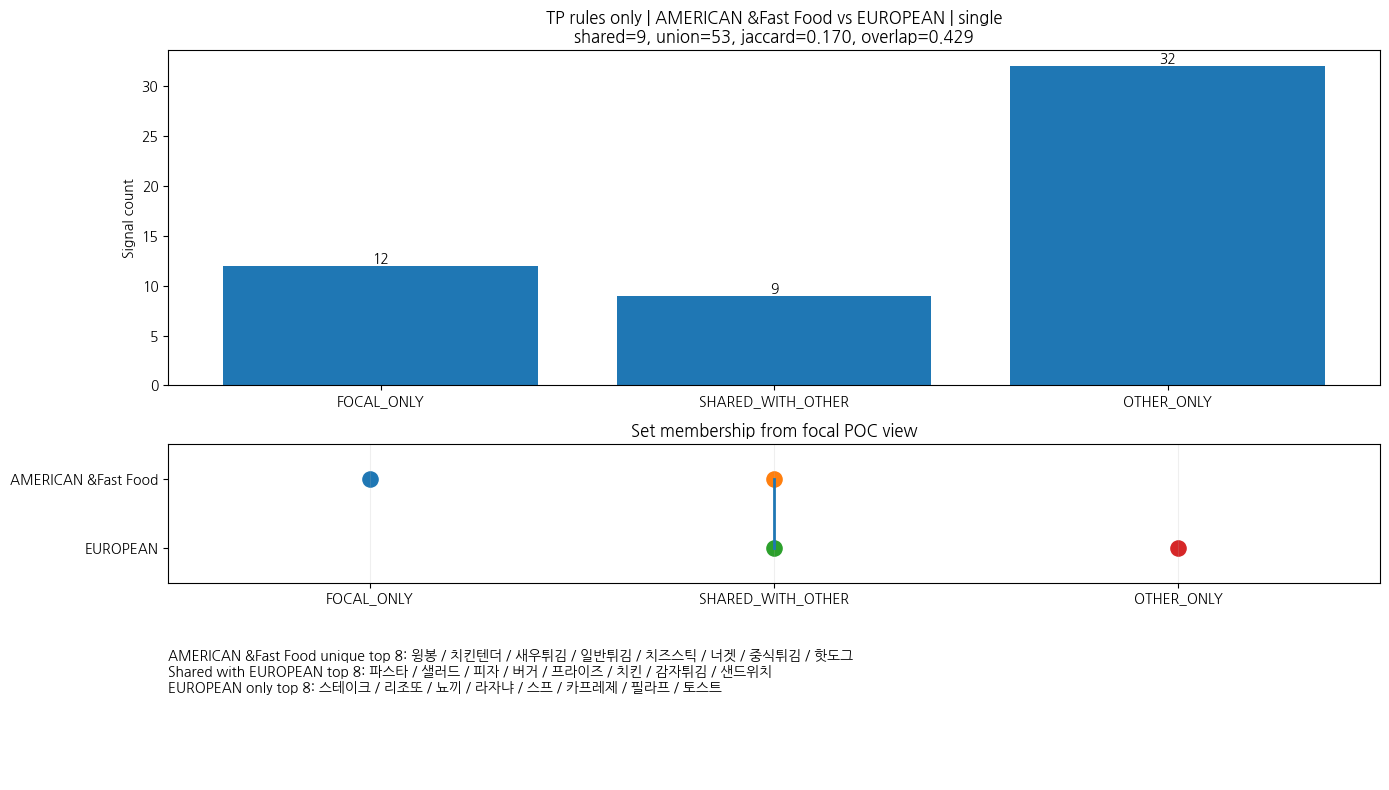

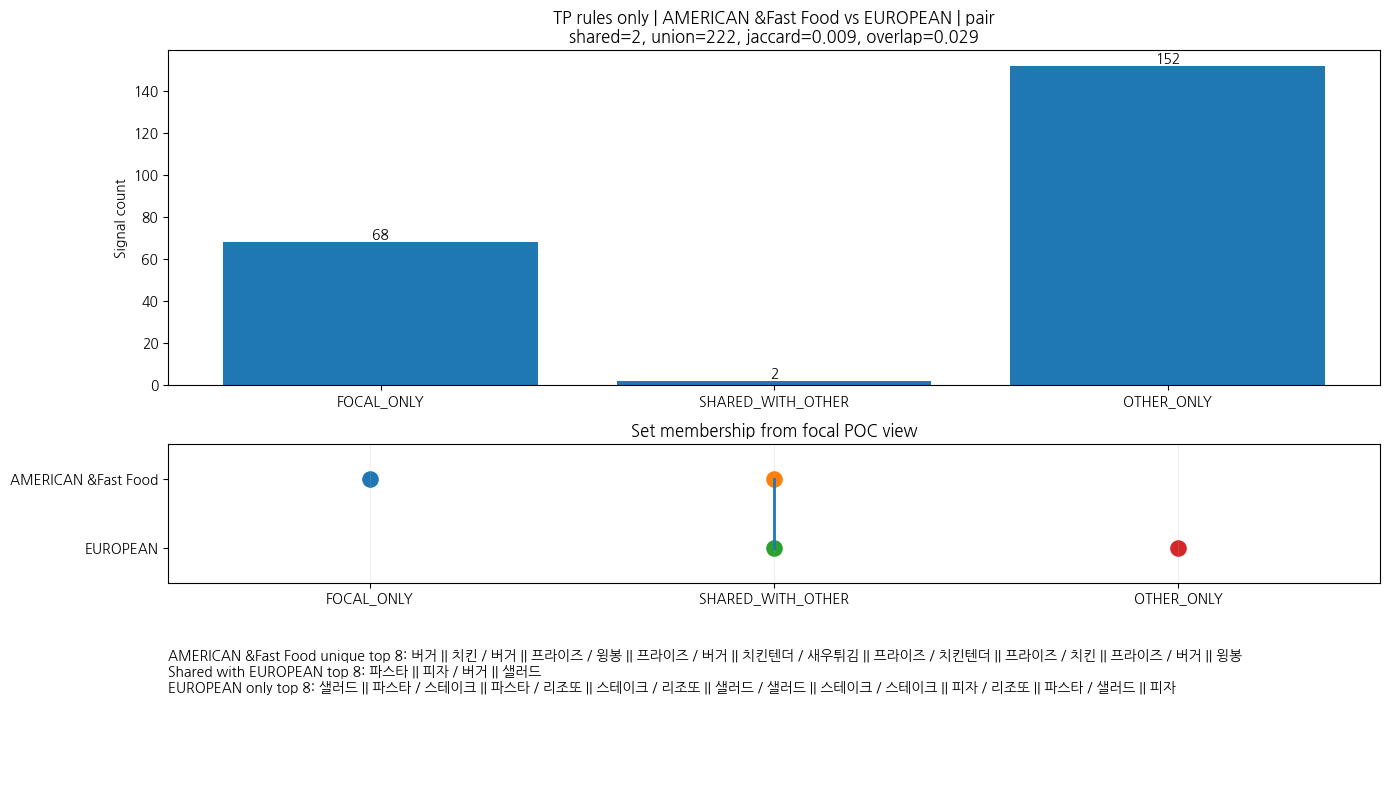

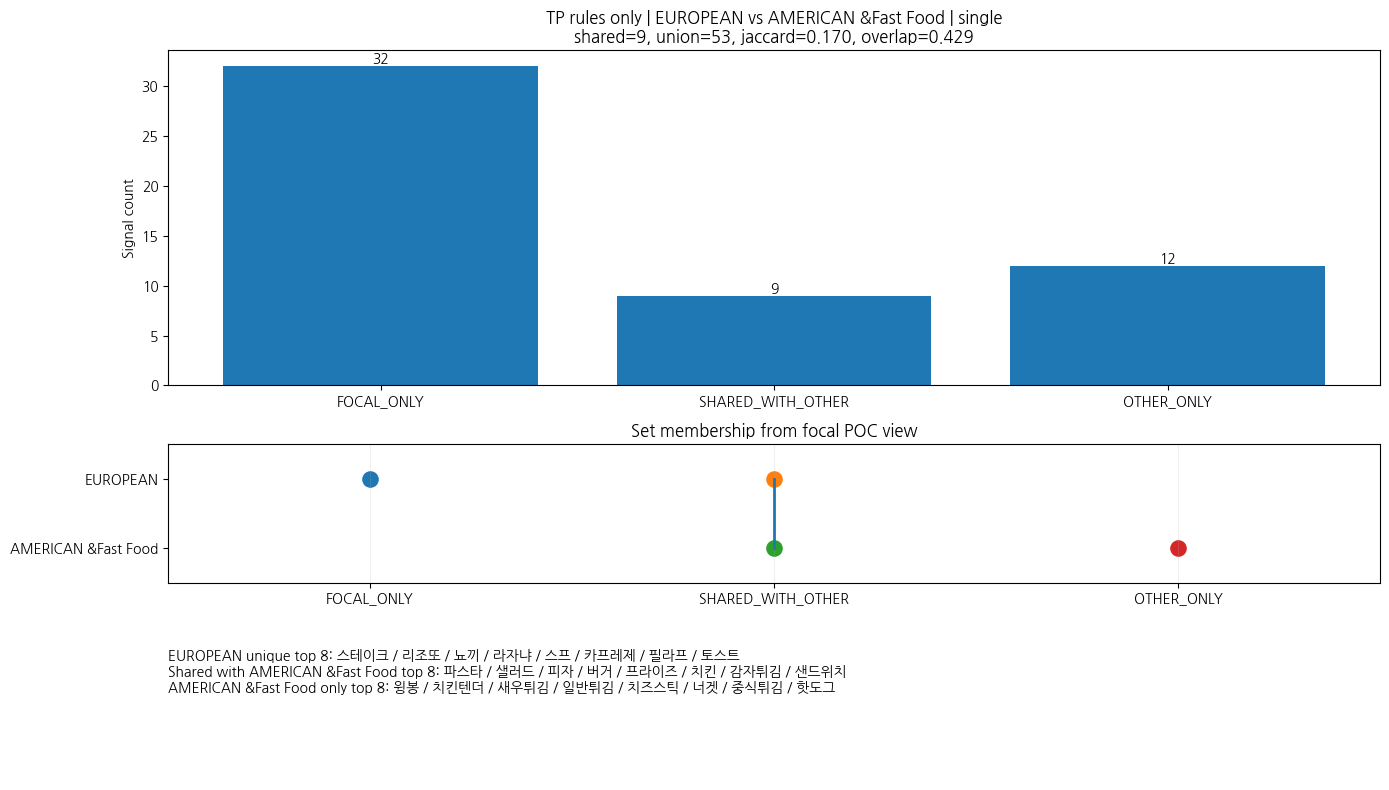

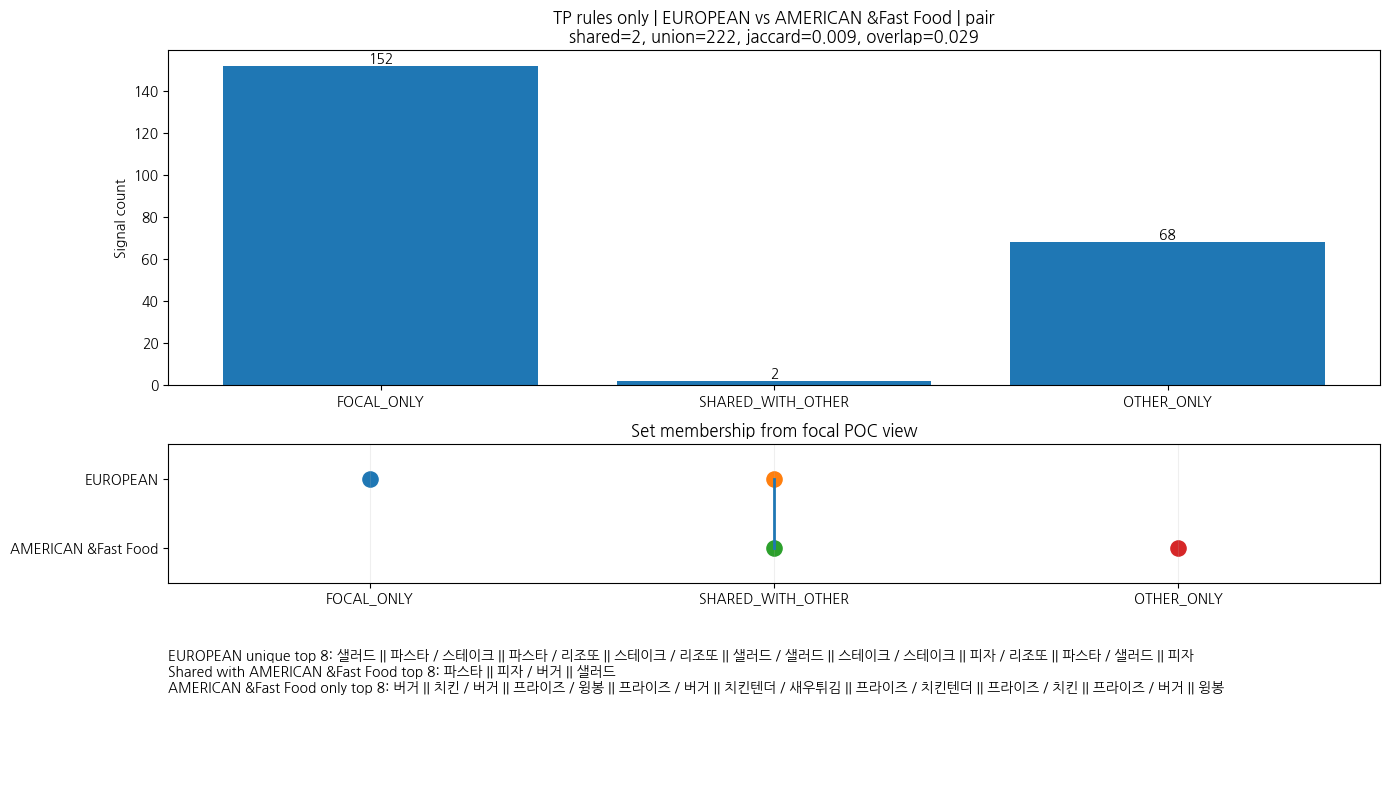

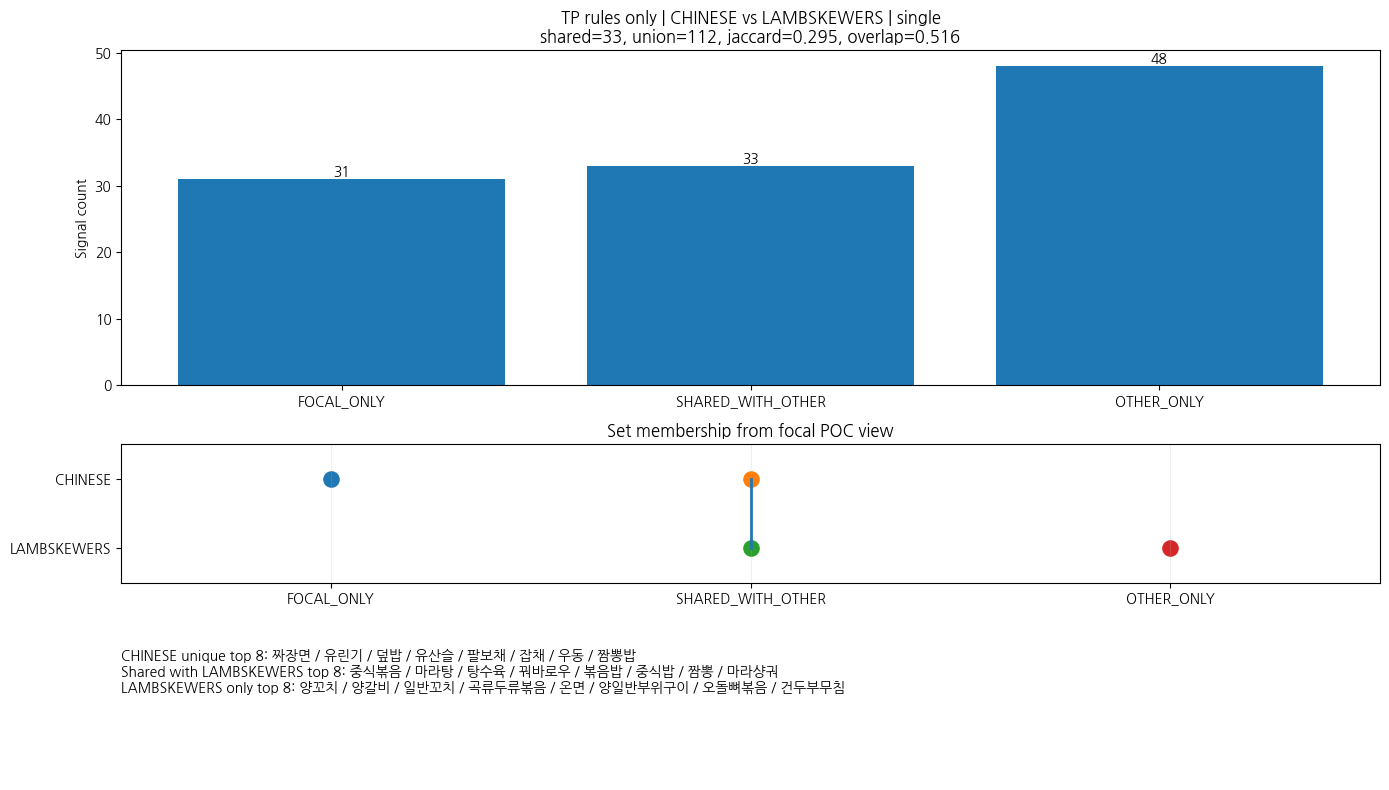

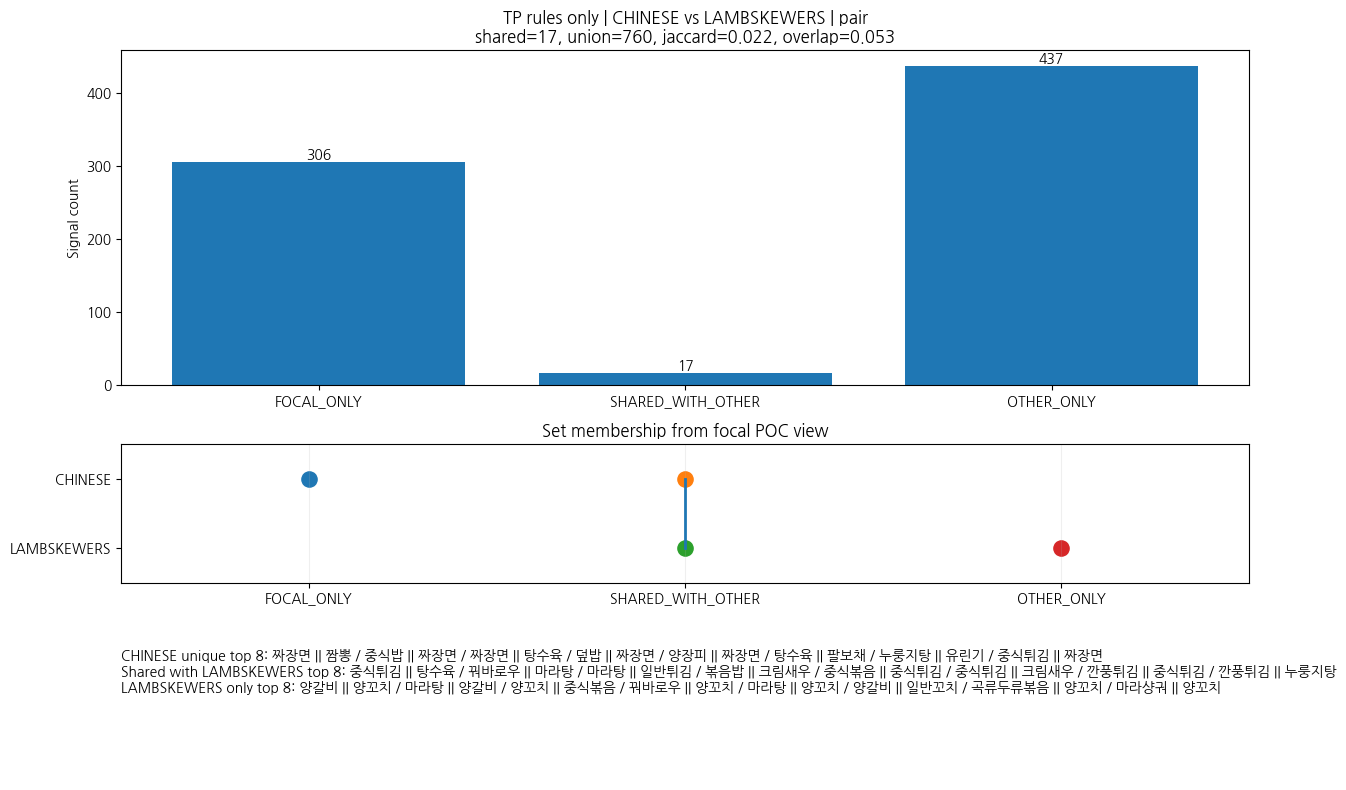

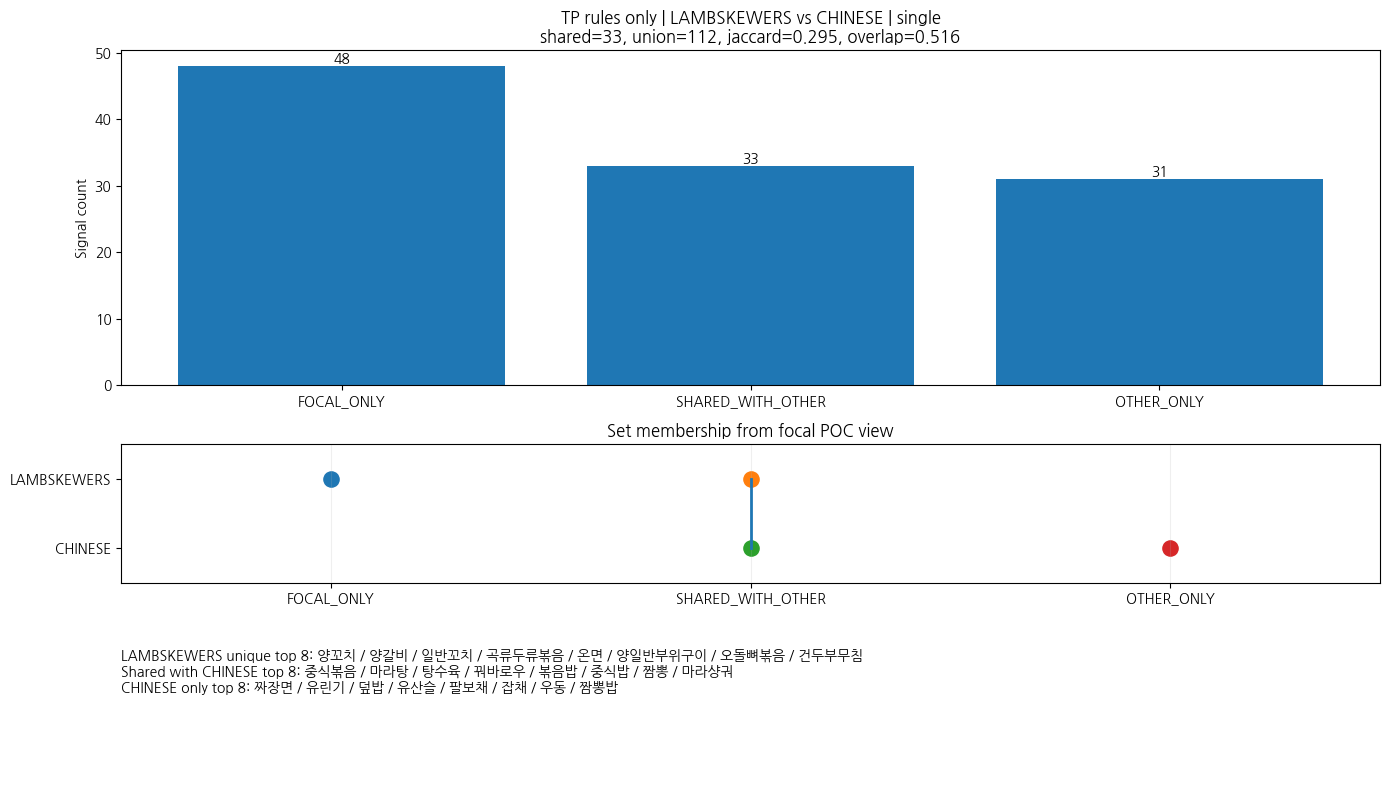

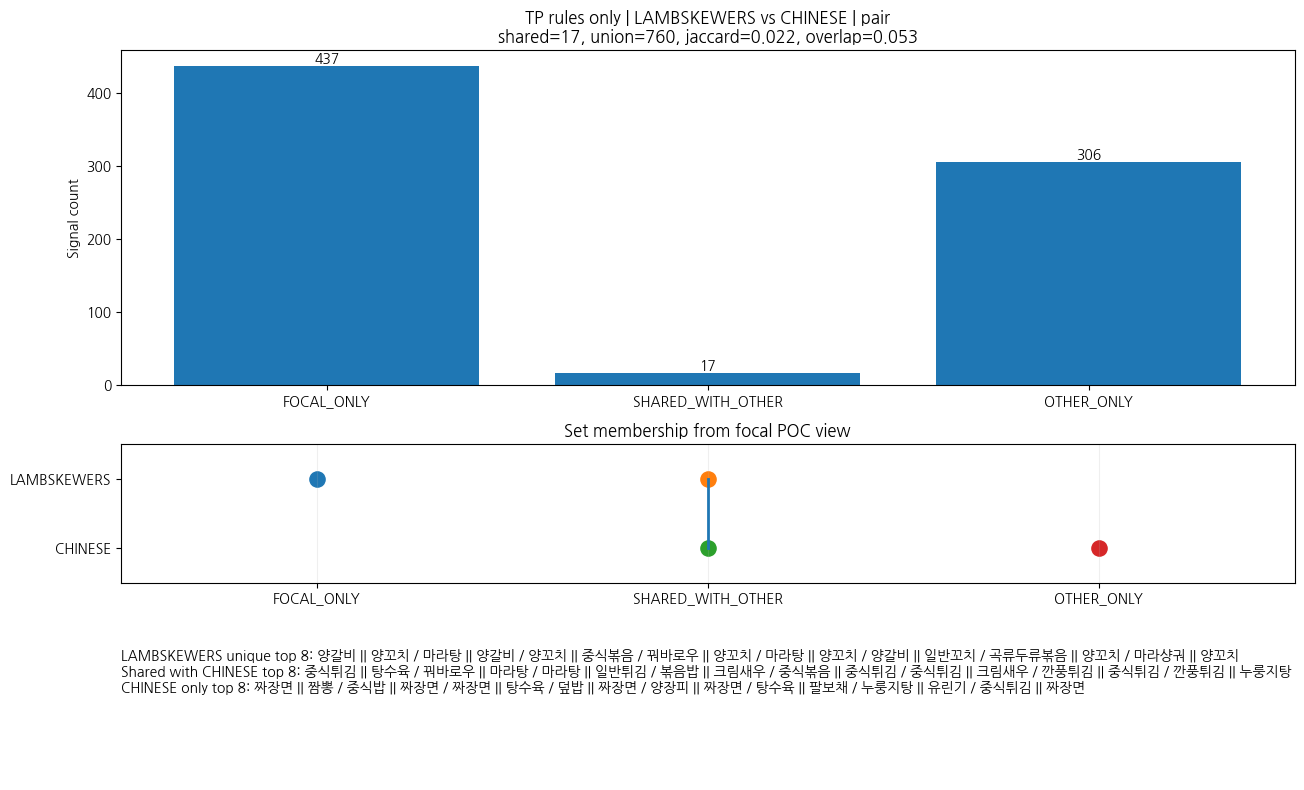

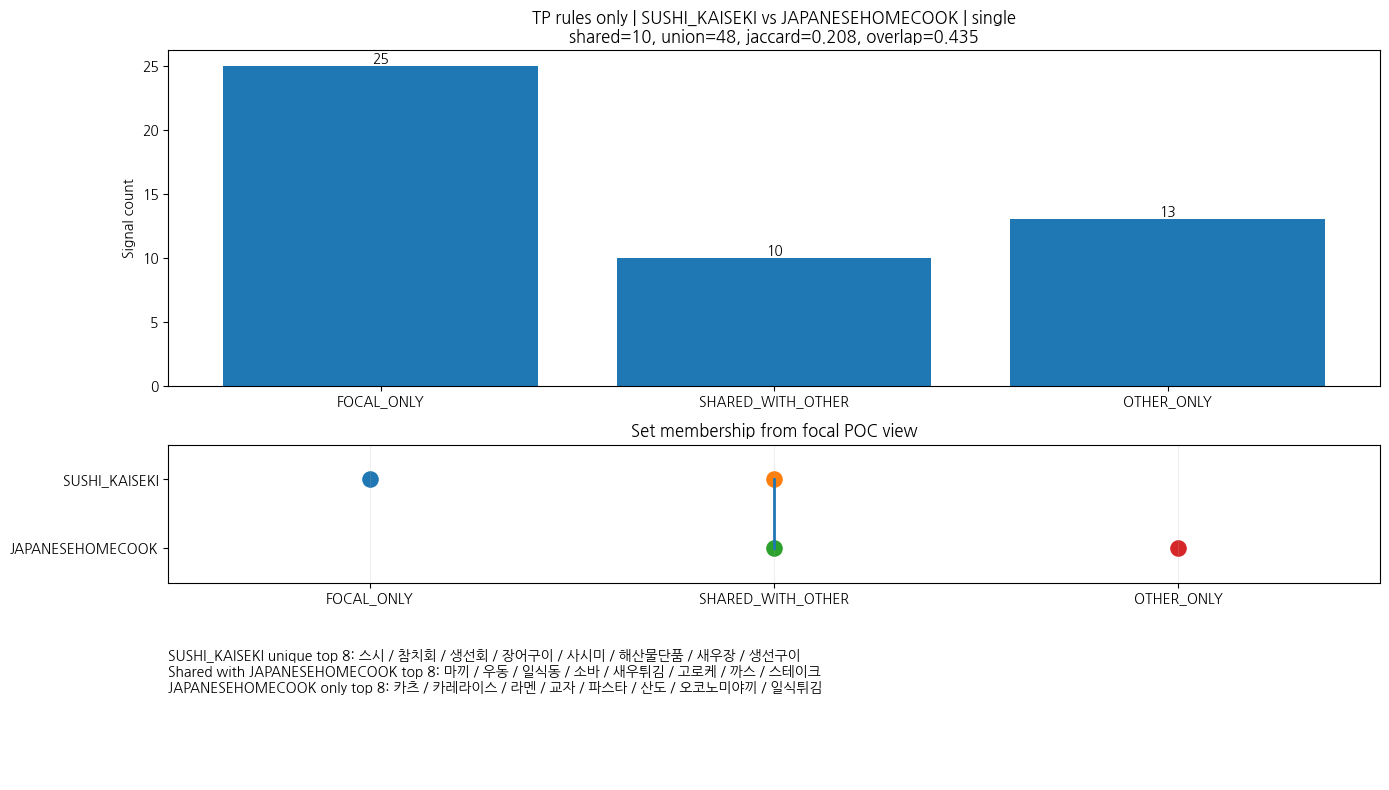

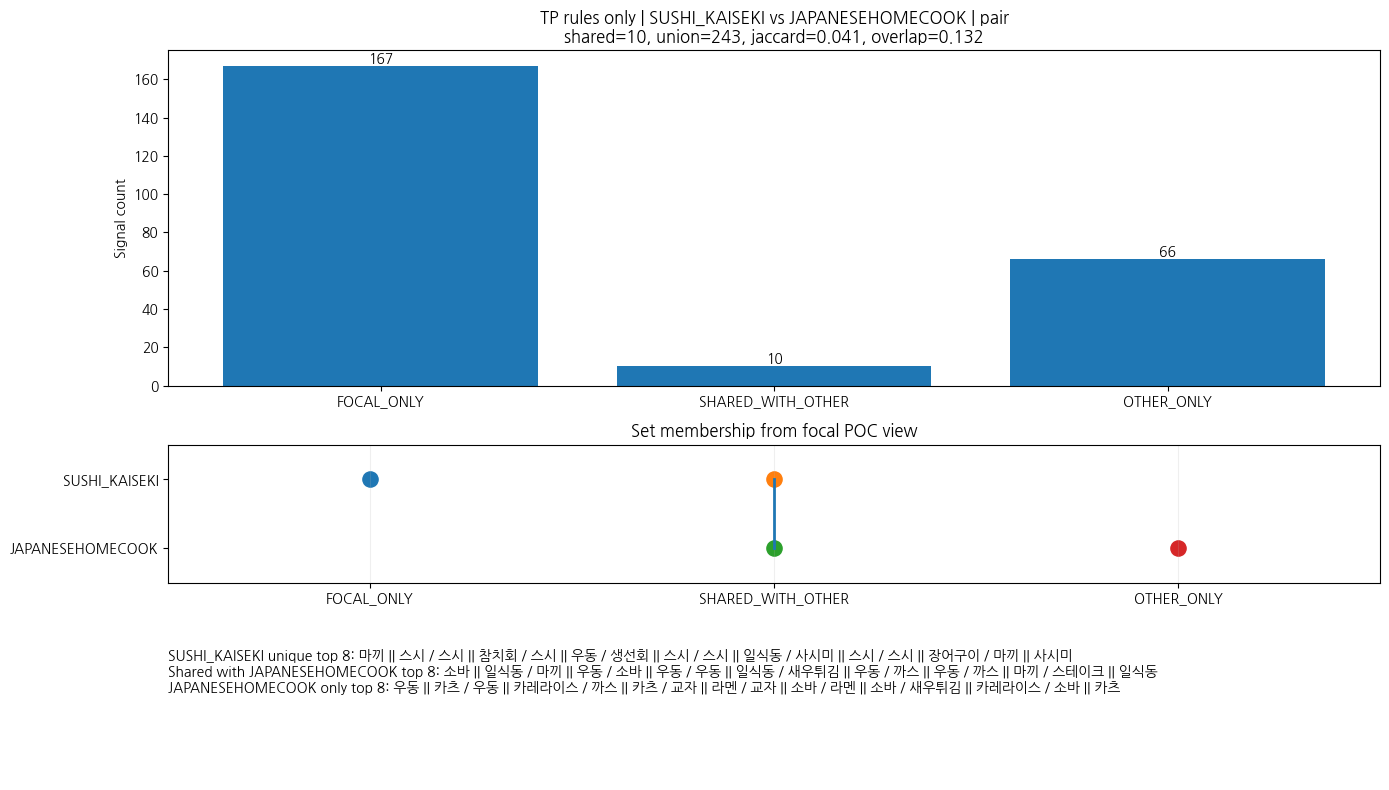

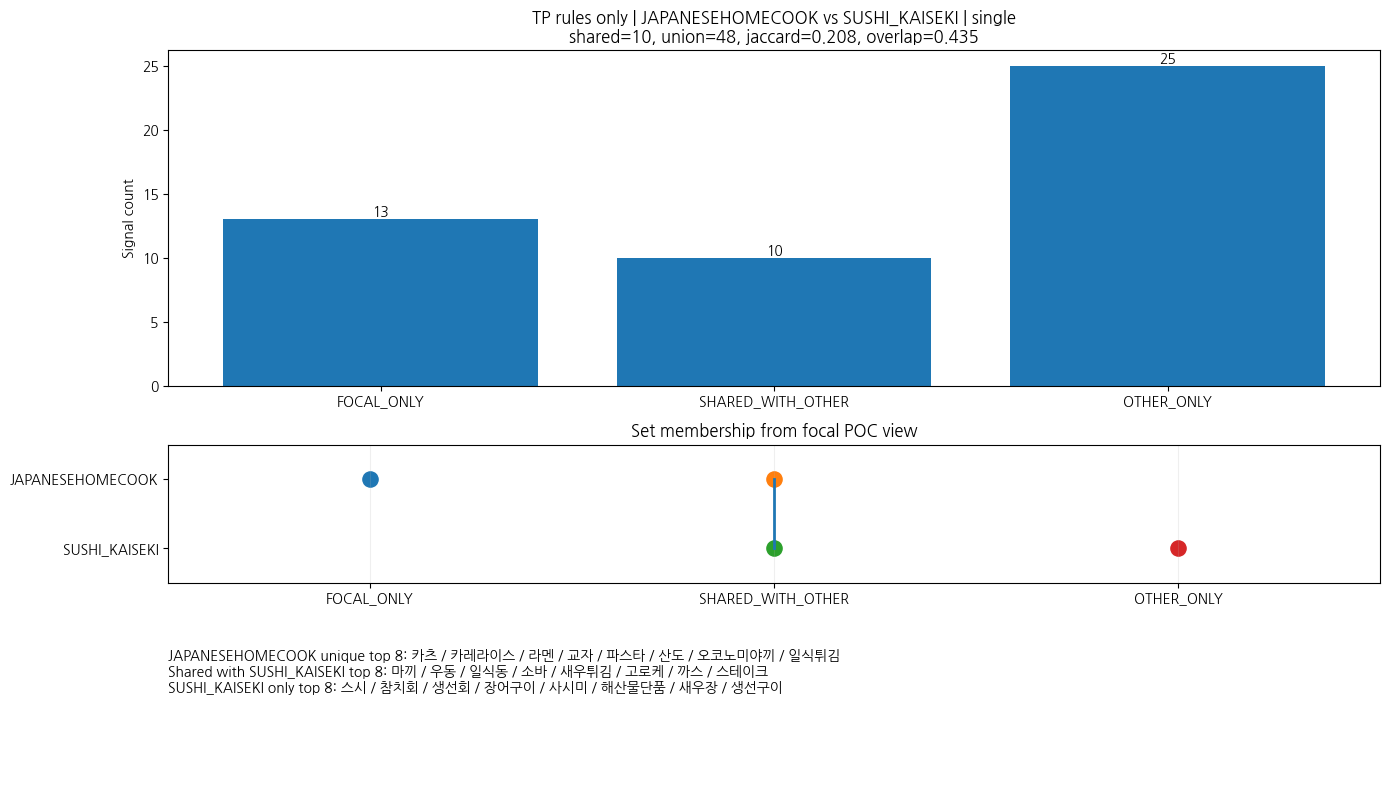

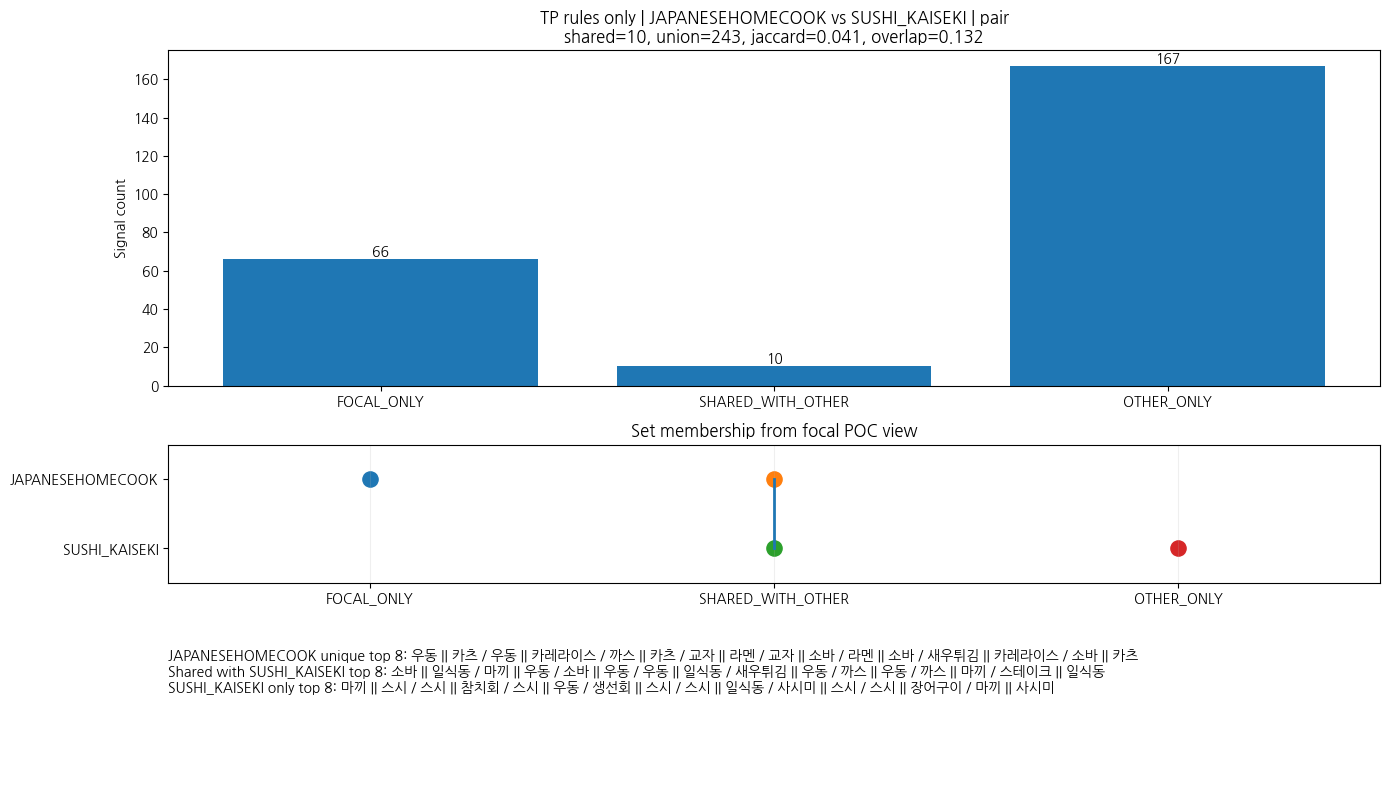

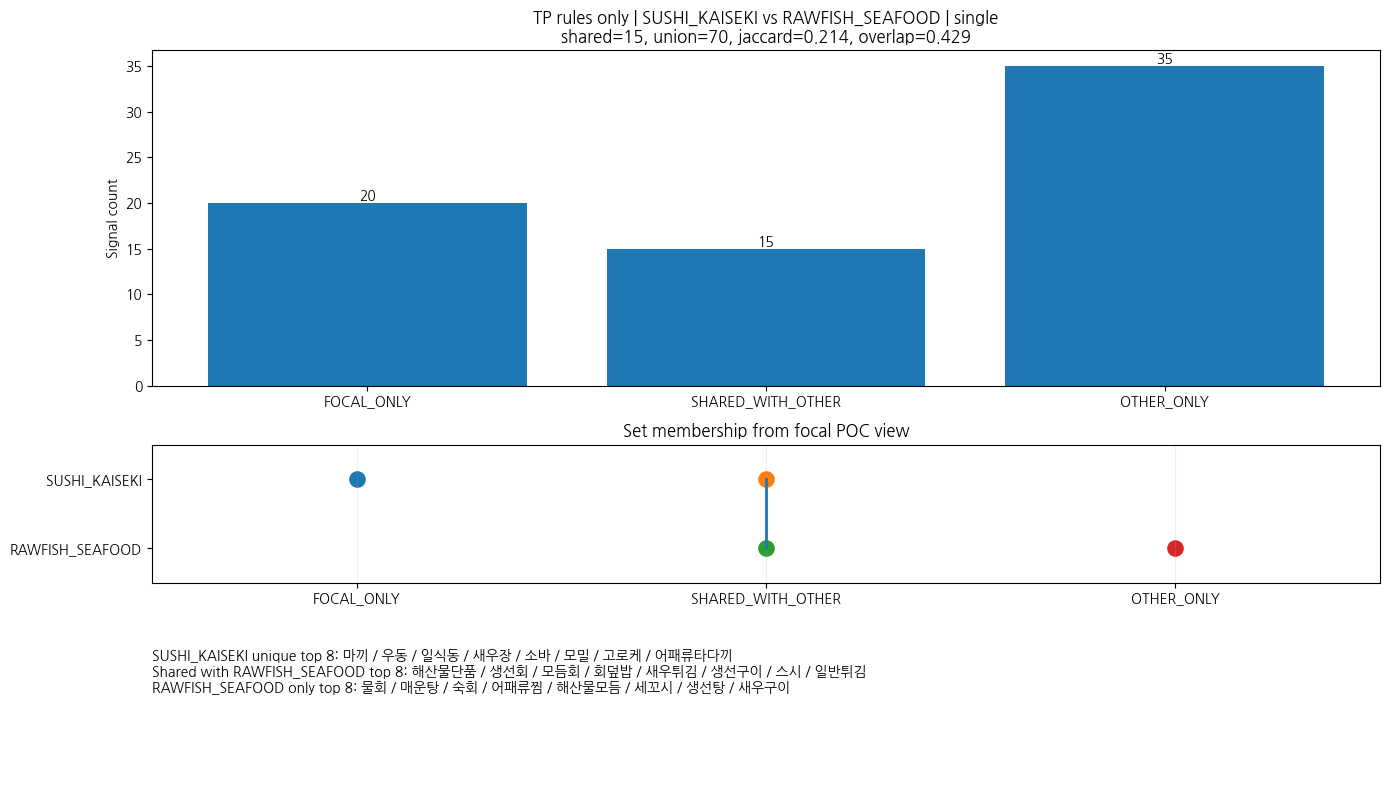

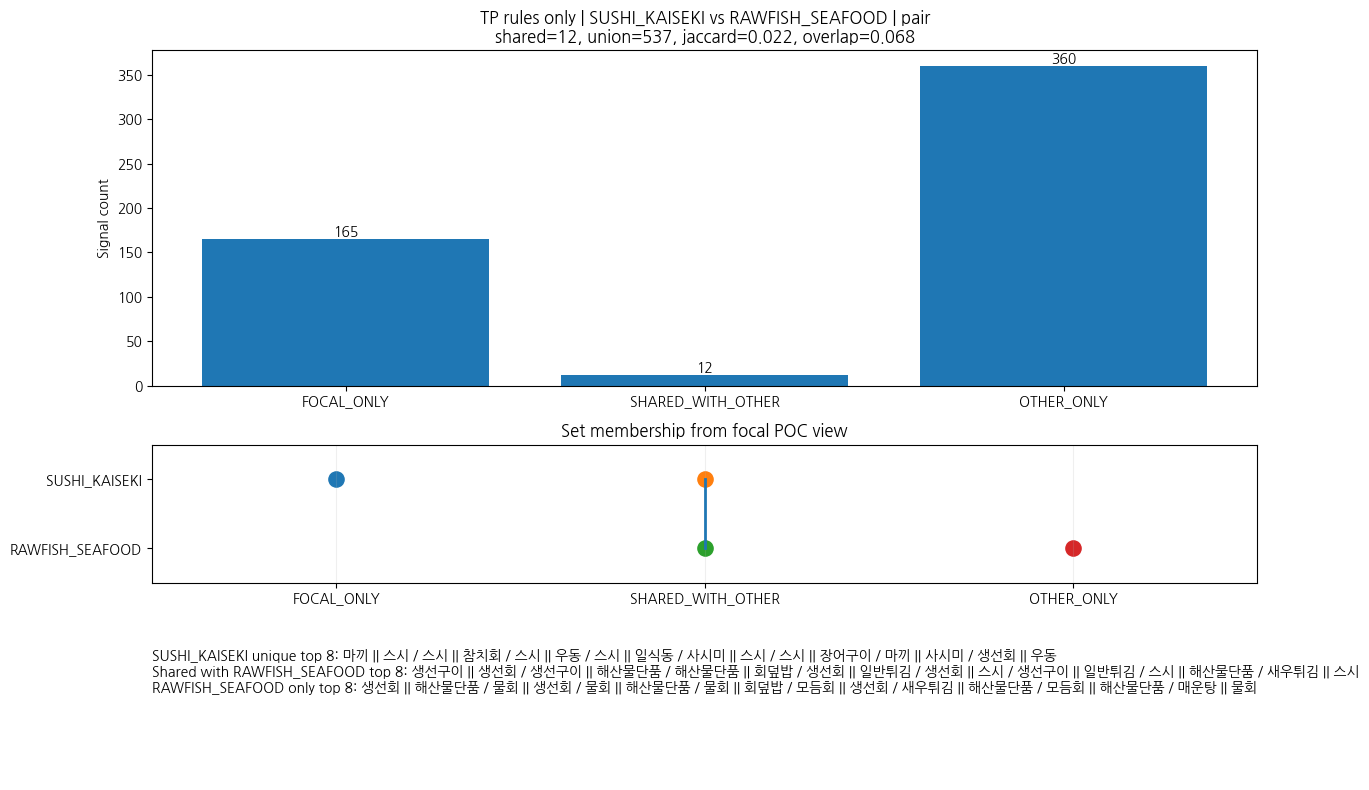

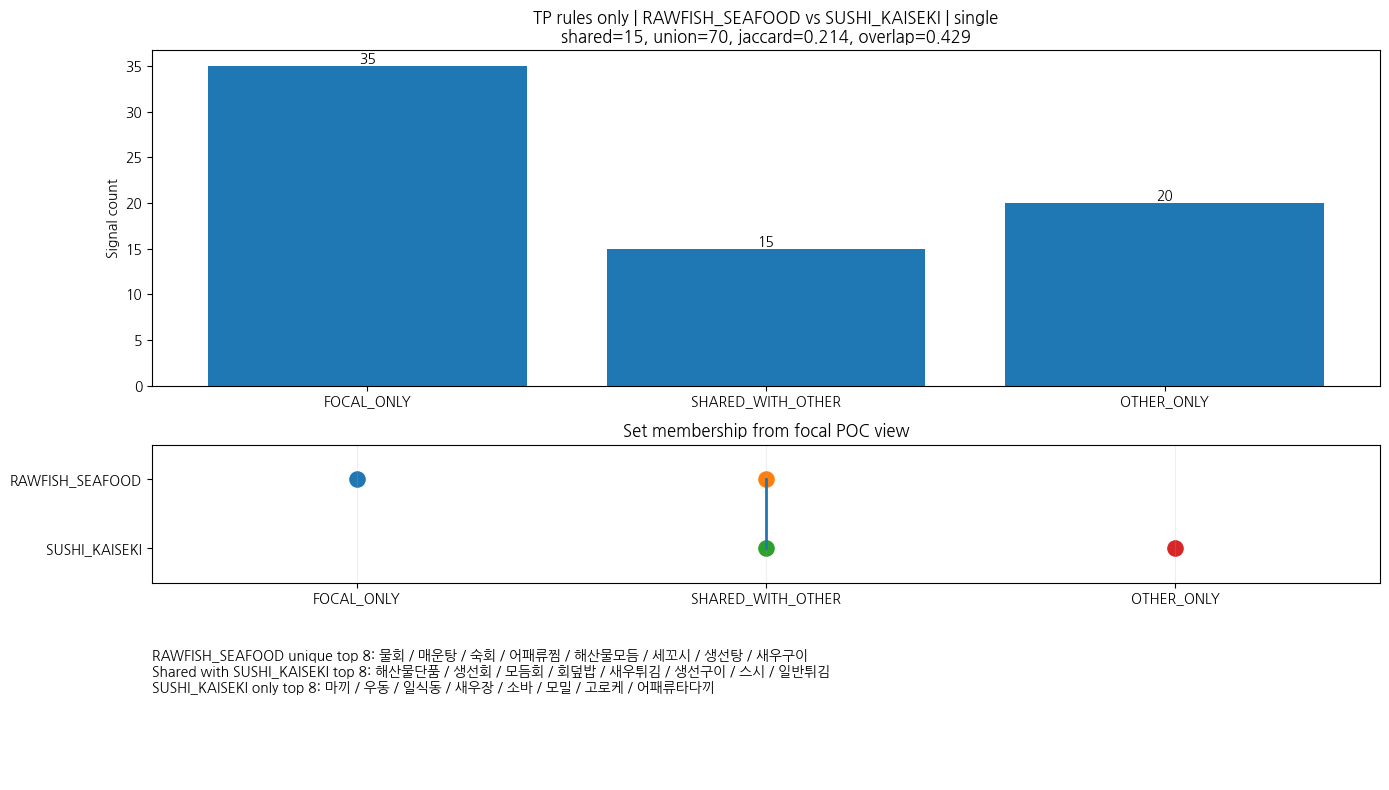

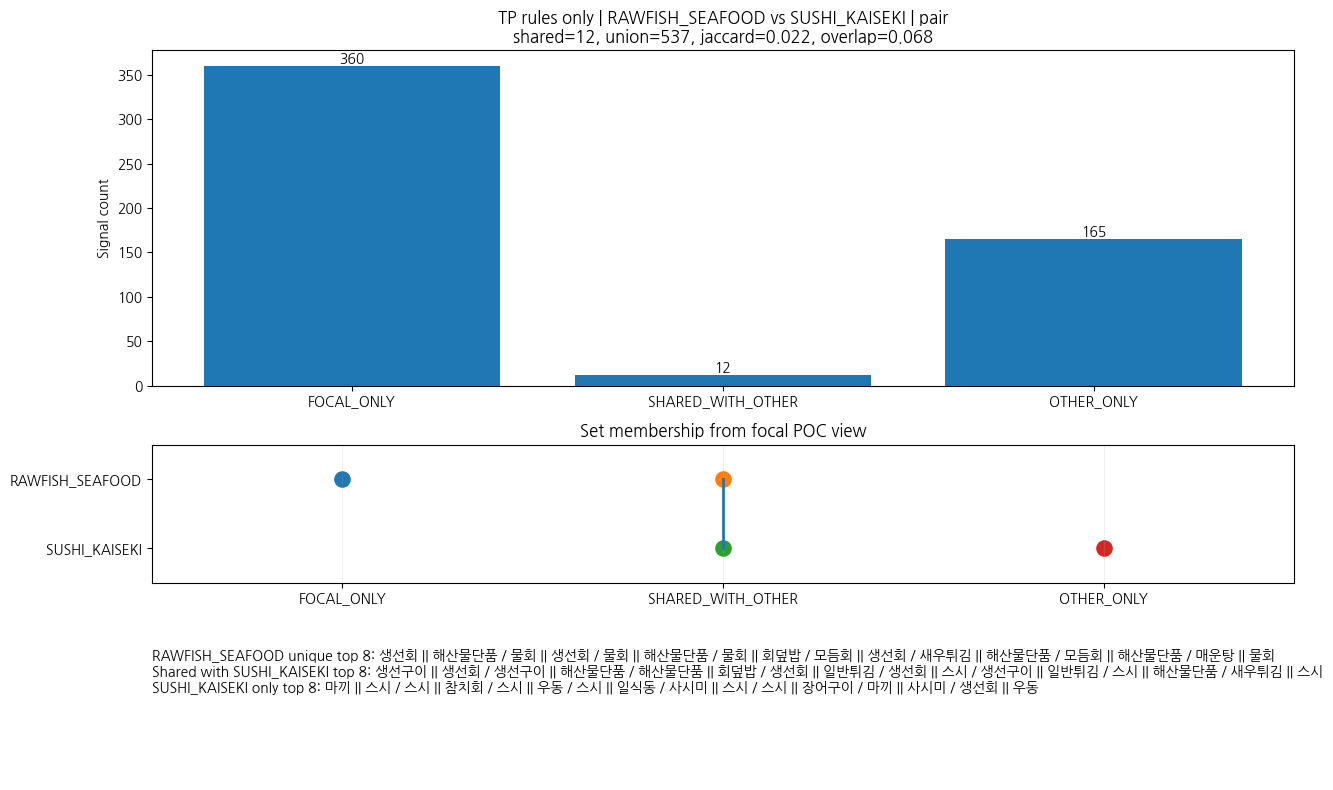

In [0]:
# UpSet Like 시각화 정리 > 겹치는 부분 시각화 
# Block 16-G. TP rules only POC별 UpSet-like plot만 출력
# 입력: comparison_signal_detail_all, comparison_pairwise_metrics
# 출력: POC별 focal view UpSet-like plot

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. TP rules만 필터링
tp_detail = comparison_signal_detail_all[
    comparison_signal_detail_all["source"] == "tp_rules"
].copy()

tp_metrics = comparison_pairwise_metrics[
    comparison_pairwise_metrics["source"] == "tp_rules"
].copy()

if tp_detail.empty:
    raise ValueError("tp_rules 데이터가 없습니다. tp_rules_by_poc 생성 여부를 확인하세요.")


# 2. 비교쌍 데이터를 POC별 관점으로 변환
focal_rows = []

for _, row in tp_detail.iterrows():
    poc_a = row["poc_a"]
    poc_b = row["poc_b"]
    scope = row["signal_scope"]

    # poc_a 관점
    if scope == "SHARED":
        focal_scope_a = "SHARED_WITH_OTHER"
    elif scope == "POC_A_ONLY":
        focal_scope_a = "FOCAL_ONLY"
    elif scope == "POC_B_ONLY":
        focal_scope_a = "OTHER_ONLY"
    else:
        focal_scope_a = "UNKNOWN"

    focal_rows.append({
        "focal_poc": poc_a,
        "opponent_poc": poc_b,
        "comparison_pair": row["comparison_pair"],
        "signal_type": row["signal_type"],
        "focal_scope": focal_scope_a,
        "signal_key": row["signal_key"],
        "focal_weight": row["poc_a_weight"],
        "opponent_weight": row["poc_b_weight"],
        "total_weight": row["total_weight"],
    })

    # poc_b 관점
    if scope == "SHARED":
        focal_scope_b = "SHARED_WITH_OTHER"
    elif scope == "POC_B_ONLY":
        focal_scope_b = "FOCAL_ONLY"
    elif scope == "POC_A_ONLY":
        focal_scope_b = "OTHER_ONLY"
    else:
        focal_scope_b = "UNKNOWN"

    focal_rows.append({
        "focal_poc": poc_b,
        "opponent_poc": poc_a,
        "comparison_pair": row["comparison_pair"],
        "signal_type": row["signal_type"],
        "focal_scope": focal_scope_b,
        "signal_key": row["signal_key"],
        "focal_weight": row["poc_b_weight"],
        "opponent_weight": row["poc_a_weight"],
        "total_weight": row["total_weight"],
    })

poc_tp_plot_base = pd.DataFrame(focal_rows)


# 3. POC별 UpSet-like plot 함수
def plot_poc_upset_like_only(
    plot_base,
    metric_df,
    focal_poc,
    opponent_poc,
    signal_type,
    value_mode="count",
    top_n=8
):
    temp = plot_base[
        (plot_base["focal_poc"] == focal_poc) &
        (plot_base["opponent_poc"] == opponent_poc) &
        (plot_base["signal_type"] == signal_type)
    ].copy()

    if temp.empty:
        return

    comparison_pair = temp["comparison_pair"].iloc[0]

    metric_row = metric_df[
        (metric_df["comparison_pair"] == comparison_pair) &
        (metric_df["signal_type"] == signal_type)
    ].copy()

    if not metric_row.empty:
        shared_signal_n = metric_row["shared_signal_n"].iloc[0]
        union_signal_n = metric_row["union_signal_n"].iloc[0]
        jaccard = metric_row["jaccard"].iloc[0]
        overlap_coef = metric_row["overlap_coef"].iloc[0]
    else:
        shared_signal_n = np.nan
        union_signal_n = np.nan
        jaccard = np.nan
        overlap_coef = np.nan

    scope_order = ["FOCAL_ONLY", "SHARED_WITH_OTHER", "OTHER_ONLY"]

    if value_mode == "count":
        scope_summary = (
            temp
            .groupby("focal_scope", as_index=False)
            .agg(value=("signal_key", "nunique"))
        )
        y_label = "Signal count"

    elif value_mode == "weight":
        scope_summary = (
            temp
            .groupby("focal_scope", as_index=False)
            .agg(value=("total_weight", "sum"))
        )
        y_label = "Total weight"

    else:
        raise ValueError("value_mode은 count 또는 weight만 가능합니다.")

    scope_summary = (
        pd.DataFrame({"focal_scope": scope_order})
        .merge(scope_summary, on="focal_scope", how="left")
        .fillna({"value": 0})
    )

    top_focal_only = (
        temp[temp["focal_scope"] == "FOCAL_ONLY"]
        .sort_values("total_weight", ascending=False)
        .head(top_n)
    )

    top_shared = (
        temp[temp["focal_scope"] == "SHARED_WITH_OTHER"]
        .sort_values("total_weight", ascending=False)
        .head(top_n)
    )

    top_other_only = (
        temp[temp["focal_scope"] == "OTHER_ONLY"]
        .sort_values("total_weight", ascending=False)
        .head(top_n)
    )

    def make_top_text(df, title):
        if df.empty:
            return f"{title}: 없음"
        return f"{title}: " + " / ".join(df["signal_key"].astype(str).tolist())

    fig = plt.figure(figsize=(14, 8))

    ax_bar = plt.subplot2grid((4, 3), (0, 0), colspan=3, rowspan=2)
    ax_matrix = plt.subplot2grid((4, 3), (2, 0), colspan=3, rowspan=1)
    ax_text = plt.subplot2grid((4, 3), (3, 0), colspan=3, rowspan=1)

    x = np.arange(len(scope_summary))

    ax_bar.bar(x, scope_summary["value"])
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(scope_summary["focal_scope"])
    ax_bar.set_ylabel(y_label)

    ax_bar.set_title(
        f"TP rules only | {focal_poc} vs {opponent_poc} | {signal_type}\n"
        f"shared={shared_signal_n}, union={union_signal_n}, "
        f"jaccard={jaccard:.3f}, overlap={overlap_coef:.3f}"
    )

    for i, v in enumerate(scope_summary["value"]):
        ax_bar.text(i, v, f"{v:,.0f}", ha="center", va="bottom")

    ax_matrix.set_xlim(-0.5, 2.5)
    ax_matrix.set_ylim(-0.5, 1.5)
    ax_matrix.set_yticks([1, 0])
    ax_matrix.set_yticklabels([focal_poc, opponent_poc])
    ax_matrix.set_xticks(x)
    ax_matrix.set_xticklabels(scope_summary["focal_scope"])
    ax_matrix.set_title("Set membership from focal POC view")

    membership_points = {
        "FOCAL_ONLY": [(0, 1)],
        "SHARED_WITH_OTHER": [(1, 1), (1, 0)],
        "OTHER_ONLY": [(2, 0)],
    }

    for scope_name, points in membership_points.items():
        for px, py in points:
            ax_matrix.scatter(px, py, s=120)

    ax_matrix.plot([1, 1], [0, 1], linewidth=2)
    ax_matrix.grid(axis="x", alpha=0.2)

    ax_text.axis("off")

    text_lines = [
        make_top_text(top_focal_only, f"{focal_poc} unique top {top_n}"),
        make_top_text(top_shared, f"Shared with {opponent_poc} top {top_n}"),
        make_top_text(top_other_only, f"{opponent_poc} only top {top_n}"),
    ]

    ax_text.text(
        0,
        0.95,
        "\n".join(text_lines),
        va="top",
        ha="left",
        fontsize=10,
        wrap=True
    )

    plt.tight_layout()
    plt.show()


# 4. POC별 plot만 자동 출력
# 필요하면 TARGET_POCS에 원하는 POC만 넣기
TARGET_POCS = None
# 예시:
# TARGET_POCS = ["SUSHI_KAISEKI", "RAWFISH_SEAFOOD"]

SIGNAL_TYPES = ["single", "pair"]
VALUE_MODE = "count"
TOP_N = 8

plot_targets = poc_tp_plot_base[["focal_poc", "opponent_poc"]].drop_duplicates()

if TARGET_POCS is not None:
    plot_targets = plot_targets[plot_targets["focal_poc"].isin(TARGET_POCS)]

for _, target in plot_targets.iterrows():
    focal_poc = target["focal_poc"]
    opponent_poc = target["opponent_poc"]

    for signal_type in SIGNAL_TYPES:
        plot_poc_upset_like_only(
            plot_base=poc_tp_plot_base,
            metric_df=tp_metrics,
            focal_poc=focal_poc,
            opponent_poc=opponent_poc,
            signal_type=signal_type,
            value_mode=VALUE_MODE,
            top_n=TOP_N
        )

## **Block17: 신호가 여러 방향으로 퍼져있을 가능성**

- SteampSoup & Easymeal 식당별 유형 클러스터링 
- 비슷한 메뉴 구조를 가진 식당은 가깝도록 구성 

In [0]:
# Block 17. Google/Gemini embedding 기준 EASYMEAL / STEAM_SOUP 식당군 클러스터링
# 목적:
# - 메뉴를 묶는 것이 아니라, 식당끼리 묶는다.
# - 식당 1개 = final_generic_name_list 전체 basket 1개 = embedding 1개
# - EASYMEAL 내부 식당끼리 clustering
# - STEAM_SOUP 내부 식당끼리 clustering
# - cluster별 메뉴 통계로 "전 중심 식당군", "국밥 중심 식당군"처럼 해석 가능하게 만든다.
# - 중간 실패 시 checkpoint 저장, 재실행 시 완료된 embedding은 skip한다.


# 0. 설정
TARGET_POCS = ["EASYMEAL", "STEAM_SOUP"]

MENU_COL = "final_generic_name_list"
POC_COL_CANDIDATES = ["poc_seg_level03_name", "poc", "true_poc"]
ID_COL_CANDIDATES = ["restaurant_id", "store_id", "place_id", "id"]

EMBED_MODEL = "gemini-embedding-2"
OUTPUT_DIMENSIONALITY = 768

MIN_MENU_N_PER_STORE = 2

K_MIN = 3
K_MAX = 8
RANDOM_STATE = 42

# 특정 POC의 cluster 수를 직접 고정하고 싶으면 숫자를 넣는다.
# 예: {"EASYMEAL": 6, "STEAM_SOUP": 5}
MANUAL_K = {
    "EASYMEAL": None,
    "STEAM_SOUP": None,
}

# Gemini 동기 embedding 호출 안정화 설정
# 429가 계속 나면 BATCH_SIZE를 5로, REQUEST_SLEEP/BASE_SLEEP을 더 키우면 된다.
BATCH_SIZE = 10
REQUEST_SLEEP = 20.0
MAX_RETRIES = 5
BASE_SLEEP = 30.0

TOP_LABEL_MENU_N = 4
REPRESENTATIVE_STORE_N = 30

OUTPUT_DIR = "block17_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

output_path = os.path.join(
    OUTPUT_DIR,
    "easymeal_steamsoup_restaurant_gemini_cluster.xlsx"
)

checkpoint_path = os.path.join(
    OUTPUT_DIR,
    "easymeal_steamsoup_restaurant_embedding_checkpoint.pkl"
)


# 1. 유틸 함수
def parse_repeated_menu_list(x):
    if isinstance(x, list):
        return [str(v).strip() for v in x if str(v).strip()]

    if isinstance(x, (tuple, set, frozenset)):
        return [str(v).strip() for v in list(x) if str(v).strip()]

    if x is None:
        return []

    s = str(x).strip()

    if s in ["", "[]", "nan", "None"]:
        return []

    try:
        parsed = ast.literal_eval(s)

        if isinstance(parsed, list):
            return [str(v).strip() for v in parsed if str(v).strip()]

        if isinstance(parsed, (tuple, set, frozenset)):
            return [str(v).strip() for v in list(parsed) if str(v).strip()]

    except Exception:
        pass

    if "|" in s:
        return [v.strip() for v in s.split("|") if v.strip()]

    if "," in s:
        return [v.strip() for v in s.split(",") if v.strip()]

    return [s]


def flatten_menu_lists(series):
    result = []

    for items in series:
        if isinstance(items, list):
            result.extend(items)

    return result


def menu_basket_to_text(menu_items):
    menu_counts = Counter(menu_items)

    count_text = ", ".join([
        f"{menu} x{count}"
        for menu, count in menu_counts.most_common()
    ])

    # 식당 전체 메뉴 구성만 설명한다.
    # 메뉴 하나하나를 분류하라는 지시를 넣지 않는다.
    return f"이 식당은 다음 메뉴 구성을 가진다: {count_text}"


def make_text_hash(text):
    return hashlib.md5(str(text).encode("utf-8")).hexdigest()


def make_content(text):
    return types.Content(
        role="user",
        parts=[types.Part(text=text)]
    )


def call_embedding_api(client, texts):
    contents = [make_content(text) for text in texts]

    result = client.models.embed_content(
        model=EMBED_MODEL,
        contents=contents,
        config={"output_dimensionality": OUTPUT_DIMENSIONALITY}
    )

    embeddings = [
        np.array(emb.values, dtype=float)
        for emb in result.embeddings
    ]

    return embeddings


def safe_embed_texts(client, texts):
    """
    input text n개 -> embedding n개 보장.
    Gemini SDK가 batch를 aggregate해서 output 1개만 주면 자동 split.
    최종적으로 식당 1개 = embedding 1개가 되도록 한다.
    """
    if len(texts) == 0:
        return []

    embeddings = call_embedding_api(client, texts)

    if len(embeddings) == len(texts):
        return embeddings

    if len(texts) == 1:
        raise ValueError(
            f"단일 embedding 개수 불일치: input=1, output={len(embeddings)}"
        )

    mid = len(texts) // 2

    left_embeddings = safe_embed_texts(
        client=client,
        texts=texts[:mid]
    )

    right_embeddings = safe_embed_texts(
        client=client,
        texts=texts[mid:]
    )

    return left_embeddings + right_embeddings


def get_embeddings_with_retry(client, texts, max_retries=5, base_sleep=30.0):
    last_error = None

    for attempt in range(1, max_retries + 1):
        try:
            embeddings = safe_embed_texts(client, texts)

            if len(embeddings) != len(texts):
                raise ValueError(
                    f"최종 embedding 개수 불일치: input={len(texts)}, output={len(embeddings)}"
                )

            return embeddings

        except Exception as e:
            last_error = e
            error_text = str(e)

            if "429" in error_text or "RESOURCE_EXHAUSTED" in error_text:
                wait_sec = base_sleep * attempt
            else:
                wait_sec = base_sleep * (2 ** (attempt - 1))

            print(
                f"[Embedding Retry] attempt={attempt}/{max_retries}, "
                f"batch_size={len(texts)}, wait={wait_sec:.1f}s, error={e}"
            )

            time.sleep(wait_sec)

    raise RuntimeError(
        f"Embedding 최종 실패. checkpoint 저장 후 나중에 재실행하세요. 마지막 에러: {last_error}"
    )


def make_batches(df, batch_size):
    for start in range(0, len(df), batch_size):
        end = min(start + batch_size, len(df))
        yield df.iloc[start:end].copy()


def valid_embedding(x):
    try:
        arr = np.array(x, dtype=float)
        return arr.ndim == 1 and len(arr) == OUTPUT_DIMENSIONALITY
    except Exception:
        return False


def normalize_checkpoint_df(df, target_embedding_key_set):
    if df is None or df.empty:
        return pd.DataFrame(
            columns=[
                "restaurant_id",
                "true_poc",
                "embedding_key",
                "embedding_text_hash",
                "embedding",
            ]
        )

    temp = df.copy()

    required_cols = {"restaurant_id", "embedding_key", "embedding"}

    if not required_cols.issubset(set(temp.columns)):
        return pd.DataFrame(
            columns=[
                "restaurant_id",
                "true_poc",
                "embedding_key",
                "embedding_text_hash",
                "embedding",
            ]
        )

    temp = temp[temp["embedding_key"].isin(target_embedding_key_set)].copy()
    temp = temp.drop_duplicates("embedding_key", keep="last").copy()
    temp = temp[temp["embedding"].apply(valid_embedding)].copy()

    keep_cols = [
        "restaurant_id",
        "true_poc",
        "embedding_key",
        "embedding_text_hash",
        "embedding",
    ]

    keep_cols = [c for c in keep_cols if c in temp.columns]

    return temp[keep_cols].copy()


def choose_best_k(X_emb, k_min=3, k_max=8):
    n = X_emb.shape[0]

    if n < k_min + 1:
        return 1, np.nan

    k_max = min(k_max, n - 1)

    best_k = None
    best_score = -1

    for k in range(k_min, k_max + 1):
        model = KMeans(
            n_clusters=k,
            random_state=RANDOM_STATE,
            n_init=20
        )

        labels = model.fit_predict(X_emb)

        if len(set(labels)) < 2:
            continue

        score = silhouette_score(
            X_emb,
            labels,
            metric="cosine"
        )

        if score > best_score:
            best_score = score
            best_k = k

    if best_k is None:
        return 1, np.nan

    return best_k, best_score


def make_cluster_label(menu_profile_df, top_n=4):
    temp = menu_profile_df.copy()

    if temp.empty:
        return "혼합 메뉴 식당군"

    temp = temp[
        (temp["store_presence_rate"] >= 0.10) |
        (temp["presence_gap"] > 0)
    ].copy()

    if temp.empty:
        return "혼합 메뉴 식당군"

    temp = temp.sort_values(
        ["presence_gap", "store_presence_rate", "menu_total_count"],
        ascending=[False, False, False]
    )

    menus = temp["menu"].head(top_n).tolist()

    if len(menus) == 0:
        return "혼합 메뉴 식당군"

    return " / ".join(menus) + " 중심 식당군"


# 2. 데이터 선택
if "dining_restaurant" in globals():
    base_df = dining_restaurant.copy()
elif "dining_food_signal_by_restaurant" in globals():
    base_df = dining_food_signal_by_restaurant.copy()
elif "work" in globals():
    base_df = work.copy()
elif "df" in globals():
    base_df = df.copy()
else:
    raise NameError(
        "dining_restaurant, dining_food_signal_by_restaurant, work, df 중 사용 가능한 DataFrame이 없습니다."
    )

if MENU_COL not in base_df.columns:
    raise ValueError("final_generic_name_list 컬럼이 없습니다.")

id_col = next((c for c in ID_COL_CANDIDATES if c in base_df.columns), None)
poc_col = next((c for c in POC_COL_CANDIDATES if c in base_df.columns), None)

if id_col is None:
    raise ValueError("restaurant_id 계열 ID 컬럼을 찾지 못했습니다.")

if poc_col is None:
    raise ValueError("poc_seg_level03_name 계열 POC 컬럼을 찾지 못했습니다.")


# 3. 식당 단위 basket 생성
# restaurant_id가 중복되어 있어도 식당 1개 단위로 메뉴를 합쳐서 embedding 1개만 만든다.
raw_base = base_df[[id_col, poc_col, MENU_COL]].copy()

raw_base = raw_base.rename(
    columns={
        id_col: "restaurant_id",
        poc_col: "true_poc",
        MENU_COL: "final_generic_name_list_raw",
    }
)

raw_base["final_generic_name_list"] = (
    raw_base["final_generic_name_list_raw"]
    .apply(parse_repeated_menu_list)
)

raw_base = raw_base[
    raw_base["true_poc"].isin(TARGET_POCS)
].copy()

restaurant_base = (
    raw_base
    .groupby(["restaurant_id", "true_poc"], as_index=False)
    .agg(
        final_generic_name_list=("final_generic_name_list", flatten_menu_lists)
    )
)

restaurant_base["menu_n"] = restaurant_base["final_generic_name_list"].apply(len)
restaurant_base["unique_menu_n"] = restaurant_base["final_generic_name_list"].apply(lambda x: len(set(x)))

restaurant_base = restaurant_base[
    restaurant_base["menu_n"] >= MIN_MENU_N_PER_STORE
].copy()

restaurant_base["final_generic_name_list_str"] = (
    restaurant_base["final_generic_name_list"]
    .apply(lambda x: ", ".join(x))
)

restaurant_base["embedding_text"] = (
    restaurant_base["final_generic_name_list"]
    .apply(menu_basket_to_text)
)

restaurant_base["embedding_text_hash"] = (
    restaurant_base["embedding_text"]
    .apply(make_text_hash)
)

restaurant_base["embedding_key"] = (
    restaurant_base["restaurant_id"].astype(str)
    + "__"
    + restaurant_base["true_poc"].astype(str)
    + "__"
    + restaurant_base["embedding_text_hash"].astype(str)
)

if restaurant_base.empty:
    raise ValueError("EASYMEAL / STEAM_SOUP 대상 식당 데이터가 없습니다.")

input_check = (
    restaurant_base
    .groupby("true_poc")
    .agg(
        store_n=("restaurant_id", "nunique"),
        row_n=("restaurant_id", "size"),
        total_menu_item_n=("menu_n", "sum"),
        avg_menu_n=("menu_n", "mean"),
        avg_unique_menu_n=("unique_menu_n", "mean"),
    )
    .reset_index()
)

display(input_check)


# 4. Gemini embedding 생성
GEMINI_API_KEY = getpass.getpass("Gemini API key를 입력하세요: ").strip()

if GEMINI_API_KEY == "":
    raise ValueError("Gemini API key가 입력되지 않았습니다.")

client = genai.Client(api_key=GEMINI_API_KEY)

target_embedding_key_set = set(restaurant_base["embedding_key"].astype(str))

if os.path.exists(checkpoint_path):
    raw_checkpoint_df = pd.read_pickle(checkpoint_path)
    embedding_df = normalize_checkpoint_df(
        raw_checkpoint_df,
        target_embedding_key_set
    )
    embedding_rows = embedding_df.to_dict("records")
    done_keys = set(embedding_df["embedding_key"].astype(str))
else:
    embedding_rows = []
    done_keys = set()

rows_to_embed = restaurant_base[
    ~restaurant_base["embedding_key"].isin(done_keys)
].copy()

print(f"전체 대상 식당 수: {len(restaurant_base):,}")
print(f"이미 완료된 embedding 수: {len(done_keys):,}")
print(f"이번 실행에서 남은 embedding 수: {len(rows_to_embed):,}")

batch_list = list(make_batches(rows_to_embed, BATCH_SIZE))

pbar = tqdm(
    total=len(restaurant_base),
    initial=len(done_keys),
    desc="Gemini restaurant embedding",
    unit="store"
)

try:
    for batch_df in batch_list:
        batch_texts = batch_df["embedding_text"].tolist()

        batch_embeddings = get_embeddings_with_retry(
            client=client,
            texts=batch_texts,
            max_retries=MAX_RETRIES,
            base_sleep=BASE_SLEEP
        )

        if len(batch_embeddings) != len(batch_df):
            raise ValueError(
                f"embedding 개수 불일치: input={len(batch_df)}, output={len(batch_embeddings)}"
            )

        for row, emb in zip(batch_df.itertuples(index=False), batch_embeddings):
            embedding_rows.append({
                "restaurant_id": row.restaurant_id,
                "true_poc": row.true_poc,
                "embedding_key": row.embedding_key,
                "embedding_text_hash": row.embedding_text_hash,
                "embedding": emb,
            })

        embedding_df = pd.DataFrame(embedding_rows)
        embedding_df = normalize_checkpoint_df(
            embedding_df,
            target_embedding_key_set
        )
        embedding_df.to_pickle(checkpoint_path)

        done_keys = set(embedding_df["embedding_key"].astype(str))
        pbar.update(len(batch_df))

        time.sleep(REQUEST_SLEEP)

except Exception as e:
    pbar.close()

    embedding_df = pd.DataFrame(embedding_rows)
    embedding_df = normalize_checkpoint_df(
        embedding_df,
        target_embedding_key_set
    )
    embedding_df.to_pickle(checkpoint_path)

    print(f"중간 실패 발생. 현재까지 embedding {len(embedding_df):,}개 저장 완료.")
    print("같은 코드를 다시 실행하면 저장된 embedding은 건너뛰고 남은 식당만 이어서 진행합니다.")

    raise e

pbar.close()

embedding_df = pd.DataFrame(embedding_rows)
embedding_df = normalize_checkpoint_df(
    embedding_df,
    target_embedding_key_set
)
embedding_df.to_pickle(checkpoint_path)

restaurant_base = restaurant_base.merge(
    embedding_df[["embedding_key", "embedding"]],
    on="embedding_key",
    how="left"
)

missing_embedding_n = restaurant_base["embedding"].isna().sum()

if missing_embedding_n > 0:
    raise ValueError(
        f"embedding 누락 식당이 {missing_embedding_n}개 있습니다. "
        "checkpoint는 저장되어 있으니 나중에 재실행하세요."
    )

print("Embedding 전체 완료")


# 5. POC별 식당 clustering
restaurant_rows = []
summary_rows = []
menu_rows = []
model_rows = []

poc_groups = list(restaurant_base.groupby("true_poc"))

for target_poc, g in tqdm(poc_groups, desc="POC restaurant clustering", unit="poc"):
    g = g.reset_index(drop=True).copy()

    X_raw = np.vstack(g["embedding"].values)
    X_emb = normalize(X_raw)

    manual_k = MANUAL_K.get(target_poc)

    if manual_k is not None:
        best_k = int(manual_k)
        best_silhouette = np.nan
    else:
        best_k, best_silhouette = choose_best_k(
            X_emb,
            k_min=K_MIN,
            k_max=K_MAX
        )

    if best_k == 1:
        labels = np.zeros(len(g), dtype=int)
        distances = np.zeros(len(g))
    else:
        kmeans = KMeans(
            n_clusters=best_k,
            random_state=RANDOM_STATE,
            n_init=20
        )

        labels = kmeans.fit_predict(X_emb)
        centers = kmeans.cluster_centers_

        distances = np.array([
            cosine_distances(
                X_emb[i].reshape(1, -1),
                centers[labels[i]].reshape(1, -1)
            )[0, 0]
            for i in range(len(g))
        ])

    g["cluster_id"] = labels
    g["cluster_key"] = g["true_poc"] + "_C" + g["cluster_id"].astype(str)
    g["cluster_distance"] = distances
    g["best_k"] = best_k
    g["cluster_silhouette"] = best_silhouette

    model_rows.append({
        "target_poc": target_poc,
        "store_n": len(g),
        "embedding_model": EMBED_MODEL,
        "output_dimensionality": OUTPUT_DIMENSIONALITY,
        "best_k": best_k,
        "best_silhouette": best_silhouette,
        "manual_k": manual_k,
        "batch_size": BATCH_SIZE,
        "unit": "restaurant",
        "clustering": "Gemini restaurant embedding -> KMeans",
    })

    cluster_ids = sorted(g["cluster_id"].unique())

    for cluster_id in tqdm(
        cluster_ids,
        desc=f"{target_poc} cluster profile",
        unit="cluster",
        leave=False
    ):
        cluster_df = g[g["cluster_id"] == cluster_id].copy()
        outside_df = g[g["cluster_id"] != cluster_id].copy()

        store_n = len(cluster_df)
        store_share = store_n / len(g)

        cluster_menu_counter = Counter()
        outside_menu_counter = Counter()

        for items in cluster_df["final_generic_name_list"]:
            cluster_menu_counter.update(items)

        for items in outside_df["final_generic_name_list"]:
            outside_menu_counter.update(items)

        all_menus = sorted(
            set(cluster_menu_counter.keys()) |
            set(outside_menu_counter.keys())
        )

        cluster_menu_profile_rows = []

        for menu in all_menus:
            cluster_count = cluster_menu_counter.get(menu, 0)

            if cluster_count <= 0:
                continue

            outside_count = outside_menu_counter.get(menu, 0)

            cluster_presence = (
                cluster_df["final_generic_name_list"]
                .apply(lambda x: menu in x)
                .mean()
            )

            outside_presence = (
                outside_df["final_generic_name_list"]
                .apply(lambda x: menu in x)
                .mean()
                if len(outside_df) > 0
                else 0
            )

            avg_count_per_store = cluster_count / store_n
            outside_avg_count_per_store = (
                outside_count / len(outside_df)
                if len(outside_df) > 0
                else 0
            )

            presence_gap = cluster_presence - outside_presence
            count_gap = avg_count_per_store - outside_avg_count_per_store

            row = {
                "target_poc": target_poc,
                "cluster_id": cluster_id,
                "cluster_key": f"{target_poc}_C{cluster_id}",
                "menu": menu,
                "store_n": store_n,
                "menu_total_count": cluster_count,
                "outside_menu_total_count": outside_count,
                "store_presence_rate": cluster_presence,
                "outside_store_presence_rate": outside_presence,
                "presence_gap": presence_gap,
                "avg_count_per_store": avg_count_per_store,
                "outside_avg_count_per_store": outside_avg_count_per_store,
                "count_gap": count_gap,
            }

            menu_rows.append(row)
            cluster_menu_profile_rows.append(row)

        cluster_menu_profile_df = pd.DataFrame(cluster_menu_profile_rows)
        auto_cluster_label = make_cluster_label(
            cluster_menu_profile_df,
            top_n=TOP_LABEL_MENU_N
        )

        representative_df = (
            cluster_df
            .sort_values(["cluster_distance", "restaurant_id"], ascending=[True, True])
            .head(REPRESENTATIVE_STORE_N)
            .copy()
        )

        representative_store_text = " || ".join([
            f"{r.restaurant_id}: {r.final_generic_name_list_str}"
            for r in representative_df.itertuples(index=False)
        ])

        summary_rows.append({
            "target_poc": target_poc,
            "cluster_id": cluster_id,
            "cluster_key": f"{target_poc}_C{cluster_id}",
            "auto_cluster_label": auto_cluster_label,
            "store_n": store_n,
            "store_share": store_share,
            "best_k": best_k,
            "cluster_silhouette": best_silhouette,
            "avg_menu_n": cluster_df["menu_n"].mean(),
            "median_menu_n": cluster_df["menu_n"].median(),
            "avg_unique_menu_n": cluster_df["unique_menu_n"].mean(),
            "median_unique_menu_n": cluster_df["unique_menu_n"].median(),
            "representative_store_examples": representative_store_text,
        })

        cluster_df = cluster_df.sort_values(
            ["cluster_distance", "restaurant_id"],
            ascending=[True, True]
        ).copy()

        cluster_df["representative_rank"] = np.arange(1, len(cluster_df) + 1)

        for r in cluster_df.itertuples(index=False):
            restaurant_rows.append({
                "target_poc": target_poc,
                "cluster_id": cluster_id,
                "cluster_key": f"{target_poc}_C{cluster_id}",
                "restaurant_id": r.restaurant_id,
                "representative_rank": r.representative_rank,
                "cluster_distance": r.cluster_distance,
                "menu_n": r.menu_n,
                "unique_menu_n": r.unique_menu_n,
                "final_generic_name_list_str": r.final_generic_name_list_str,
                "embedding_text": r.embedding_text,
            })


# 6. 결과 테이블 생성
model_info = pd.DataFrame(model_rows)

cluster_summary = (
    pd.DataFrame(summary_rows)
    .sort_values(["target_poc", "cluster_id"])
    .reset_index(drop=True)
)

cluster_menu_profile = (
    pd.DataFrame(menu_rows)
    .sort_values(
        ["target_poc", "cluster_id", "presence_gap", "store_presence_rate", "menu_total_count"],
        ascending=[True, True, False, False, False]
    )
    .reset_index(drop=True)
)

restaurant_cluster_all = (
    pd.DataFrame(restaurant_rows)
    .sort_values(["target_poc", "cluster_id", "representative_rank"])
    .reset_index(drop=True)
)


# 7. Excel 저장
readme_df = pd.DataFrame([
    {
        "sheet_name": "00_INPUT_CHECK",
        "description": "POC별 입력 식당 수, 총 메뉴 item 수, 평균 메뉴 수",
    },
    {
        "sheet_name": "01_MODEL_INFO",
        "description": "Gemini embedding 모델, KMeans 설정, 선택된 cluster 수",
    },
    {
        "sheet_name": "02_CLUSTER_SUMMARY",
        "description": "식당 cluster 요약. auto_cluster_label은 cluster 안에서 두드러지는 메뉴 기반 자동 라벨",
    },
    {
        "sheet_name": "03_CLUSTER_MENU_PROFILE",
        "description": "식당 cluster별 메뉴 분포. 메뉴를 clustering한 결과가 아니라, 식당 cluster를 해석하기 위한 사후 메뉴 통계",
    },
    {
        "sheet_name": "04_RESTAURANT_CLUSTER",
        "description": "식당별 cluster 배정 결과. representative_rank가 작을수록 cluster 대표 식당",
    },
])

readme_df.insert(0, "created_at", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

tables_to_save = {
    "README": readme_df,
    "00_INPUT_CHECK": input_check,
    "01_MODEL_INFO": model_info,
    "02_CLUSTER_SUMMARY": cluster_summary,
    "03_CLUSTER_MENU_PROFILE": cluster_menu_profile,
    "04_RESTAURANT_CLUSTER": restaurant_cluster_all,
}

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    for sheet_name, df_save in tqdm(tables_to_save.items(), desc="Excel save", unit="sheet"):
        df_save.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"Excel 저장 완료: {output_path}")

display(input_check)
display(model_info)
display(cluster_summary)
display(cluster_menu_profile)
display(restaurant_cluster_all)

,true_poc,store_n,row_n,total_menu_item_n,avg_menu_n,avg_unique_menu_n
0,EASYMEAL,1352,1352,16713,12.361686,7.704882
1,STEAM_SOUP,1089,1089,13018,11.954086,6.922865


Gemini API key를 입력하세요:  [REDACTED]

전체 대상 식당 수: 2,441
이미 완료된 embedding 수: 70
이번 실행에서 남은 embedding 수: 2,371


Gemini restaurant embedding:   3%|2         | 70/2441 [00:00<?, ?store/s]

In [0]:
# 3. Steam soup와 Easymeal, Non BBQ 식당별 분포 > 종류 체크 